# Home Credit Default Risk Prediction

**Module:** Human Centric Deep Learning  
**Project:** Credit Default Risk Prediction  
**Student Names:**  
**Student Numbers:**

# Section 1

#  1.Introduction, background and rationale on the dataset
Project Overview
This project is about predicting loan default risk by using machine learning and deep learning methods on the Home Credit Default Risk dataset. Banks and other financial institutions need risk assessment models. Credit risk prediction is an important task in financial services. Before giving a loan, a lender needs to estimate whether the applicant is likely to repay it or have difficulty with repayment. This decision is important for the lender because loan default can create financial loss. It is also important for customers because an unfair or incorrect decision may reduce their access to credit.

In this project, we use the Home Credit Default Risk dataset to predict whether a customer will have difficulty repaying a loan. The target variable is binary:

- TARGET = 0 means the customer repaid the loan
- TARGET = 1 means the customer had difficulty repaying the loan

This makes the problem a supervised binary classification task.

The dataset is suitable for this project because it is large, tabular, and contains many financial, demographic, and historical credit features. It also contains multiple related CSV files, which show the complexity of human behaviural data and how challenging it to handle them to get a good working model.

Dataset Structure
The Home Credit dataset is made up of several related tables, and each one gives a different view of a client's financial behaviour. The main tables are:

application_train / application_test – This is the main table and it contains demographic, financial, and loan informations for each applicant.
bureau – This includes historical credit informations from other external financial institutions.
bureau_balance – Monthly balance information that is related to bureau records.
previous_application – Details about previous loan applications made by clients.
POS_CASH_BALANCE – Historical point-of-sale and cash loan data.
credit_card_balance – Monthly credit card balance history.
installments_payments – Historical information about repayments and missed payments.

Each client is identified uniquely by the feature SK_ID_CURR, and previous loans and records are connected using identifiers like SK_ID_PREV.

This diagram shows how all of the data is related:

![image](https://storage.googleapis.com/kaggle-media/competitions/home-credit/home_credit.png)


# Data understanding + EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the datasets

The dataset consists of multiple files. The main file is `application_train.csv`, which contains the target variable.

Other files contain additional information such as previous loans, credit history, and payment behavior.

In [ ]:
app_train = pd.read_csv("application_train.csv")
app_test = pd.read_csv("application_test.csv")

bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")

previous_app = pd.read_csv("previous_application.csv")
pos_cash = pd.read_csv("POS_CASH_balance.csv")
credit_card = pd.read_csv("credit_card_balance.csv")
installments = pd.read_csv("installments_payments.csv")

## Dataset Overview

Before doing any analysis, we need to understand the size and structure of each dataset.

Each dataset contains different information:

- application_train → main data with target variable
- bureau → previous credit history from other institutions
- previous_application → past loan applications
- installments → payment behavior
- credit_card_balance → credit card usage
- POS_CASH_balance → POS loans
- bureau_balance → monthly updates on previous credits

In [ ]:
datasets = {
    "application_train": app_train,
    "application_test": app_test,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_app,
    "POS_CASH_balance": pos_cash,
    "credit_card_balance": credit_card,
    "installments_payments": installments
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate Rows": df.duplicated().sum(),
        "Memory MB": round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

overview_df = pd.DataFrame(overview)
overview_df

,Dataset,Rows,Columns,Duplicate Rows,Memory MB
0,application_train,307511,122,0,536.69
1,application_test,48744,121,0,84.74
2,bureau,1716428,17,0,512.11
3,bureau_balance,20505919,3,0,1447.14
4,previous_application,1157334,37,0,1317.18
5,POS_CASH_balance,7156375,8,0,813.56
6,credit_card_balance,2538986,23,0,578.98
7,installments_payments,5287426,8,0,322.72


This table gives an overview of the number of rows and columns in each dataset. Some datasets are much larger than the main application file because they contain multiple historical records for the same customer.

This is important because the modelling dataset must have one row per current applicant. Therefore, the team must understand the relationship between the files before merging or modelling.

## 6. Dataset Relationship and Mapping

The Home Credit dataset is relational. This means the CSV files are connected through ID columns rather than existing as one flat table.

The main ID is `SK_ID_CURR`, which represents the current loan applicant. This ID is found in the main application data and most secondary files.

Some files also use:

- `SK_ID_PREV`: previous Home Credit application ID
- `SK_ID_BUREAU`: previous credit record ID from the credit bureau

The final modelling dataset should be built at applicant level, meaning one row per `SK_ID_CURR`.

In [ ]:
relationship_table = pd.DataFrame({
    "Dataset": [
        "application_train",
        "application_test",
        "bureau",
        "bureau_balance",
        "previous_application",
        "POS_CASH_balance",
        "credit_card_balance",
        "installments_payments"
    ],
    "Main Key": [
        "SK_ID_CURR",
        "SK_ID_CURR",
        "SK_ID_CURR, SK_ID_BUREAU",
        "SK_ID_BUREAU",
        "SK_ID_CURR, SK_ID_PREV",
        "SK_ID_CURR, SK_ID_PREV",
        "SK_ID_CURR, SK_ID_PREV",
        "SK_ID_CURR, SK_ID_PREV"
    ],
    "Level of Data": [
        "One row per current application",
        "One row per current application",
        "Multiple bureau credits per customer",
        "Monthly records per bureau credit",
        "Multiple previous applications per customer",
        "Monthly records for previous POS/cash loans",
        "Monthly records for previous credit cards",
        "Payment records for previous loans"
    ],
    "Use in Project": [
        "Main training data with TARGET",
        "Not used for training target, useful for column alignment",
        "Customer external credit history",
        "Monthly bureau behaviour",
        "Previous Home Credit applications",
        "Previous POS/cash loan behaviour",
        "Credit card behaviour",
        "Installment repayment behaviour"
    ]
})

relationship_table

,Dataset,Main Key,Level of Data,Use in Project
0,application_train,SK_ID_CURR,One row per current application,Main training data with TARGET
1,application_test,SK_ID_CURR,One row per current application,"Not used for training target, useful for colum..."
2,bureau,"SK_ID_CURR, SK_ID_BUREAU",Multiple bureau credits per customer,Customer external credit history
3,bureau_balance,SK_ID_BUREAU,Monthly records per bureau credit,Monthly bureau behaviour
4,previous_application,"SK_ID_CURR, SK_ID_PREV",Multiple previous applications per customer,Previous Home Credit applications
5,POS_CASH_balance,"SK_ID_CURR, SK_ID_PREV",Monthly records for previous POS/cash loans,Previous POS/cash loan behaviour
6,credit_card_balance,"SK_ID_CURR, SK_ID_PREV",Monthly records for previous credit cards,Credit card behaviour
7,installments_payments,"SK_ID_CURR, SK_ID_PREV",Payment records for previous loans,Installment repayment behaviour


This relationship table helps explain why aggregation is needed. Some datasets already exist at customer level, while others contain many records per customer or many monthly records per loan. These files cannot be directly joined without creating duplicate customer rows.

## Main Dataset (application_train)

This dataset is the most important because it contains the TARGET variable.

Each row represents one loan application.

In [ ]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
app_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
app_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


The main training dataset contains applicant information, loan information, and the target variable. Each row represents one current loan application. This dataset is the starting point for the prediction task.

## Target Variable Distribution

We check how many customers repaid the loan and how many defaulted.

This helps us understand if the dataset is balanced or imbalanced.

In [ ]:
target_summary = pd.DataFrame({
    "Count": app_train["TARGET"].value_counts(),
    "Percentage": app_train["TARGET"].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


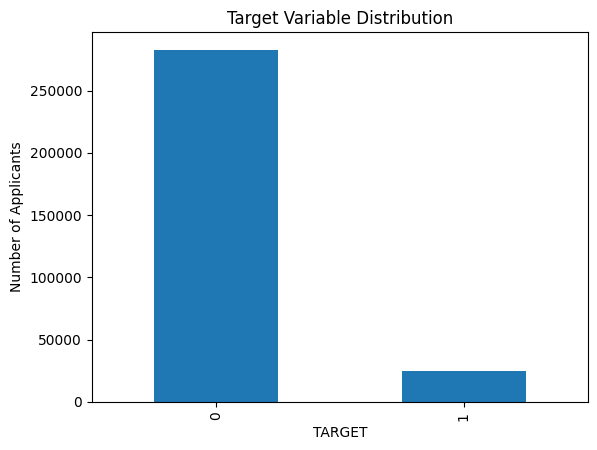

In [ ]:
app_train["TARGET"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.show()

The dataset is highly imbalanced. Most customers repaid the loan (TARGET = 0), while a smaller number of customers had difficulty repaying (TARGET = 1).

This is important because a model can achieve high accuracy by predicting only the majority class. Therefore, accuracy alone is not a good evaluation metric, and other metrics such as recall and F1-score should be considered.

## Duplicate Row Check

After checking the shape of each dataset, exact duplicate rows were checked. This step was done early because duplicate records can affect missing-value counts, distributions, summary statistics, and later aggregation.

Only exact duplicate rows were checked at this stage. Rows with the same applicant ID were not treated as duplicates because the secondary Home Credit tables are expected to contain multiple records per applicant, such as multiple bureau records, previous applications, credit card records, or installment payments.

In [ ]:
# Check exact duplicate rows in each dataset
duplicate_summary = []

for dataset_name, df in datasets.items():
    duplicate_summary.append({
        "Dataset": dataset_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Exact Duplicate Rows": df.duplicated().sum(),
        "Duplicate Percentage": round(df.duplicated().mean() * 100, 4)
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)
duplicate_summary_df

,Dataset,Rows,Columns,Exact Duplicate Rows,Duplicate Percentage
0,application_train,307511,123,0,0.0
1,application_test,48744,121,0,0.0
2,bureau,1716428,17,0,0.0
3,bureau_balance,20505919,3,0,0.0
4,previous_application,1157334,37,0,0.0
5,POS_CASH_balance,7156375,8,0,0.0
6,credit_card_balance,2538986,23,0,0.0
7,installments_payments,5287426,8,0,0.0


### Duplicate Row Check Decision

The duplicate row check shows that none of the datasets contain exact duplicate rows. The duplicate count is 0 for all eight files, so no rows were removed.

This means the datasets can be used for EDA and later aggregation without needing duplicate-row cleaning. Rows with repeated IDs were not treated as duplicates because the Home Credit dataset is relational, and secondary tables are expected to contain multiple records for the same applicant, previous application, or bureau record.

## Missing values across all datasets

In [ ]:
# Function to summarise missing values in one dataset
def missing_values_summary(df, dataset_name):
    total_missing = df.isnull().sum().sum()
    total_values = df.shape[0] * df.shape[1]
    missing_percentage = (total_missing / total_values) * 100

    columns_with_missing = (df.isnull().sum() > 0).sum()

    return {
        "Dataset": dataset_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Columns with Missing Values": columns_with_missing,
        "Total Missing Values": total_missing,
        "Overall Missing Percentage": missing_percentage
    }

In [ ]:
# Apply the function to all datasets
missing_overview = []

for name, df in datasets.items():
    missing_overview.append(missing_values_summary(df, name))

missing_overview_df = pd.DataFrame(missing_overview)

missing_overview_df.sort_values(
    "Overall Missing Percentage",
    ascending=False
)

,Dataset,Rows,Columns,Columns with Missing Values,Total Missing Values,Overall Missing Percentage
0,application_train,307511,122,67,9152465,24.395942
1,application_test,48744,121,64,1404419,23.811687
4,previous_application,1157334,37,25,7668911,17.909079
2,bureau,1716428,17,7,3939947,13.502552
6,credit_card_balance,2538986,23,15,3966975,6.793152
5,POS_CASH_balance,7156375,8,6,28460,0.049711
7,installments_payments,5287426,8,4,1524,0.003603
3,bureau_balance,20505919,3,1,1,0.000002


In [ ]:
# Function to find the highest missing percentage in each dataset
def highest_missing_percentage(df, dataset_name):
    missing_percent = df.isnull().mean() * 100

    return {
        "Dataset": dataset_name,
        "Highest Missing Percentage": missing_percent.max(),
        "Column with Highest Missing": missing_percent.idxmax()
    }

In [ ]:
highest_missing_all = []

for name, df in datasets.items():
    highest_missing_all.append(highest_missing_percentage(df, name))

highest_missing_df = pd.DataFrame(highest_missing_all)

highest_missing_df.sort_values(
    "Highest Missing Percentage",
    ascending=False
)

,Dataset,Highest Missing Percentage,Column with Highest Missing
4,previous_application,99.644009,RATE_INTEREST_PRIMARY
2,bureau,71.473490,AMT_ANNUITY
0,application_train,69.872297,COMMONAREA_AVG
1,application_test,68.716150,COMMONAREA_AVG
6,credit_card_balance,20.473173,AMT_PAYMENT_CURRENT
5,POS_CASH_balance,0.198844,CNT_INSTALMENT
7,installments_payments,0.014393,DAYS_ENTRY_PAYMENT
3,bureau_balance,0.000005,STATUS


The `previous_application` dataset has the highest missing percentage of 99.64%. This does not mean the whole dataset is missing. It means that at least one column in this file contains missing values for almost all rows.

This can happen because some variables only apply to specific types of previous loan applications. For example, interest-rate related columns may only be recorded for certain loan products. These columns should be reviewed during preprocessing and feature selection. If a column has very high missing values and limited meaning, it may be removed before modelling.

## Detailed Investigation of High Missing Value Columns

After identifying columns with more than 50% missing values, we investigate each affected dataset separately. This helps us understand whether the missing values are caused by data quality problems or because the columns only apply to certain customer situations.

The datasets with high-missing columns are:

- application_train
- application_test
- previous_application
- bureau

At this stage, we do not remove columns immediately. Instead, we review them and decide how they should be handled during preprocessing and feature selection.

In [ ]:
# Function to identify columns with missing values above a selected threshold
def find_high_missing_columns(df, dataset_name, threshold=50):
    missing_count = df.isnull().sum()
    missing_percentage = df.isnull().mean() * 100

    high_missing_df = pd.DataFrame({
        "Dataset": dataset_name,
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Count": missing_count.values,
        "Missing Percentage": missing_percentage.values,
        "Unique Values": df.nunique(dropna=True).values
    })

    high_missing_df = high_missing_df[
        high_missing_df["Missing Percentage"] > threshold
    ]

    high_missing_df = high_missing_df.sort_values(
        "Missing Percentage",
        ascending=False
    )

    return high_missing_df

In [ ]:
# Find columns with more than 50% missing values in all datasets
high_missing_tables = []

for name, df in datasets.items():
    high_missing = find_high_missing_columns(df, name, threshold=50)

    if len(high_missing) > 0:
        high_missing_tables.append(high_missing)

high_missing_all_df = pd.concat(high_missing_tables, ignore_index=True)

high_missing_all_df

,Dataset,Column,Data Type,Missing Count,Missing Percentage,Unique Values
0,application_train,COMMONAREA_AVG,float64,214865,69.872297,3181
1,application_train,COMMONAREA_MEDI,float64,214865,69.872297,3202
2,application_train,COMMONAREA_MODE,float64,214865,69.872297,3128
3,application_train,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963,214
4,application_train,NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963,386
...,...,...,...,...,...,...
71,bureau,AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.513264,68251
72,previous_application,RATE_INTEREST_PRIMARY,float64,1153214,99.644009,126
73,previous_application,RATE_INTEREST_PRIVILEGED,float64,1153214,99.644009,24
74,previous_application,AMT_DOWN_PAYMENT,float64,616262,53.248414,23820


### Interpretation of High Missing Value Columns

The high-missing value analysis shows that only four datasets contain columns with more than 50% missing values: `application_train`, `application_test`, `bureau`, and `previous_application`.

The `application_train` dataset has 41 columns above the 50% missing threshold, while `application_test` has 29 columns. Most of these columns are related to housing and building information, such as common area, apartments, elevators, entrances, basement area, land area, and living area.

The `bureau` dataset has two high-missing columns: `AMT_ANNUITY` and `AMT_CREDIT_MAX_OVERDUE`. These are related to previous credit information and may not be available for every external credit record.

The `previous_application` dataset has four high-missing columns. Two of them, `RATE_INTEREST_PRIVILEGED` and `RATE_INTEREST_PRIMARY`, have around 99.64% missing values, meaning they are almost empty. The other two columns, `RATE_DOWN_PAYMENT` and `AMT_DOWN_PAYMENT`, have around 53.64% missing values.

This analysis helps us decide which datasets need more detailed investigation before preprocessing. Columns with high missing values should not be removed automatically. Instead, they should be reviewed based on their meaning, missing percentage, and possible usefulness for prediction.

In [ ]:
high_missing_summary = (
    high_missing_all_df
    .groupby("Dataset")
    .agg(
        Number_of_High_Missing_Columns=("Column", "count"),
        Average_Missing_Percentage=("Missing Percentage", "mean"),
        Highest_Missing_Percentage=("Missing Percentage", "max")
    )
    .reset_index()
    .sort_values("Number_of_High_Missing_Columns", ascending=False)
)

high_missing_summary

,Dataset,Number_of_High_Missing_Columns,Average_Missing_Percentage,Highest_Missing_Percentage
1,application_train,41,59.774971,69.872297
0,application_test,29,62.135393,68.716150
3,previous_application,4,76.446212,99.644009
2,bureau,2,68.493377,71.473490


## Missing Value Investigation: application_train

After identifying columns with more than 50% missing values, the first dataset investigated is `application_train`. This is the main training dataset because it contains the target variable `TARGET`.

The output shows that `application_train` has 41 columns with more than 50% missing values. Most of these columns are related to housing and building information. Examples include common area, apartment area, basement area, elevators, entrances, living area, land area, wall material, and house type.

This suggests that the missing values are not randomly spread across all columns. Instead, they are concentrated in specific groups of features. This may happen because not every applicant provided housing details, or because this information was not collected for every customer.

Other important high-missing columns include `OWN_CAR_AGE` and `EXT_SOURCE_1`. The missing values in `OWN_CAR_AGE` may be meaningful because applicants who do not own a car may not have a car age value. `EXT_SOURCE_1` also has more than 50% missing values, but it should not be removed immediately because external source variables may be useful for credit risk prediction.

At this stage, these columns are investigated further before making preprocessing decisions.

In [ ]:
app_train_high_missing = high_missing_all_df[
    high_missing_all_df["Dataset"] == "application_train"
].copy()

app_train_high_missing

,Dataset,Column,Data Type,Missing Count,Missing Percentage,Unique Values
0,application_train,COMMONAREA_AVG,float64,214865,69.872297,3181
1,application_train,COMMONAREA_MEDI,float64,214865,69.872297,3202
2,application_train,COMMONAREA_MODE,float64,214865,69.872297,3128
3,application_train,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963,214
4,application_train,NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963,386
5,application_train,NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963,167
6,application_train,FONDKAPREMONT_MODE,object,210295,68.386172,4
7,application_train,LIVINGAPARTMENTS_MEDI,float64,210199,68.354953,1097
8,application_train,LIVINGAPARTMENTS_AVG,float64,210199,68.354953,1868
9,application_train,LIVINGAPARTMENTS_MODE,float64,210199,68.354953,736


### Grouping high-missing columns by meaning

To understand the missing values better, the high-missing columns are grouped based on their meaning. This helps us identify whether the missing values follow a pattern.

In [ ]:
def classify_application_train_missing_columns(column_name):
    housing_keywords = [
        "COMMONAREA", "NONLIVINGAPARTMENTS", "LIVINGAPARTMENTS",
        "FLOORSMIN", "YEARS_BUILD", "LANDAREA", "BASEMENTAREA",
        "NONLIVINGAREA", "ELEVATORS", "WALLSMATERIAL",
        "APARTMENTS", "ENTRANCES", "LIVINGAREA",
        "HOUSETYPE", "FONDKAPREMONT"
    ]

    if any(keyword in column_name for keyword in housing_keywords):
        return "Housing / Building Information"
    elif column_name == "OWN_CAR_AGE":
        return "Car Information"
    elif column_name == "EXT_SOURCE_1":
        return "External Credit Score"
    else:
        return "Other"

app_train_high_missing["Column Group"] = app_train_high_missing["Column"].apply(
    classify_application_train_missing_columns
)

app_train_high_missing[
    ["Column", "Data Type", "Missing Count", "Missing Percentage", "Unique Values", "Column Group"]
]

,Column,Data Type,Missing Count,Missing Percentage,Unique Values,Column Group
0,COMMONAREA_AVG,float64,214865,69.872297,3181,Housing / Building Information
1,COMMONAREA_MEDI,float64,214865,69.872297,3202,Housing / Building Information
2,COMMONAREA_MODE,float64,214865,69.872297,3128,Housing / Building Information
3,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963,214,Housing / Building Information
4,NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963,386,Housing / Building Information
5,NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963,167,Housing / Building Information
6,FONDKAPREMONT_MODE,object,210295,68.386172,4,Housing / Building Information
7,LIVINGAPARTMENTS_MEDI,float64,210199,68.354953,1097,Housing / Building Information
8,LIVINGAPARTMENTS_AVG,float64,210199,68.354953,1868,Housing / Building Information
9,LIVINGAPARTMENTS_MODE,float64,210199,68.354953,736,Housing / Building Information


### Interpretation of application_train High-Missing Groups

The grouped output shows that almost all columns with more than 50% missing values in `application_train` belong to the **Housing / Building Information** group.

These columns include property-related details such as:

- common area
- apartment area
- basement area
- land area
- elevators
- entrances
- living area
- wall material
- house type

This means the missing values are not spread randomly across the dataset. Instead, they are mainly concentrated in housing-related features. This may happen because housing or building details were not collected for every applicant, or because this information was not applicable to all customers.

There are also two important non-housing columns:

- `OWN_CAR_AGE`
- `EXT_SOURCE_1`

`OWN_CAR_AGE` has many missing values, but this may be meaningful because applicants who do not own a car may not have a car age value.

`EXT_SOURCE_1` has more than 50% missing values, but it should not be removed immediately because external source variables can be useful for credit risk prediction.

Overall, this investigation shows that the missing values in `application_train` follow a clear pattern.

In [ ]:
app_train_missing_group_summary = (
    app_train_high_missing
    .groupby("Column Group")
    .agg(
        Number_of_Columns=("Column", "count"),
        Average_Missing_Percentage=("Missing Percentage", "mean"),
        Highest_Missing_Percentage=("Missing Percentage", "max")
    )
    .reset_index()
    .sort_values("Number_of_Columns", ascending=False)
)

app_train_missing_group_summary

,Column Group,Number_of_Columns,Average_Missing_Percentage,Highest_Missing_Percentage
2,Housing / Building Information,39,59.702613,69.872297
0,Car Information,1,65.990810,65.990810
1,External Credit Score,1,56.381073,56.381073


### Interpretation of application_train Missing Value Group Summary

The summary shows that most of the high-missing columns in `application_train` belong to the **Housing / Building Information** group. There are 39 housing-related columns with more than 50% missing values. The average missing percentage for this group is around 59.70%, and the highest missing percentage is around 69.87%.

This means that the main missing value issue in `application_train` is related to property and housing details. These columns include information such as apartment area, common area, living area, elevators, entrances, land area, basement area, wall material, and house type.

There is also 1 column related to **Car Information**, which is `OWN_CAR_AGE`. This column has around 65.99% missing values. This missingness may be meaningful because applicants who do not own a car may not have a car age value.

There is also 1 column related to **External Credit Score**, which is `EXT_SOURCE_1`. This column has around 56.38% missing values. Although this is high, the column should not be removed immediately because external source variables may be useful for credit default prediction.

Overall, this summary shows that missing values in `application_train` are not randomly distributed. They are mainly concentrated in housing-related features, with a smaller issue in car age and external credit score.

### Preprocessing Decision for application_train

Based on this investigation, we do not remove all high-missing columns immediately. Most columns have missing values between 50% and 70%, but they still contain information for a large number of applicants.

The preprocessing decisions are:

- Housing/building numerical columns will be reviewed as a group. They can be imputed later using median values or reduced during feature selection.
- Housing/building categorical columns such as `FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`, and `HOUSETYPE_MODE` can be filled with `Unknown`.
- `OWN_CAR_AGE` should be kept for now, and a missing flag can be created because missing values may mean that the applicant does not own a car.
- `EXT_SOURCE_1` should be kept and imputed later because external source variables may be important for predicting default risk.
- No column in this high-missing list is above 90%, so no column is removed at this stage based only on missing percentage.

This decision avoids deleting potentially useful information too early and prepares the dataset for later preprocessing and feature selection.

## Missing Value Investigation: application_test

After investigating `application_train`, the next dataset investigated is `application_test`.

The `application_test` dataset has the same purpose as the training application file, but it does not contain the target variable `TARGET`. It contains loan applicant information that would normally be used for prediction.

The high-missing value output shows that `application_test` has 29 columns with more than 50% missing values. Similar to `application_train`, most of these columns are related to housing and building information, such as common area, apartment area, basement area, land area, elevators, and living apartments.

This is important because the missing value pattern in `application_test` is very similar to `application_train`. This suggests that the missingness is part of the data collection process and not only a problem in the training dataset.

At this stage, these columns are investigated further before making preprocessing decisions.

In [ ]:
# Select only high-missing columns from application_test
app_test_high_missing = high_missing_all_df[
    high_missing_all_df["Dataset"] == "application_test"
].copy()

app_test_high_missing

,Dataset,Column,Data Type,Missing Count,Missing Percentage,Unique Values
41,application_test,COMMONAREA_MODE,float64,33495,68.716150,2001
42,application_test,COMMONAREA_AVG,float64,33495,68.716150,2042
43,application_test,COMMONAREA_MEDI,float64,33495,68.716150,2034
44,application_test,NONLIVINGAPARTMENTS_MEDI,float64,33347,68.412523,134
45,application_test,NONLIVINGAPARTMENTS_AVG,float64,33347,68.412523,241
46,application_test,NONLIVINGAPARTMENTS_MODE,float64,33347,68.412523,106
47,application_test,FONDKAPREMONT_MODE,object,32797,67.284179,4
48,application_test,LIVINGAPARTMENTS_MEDI,float64,32780,67.249302,843
49,application_test,LIVINGAPARTMENTS_AVG,float64,32780,67.249302,1211
50,application_test,LIVINGAPARTMENTS_MODE,float64,32780,67.249302,602


### Grouping high-missing columns by meaning

Similar to `application_train`, the high-missing columns in `application_test` are grouped based on their meaning. This helps us compare whether both datasets have similar missing value patterns.

In [ ]:
# Function to classify high-missing columns in application_test
def classify_application_test_missing_columns(column_name):
    housing_keywords = [
        "COMMONAREA", "NONLIVINGAPARTMENTS", "LIVINGAPARTMENTS",
        "FLOORSMIN", "YEARS_BUILD", "LANDAREA", "BASEMENTAREA",
        "NONLIVINGAREA", "ELEVATORS", "WALLSMATERIAL",
        "APARTMENTS", "ENTRANCES", "LIVINGAREA",
        "HOUSETYPE", "FONDKAPREMONT"
    ]

    if any(keyword in column_name for keyword in housing_keywords):
        return "Housing / Building Information"
    elif column_name == "OWN_CAR_AGE":
        return "Car Information"
    elif "EXT_SOURCE" in column_name:
        return "External Credit Score"
    else:
        return "Other"

# Apply grouping function
app_test_high_missing["Column Group"] = app_test_high_missing["Column"].apply(
    classify_application_test_missing_columns
)

app_test_high_missing[
    ["Column", "Data Type", "Missing Count", "Missing Percentage", "Unique Values", "Column Group"]
]

,Column,Data Type,Missing Count,Missing Percentage,Unique Values,Column Group
41,COMMONAREA_MODE,float64,33495,68.716150,2001,Housing / Building Information
42,COMMONAREA_AVG,float64,33495,68.716150,2042,Housing / Building Information
43,COMMONAREA_MEDI,float64,33495,68.716150,2034,Housing / Building Information
44,NONLIVINGAPARTMENTS_MEDI,float64,33347,68.412523,134,Housing / Building Information
45,NONLIVINGAPARTMENTS_AVG,float64,33347,68.412523,241,Housing / Building Information
46,NONLIVINGAPARTMENTS_MODE,float64,33347,68.412523,106,Housing / Building Information
47,FONDKAPREMONT_MODE,object,32797,67.284179,4,Housing / Building Information
48,LIVINGAPARTMENTS_MEDI,float64,32780,67.249302,843,Housing / Building Information
49,LIVINGAPARTMENTS_AVG,float64,32780,67.249302,1211,Housing / Building Information
50,LIVINGAPARTMENTS_MODE,float64,32780,67.249302,602,Housing / Building Information


### Interpretation of application_test high-missing groups

The grouped output shows that most columns with more than 50% missing values in `application_test` also belong to the **Housing / Building Information** group.

This is similar to the pattern found in `application_train`. The same type of property-related information is missing in both datasets, such as common area, non-living apartments, living apartments, minimum floors, land area, basement area, non-living area, and elevators.

There is also one car-related column, `OWN_CAR_AGE`, with a high missing percentage. Similar to the training data, this may be meaningful because applicants without cars may not have a car age value.

Unlike `application_train`, `EXT_SOURCE_1` does not appear in the high-missing list for `application_test` based on the 50% threshold. This means its missing percentage is not above 50% in the test dataset.

Overall, the missing values in `application_test` follow a similar pattern to the training dataset, mainly concentrated in housing/building features.

In [ ]:
# Summarise high-missing columns by group
app_test_missing_group_summary = (
    app_test_high_missing
    .groupby("Column Group")
    .agg(
        Number_of_Columns=("Column", "count"),
        Average_Missing_Percentage=("Missing Percentage", "mean"),
        Highest_Missing_Percentage=("Missing Percentage", "max")
    )
    .reset_index()
    .sort_values("Number_of_Columns", ascending=False)
)

app_test_missing_group_summary

,Column Group,Number_of_Columns,Average_Missing_Percentage,Highest_Missing_Percentage
1,Housing / Building Information,28,61.987043,68.716150
0,Car Information,1,66.289184,66.289184


### Interpretation of application_test Missing Value Group Summary

The summary shows that the high-missing columns in `application_test` mainly belong to the **Housing / Building Information** group. There are 28 housing/building-related columns with more than 50% missing values. The average missing percentage for this group is around 61.99%, and the highest missing percentage is around 68.72%.

There is also 1 column related to **Car Information**, which is `OWN_CAR_AGE`. This column has around 66.29% missing values.

This pattern is very similar to `application_train`, where most high-missing columns were also related to housing and building information. This suggests that the missingness is not only a problem in the training data. It is likely part of the way the data was collected.

Since `application_test` does not contain the target variable, we cannot compare missingness with default rate here. However, it is still important to handle missing values consistently in both training and testing datasets.

### Preprocessing Decision for application_test

For `application_test`, the high-missing columns will not be removed immediately.

The missing value pattern is similar to `application_train`, with most high-missing columns related to housing/building information. Since training and testing data must be preprocessed in the same way, the decisions made for `application_train` should also be applied to `application_test`.

The preprocessing decisions are:

- Housing/building numerical columns will be reviewed as a group and can be imputed later using median values.
- Housing/building categorical columns can be filled with `Unknown`.
- `OWN_CAR_AGE` should be kept for now, and a missing flag can be created because missing values may indicate that the applicant does not own a car.
- No column in the `application_test` high-missing list is above 90%, so no column is removed at this stage based only on missing percentage.
- The same preprocessing logic used for `application_train` should be applied to `application_test` to keep both datasets consistent.

Overall, the high-missing columns in `application_test` are flagged for preprocessing instead of being deleted immediately.

## Missing Value Investigation: bureau

After investigating the main application datasets, the next dataset investigated is `bureau`.

The `bureau` dataset contains information about customers' previous credits from other financial institutions. It is connected to the main application data using `SK_ID_CURR`. Unlike `application_train` and `application_test`, this dataset can contain multiple previous credit records for the same customer.

The high-missing value analysis shows that `bureau` has 2 columns with more than 50% missing values:

- `AMT_ANNUITY`
- `AMT_CREDIT_MAX_OVERDUE`

Both columns are numerical and related to previous credit information. This suggests that some financial details from external credit records were not available for all previous loans.

At this stage, these columns are investigated before making preprocessing decisions.

In [ ]:
# Select only high-missing columns from bureau
bureau_high_missing = high_missing_all_df[
    high_missing_all_df["Dataset"] == "bureau"
].copy()

bureau_high_missing

,Dataset,Column,Data Type,Missing Count,Missing Percentage,Unique Values
70,bureau,AMT_ANNUITY,float64,1226791,71.473490,40321
71,bureau,AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.513264,68251


### Grouping high-missing columns by meaning

The high-missing columns in `bureau` are grouped based on their meaning. This helps us understand what type of information is missing from the external credit history data.

In [ ]:
# Function to classify high-missing columns in bureau
def classify_bureau_missing_columns(column_name):
    if column_name in ["AMT_ANNUITY", "AMT_CREDIT_MAX_OVERDUE"]:
        return "Previous Credit Information"
    else:
        return "Other"

bureau_high_missing["Column Group"] = bureau_high_missing["Column"].apply(
    classify_bureau_missing_columns
)

bureau_high_missing[
    ["Column", "Data Type", "Missing Count", "Missing Percentage", "Unique Values", "Column Group"]
]

,Column,Data Type,Missing Count,Missing Percentage,Unique Values,Column Group
70,AMT_ANNUITY,float64,1226791,71.473490,40321,Previous Credit Information
71,AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.513264,68251,Previous Credit Information


### Interpretation of bureau High-Missing Columns

The grouped output shows that the `bureau` dataset has only two columns with more than 50% missing values: `AMT_ANNUITY` and `AMT_CREDIT_MAX_OVERDUE`.

Both columns are grouped under **Previous Credit Information**. This means the missing values are related to past credit records from external financial institutions.

`AMT_ANNUITY` has around 71.47% missing values. This column represents annuity information for previous credits, but this information may not be available for all bureau records.

`AMT_CREDIT_MAX_OVERDUE` has around 65.51% missing values. This column represents the maximum overdue amount on previous credit records. Missing values may mean the information was not reported, not applicable, or unavailable from the external credit source.

Compared to `application_train` and `application_test`, the number of high-missing columns in `bureau` is small. However, these columns may still be useful because they describe previous credit behaviour.

In [ ]:
# Summarise high-missing columns by group
bureau_missing_group_summary = (
    bureau_high_missing
    .groupby("Column Group")
    .agg(
        Number_of_Columns=("Column", "count"),
        Average_Missing_Percentage=("Missing Percentage", "mean"),
        Highest_Missing_Percentage=("Missing Percentage", "max")
    )
    .reset_index()
    .sort_values("Number_of_Columns", ascending=False)
)

bureau_missing_group_summary

,Column Group,Number_of_Columns,Average_Missing_Percentage,Highest_Missing_Percentage
0,Previous Credit Information,2,68.493377,71.47349


### Interpretation of bureau Missing Value Group Summary

The summary shows that both high-missing columns in `bureau` belong to the **Previous Credit Information** group.

The average missing percentage is high because both columns have more than 65% missing values. However, there are only two affected columns, so the missing-value issue in `bureau` is more limited than in the application datasets.

Since `bureau` contains multiple previous credit records per applicant, these columns should be handled carefully before or during aggregation. Removing them immediately may result in losing information about previous credit behaviour.

### Preprocessing Decision for bureau

For `bureau`, the high-missing columns will not be removed immediately.

The preprocessing decisions are:

- `AMT_ANNUITY` will be kept for now because it may provide useful information about previous credit repayment amounts.
- `AMT_CREDIT_MAX_OVERDUE` will also be kept for now because overdue credit information may be useful for predicting default risk.
- Since both columns are numerical, missing values can be handled later using median imputation.
- A missing indicator flag may be useful for `AMT_CREDIT_MAX_OVERDUE`, because the absence of overdue information may itself contain meaning.
- No column in the `bureau` high-missing list is above 90%, so no column is removed at this stage based only on missing percentage.

Since `bureau` has multiple records per customer, the final handling of these missing values should be consistent with the aggregation step completed later.

## Missing Value Investigation: previous_application

After investigating `bureau`, the next dataset investigated is `previous_application`.

The `previous_application` dataset contains information about customers' previous loan applications with Home Credit. It is connected to the main application data using `SK_ID_CURR`, and each previous application is identified using `SK_ID_PREV`.

This dataset can contain multiple previous loan applications for the same customer. Therefore, it will later need to be aggregated before it can be merged with the main training dataset.

The high-missing value analysis shows that `previous_application` has 4 columns with more than 50% missing values:

- `RATE_INTEREST_PRIVILEGED`
- `RATE_INTEREST_PRIMARY`
- `RATE_DOWN_PAYMENT`
- `AMT_DOWN_PAYMENT`

These columns are related to interest rate and down payment information from previous loan applications.

In [ ]:
# Select only high-missing columns from previous_application
previous_app_high_missing = high_missing_all_df[
    high_missing_all_df["Dataset"] == "previous_application"
].copy()

previous_app_high_missing

,Dataset,Column,Data Type,Missing Count,Missing Percentage,Unique Values
72,previous_application,RATE_INTEREST_PRIMARY,float64,1153214,99.644009,126
73,previous_application,RATE_INTEREST_PRIVILEGED,float64,1153214,99.644009,24
74,previous_application,AMT_DOWN_PAYMENT,float64,616262,53.248414,23820
75,previous_application,RATE_DOWN_PAYMENT,float64,616262,53.248414,157117


### Grouping high-missing columns by meaning

The high-missing columns in `previous_application` are grouped based on their meaning. This helps us understand what type of information is missing from previous loan applications.

In [ ]:
# Function to classify high-missing columns in previous_application
def classify_previous_application_missing_columns(column_name):
    if "INTEREST" in column_name:
        return "Interest Rate Information"
    elif "DOWN_PAYMENT" in column_name:
        return "Down Payment Information"
    else:
        return "Other"

previous_app_high_missing["Column Group"] = previous_app_high_missing["Column"].apply(
    classify_previous_application_missing_columns
)

previous_app_high_missing[
    ["Column", "Data Type", "Missing Count", "Missing Percentage", "Unique Values", "Column Group"]
]

,Column,Data Type,Missing Count,Missing Percentage,Unique Values,Column Group
72,RATE_INTEREST_PRIMARY,float64,1153214,99.644009,126,Interest Rate Information
73,RATE_INTEREST_PRIVILEGED,float64,1153214,99.644009,24,Interest Rate Information
74,AMT_DOWN_PAYMENT,float64,616262,53.248414,23820,Down Payment Information
75,RATE_DOWN_PAYMENT,float64,616262,53.248414,157117,Down Payment Information


### Interpretation of previous_application High-Missing Columns

The grouped output shows that the `previous_application` dataset has four columns with more than 50% missing values.

Two columns belong to the **Interest Rate Information** group:

- `RATE_INTEREST_PRIVILEGED`
- `RATE_INTEREST_PRIMARY`

Both of these columns have around 99.64% missing values. This means they are almost completely empty. Since only a very small number of records contain values for these columns, they may not provide enough useful information for modelling.

The other two columns belong to the **Down Payment Information** group:

- `RATE_DOWN_PAYMENT`
- `AMT_DOWN_PAYMENT`

These columns have around 53.35% missing values. This is still high, but not as extreme as the interest rate columns. These features may still contain useful information about previous loan applications.

This suggests that some interest rate and down payment details were only collected for specific previous loan products or specific application situations.

In [ ]:
# Summarise high-missing columns by group
previous_app_missing_group_summary = (
    previous_app_high_missing
    .groupby("Column Group")
    .agg(
        Number_of_Columns=("Column", "count"),
        Average_Missing_Percentage=("Missing Percentage", "mean"),
        Highest_Missing_Percentage=("Missing Percentage", "max")
    )
    .reset_index()
    .sort_values("Number_of_Columns", ascending=False)
)

previous_app_missing_group_summary

,Column Group,Number_of_Columns,Average_Missing_Percentage,Highest_Missing_Percentage
0,Down Payment Information,2,53.248414,53.248414
1,Interest Rate Information,2,99.644009,99.644009


### Interpretation of previous_application Missing Value Group Summary

The summary shows that the high-missing columns in `previous_application` are split into two groups: **Down Payment Information** and **Interest Rate Information**.

The **Down Payment Information** group has 2 columns with more than 50% missing values. The average missing percentage is around 53.35%. Although this is high, these columns still contain values for almost half of the records, so they may still be useful.

The **Interest Rate Information** group also has 2 columns, but the missing percentage is much higher at around 99.64%. This means these columns are almost completely empty. Because of this, they are less likely to provide useful information for modelling.

This shows that different preprocessing decisions are needed for different column groups. The down payment columns can be kept and handled using imputation, while the interest rate columns should be considered for removal due to extremely high missingness.

### Preprocessing Decision for previous_application

For `previous_application`, the high-missing columns will be handled based on their missing percentage and meaning.

The preprocessing decisions are:

- `RATE_INTEREST_PRIVILEGED` and `RATE_INTEREST_PRIMARY` have around 99.64% missing values. These columns are almost completely empty, so they are recommended for possible removal during preprocessing.
- `RATE_DOWN_PAYMENT` and `AMT_DOWN_PAYMENT` have around 53.35% missing values. These columns will be kept for now because they may still contain useful information about previous loan applications.
- Since all four columns are numerical, missing values can be handled using median imputation if the columns are kept.
- For the down payment columns, missing indicator flags may also be useful because missing down payment information may be related to the type of previous loan.
- Since `previous_application` contains multiple records per customer, the final handling should remain consistent with the aggregation step completed later.

This approach removes only columns that are almost completely empty while keeping potentially useful previous loan information.

## Overall Missing Value Preprocessing Summary

The missing value investigation showed that only four datasets contained columns with more than 50% missing values: `application_train`, `application_test`, `bureau`, and `previous_application`.

The missing values were not random across the datasets. In `application_train` and `application_test`, most high-missing columns were related to housing and building information. In `bureau`, the high-missing columns were related to previous credit information. In `previous_application`, the high-missing columns were related to interest rate and down payment information.

This shows that different preprocessing decisions are needed depending on the dataset and the meaning of the columns. Columns are not removed only because they have more than 50% missing values. Instead, they are reviewed based on missing percentage, data type, and business meaning.

In [ ]:
missing_preprocessing_summary = pd.DataFrame({
    "Dataset": [
        "application_train",
        "application_test",
        "bureau",
        "previous_application"
    ],
    "Main Missing Value Issue": [
        "Housing/building information has high missing values",
        "Housing/building information has high missing values",
        "Previous credit information has high missing values",
        "Interest rate and down payment information has high missing values"
    ],
    "Preprocessing Decision": [
        "Keep for now; impute numerical values, fill categorical values with Unknown, and consider missing flags",
        "Apply same handling as application_train to keep train/test preprocessing consistent",
        "Keep for now; impute numerical values and consider missing flags before/after aggregation",
        "Consider removing interest rate columns above 90% missing; keep down payment columns and impute"
    ]
})

missing_preprocessing_summary

,Dataset,Main Missing Value Issue,Preprocessing Decision
0,application_train,Housing/building information has high missing ...,"Keep for now; impute numerical values, fill ca..."
1,application_test,Housing/building information has high missing ...,Apply same handling as application_train to ke...
2,bureau,Previous credit information has high missing v...,Keep for now; impute numerical values and cons...
3,previous_application,Interest rate and down payment information has...,Consider removing interest rate columns above ...


### Final Missing Value Handling Rules

Based on the missing value investigation, the following rules will be used:

- Missing values that are already represented as NaN will be left as NaN at this stage.
- Values that are not NaN but clearly represent missing or erroneous data will be marked as NaN.
- Columns with extremely high missingness, above 90%, will be considered for removal.
- Columns with 50% to 90% missing values will not be removed automatically.
- Categorical missing values will not be filled with artificial labels such as "Unknown" during initial EDA.
- Missing indicator columns will not be created during the initial preprocessing stage to avoid unnecessarily increasing the feature space.
- Numerical imputation will be performed later after aggregation and/or after the train-test split.
- Secondary datasets will be handled carefully because they contain multiple records per customer and need to be aggregated before final imputation.

## Applying Initial Missing Value Handling

After investigating missing values, we apply only the preprocessing steps that are safe at this stage.

Since some datasets contain multiple records per customer, full numerical imputation is not applied yet. This is because datasets such as `bureau` and `previous_application` will later be aggregated by `SK_ID_CURR` during feature engineering. If numerical values are imputed too early, it may affect the aggregated features.

Therefore, this stage focuses on:

- removing columns with extremely high missing values
- keeping numerical imputation for later after aggregation

In [ ]:
# Create copies before applying preprocessing
app_train_clean = app_train.copy()
app_test_clean = app_test.copy()
bureau_clean = bureau.copy()
previous_app_clean = previous_app.copy()

Copies of the original datasets are created before applying missing value handling. This keeps the original data unchanged and allows preprocessing to be applied safely.

### Removing extremely high-missing columns

Columns with more than 90% missing values contain very little available information. In the `previous_application` dataset, two interest rate columns have around 99.64% missing values. Therefore, these columns are removed during initial preprocessing.

In [ ]:
# Columns with extremely high missing values in previous_application
previous_app_remove_cols = [
    "RATE_INTEREST_PRIVILEGED",
    "RATE_INTEREST_PRIMARY"
]

# Drop these columns if they exist
previous_app_clean = previous_app_clean.drop(
    columns=previous_app_remove_cols,
    errors="ignore"
)

previous_app_clean.shape

(1157334, 35)

The interest rate columns were removed because they were almost completely empty. This decision reduces noise and avoids carrying columns with very limited useful information into later feature engineering.

## Data Type Check

After investigating missing values, the next step is to check the data types of each dataset. This is important because data type affects how each column should be handled during preprocessing.

However, Pandas data types only show how the values are stored, not what the variables actually mean. For example, some columns stored as integers or floats are actually binary flags, ID columns, count variables, or categorical indicators. Therefore, the data type check is used together with column meaning to guide later preprocessing steps such as hidden missing value checks, suspicious value checks, outlier detection, encoding, and scaling.

In [ ]:
# Data type summary across all datasets

datasets = {
    "application_train": app_train,
    "application_test": app_test,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_app,
    "POS_CASH_balance": pos_cash,
    "credit_card_balance": credit_card,
    "installments_payments": installments
}

def data_type_summary(df, dataset_name):
    return {
        "Dataset": dataset_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Integer Columns": df.select_dtypes(include=["int64"]).shape[1],
        "Float Columns": df.select_dtypes(include=["float64"]).shape[1],
        "Object/Categorical Columns": df.select_dtypes(include=["object"]).shape[1],
        "Boolean Columns": df.select_dtypes(include=["bool"]).shape[1]
    }

data_type_overview = []

for name, df in datasets.items():
    data_type_overview.append(data_type_summary(df, name))

data_type_overview_df = pd.DataFrame(data_type_overview)
data_type_overview_df

,Dataset,Rows,Columns,Integer Columns,Float Columns,Object/Categorical Columns,Boolean Columns
0,application_train,307511,123,40,66,16,1
1,application_test,48744,121,40,65,16,0
2,bureau,1716428,17,6,8,3,0
3,bureau_balance,20505919,3,2,0,1,0
4,previous_application,1157334,37,5,16,16,0
5,POS_CASH_balance,7156375,8,2,5,1,0
6,credit_card_balance,2538986,23,4,18,1,0
7,installments_payments,5287426,8,3,5,0,0


The table above shows the number of integer, float, object, and boolean columns in each dataset. This gives an overview of the structure of each file and helps identify which variables may need numerical checks or categorical encoding later.

### Detailed Column Data Type Check

A detailed data type table was created to inspect each column individually. This includes the column name, data type, number of unique values, missing-value count, and missing-value percentage.

In [ ]:
# Detailed data type table for all datasets

data_type_details = []

for dataset_name, df in datasets.items():
    for col in df.columns:
        data_type_details.append({
            "Dataset": dataset_name,
            "Column": col,
            "Data Type": str(df[col].dtype),
            "Unique Values": df[col].nunique(dropna=True),
            "Missing Values": df[col].isnull().sum(),
            "Missing Percentage": round(df[col].isnull().mean() * 100, 2)
        })

data_type_details_df = pd.DataFrame(data_type_details)
data_type_details_df.head(30)

,Dataset,Column,Data Type,Unique Values,Missing Values,Missing Percentage
0,application_train,SK_ID_CURR,int64,307511,0,0.00
1,application_train,TARGET,int64,2,0,0.00
2,application_train,NAME_CONTRACT_TYPE,object,2,0,0.00
3,application_train,CODE_GENDER,object,3,0,0.00
4,application_train,FLAG_OWN_CAR,object,2,0,0.00
5,application_train,FLAG_OWN_REALTY,object,2,0,0.00
6,application_train,CNT_CHILDREN,int64,15,0,0.00
7,application_train,AMT_INCOME_TOTAL,float64,2548,0,0.00
8,application_train,AMT_CREDIT,float64,5603,0,0.00
9,application_train,AMT_ANNUITY,float64,13672,12,0.00


In [ ]:
# Show columns with object/categorical data types
categorical_type_details = data_type_details_df[
    data_type_details_df["Data Type"] == "object"
].sort_values(["Dataset", "Unique Values"], ascending=[True, False])

categorical_type_details

,Dataset,Column,Data Type,Unique Values,Missing Values,Missing Percentage
306,POS_CASH_balance,NAME_CONTRACT_STATUS,object,9,1,0.00
162,application_test,ORGANIZATION_TYPE,object,58,0,0.00
150,application_test,OCCUPATION_TYPE,object,18,15605,32.01
133,application_test,NAME_TYPE_SUITE,object,7,911,1.87
134,application_test,NAME_INCOME_TYPE,object,7,0,0.00
154,application_test,WEEKDAY_APPR_PROCESS_START,object,7,0,0.00
211,application_test,WALLSMATERIAL_MODE,object,7,23893,49.02
137,application_test,NAME_HOUSING_TYPE,object,6,0,0.00
135,application_test,NAME_EDUCATION_TYPE,object,5,0,0.00
136,application_test,NAME_FAMILY_STATUS,object,5,0,0.00


Object columns are categorical variables. These columns cannot be directly used by most machine learning or deep learning models, so they will need to be encoded later. However, categorical encoding is not applied at this stage because the goal here is only to understand the structure of the data.

## Hidden Missing Value Handling

In the first missing-value investigation, direct missing values were already identified using Pandas. These are values that Pandas recognises as `NaN`.

However, some values may not be stored as `NaN` but may still represent missing, invalid, or not-applicable values. Examples include placeholder strings such as `XNA`, `Unknown`, blank strings, or symbols such as `?`.

At this stage, missing values are not filled immediately. Instead, the aim is to inspect whether any non-NaN values are actually hidden missing or erroneous values. Values will only be marked as `NaN` if they are clearly invalid or clearly represent missing data. Values such as `XNA` will not be replaced globally because in some columns they may mean “not applicable” rather than missing.

In [ ]:
# Common hidden missing value markers
hidden_missing_markers = ["?", "XNA", "NA", "N/A", "None", "none", "", " ", "Unknown"]

def check_hidden_missing_categorical(df, dataset_name):
    object_cols = df.select_dtypes(include="object").columns
    results = []

    for col in object_cols:
        value_counts = df[col].value_counts(dropna=False)

        for marker in hidden_missing_markers:
            if marker in value_counts.index:
                results.append({
                    "Dataset": dataset_name,
                    "Column": col,
                    "Hidden Missing Marker": marker,
                    "Count": value_counts[marker],
                    "Percentage": round(value_counts[marker] / len(df) * 100, 2)
                })

    return pd.DataFrame(results)

hidden_missing_results = []

for name, df in datasets.items():
    result = check_hidden_missing_categorical(df, name)
    if len(result) > 0:
        hidden_missing_results.append(result)

hidden_missing_all = pd.concat(hidden_missing_results, ignore_index=True)
hidden_missing_all

,Dataset,Column,Hidden Missing Marker,Count,Percentage
0,application_train,CODE_GENDER,XNA,4,0.00
1,application_train,NAME_FAMILY_STATUS,Unknown,2,0.00
2,application_train,ORGANIZATION_TYPE,XNA,55374,18.01
3,application_test,ORGANIZATION_TYPE,XNA,9274,19.03
4,previous_application,NAME_CONTRACT_TYPE,XNA,244,0.02
5,previous_application,NAME_CASH_LOAN_PURPOSE,XNA,465387,40.21
6,previous_application,NAME_PAYMENT_TYPE,XNA,432213,37.35
7,previous_application,CODE_REJECT_REASON,XNA,3632,0.31
8,previous_application,NAME_CLIENT_TYPE,XNA,1341,0.12
9,previous_application,NAME_GOODS_CATEGORY,XNA,654071,56.52


### Interpretation of Hidden Missing Markers

The hidden-missing check shows that some categorical columns contain values such as `XNA` or `Unknown`.

These values should not all be replaced automatically. For example, `XNA` in some columns may mean “not applicable” rather than truly missing. Therefore, each column must be interpreted based on its meaning.

Small invalid-looking values, such as `CODE_GENDER = XNA` or `NAME_FAMILY_STATUS = Unknown`, can be marked as `NaN`. However, larger `XNA` categories such as `ORGANIZATION_TYPE = XNA` or many `previous_application` columns should be kept for now because they may represent valid “not applicable” categories.

### Inspecting CODE_GENDER = XNA

The value `XNA` appears in `CODE_GENDER`. Since gender should normally be a valid category such as male or female, `XNA` appears to be an invalid or missing placeholder. Because the number of records is very small, it is reasonable to mark this value as `NaN` rather than deleting rows.

In [ ]:
# View rows where CODE_GENDER is XNA
app_train_clean[app_train_clean["CODE_GENDER"] == "XNA"]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
35657,141289,0,Revolving loans,XNA,Y,Y,0,207000.0,382500.0,19125.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
38566,144669,0,Revolving loans,XNA,N,Y,2,157500.0,270000.0,13500.0,...,0,0,0,0,0.0,0.0,0.0,3.0,0.0,4.0
83382,196708,0,Revolving loans,XNA,N,Y,1,135000.0,405000.0,20250.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
189640,319880,0,Revolving loans,XNA,Y,Y,0,247500.0,540000.0,27000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,6.0


In [ ]:
# Mark CODE_GENDER = XNA as NaN in train and test data
app_train_clean["CODE_GENDER"] = app_train_clean["CODE_GENDER"].replace("XNA", np.nan)

if "CODE_GENDER" in app_test_clean.columns:
    app_test_clean["CODE_GENDER"] = app_test_clean["CODE_GENDER"].replace("XNA", np.nan)

### Inspecting NAME_FAMILY_STATUS = Unknown

The value `Unknown` appears in `NAME_FAMILY_STATUS` only a very small number of times. Since family status should normally be one of the listed categories, this value is treated as a hidden missing value and marked as `NaN`.

In [ ]:
# Inspect NAME_FAMILY_STATUS values
app_train_clean["NAME_FAMILY_STATUS"].value_counts(dropna=False)

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [ ]:
# View rows where NAME_FAMILY_STATUS is Unknown
app_train_clean[app_train_clean["NAME_FAMILY_STATUS"] == "Unknown"]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
41982,148605,0,Revolving loans,M,N,Y,0,450000.0,675000.0,33750.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
187348,317181,0,Revolving loans,F,N,Y,0,202500.0,585000.0,29250.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Mark NAME_FAMILY_STATUS = Unknown as NaN in train and test data
app_train_clean["NAME_FAMILY_STATUS"] = app_train_clean["NAME_FAMILY_STATUS"].replace("Unknown", np.nan)

if "NAME_FAMILY_STATUS" in app_test_clean.columns:
    app_test_clean["NAME_FAMILY_STATUS"] = app_test_clean["NAME_FAMILY_STATUS"].replace("Unknown", np.nan)

### Investigating ORGANIZATION_TYPE = XNA

`ORGANIZATION_TYPE` contains many `XNA` values. These are not automatically treated as missing because they may represent applicants who do not have an organisation type, such as pensioners or unemployed applicants.

To check this, `ORGANIZATION_TYPE = XNA` is compared with `NAME_INCOME_TYPE`. If most `XNA` values are linked to income types such as pensioners, then `XNA` is likely meaningful and should be kept as a valid category.

In [ ]:
# Check relationship between income type and ORGANIZATION_TYPE = XNA
pd.crosstab(
    app_train_clean["NAME_INCOME_TYPE"],
    app_train_clean["ORGANIZATION_TYPE"] == "XNA"
)

ORGANIZATION_TYPE,False,True
NAME_INCOME_TYPE,,
Businessman,10,0
Commercial associate,71617,0
Maternity leave,5,0
Pensioner,10,55352
State servant,21703,0
Student,18,0
Unemployed,0,22
Working,158774,0


### Decision for ORGANIZATION_TYPE = XNA

The cross-tabulation between `NAME_INCOME_TYPE` and `ORGANIZATION_TYPE = XNA` shows that almost all `XNA` values belong to pensioners, with a very small number belonging to unemployed applicants. This suggests that `XNA` does not simply mean missing data. Instead, it likely means that organisation type is not applicable because these applicants do not have a current employer or organisation.

Therefore, `ORGANIZATION_TYPE = XNA` was kept as a valid category rather than being replaced with `NaN`. This avoids removing meaningful information from the dataset.

### Investigating XNA Values in previous_application

Several columns in `previous_application` contain high percentages of `XNA`. These include loan purpose, product type, goods category, seller industry, and payment type.

These values are not automatically marked as `NaN` because they may mean that the field is not applicable for that previous application. For example, a cash-loan purpose may not apply to every loan product.

Therefore, `XNA` values in the previous-application table are kept as categories during the initial preprocessing stage.

In [ ]:
# Show XNA values only in previous_application
hidden_missing_all[
    hidden_missing_all["Dataset"] == "previous_application"
].sort_values("Percentage", ascending=False)

,Dataset,Column,Hidden Missing Marker,Count,Percentage
11,previous_application,NAME_PRODUCT_TYPE,XNA,740347,63.97
9,previous_application,NAME_GOODS_CATEGORY,XNA,654071,56.52
12,previous_application,NAME_SELLER_INDUSTRY,XNA,587650,50.78
5,previous_application,NAME_CASH_LOAN_PURPOSE,XNA,465387,40.21
6,previous_application,NAME_PAYMENT_TYPE,XNA,432213,37.35
13,previous_application,NAME_YIELD_GROUP,XNA,356866,30.84
10,previous_application,NAME_PORTFOLIO,XNA,256686,22.18
7,previous_application,CODE_REJECT_REASON,XNA,3632,0.31
8,previous_application,NAME_CLIENT_TYPE,XNA,1341,0.12
4,previous_application,NAME_CONTRACT_TYPE,XNA,244,0.02


### Decision for XNA Values in previous_application

The `previous_application` dataset contains several columns with high percentages of `XNA` values. These include `NAME_PRODUCT_TYPE`, `NAME_GOODS_CATEGORY`, `NAME_SELLER_INDUSTRY`, `NAME_CASH_LOAN_PURPOSE`, `NAME_PAYMENT_TYPE`, `NAME_YIELD_GROUP`, and `NAME_PORTFOLIO`.

These values were not automatically replaced with `NaN` because the percentages are very high and the columns are related to previous loan product details. In this context, `XNA` likely means that the field was not applicable for that type of previous application, rather than being a simple missing value.

Therefore, `XNA` values in `previous_application` were kept as valid categorical values during the initial preprocessing stage. They can later be handled through categorical encoding or aggregation.

In [ ]:
# Check whether XNA values are related to previous contract type
xna_cols_previous = [
    "NAME_PRODUCT_TYPE",
    "NAME_GOODS_CATEGORY",
    "NAME_SELLER_INDUSTRY",
    "NAME_CASH_LOAN_PURPOSE",
    "NAME_PAYMENT_TYPE",
    "NAME_YIELD_GROUP",
    "NAME_PORTFOLIO"
]

for col in xna_cols_previous:
    print("\n", col)
    display(pd.crosstab(
        previous_app_clean["NAME_CONTRACT_TYPE"],
        previous_app_clean[col] == "XNA"
    ))


 NAME_PRODUCT_TYPE


NAME_PRODUCT_TYPE,False,True
NAME_CONTRACT_TYPE,,
Cash loans,316807,196434
Consumer loans,0,510104
Revolving loans,100180,33565
XNA,0,244



 NAME_GOODS_CATEGORY


NAME_GOODS_CATEGORY,False,True
NAME_CONTRACT_TYPE,,
Cash loans,1,513240
Consumer loans,502908,7196
Revolving loans,354,133391
XNA,0,244



 NAME_SELLER_INDUSTRY


...

NAME_PAYMENT_TYPE,False,True
NAME_CONTRACT_TYPE,,
Cash loans,278348,234893
Consumer loans,446773,63331
Revolving loans,0,133745
XNA,0,244



 NAME_YIELD_GROUP


NAME_YIELD_GROUP,False,True
NAME_CONTRACT_TYPE,,
Cash loans,316807,196434
Consumer loans,483661,26443
Revolving loans,0,133745
XNA,0,244



 NAME_PORTFOLIO


NAME_PORTFOLIO,False,True
NAME_CONTRACT_TYPE,,
Cash loans,316807,196434
Consumer loans,483661,26443
Revolving loans,100180,33565
XNA,0,244


### Interpretation of XNA Values in previous_application

The cross-tabulations show that `XNA` values in the `previous_application` dataset are strongly related to `NAME_CONTRACT_TYPE`. This suggests that the values are not randomly missing.

For example, some fields are mainly `XNA` for certain loan types. `NAME_GOODS_CATEGORY` is mostly `XNA` for Cash loans and Revolving loans, while Consumer loans usually have a recorded goods category. This makes sense because goods category is more relevant for consumer loans. Similarly, fields such as `NAME_PRODUCT_TYPE`, `NAME_PAYMENT_TYPE`, `NAME_YIELD_GROUP`, and `NAME_PORTFOLIO` show patterns where `XNA` is linked to particular previous loan types.

Because these `XNA` values appear to mean “not applicable” rather than true missing data, they were kept as valid categorical values during the initial preprocessing stage. Replacing all of them with `NaN` would remove useful information about the structure of previous applications.

In [ ]:
# Mark only the small invalid XNA value in the core contract type column
previous_app_clean["NAME_CONTRACT_TYPE"] = previous_app_clean["NAME_CONTRACT_TYPE"].replace("XNA", np.nan)

Only `NAME_CONTRACT_TYPE = XNA` was marked as `NaN` because contract type is a core field and the number of `XNA` values is very small. Other `XNA` values in previous-application detail columns were kept because the cross-tabulations suggest they are meaningful not-applicable categories.

## Checking Numeric Columns for Suspicious Zero Values

The next step is to check numerical columns for suspicious zero values. A zero value is not always wrong. For example, `CNT_CHILDREN = 0` is valid, and many flag columns are expected to contain 0 or 1.

However, zero may be suspicious in financial amount columns such as income, credit amount, annuity, or goods price. Therefore, zeros are checked only in selected columns where zero may be impossible or unusual.

In [ ]:
def zero_value_summary(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    results = []

    for col in numeric_cols:
        zero_count = (df[col] == 0).sum()

        if zero_count > 0:
            results.append({
                "Dataset": dataset_name,
                "Column": col,
                "Zero Count": zero_count,
                "Zero Percentage": round(zero_count / len(df) * 100, 2),
                "Minimum": df[col].min(),
                "Maximum": df[col].max()
            })

    return pd.DataFrame(results).sort_values("Zero Percentage", ascending=False)

zero_summary_app_train = zero_value_summary(app_train_clean, "application_train")
zero_summary_app_train.head(30)

,Dataset,Column,Zero Count,Zero Percentage,Minimum,Maximum
77,application_train,FLAG_DOCUMENT_12,307509,100.00,0.0,1.0
67,application_train,FLAG_DOCUMENT_2,307498,100.00,0.0,1.0
75,application_train,FLAG_DOCUMENT_10,307504,100.00,0.0,1.0
69,application_train,FLAG_DOCUMENT_4,307486,99.99,0.0,1.0
72,application_train,FLAG_DOCUMENT_7,307452,99.98,0.0,1.0
82,application_train,FLAG_DOCUMENT_17,307429,99.97,0.0,1.0
86,application_train,FLAG_DOCUMENT_21,307408,99.97,0.0,1.0
85,application_train,FLAG_DOCUMENT_20,307355,99.95,0.0,1.0
84,application_train,FLAG_DOCUMENT_19,307328,99.94,0.0,1.0
80,application_train,FLAG_DOCUMENT_15,307139,99.88,0.0,1.0


## Interpreting Numeric Columns by Meaning

The zero-value summary shows that many numeric columns contain large numbers of zeros. However, this does not automatically mean that the values are missing or erroneous.

Some numeric columns are actually binary flags, where `0` and `1` are valid encoded values. Other numeric columns are count variables, where `0` can also be meaningful. Therefore, numerical columns should be checked based on their real-world meaning rather than using one rule for every numeric column.

The following checks separate numerical columns into groups:

- Binary columns: expected to contain only 0 and 1.
- Amount columns: financial values, checked for zero or negative values.
- Day-based columns: checked for unusual positive values.
- Score/source columns: checked for values outside an expected 0 to 1 range.
- Count columns: checked for negative values.

This avoids incorrectly treating valid zero values as missing data.

In [ ]:
# Create clean copies for other datasets before applying further preprocessing

bureau_balance_clean = bureau_balance.copy()
pos_cash_clean = pos_cash.copy()
credit_card_clean = credit_card.copy()
installments_clean = installments.copy()

In [ ]:
# Dictionary of cleaned datasets
clean_datasets = {
    "application_train": app_train_clean,
    "application_test": app_test_clean,
    "bureau": bureau_clean,
    "bureau_balance": bureau_balance_clean,
    "previous_application": previous_app_clean,
    "POS_CASH_balance": pos_cash_clean,
    "credit_card_balance": credit_card_clean,
    "installments_payments": installments_clean
}

## Classifying Numeric Columns Across All Datasets

First, numeric columns are grouped based on their names and observed values. This helps decide what kind of suspicious values should be checked for each column type.

In [ ]:
def classify_numeric_columns(df):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    binary_cols = []
    amount_cols = []
    days_cols = []
    score_cols = []
    count_cols = []
    other_numeric_cols = []

    for col in numeric_cols:
        unique_values = set(df[col].dropna().unique())

        if unique_values.issubset({0, 1}):
            binary_cols.append(col)

        elif col.startswith("AMT_") or col.startswith("RATE_"):
            amount_cols.append(col)

        elif col.startswith("DAYS_") or col.startswith("MONTHS_"):
            days_cols.append(col)

        elif col.startswith("EXT_SOURCE"):
            score_cols.append(col)

        elif col.startswith("CNT_") or "_CNT_" in col or col.startswith("NUM_") or col.startswith("SK_"):
            count_cols.append(col)

        else:
            other_numeric_cols.append(col)

    return {
        "Binary Columns": binary_cols,
        "Amount/Rate Columns": amount_cols,
        "Days/Months Columns": days_cols,
        "Score Columns": score_cols,
        "Count/ID Columns": count_cols,
        "Other Numeric Columns": other_numeric_cols
    }

In [ ]:
classification_summary = []

for dataset_name, df in clean_datasets.items():
    classified = classify_numeric_columns(df)

    classification_summary.append({
        "Dataset": dataset_name,
        "Binary Columns": len(classified["Binary Columns"]),
        "Amount/Rate Columns": len(classified["Amount/Rate Columns"]),
        "Days/Months Columns": len(classified["Days/Months Columns"]),
        "Score Columns": len(classified["Score Columns"]),
        "Count/ID Columns": len(classified["Count/ID Columns"]),
        "Other Numeric Columns": len(classified["Other Numeric Columns"])
    })

classification_summary_df = pd.DataFrame(classification_summary)
classification_summary_df

,Dataset,Binary Columns,Amount/Rate Columns,Days/Months Columns,Score Columns,Count/ID Columns,Other Numeric Columns
0,application_train,33,10,5,3,7,48
1,application_test,32,10,5,3,7,48
2,bureau,0,6,4,0,3,1
3,bureau_balance,0,0,1,0,1,0
4,previous_application,2,6,6,0,3,2
5,POS_CASH_balance,0,0,1,0,6,0
6,credit_card_balance,0,12,1,0,9,0
7,installments_payments,0,2,2,0,4,0


The table above shows how many numeric columns fall into each broad type for every dataset. This classification is useful because the meaning of zero depends on the type of variable. For example, zero is valid in binary and count columns, but may be suspicious in some financial amount columns.

## Checking Binary Columns

Binary columns are numerical columns that only contain values such as `0` and `1`. In these columns, zero is not suspicious because it is part of the expected encoding.

The purpose of this check is to confirm whether any binary columns contain unexpected values outside `0` and `1`.

In [ ]:
def check_binary_columns(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    results = []

    for col in numeric_cols:
        non_missing_values = df[col].dropna()
        unique_values = set(non_missing_values.unique())

        if unique_values.issubset({0, 1}):
            invalid_count = (~non_missing_values.isin([0, 1])).sum()

            results.append({
                "Dataset": dataset_name,
                "Column": col,
                "Unique Values": sorted(unique_values),
                "Zero Count": (df[col] == 0).sum(),
                "One Count": (df[col] == 1).sum(),
                "Invalid Values Count": invalid_count
            })

    return pd.DataFrame(results)

In [ ]:
binary_checks = []

for dataset_name, df in clean_datasets.items():
    binary_checks.append(check_binary_columns(df, dataset_name))

binary_check_all = pd.concat(binary_checks, ignore_index=True)
binary_check_all.head(30)

,Dataset,Column,Unique Values,Zero Count,One Count,Invalid Values Count
0,application_train,TARGET,"[0, 1]",282686,24825,0
1,application_train,FLAG_MOBIL,"[0, 1]",1,307510,0
2,application_train,FLAG_EMP_PHONE,"[0, 1]",55386,252125,0
3,application_train,FLAG_WORK_PHONE,"[0, 1]",246203,61308,0
4,application_train,FLAG_CONT_MOBILE,"[0, 1]",574,306937,0
5,application_train,FLAG_PHONE,"[0, 1]",221080,86431,0
6,application_train,FLAG_EMAIL,"[0, 1]",290069,17442,0
7,application_train,REG_REGION_NOT_LIVE_REGION,"[0, 1]",302854,4657,0
8,application_train,REG_REGION_NOT_WORK_REGION,"[0, 1]",291899,15612,0
9,application_train,LIVE_REGION_NOT_WORK_REGION,"[0, 1]",295008,12503,0


The binary numeric columns were checked for unexpected values outside `0` and `1`. No invalid binary values were found. High zero counts were not treated as suspicious because zero is a valid encoded value in flag variables and in the binary target column. Therefore, no changes were made to binary columns.

## Checking Amount and Rate Columns

Financial amount and rate columns were checked separately because zero or negative values may be suspicious depending on the column.

For example, a loan credit amount or income amount should normally be positive. However, not every amount column is guaranteed to be impossible at zero, so the results are reviewed before making changes.

In [ ]:
def check_amount_rate_columns(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    amount_rate_cols = [
        col for col in numeric_cols
        if col.startswith("AMT_") or col.startswith("RATE_")
    ]

    results = []

    for col in amount_rate_cols:
        results.append({
            "Dataset": dataset_name,
            "Column": col,
            "Zero Count": (df[col] == 0).sum(),
            "Zero Percentage": round((df[col] == 0).mean() * 100, 4),
            "Negative Count": (df[col] < 0).sum(),
            "Negative Percentage": round((df[col] < 0).mean() * 100, 4),
            "Minimum": df[col].min(),
            "Maximum": df[col].max()
        })

    return pd.DataFrame(results)

In [ ]:
amount_rate_checks = []

for dataset_name, df in clean_datasets.items():
    amount_rate_checks.append(check_amount_rate_columns(df, dataset_name))

amount_rate_check_all = pd.concat(amount_rate_checks, ignore_index=True)

amount_rate_check_all.sort_values(
    ["Negative Count", "Zero Count"],
    ascending=False
).head(50)

,Dataset,Column,Zero Count,Zero Percentage,Negative Count,Negative Percentage,Minimum,Maximum
42,credit_card_balance,AMT_RECIVABLE,1413097,55.6560,64064,2.5232,-4.202502e+05,1.493338e+06
43,credit_card_balance,AMT_TOTAL_RECEIVABLE,1412978,55.6513,64061,2.5231,-4.202502e+05,1.493338e+06
22,bureau,AMT_CREDIT_SUM_DEBT,1016434,59.2180,8418,0.4904,-4.705600e+06,1.701000e+08
41,credit_card_balance,AMT_RECEIVABLE_PRINCIPAL,1523864,60.0186,1530,0.0603,-4.233058e+05,1.472317e+06
32,credit_card_balance,AMT_BALANCE,1434572,56.5018,1475,0.0581,-4.202502e+05,1.505902e+06
23,bureau,AMT_CREDIT_SUM_LIMIT,1050142,61.1818,351,0.0204,-5.864061e+05,4.705600e+06
35,credit_card_balance,AMT_DRAWINGS_CURRENT,2139729,84.2749,2,0.0001,-1.687500e+03,2.287098e+06
34,credit_card_balance,AMT_DRAWINGS_ATM_CURRENT,1751490,68.9838,1,0.0000,-6.827310e+03,2.115000e+06
29,previous_application,AMT_DOWN_PAYMENT,258281,22.3169,1,0.0001,-9.000000e-01,2.150100e+06
31,previous_application,RATE_DOWN_PAYMENT,258281,22.3169,1,0.0001,-1.369340e-05,9.897399e-01


In [ ]:
# Show only amount/rate columns with zero or negative values
amount_rate_suspicious = amount_rate_check_all[
    (amount_rate_check_all["Zero Count"] > 0) |
    (amount_rate_check_all["Negative Count"] > 0)
].sort_values(["Negative Count", "Zero Count"], ascending=False)

amount_rate_suspicious

,Dataset,Column,Zero Count,Zero Percentage,Negative Count,Negative Percentage,Minimum,Maximum
42,credit_card_balance,AMT_RECIVABLE,1413097,55.6560,64064,2.5232,-4.202502e+05,1.493338e+06
43,credit_card_balance,AMT_TOTAL_RECEIVABLE,1412978,55.6513,64061,2.5231,-4.202502e+05,1.493338e+06
22,bureau,AMT_CREDIT_SUM_DEBT,1016434,59.2180,8418,0.4904,-4.705600e+06,1.701000e+08
41,credit_card_balance,AMT_RECEIVABLE_PRINCIPAL,1523864,60.0186,1530,0.0603,-4.233058e+05,1.472317e+06
32,credit_card_balance,AMT_BALANCE,1434572,56.5018,1475,0.0581,-4.202502e+05,1.505902e+06
23,bureau,AMT_CREDIT_SUM_LIMIT,1050142,61.1818,351,0.0204,-5.864061e+05,4.705600e+06
35,credit_card_balance,AMT_DRAWINGS_CURRENT,2139729,84.2749,2,0.0001,-1.687500e+03,2.287098e+06
34,credit_card_balance,AMT_DRAWINGS_ATM_CURRENT,1751490,68.9838,1,0.0000,-6.827310e+03,2.115000e+06
29,previous_application,AMT_DOWN_PAYMENT,258281,22.3169,1,0.0001,-9.000000e-01,2.150100e+06
31,previous_application,RATE_DOWN_PAYMENT,258281,22.3169,1,0.0001,-1.369340e-05,9.897399e-01


### Decision for Amount and Rate Columns

The amount and rate columns were checked for zero and negative values. Unlike binary columns, these variables represent financial amounts, rates, balances, payments, credit limits, or previous application values.

The output shows that several amount/rate columns contain many zero values. These were not automatically treated as missing values because zero can be meaningful depending on the column. For example, a customer may have zero overdue balance, zero credit bureau requests, zero current drawings, zero payment in a specific month, or zero credit card balance.

The main application-level financial columns were also checked separately. In `application_train` and `application_test`, the key columns `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, and `AMT_GOODS_PRICE` have zero counts of 0 and no negative values. Therefore, no cleaning was needed for these main application financial fields.

Some historical tables contain negative values, especially in credit card and bureau balance-related columns. These were not automatically replaced because negative balances may represent accounting adjustments, overpayments, corrections, refunds, or balance movements. Since the secondary tables will later be aggregated to applicant level, these values are kept for now and reviewed again during aggregation or feature engineering.

Overall, no broad replacement of zeros or negative values was applied at this stage. Only clearly impossible values should be marked as `NaN`, and the current output does not justify a global change across all amount/rate columns.

In [ ]:
amount_rate_decision = pd.DataFrame({
    "Column group": [
        "Main application financial fields",
        "Credit bureau request count fields",
        "Bureau balance / debt fields",
        "Credit card balance fields",
        "Previous application amount/rate fields",
        "Installment payment fields"
    ],
    "Examples": [
        "AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE",
        "AMT_REQ_CREDIT_BUREAU_HOUR, DAY, WEEK, MON, QRT, YEAR",
        "AMT_CREDIT_SUM_DEBT, AMT_CREDIT_SUM_LIMIT, AMT_CREDIT_SUM_OVERDUE",
        "AMT_BALANCE, AMT_RECIVABLE, AMT_TOTAL_RECEIVABLE, AMT_DRAWINGS_CURRENT",
        "AMT_APPLICATION, AMT_CREDIT, AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT",
        "AMT_PAYMENT, AMT_INSTALMENT"
    ],
    "Observation": [
        "No zero or negative values in the key main application financial columns",
        "Many zeros, but zero means no enquiries in that time period",
        "Zeros may mean no debt/limit/overdue amount; some negative values need review",
        "Zeros and some negatives appear in historical monthly records",
        "Some zero values and very small negative values appear",
        "Very small number of zero values"
    ],
    "Decision": [
        "No changes needed",
        "Keep zeros as valid count values",
        "Keep for now; review during aggregation",
        "Keep for now; review during aggregation",
        "Keep for now; review during aggregation",
        "Keep for now; review during aggregation"
    ]
})

amount_rate_decision

,Column group,Examples,Observation,Decision
0,Main application financial fields,"AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT...",No zero or negative values in the key main app...,No changes needed
1,Credit bureau request count fields,"AMT_REQ_CREDIT_BUREAU_HOUR, DAY, WEEK, MON, QR...","Many zeros, but zero means no enquiries in tha...",Keep zeros as valid count values
2,Bureau balance / debt fields,"AMT_CREDIT_SUM_DEBT, AMT_CREDIT_SUM_LIMIT, AMT...",Zeros may mean no debt/limit/overdue amount; s...,Keep for now; review during aggregation
3,Credit card balance fields,"AMT_BALANCE, AMT_RECIVABLE, AMT_TOTAL_RECEIVAB...",Zeros and some negatives appear in historical ...,Keep for now; review during aggregation
4,Previous application amount/rate fields,"AMT_APPLICATION, AMT_CREDIT, AMT_DOWN_PAYMENT,...",Some zero values and very small negative value...,Keep for now; review during aggregation
5,Installment payment fields,"AMT_PAYMENT, AMT_INSTALMENT",Very small number of zero values,Keep for now; review during aggregation


In [ ]:
# Review columns with negative amount/rate values
negative_amount_rate_cols = amount_rate_check_all[
    amount_rate_check_all["Negative Count"] > 0
][["Dataset", "Column", "Negative Count", "Negative Percentage", "Minimum", "Maximum"]]

negative_amount_rate_cols

,Dataset,Column,Negative Count,Negative Percentage,Minimum,Maximum
22,bureau,AMT_CREDIT_SUM_DEBT,8418,0.4904,-4.705600e+06,1.701000e+08
23,bureau,AMT_CREDIT_SUM_LIMIT,351,0.0204,-5.864061e+05,4.705600e+06
29,previous_application,AMT_DOWN_PAYMENT,1,0.0001,-9.000000e-01,2.150100e+06
31,previous_application,RATE_DOWN_PAYMENT,1,0.0001,-1.369340e-05,9.897399e-01
32,credit_card_balance,AMT_BALANCE,1475,0.0581,-4.202502e+05,1.505902e+06
34,credit_card_balance,AMT_DRAWINGS_ATM_CURRENT,1,0.0000,-6.827310e+03,2.115000e+06
35,credit_card_balance,AMT_DRAWINGS_CURRENT,2,0.0001,-1.687500e+03,2.287098e+06
41,credit_card_balance,AMT_RECEIVABLE_PRINCIPAL,1530,0.0603,-4.233058e+05,1.472317e+06
42,credit_card_balance,AMT_RECIVABLE,64064,2.5232,-4.202502e+05,1.493338e+06
43,credit_card_balance,AMT_TOTAL_RECEIVABLE,64061,2.5231,-4.202502e+05,1.493338e+06


In [ ]:
# Inspect sample rows for negative values in affected columns
for _, row in negative_amount_rate_cols.iterrows():
    dataset_name = row["Dataset"]
    col = row["Column"]
    df = clean_datasets[dataset_name]

    print("\nDataset:", dataset_name)
    print("Column:", col)
    display(df[df[col] < 0].head())


Dataset: bureau
Column: AMT_CREDIT_SUM_DEBT


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
21,222183,5714491,Active,currency 1,-784,0,1008.0,NaN,0.0,0,0.0,-411.615,411.615,0.0,Credit card,-694,NaN
87,119939,5714568,Closed,currency 1,-1447,0,-331.0,-1272.0,0.0,0,99000.0,-2692.170,137692.170,0.0,Credit card,-1272,NaN
88,119939,5714569,Closed,currency 1,-1390,0,-331.0,-1263.0,0.0,0,135000.0,-149.040,135149.040,0.0,Credit card,-1263,NaN
89,119939,5714570,Active,currency 1,-1390,0,-696.0,NaN,0.0,0,4500.0,-2.565,2.565,0.0,Credit card,-691,NaN
125,293201,5714621,Closed,currency 1,-2389,0,-1365.0,-1780.0,11250.0,0,225000.0,-701.280,225701.280,0.0,Credit card,-1780,NaN



Dataset: bureau
Column: AMT_CREDIT_SUM_LIMIT


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
1966,319729,5716893,Active,currency 1,-2782,0,1272.0,NaN,24243.480,0,180000.0,680779.440,-5779.440,0.0,Credit card,-558,NaN
7774,436084,5723858,Sold,currency 1,-2835,0,-2094.0,-2436.0,822038.895,0,225000.0,785293.605,-110293.605,0.0,Credit card,-2332,NaN
17054,131849,5190606,Active,currency 1,-366,0,730.0,NaN,0.000,0,45000.0,56413.260,-11413.260,0.0,Credit card,-158,NaN
17952,442762,5191738,Active,currency 1,-744,0,1078.0,NaN,0.000,0,450000.0,653852.385,-1352.385,0.0,Credit card,-495,NaN
20661,445702,5195104,Active,currency 1,-685,0,1151.0,NaN,0.000,0,450000.0,463834.305,-13834.305,0.0,Credit card,-434,NaN



Dataset: previous_application
Column: AMT_DOWN_PAYMENT


...

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
17248,1249602,446446,-43,-428.040,45000,0.0,0.0,0.0,0.0,0.0,...,-428.040,-428.040,0.0,0.0,0.0,0.0,17.0,Active,0.0,0.0
17250,1390845,198928,-45,-395.055,180000,0.0,0.0,0.0,0.0,0.0,...,-395.055,-395.055,0.0,0.0,0.0,0.0,5.0,Active,0.0,0.0
17256,1592788,142772,-47,-220.635,135000,0.0,0.0,0.0,0.0,0.0,...,-220.635,-220.635,0.0,0.0,0.0,0.0,11.0,Active,0.0,0.0
17267,1837275,349932,-41,-399.645,45000,0.0,0.0,0.0,0.0,0.0,...,-399.645,-399.645,0.0,0.0,0.0,0.0,3.0,Active,0.0,0.0
17303,1030390,187102,-44,-135359.010,180000,0.0,0.0,0.0,0.0,12600.0,...,-133442.235,-133442.235,0.0,0.0,0.0,0.0,7.0,Active,0.0,0.0



Dataset: credit_card_balance
Column: AMT_RECIVABLE


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
17178,1985199,190634,-43,0.0,67500,0.0,0.0,0.0,0.0,0.0,...,-5271.075,-5271.075,0.0,0.0,0.0,0.0,35.0,Active,0.0,0.0
17179,1406569,241614,-48,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-3390.525,-3390.525,0.0,0.0,0.0,0.0,23.0,Active,0.0,0.0
17181,2598707,156925,-51,0.0,27000,0.0,0.0,0.0,0.0,0.0,...,-253.125,-253.125,0.0,0.0,0.0,0.0,5.0,Active,0.0,0.0
17182,1077220,262869,-47,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-996.975,-996.975,0.0,0.0,0.0,0.0,10.0,Active,0.0,0.0
17183,1380862,257000,-51,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-4065.930,-4065.930,0.0,0.0,0.0,0.0,6.0,Active,0.0,0.0



Dataset: credit_card_balance
Column: AMT_TOTAL_RECEIVABLE


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
17178,1985199,190634,-43,0.0,67500,0.0,0.0,0.0,0.0,0.0,...,-5271.075,-5271.075,0.0,0.0,0.0,0.0,35.0,Active,0.0,0.0
17179,1406569,241614,-48,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-3390.525,-3390.525,0.0,0.0,0.0,0.0,23.0,Active,0.0,0.0
17181,2598707,156925,-51,0.0,27000,0.0,0.0,0.0,0.0,0.0,...,-253.125,-253.125,0.0,0.0,0.0,0.0,5.0,Active,0.0,0.0
17182,1077220,262869,-47,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-996.975,-996.975,0.0,0.0,0.0,0.0,10.0,Active,0.0,0.0
17183,1380862,257000,-51,0.0,0,0.0,0.0,0.0,0.0,0.0,...,-4065.930,-4065.930,0.0,0.0,0.0,0.0,6.0,Active,0.0,0.0


### Review of Negative Amount and Rate Values

The sample rows show that negative values mainly occur in the historical `bureau`, `previous_application`, and `credit_card_balance` tables rather than in the main application financial columns.

In the `bureau` table, negative values appear in columns such as `AMT_CREDIT_SUM_DEBT` and `AMT_CREDIT_SUM_LIMIT`, mostly for credit-card records. These may represent accounting adjustments, overpayments, balance corrections, or how remaining credit/debt is recorded for credit card products. Because these values are linked to historical credit records, they were not automatically treated as missing.

In the `credit_card_balance` table, negative values appear in balance and receivable columns such as `AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, `AMT_RECIVABLE`, and `AMT_TOTAL_RECEIVABLE`. Since these are monthly credit-card balance records, negative values may indicate overpayment, refunds, corrections, or account adjustments. They also appear consistently across related balance columns, which suggests they are not random errors.

In the `previous_application` table, only one negative value was found in `AMT_DOWN_PAYMENT` and `RATE_DOWN_PAYMENT`. This value is very small and appears in a single record, so it is flagged for review. However, it was not removed immediately because the rest of the row contains valid previous-application information.

Overall, negative amount/rate values were not changed automatically at this stage. They are kept for now and will be reviewed again during aggregation and feature engineering. This avoids deleting or overwriting potentially meaningful historical financial information.

In [ ]:
amount_rate_negative_decision = pd.DataFrame({
    "Dataset": [
        "bureau",
        "bureau",
        "previous_application",
        "credit_card_balance",
        "credit_card_balance"
    ],
    "Columns reviewed": [
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_LIMIT",
        "AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT",
        "AMT_BALANCE, AMT_RECEIVABLE_PRINCIPAL",
        "AMT_RECIVABLE, AMT_TOTAL_RECEIVABLE"
    ],
    "Observation": [
        "Negative values appear mainly in credit-card bureau records",
        "Negative limits appear alongside credit-card balance/debt information",
        "Only one very small negative value was found",
        "Negative monthly balances appear in historical credit-card records",
        "Negative receivable values appear consistently across related columns"
    ],
    "Decision": [
        "Keep for now",
        "Keep for now",
        "Flag for review, keep for now",
        "Keep for now",
        "Keep for now"
    ],
    "Reason": [
        "May represent credit-card accounting/balance adjustments",
        "May reflect available limit or correction logic in historical bureau records",
        "Single small value; not enough reason to remove the full row",
        "May represent overpayment, refund, or account adjustment",
        "Consistent across related receivable fields, so not treated as random error"
    ]
})

amount_rate_negative_decision

,Dataset,Columns reviewed,Observation,Decision,Reason
0,bureau,AMT_CREDIT_SUM_DEBT,Negative values appear mainly in credit-card b...,Keep for now,May represent credit-card accounting/balance a...
1,bureau,AMT_CREDIT_SUM_LIMIT,Negative limits appear alongside credit-card b...,Keep for now,May reflect available limit or correction logi...
2,previous_application,"AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT",Only one very small negative value was found,"Flag for review, keep for now",Single small value; not enough reason to remov...
3,credit_card_balance,"AMT_BALANCE, AMT_RECEIVABLE_PRINCIPAL",Negative monthly balances appear in historical...,Keep for now,"May represent overpayment, refund, or account ..."
4,credit_card_balance,"AMT_RECIVABLE, AMT_TOTAL_RECEIVABLE",Negative receivable values appear consistently...,Keep for now,"Consistent across related receivable fields, s..."


### Final Decision for Amount and Rate Columns

No broad replacement was applied to amount or rate columns. Zero values were kept because they are often meaningful in historical financial records, such as no balance, no overdue amount, no drawing, or no bureau request. Negative values were reviewed separately and kept for now because they occur mainly in historical credit-card or bureau records where they may reflect overpayments, refunds, corrections, or accounting adjustments.

The main application financial columns did not contain zero or negative values, so no cleaning was needed for those fields.

## Checking Day and Month Columns

Day-based and month-based columns usually represent time before the current application. In the Home Credit dataset, many `DAYS_` variables are expected to be negative because they count backwards from the application date.

Positive values in these columns may be suspicious, especially if they are very large placeholder values.

In [ ]:
def check_days_months_columns(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    days_months_cols = [
        col for col in numeric_cols
        if col.startswith("DAYS_") or col.startswith("MONTHS_")
    ]

    results = []

    for col in days_months_cols:
        results.append({
            "Dataset": dataset_name,
            "Column": col,
            "Positive Count": (df[col] > 0).sum(),
            "Positive Percentage": round((df[col] > 0).mean() * 100, 4),
            "Zero Count": (df[col] == 0).sum(),
            "Negative Count": (df[col] < 0).sum(),
            "Minimum": df[col].min(),
            "Maximum": df[col].max()
        })

    return pd.DataFrame(results)

In [ ]:
days_months_checks = []

for dataset_name, df in clean_datasets.items():
    days_months_checks.append(check_days_months_columns(df, dataset_name))

days_months_check_all = pd.concat(days_months_checks, ignore_index=True)

days_months_check_all.sort_values(
    "Positive Count",
    ascending=False
).head(50)

,Dataset,Column,Positive Count,Positive Percentage,Zero Count,Negative Count,Minimum,Maximum
16,previous_application,DAYS_FIRST_DRAWING,650330,56.1921,0,43230,-2921.0,365243.0
11,bureau,DAYS_CREDIT_ENDDATE,602603,35.1080,883,1007389,-42060.0,31199.0
18,previous_application,DAYS_LAST_DUE_1ST_VERSION,220789,19.0774,495,472276,-2801.0,365243.0
20,previous_application,DAYS_TERMINATION,157017,13.5671,0,536543,-2874.0,365243.0
19,previous_application,DAYS_LAST_DUE,146800,12.6843,0,546760,-2889.0,365243.0
1,application_train,DAYS_EMPLOYED,55374,18.0072,2,252135,-17912.0,365243.0
17,previous_application,DAYS_FIRST_DUE,28255,2.4414,0,665305,-2892.0,365243.0
6,application_test,DAYS_EMPLOYED,9274,19.0259,0,39470,-17463.0,365243.0
13,bureau,DAYS_CREDIT_UPDATE,17,0.0010,605,1715806,-41947.0,372.0
0,application_train,DAYS_BIRTH,0,0.0000,0,307511,-25229.0,-7489.0


In [ ]:
# Show only day/month columns with positive values
days_months_positive = days_months_check_all[
    days_months_check_all["Positive Count"] > 0
].sort_values("Positive Count", ascending=False)

days_months_positive

,Dataset,Column,Positive Count,Positive Percentage,Zero Count,Negative Count,Minimum,Maximum
16,previous_application,DAYS_FIRST_DRAWING,650330,56.1921,0,43230,-2921.0,365243.0
11,bureau,DAYS_CREDIT_ENDDATE,602603,35.1080,883,1007389,-42060.0,31199.0
18,previous_application,DAYS_LAST_DUE_1ST_VERSION,220789,19.0774,495,472276,-2801.0,365243.0
20,previous_application,DAYS_TERMINATION,157017,13.5671,0,536543,-2874.0,365243.0
19,previous_application,DAYS_LAST_DUE,146800,12.6843,0,546760,-2889.0,365243.0
1,application_train,DAYS_EMPLOYED,55374,18.0072,2,252135,-17912.0,365243.0
17,previous_application,DAYS_FIRST_DUE,28255,2.4414,0,665305,-2892.0,365243.0
6,application_test,DAYS_EMPLOYED,9274,19.0259,0,39470,-17463.0,365243.0
13,bureau,DAYS_CREDIT_UPDATE,17,0.0010,605,1715806,-41947.0,372.0


### Decision for Day and Month Columns

The day/month columns were checked because many Home Credit time variables are stored as negative values, counting backwards from the current application date. However, positive values are not always wrong. In some columns, a positive value can represent a future planned date, such as a future credit end date or future payment schedule.

The main suspicious value is `365243`, which appears in `DAYS_EMPLOYED` and several `previous_application` date columns. This value is unrealistically large and is likely used as a placeholder for missing or not-applicable dates.

Therefore, `365243` will be marked as `NaN` in the relevant day-based columns. Other positive values will not be automatically changed because they may represent valid future dates.

### Handling the DAYS_EMPLOYED Anomaly

The `DAYS_EMPLOYED` column contains a known suspicious value of `365243`. This value is not consistent with the other day-based variables and is unrealistically large.

Therefore, this value is treated as an erroneous placeholder and marked as `NaN`.

In [ ]:
# Check for DAYS_EMPLOYED anomaly in train and test
for dataset_name, df in {
    "application_train": app_train_clean,
    "application_test": app_test_clean
}.items():
    if "DAYS_EMPLOYED" in df.columns:
        anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
        anomaly_percentage = anomaly_count / len(df) * 100

        print(dataset_name)
        print("DAYS_EMPLOYED = 365243 count:", anomaly_count)
        print("Percentage:", round(anomaly_percentage, 2), "%")
        print()

application_train
DAYS_EMPLOYED = 365243 count: 55374
Percentage: 18.01 %

application_test
DAYS_EMPLOYED = 365243 count: 9274
Percentage: 19.03 %



In [ ]:
# Mark DAYS_EMPLOYED = 365243 as NaN
if "DAYS_EMPLOYED" in app_train_clean.columns:
    app_train_clean["DAYS_EMPLOYED"] = app_train_clean["DAYS_EMPLOYED"].replace(365243, np.nan)

if "DAYS_EMPLOYED" in app_test_clean.columns:
    app_test_clean["DAYS_EMPLOYED"] = app_test_clean["DAYS_EMPLOYED"].replace(365243, np.nan)

### Handling of 365243 Placeholder Values

The value `365243` was replaced with `NaN` only in `DAYS_` columns. This was not done for every positive value, because some positive day values may be meaningful future dates.

This approach avoids over-cleaning the dataset while still handling a clearly unrealistic placeholder value.

In [ ]:
# Re-check day/month columns after replacing 365243
days_months_checks_after = []

for dataset_name, df in clean_datasets.items():
    days_months_checks_after.append(check_days_months_columns(df, dataset_name))

days_months_check_after_all = pd.concat(days_months_checks_after, ignore_index=True)

days_months_check_after_all.sort_values(
    "Positive Count",
    ascending=False
).head(50)

,Dataset,Column,Positive Count,Positive Percentage,Zero Count,Negative Count,Minimum,Maximum
16,previous_application,DAYS_FIRST_DRAWING,650330,56.1921,0,43230,-2921.0,365243.0
11,bureau,DAYS_CREDIT_ENDDATE,602603,35.1080,883,1007389,-42060.0,31199.0
18,previous_application,DAYS_LAST_DUE_1ST_VERSION,220789,19.0774,495,472276,-2801.0,365243.0
20,previous_application,DAYS_TERMINATION,157017,13.5671,0,536543,-2874.0,365243.0
19,previous_application,DAYS_LAST_DUE,146800,12.6843,0,546760,-2889.0,365243.0
17,previous_application,DAYS_FIRST_DUE,28255,2.4414,0,665305,-2892.0,365243.0
13,bureau,DAYS_CREDIT_UPDATE,17,0.0010,605,1715806,-41947.0,372.0
0,application_train,DAYS_BIRTH,0,0.0000,0,307511,-25229.0,-7489.0
23,installments_payments,DAYS_INSTALMENT,0,0.0000,0,5287425,-2922.0,-2.0
22,credit_card_balance,MONTHS_BALANCE,0,0.0000,0,2538986,-96.0,-1.0


In [ ]:
days_months_decision = pd.DataFrame({
    "Column / Value": [
        "DAYS_EMPLOYED = 365243",
        "previous_application DAYS_* = 365243",
        "DAYS_CREDIT_ENDDATE positive values",
        "DAYS_CREDIT_UPDATE small positive values",
        "Zero values in DAYS/MONTHS columns",
        "Negative values in DAYS/MONTHS columns"
    ],
    "Decision": [
        "Marked as NaN",
        "Marked as NaN",
        "Kept",
        "Kept for now",
        "Kept",
        "Kept"
    ],
    "Reason": [
        "Unrealistic placeholder value",
        "Unrealistic placeholder value used in future/missing date fields",
        "Can represent a future credit end date",
        "Very small number; review later if needed",
        "Can represent current month/current application date",
        "Expected format for past dates"
    ]
})

days_months_decision

,Column / Value,Decision,Reason
0,DAYS_EMPLOYED = 365243,Marked as NaN,Unrealistic placeholder value
1,previous_application DAYS_* = 365243,Marked as NaN,Unrealistic placeholder value used in future/m...
2,DAYS_CREDIT_ENDDATE positive values,Kept,Can represent a future credit end date
3,DAYS_CREDIT_UPDATE small positive values,Kept for now,Very small number; review later if needed
4,Zero values in DAYS/MONTHS columns,Kept,Can represent current month/current applicatio...
5,Negative values in DAYS/MONTHS columns,Kept,Expected format for past dates


## Checking Score Columns

External source columns are score-like variables. These values are expected to fall between 0 and 1.

Values below 0 or above 1 would be suspicious and would need to be reviewed.

In [ ]:
def check_score_columns(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    score_cols = [
        col for col in numeric_cols
        if col.startswith("EXT_SOURCE")
    ]

    results = []

    for col in score_cols:
        results.append({
            "Dataset": dataset_name,
            "Column": col,
            "Below 0 Count": (df[col] < 0).sum(),
            "Above 1 Count": (df[col] > 1).sum(),
            "Minimum": df[col].min(),
            "Maximum": df[col].max()
        })

    return pd.DataFrame(results)

In [ ]:
score_checks = []

for dataset_name, df in clean_datasets.items():
    score_checks.append(check_score_columns(df, dataset_name))

score_check_all = pd.concat(score_checks, ignore_index=True)
score_check_all

,Dataset,Column,Below 0 Count,Above 1 Count,Minimum,Maximum
0,application_train,EXT_SOURCE_1,0,0,1.456813e-02,0.962693
1,application_train,EXT_SOURCE_2,0,0,8.173617e-08,0.855000
2,application_train,EXT_SOURCE_3,0,0,5.272652e-04,0.896010
3,application_test,EXT_SOURCE_1,0,0,1.345791e-02,0.939145
4,application_test,EXT_SOURCE_2,0,0,8.097856e-06,0.855000
5,application_test,EXT_SOURCE_3,0,0,5.272652e-04,0.882530


In [ ]:
# Show only score columns with values outside 0-1
score_suspicious = score_check_all[
    (score_check_all["Below 0 Count"] > 0) |
    (score_check_all["Above 1 Count"] > 0)
]

score_suspicious

,Dataset,Column,Below 0 Count,Above 1 Count,Minimum,Maximum


### Decision for Score Columns

The external source score columns were checked for values outside the expected 0 to 1 range. As the suspicious table is empty, no action is required for these columns. Existing `NaN` values are kept for later imputation.

## Checking Count Columns

Count columns can validly contain zero because zero often means that the event did not occur. For example, zero children, zero credit bureau requests, or zero social-circle defaults are valid.

However, negative values in count columns would be suspicious.

In [ ]:
def check_count_columns(df, dataset_name):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    count_cols = [
        col for col in numeric_cols
        if col.startswith("CNT_") or "_CNT_" in col or col.startswith("NUM_")
    ]

    results = []

    for col in count_cols:
        results.append({
            "Dataset": dataset_name,
            "Column": col,
            "Zero Count": (df[col] == 0).sum(),
            "Zero Percentage": round((df[col] == 0).mean() * 100, 4),
            "Negative Count": (df[col] < 0).sum(),
            "Minimum": df[col].min(),
            "Maximum": df[col].max()
        })

    return pd.DataFrame(results)

In [ ]:
count_checks = []

for dataset_name, df in clean_datasets.items():
    count_checks.append(check_count_columns(df, dataset_name))

count_check_all = pd.concat(count_checks, ignore_index=True)

count_check_all.sort_values(
    ["Negative Count", "Zero Count"],
    ascending=False
).head(50)

,Dataset,Column,Zero Count,Zero Percentage,Negative Count,Minimum,Maximum
17,credit_card_balance,CNT_DRAWINGS_CURRENT,2144036,84.4446,0,0.0,165.0
18,credit_card_balance,CNT_DRAWINGS_OTHER_CURRENT,2018987,79.5194,0,0.0,10.0
19,credit_card_balance,CNT_DRAWINGS_POS_CURRENT,1859497,73.2378,0,0.0,165.0
16,credit_card_balance,CNT_DRAWINGS_ATM_CURRENT,1751490,68.9838,0,0.0,51.0
12,bureau,CNT_CREDIT_PROLONG,1707314,99.4690,0,0.0,9.0
21,installments_payments,NUM_INSTALMENT_VERSION,1583073,29.9403,0,0.0,68.0
15,POS_CASH_balance,CNT_INSTALMENT_FUTURE,691712,9.6657,0,0.0,85.0
20,credit_card_balance,CNT_INSTALMENT_MATURE_CUM,389560,15.3431,0,0.0,120.0
5,application_train,DEF_60_CNT_SOCIAL_CIRCLE,280721,91.2881,0,0.0,24.0
3,application_train,DEF_30_CNT_SOCIAL_CIRCLE,271324,88.2323,0,0.0,34.0


In [ ]:
# Show only count columns with negative values
count_negative = count_check_all[
    count_check_all["Negative Count"] > 0
].sort_values("Negative Count", ascending=False)

count_negative

,Dataset,Column,Zero Count,Zero Percentage,Negative Count,Minimum,Maximum


### Decision for Count Columns

Zero values in count columns were treated as valid because zero can mean the event did not occur. Negative values would be suspicious, as the negative-values table is empty, no action is needed.

## Summary of Numeric Suspicious Value Checks

Numeric columns were reviewed based on the meaning of each variable rather than applying one general rule to all numerical data. This was important because different numeric columns represent different types of information, such as binary flags, counts, financial amounts, time-based values, and external score variables.

The main decisions were:

- Binary columns containing `0` and `1` were treated as valid because these values represent encoded categories.
- Count columns were allowed to contain `0` because zero often means the event did not occur.
- Amount and rate columns were checked for zero and negative values, but these values were not changed automatically because they may be meaningful in historical financial records.
- Day and month columns were checked for unusual positive values and placeholder values.
- The value `365243` in day-based columns was treated as an unrealistic placeholder and marked as `NaN`.
- External source score columns were checked to confirm that their values were within the expected `0` to `1` range.
- No numeric values were changed unless there was a clear reason to treat them as invalid, unrealistic, or inconsistent with the meaning of the column.

Overall, this approach avoided incorrectly treating valid zeros or meaningful historical values as missing data.

# Outlier Detection

After checking missing values, data types, hidden missing values, and suspicious numeric values, the next step is to investigate outliers.

Outliers are values that are much higher or lower than most other values in a column. However, outliers are not always errors. In a financial dataset, very high income, credit amount, annuity, or goods price values may represent real applicants.

Therefore, outliers are identified and reviewed first rather than removed automatically.

## Selecting Columns for Outlier Detection

Outlier detection was not applied to every numeric column because not every numeric column is suitable for this type of analysis.

Some numeric columns are ID columns, binary flags, target labels, or encoded values. For example, `SK_ID_CURR` is only an identifier, `TARGET` is the class label, and many `FLAG_` columns only contain 0 and 1. Outlier detection would not be meaningful for these columns.

Instead, outlier detection was applied to continuous numerical columns that represent financial amounts, time-related values, or external scores. These columns are more suitable for outlier analysis because unusually high or low values may affect later modelling.

In [ ]:
# Select continuous numeric columns for outlier detection

exclude_prefixes = ["SK_ID", "FLAG_"]
exclude_cols = ["TARGET"]

continuous_outlier_cols = []

for col in app_train_clean.select_dtypes(include=["int64", "float64"]).columns:
    unique_values = app_train_clean[col].nunique(dropna=True)

    # Exclude target column
    if col in exclude_cols:
        continue

    # Exclude ID columns and flag columns
    if any(col.startswith(prefix) for prefix in exclude_prefixes):
        continue

    # Exclude binary columns or columns with very few unique values
    if unique_values <= 2:
        continue

    # Keep meaningful continuous columns
    if col.startswith("AMT_") or col.startswith("DAYS_") or col.startswith("EXT_SOURCE"):
        continuous_outlier_cols.append(col)

continuous_outlier_cols

['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_LAST_PHONE_CHANGE',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR']

The selected columns include financial amount variables, day-based variables, and external source score variables. These are more meaningful for outlier detection than ID, target, or binary flag columns.

## IQR Method for Outlier Detection

The Interquartile Range, or IQR, method was used to identify potential outliers. This method uses the first quartile, third quartile, and interquartile range to define lower and upper bounds.

Values below the lower bound or above the upper bound are flagged as potential outliers.

The IQR method is useful here because many financial variables are skewed, and IQR is less affected by extreme values than the mean and standard deviation.

In [ ]:
def iqr_outlier_summary(df, columns):
    results = []

    for col in columns:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_percentage = outlier_count / len(df) * 100

            results.append({
                "Column": col,
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
                "Lower Bound": lower_bound,
                "Upper Bound": upper_bound,
                "Outlier Count": outlier_count,
                "Outlier Percentage": round(outlier_percentage, 2),
                "Minimum": df[col].min(),
                "Maximum": df[col].max()
            })

    return pd.DataFrame(results)

outlier_summary = iqr_outlier_summary(app_train_clean, continuous_outlier_cols)
outlier_summary.sort_values("Outlier Percentage", ascending=False)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage,Minimum,Maximum
16,AMT_REQ_CREDIT_BUREAU_QRT,0.000000,0.000000,0.000000,0.000000,0.000000e+00,50575,16.45,0.000000e+00,2.610000e+02
15,AMT_REQ_CREDIT_BUREAU_MON,0.000000,0.000000,0.000000,0.000000,0.000000e+00,43759,14.23,0.000000e+00,2.700000e+01
5,DAYS_EMPLOYED,-3175.000000,-767.000000,2408.000000,-6787.000000,2.845000e+03,15149,4.93,-1.791200e+04,0.000000e+00
3,AMT_GOODS_PRICE,238500.000000,679500.000000,441000.000000,-423000.000000,1.341000e+06,14728,4.79,4.050000e+04,4.050000e+06
0,AMT_INCOME_TOTAL,112500.000000,202500.000000,90000.000000,-22500.000000,3.375000e+05,14035,4.56,2.565000e+04,1.170000e+08
14,AMT_REQ_CREDIT_BUREAU_WEEK,0.000000,0.000000,0.000000,0.000000,0.000000e+00,8536,2.78,0.000000e+00,8.000000e+00
2,AMT_ANNUITY,16524.000000,34596.000000,18072.000000,-10584.000000,6.170400e+04,7504,2.44,1.615500e+03,2.580255e+05
1,AMT_CREDIT,270000.000000,808650.000000,538650.000000,-537975.000000,1.616625e+06,6562,2.13,4.500000e+04,4.050000e+06
17,AMT_REQ_CREDIT_BUREAU_YEAR,0.000000,3.000000,3.000000,-4.500000,7.500000e+00,3364,1.09,0.000000e+00,2.500000e+01
12,AMT_REQ_CREDIT_BUREAU_HOUR,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1626,0.53,0.000000e+00,4.000000e+00


### Interpretation of IQR Outlier Results

The IQR method identified potential outliers in several columns. However, these results need to be interpreted based on the meaning of each variable.

The `AMT_REQ_CREDIT_BUREAU_*` columns show the highest outlier percentages. These columns represent the number of credit bureau enquiries made within different time periods, such as hour, day, week, month, quarter, and year. Since most applicants have 0 enquiries, the IQR is often 0, meaning that any non-zero value is flagged as an outlier. These values are not treated as errors because they are valid count-type values.

Financial variables such as `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, and `AMT_GOODS_PRICE` also contain outliers. This is expected in a credit-risk dataset because applicants can have very different income levels, loan amounts, and annuity values. These outliers were not removed automatically because extreme financial values may represent genuine applicants.

Day-based variables such as `DAYS_EMPLOYED`, `DAYS_REGISTRATION`, and `DAYS_LAST_PHONE_CHANGE` also contain some outliers. These were reviewed carefully because day-based variables represent time before the application. The earlier placeholder value `365243` was already handled as an erroneous value, while the remaining extreme values were kept for now.

The external source variables `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` had no IQR outliers and were already confirmed to be within the expected 0 to 1 range.

Overall, the IQR method was used to identify unusual values, but no values were removed automatically at this stage.

In [ ]:
outlier_interpretation_table = pd.DataFrame({
    "Column group": [
        "Credit bureau request columns",
        "Financial amount columns",
        "Day-based columns",
        "External source score columns"
    ],
    "Examples": [
        "AMT_REQ_CREDIT_BUREAU_QRT, MON, WEEK, YEAR",
        "AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE",
        "DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_LAST_PHONE_CHANGE",
        "EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3"
    ],
    "Observation": [
        "High outlier counts because most values are 0 and IQR is often 0",
        "Some high-value outliers are present",
        "Some extreme time-related values are present",
        "No outliers detected by IQR"
    ],
    "Decision": [
        "Keep values as valid count data",
        "Keep for now; review during modelling/scaling",
        "Keep after known placeholder values were handled",
        "No action needed"
    ],
    "Reason": [
        "Non-zero enquiry counts are valid and not automatically errors",
        "Extreme financial values may represent real applicants",
        "Remaining values may represent genuine historical time information",
        "Values are within expected score range"
    ]
})

outlier_interpretation_table

,Column group,Examples,Observation,Decision,Reason
0,Credit bureau request columns,"AMT_REQ_CREDIT_BUREAU_QRT, MON, WEEK, YEAR",High outlier counts because most values are 0 ...,Keep values as valid count data,Non-zero enquiry counts are valid and not auto...
1,Financial amount columns,"AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT...",Some high-value outliers are present,Keep for now; review during modelling/scaling,Extreme financial values may represent real ap...
2,Day-based columns,"DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_LAST_PH...",Some extreme time-related values are present,Keep after known placeholder values were handled,Remaining values may represent genuine histori...
3,External source score columns,"EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3",No outliers detected by IQR,No action needed,Values are within expected score range


### Final Decision for Outliers

No outliers were removed at this stage. The purpose of this step was to identify and understand unusual values, not to automatically delete them.

Credit bureau request columns were kept because non-zero values are valid counts. Financial outliers were kept because high income, credit, annuity, or goods price values may be genuine. Day-based outliers were kept after the clearly unrealistic placeholder value had already been handled. External source score columns required no action.

Outlier treatment, such as scaling, transformation, capping, or model-specific handling, will be considered later if these values negatively affect model performance.

## Outlier Visualisation Using Boxplots

Boxplots were used to visually inspect potential outliers in selected numerical columns. A boxplot shows the median, the interquartile range, and values that fall far outside the main distribution.

Only selected key variables were plotted to keep the analysis focused and readable. These variables were chosen because they represent important financial and time-related information in the main application dataset. Outlier visualisation was not applied to every numeric column because some numeric columns, such as IDs, binary flags, and count-like variables, are not suitable for boxplot-based outlier interpretation.

The boxplots help confirm whether extreme values are present, but they do not automatically mean those values are errors. In this dataset, unusually high values may still represent genuine applicants, especially for financial variables such as income, credit amount, annuity, and goods price.

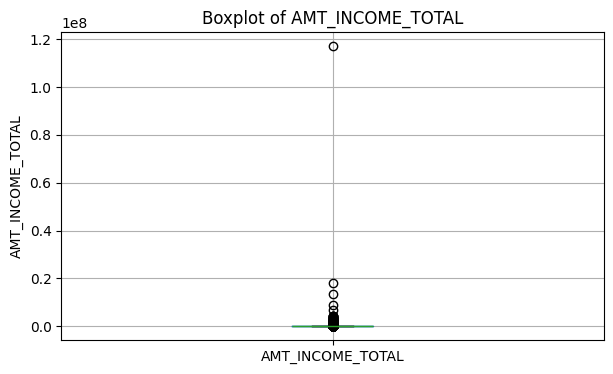

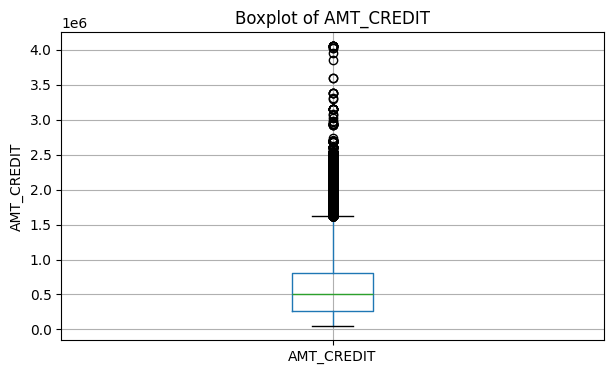

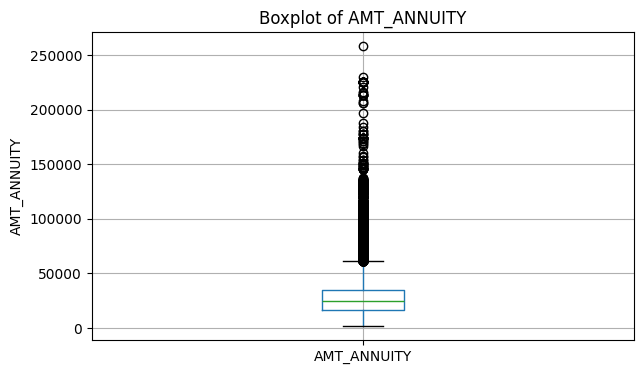

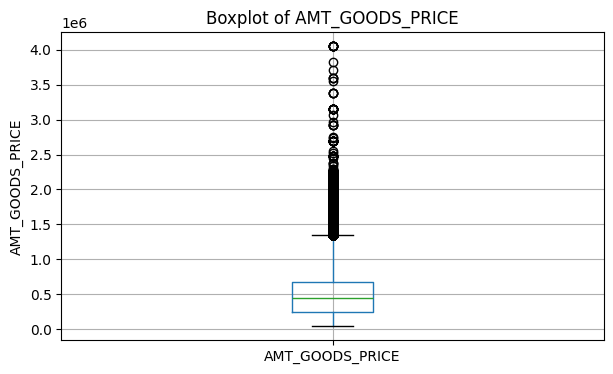

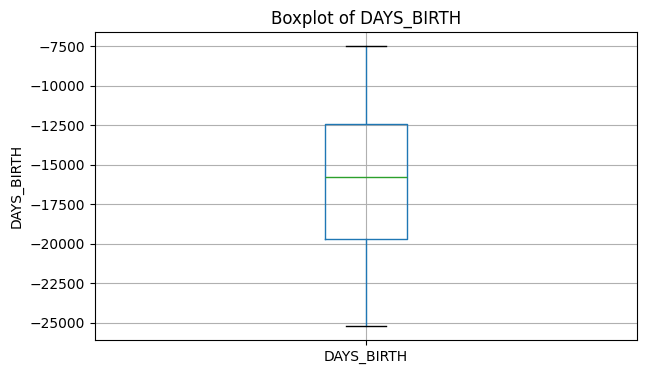

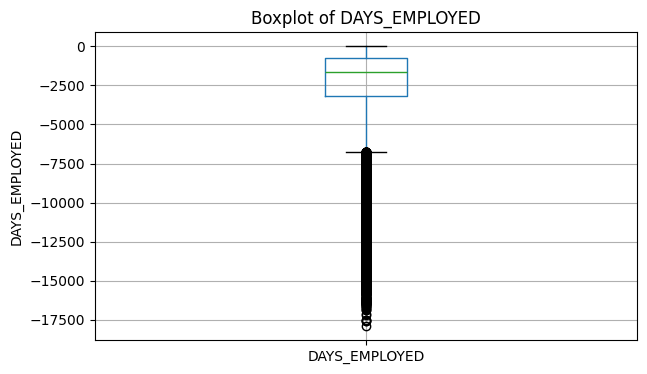

In [ ]:
# Boxplots for selected variables
key_outlier_plot_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

for col in key_outlier_plot_cols:
    if col in app_train_clean.columns:
        plt.figure(figsize=(7, 4))
        app_train_clean.boxplot(column=col)
        plt.title(f"Boxplot of {col}")
        plt.ylabel(col)
        plt.show()

### Interpretation of Boxplots

The boxplots confirm that several key numerical variables contain extreme values.

`AMT_INCOME_TOTAL` shows a very large extreme value compared with the rest of the distribution. This suggests that income is highly skewed, with most applicants having much lower income and a small number of applicants having very high income.

`AMT_CREDIT`, `AMT_ANNUITY`, and `AMT_GOODS_PRICE` also show many values above the upper whisker. These variables are financial amounts, so high values may still represent real applicants with larger loans, higher repayment amounts, or more expensive goods.

`DAYS_BIRTH` does not show clear outliers in the boxplot. This suggests that applicant ages are within a reasonable range.

`DAYS_EMPLOYED` shows many lower-end outliers, meaning some applicants have much longer employment histories than most applicants. Since the earlier unrealistic placeholder value `365243` was already handled, these remaining values may represent genuine long employment durations.

Overall, the boxplots show that outliers are present mainly in financial and employment-related variables. However, these values were not removed automatically because they may represent valid applicant information rather than errors.

### Final Outlier Decision

Outliers were identified using both the IQR method and boxplots, but no rows were removed at this stage.

This decision was made because the detected outliers mostly appear in financial variables such as income, credit amount, annuity, and goods price. In a credit-risk dataset, these extreme values can be genuine and may contain useful information for predicting default risk.

The only clearly erroneous value already handled was the `365243` placeholder in day-based columns, which was marked as `NaN`. Other outliers were kept for now and can be handled later through scaling, transformation, capping, or model-specific methods if they negatively affect model performance.

In [ ]:
outlier_boxplot_decision = pd.DataFrame({
    "Column": [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED"
    ],
    "Observation": [
        "Very large extreme values present",
        "Many high-value outliers",
        "Many high-value outliers",
        "Many high-value outliers",
        "No clear outliers visible",
        "Long employment-history outliers remain"
    ],
    "Decision": [
        "Keep for now",
        "Keep for now",
        "Keep for now",
        "Keep for now",
        "No action needed",
        "Keep after placeholder handling"
    ],
    "Reason": [
        "High income may be genuine",
        "Large loan amounts may be valid",
        "High annuity values may match large loans",
        "Expensive goods may be valid",
        "Age range appears reasonable",
        "Remaining values may represent genuine long employment"
    ]
})

outlier_boxplot_decision

,Column,Observation,Decision,Reason
0,AMT_INCOME_TOTAL,Very large extreme values present,Keep for now,High income may be genuine
1,AMT_CREDIT,Many high-value outliers,Keep for now,Large loan amounts may be valid
2,AMT_ANNUITY,Many high-value outliers,Keep for now,High annuity values may match large loans
3,AMT_GOODS_PRICE,Many high-value outliers,Keep for now,Expensive goods may be valid
4,DAYS_BIRTH,No clear outliers visible,No action needed,Age range appears reasonable
5,DAYS_EMPLOYED,Long employment-history outliers remain,Keep after placeholder handling,Remaining values may represent genuine long em...


# Exploratory Data Analysis

## Numerical Feature Distributions

The distributions of selected numerical features were plotted to understand the spread and shape of important financial variables in the main application dataset.

Only four key financial columns were selected for this stage: `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, and `AMT_GOODS_PRICE`. These columns were chosen because they describe the applicant’s income, credit amount, repayment amount, and goods price. They are directly related to the credit-risk problem and are easier to interpret than ID columns, binary flags, or count variables.

This stage does not include every numerical column because plotting all numeric variables would make the analysis too large and less focused. Other variables can be investigated later during feature engineering, correlation analysis, or modelling.

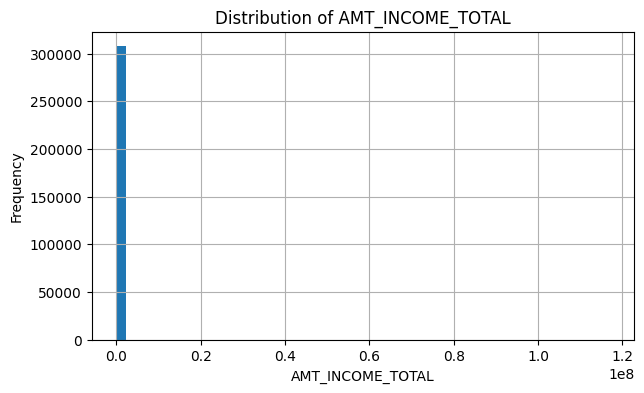

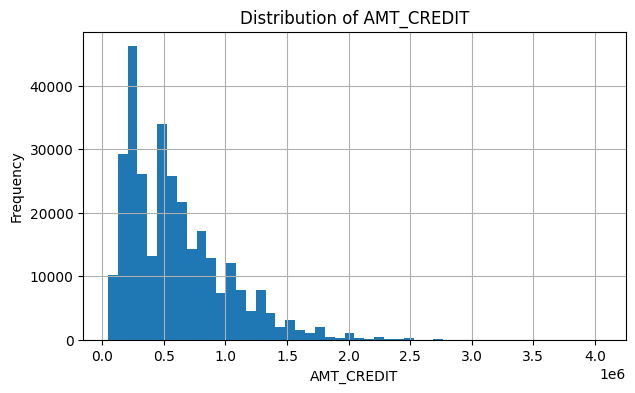

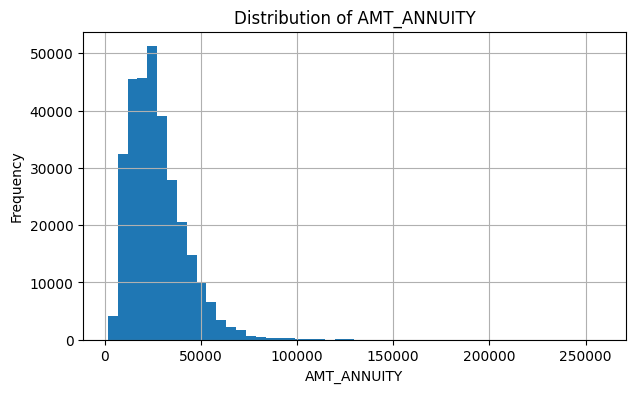

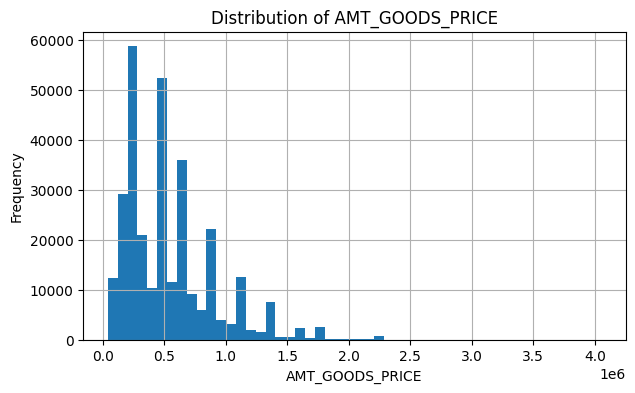

In [ ]:
eda_numeric_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

for col in eda_numeric_cols:
    if col in app_train_clean.columns:
        plt.figure(figsize=(7, 4))
        app_train_clean[col].hist(bins=50)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

### Interpretation of Numerical Distributions

The numerical distribution plots show that the main financial variables are not normally distributed.

`AMT_INCOME_TOTAL` is highly right-skewed. Most applicants have income values within a lower range, while a small number of applicants have very high income values. This matches the earlier outlier analysis, where income showed extreme high values.

`AMT_CREDIT` is also right-skewed. Most credit amounts are concentrated at lower and middle values, with fewer applicants having very large credit amounts.

`AMT_ANNUITY` shows a similar right-skewed pattern. Most applicants have lower or moderate annuity values, while a smaller number have high repayment amounts.

`AMT_GOODS_PRICE` is also right-skewed and appears to have several common price bands, suggesting that many applicants requested credit for goods within common price ranges.

Overall, these plots confirm that the main financial variables are skewed and contain high-value extremes. These values were not removed at this stage because they may represent genuine applicants. However, the skewness suggests that scaling or transformation may be useful later during model preparation.

## Categorical Feature Distributions

After reviewing numerical feature distributions, categorical variables were explored to understand the composition of applicants in the main application dataset.

Selected categorical columns were plotted because they describe important applicant and loan characteristics, such as contract type, gender, car ownership, income type, education level, family status, and housing type.

This step helps identify dominant categories, rare categories, and possible representation differences before modelling.

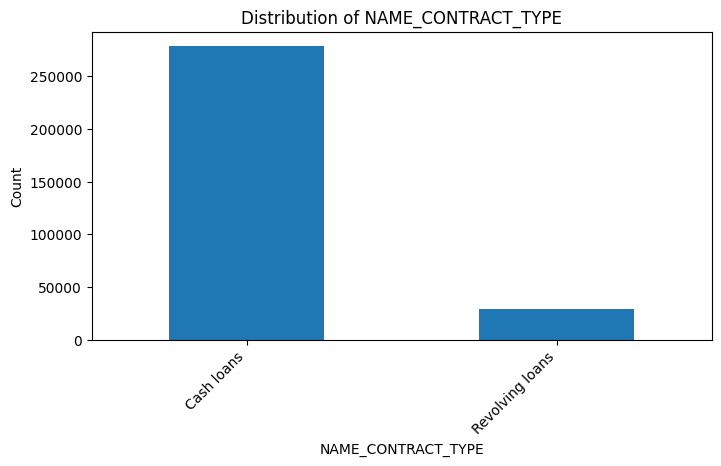

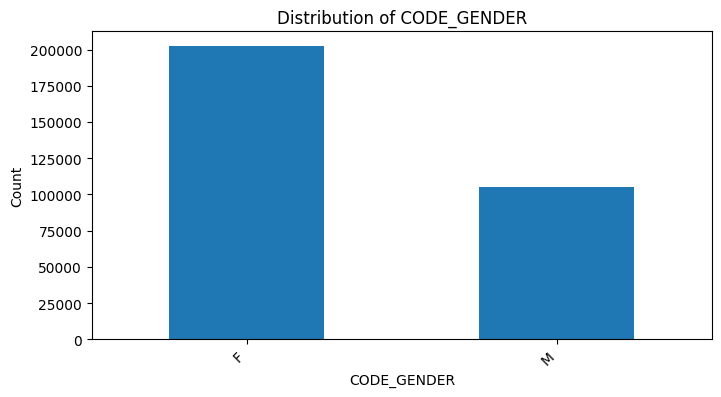

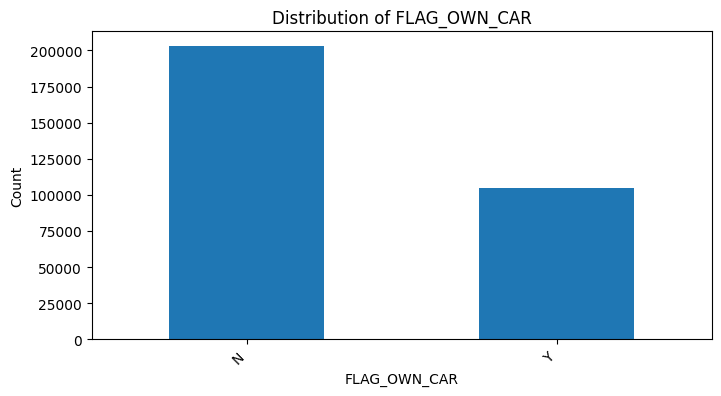

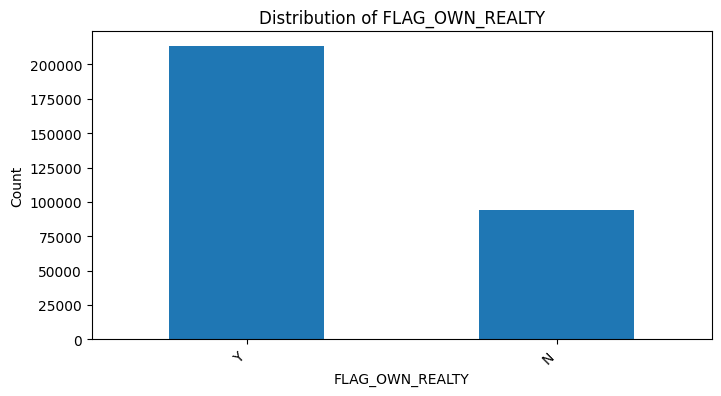

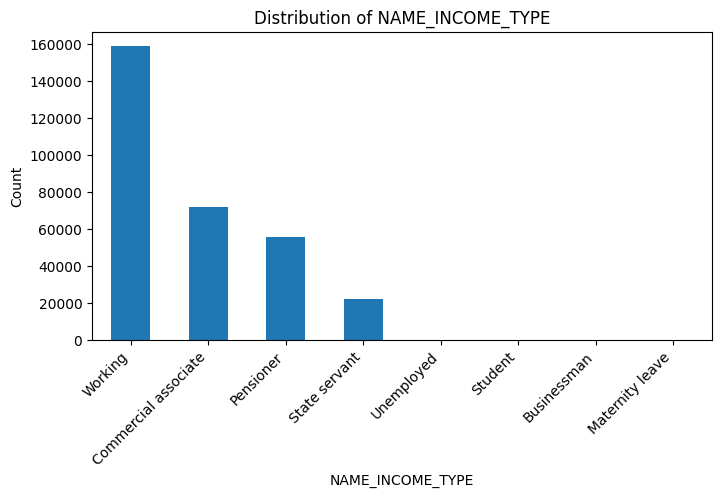

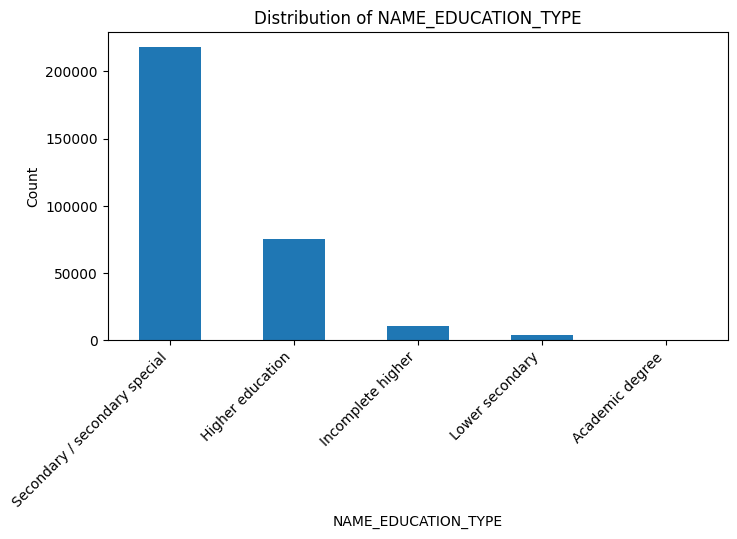

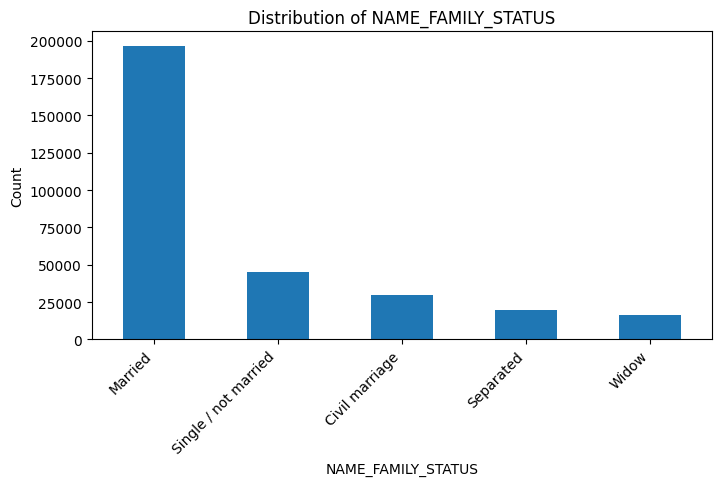

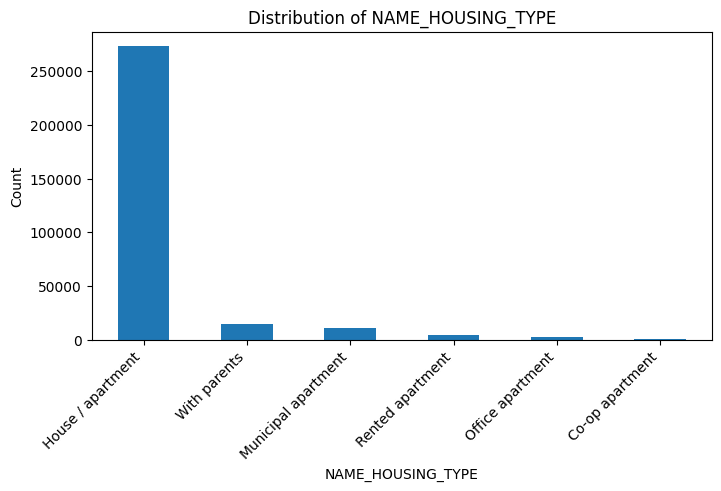

In [ ]:
# Selected categorical columns for EDA
eda_categorical_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

for col in eda_categorical_cols:
    if col in app_train_clean.columns:
        plt.figure(figsize=(8, 4))
        app_train_clean[col].value_counts().plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.show()

In [ ]:
# Percentage distribution of selected categorical columns
for col in eda_categorical_cols:
    if col in app_train_clean.columns:
        print("\n", col)
        display(
            app_train_clean[col]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
            .reset_index()
            .rename(columns={"index": col, col: "Percentage"})
        )


 NAME_CONTRACT_TYPE


,Percentage,proportion
0,Cash loans,90.48
1,Revolving loans,9.52



 CODE_GENDER


,Percentage,proportion
0,F,65.83
1,M,34.16
2,NaN,0.00



 FLAG_OWN_CAR


...

,Percentage,proportion
0,Secondary / secondary special,71.02
1,Higher education,24.34
2,Incomplete higher,3.34
3,Lower secondary,1.24
4,Academic degree,0.05



 NAME_FAMILY_STATUS


,Percentage,proportion
0,Married,63.88
1,Single / not married,14.78
2,Civil marriage,9.68
3,Separated,6.43
4,Widow,5.23
5,NaN,0.00



 NAME_HOUSING_TYPE


,Percentage,proportion
0,House / apartment,88.73
1,With parents,4.83
2,Municipal apartment,3.64
3,Rented apartment,1.59
4,Office apartment,0.85
5,Co-op apartment,0.36


### Interpretation of Categorical Feature Distributions

The categorical feature distributions show that several applicant and loan characteristics are unevenly distributed.

`NAME_CONTRACT_TYPE` shows that most applications are Cash loans, making up about 90.48% of the dataset, while Revolving loans make up about 9.52%. This means the dataset is strongly dominated by Cash loan applications.

`CODE_GENDER` shows that female applicants represent about 65.83% of the dataset, while male applicants represent about 34.16%. The earlier invalid `XNA` gender values were already marked as `NaN`, and the remaining missing percentage is almost zero.

`FLAG_OWN_CAR` shows that most applicants do not own a car, with around 65.99% marked as `N` and 34.01% marked as `Y`.

`FLAG_OWN_REALTY` shows that most applicants own real estate, with around 69.37% marked as `Y` and 30.63% marked as `N`.

`NAME_INCOME_TYPE` shows that the largest group is Working applicants at 51.63%, followed by Commercial associates at 23.29%, Pensioners at 18.00%, and State servants at 7.06%. Very small groups such as Unemployed, Student, Businessman, and Maternity leave have very low representation.

`NAME_EDUCATION_TYPE` shows that most applicants have Secondary / secondary special education at 71.02%, followed by Higher education at 24.34%. Other education groups are much smaller.

`NAME_FAMILY_STATUS` shows that Married applicants form the largest group at 63.88%, followed by Single / not married, Civil marriage, Separated, and Widow.

`NAME_HOUSING_TYPE` shows that most applicants live in a House / apartment, representing 88.73% of the dataset. Other housing categories such as With parents, Municipal apartment, Rented apartment, Office apartment, and Co-op apartment are much smaller.

### Decision from Categorical Distribution Analysis

No categorical values were changed during this EDA step. The purpose of this section was to understand the composition of the dataset before modelling.

The results show that several categorical variables are imbalanced, with some categories appearing much more frequently than others. This is important because models may learn patterns mainly from the dominant groups and perform less reliably for smaller groups.

These categorical variables will be handled later during the data transformation stage using suitable encoding methods, such as label encoding for binary categories and one-hot encoding for nominal categories. The distribution differences will also be useful for later bias and representation analysis.

## Default Rate by Categorical Groups

After checking the distribution of categorical variables, the next step is to compare default rates across selected groups. This helps identify whether some applicant groups have higher or lower proportions of `TARGET = 1`.

This does not prove bias or causation, but it helps highlight patterns that may need closer investigation during modelling and fairness analysis.

In [ ]:
# Function to calculate default rate by category
def default_rate_by_category(df, column):
    summary = (
        df.groupby(column)["TARGET"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"count": "Applicant Count", "mean": "Default Rate"})
    )

    summary["Default Rate (%)"] = (summary["Default Rate"] * 100).round(2)
    summary = summary.drop(columns=["Default Rate"])

    return summary.sort_values("Default Rate (%)", ascending=False)

# Selected categorical columns for default-rate analysis
default_rate_categorical_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

for col in default_rate_categorical_cols:
    if col in app_train_clean.columns:
        print("\n", col)
        display(default_rate_by_category(app_train_clean, col))


 NAME_CONTRACT_TYPE


,NAME_CONTRACT_TYPE,Applicant Count,Default Rate (%)
0,Cash loans,278232,8.35
1,Revolving loans,29279,5.48



 CODE_GENDER


,CODE_GENDER,Applicant Count,Default Rate (%)
1,M,105059,10.14
0,F,202448,7.00



 FLAG_OWN_CAR


...

,NAME_EDUCATION_TYPE,Applicant Count,Default Rate (%)
3,Lower secondary,3816,10.93
4,Secondary / secondary special,218391,8.94
2,Incomplete higher,10277,8.48
1,Higher education,74863,5.36
0,Academic degree,164,1.83



 NAME_FAMILY_STATUS


,NAME_FAMILY_STATUS,Applicant Count,Default Rate (%)
0,Civil marriage,29775,9.94
3,Single / not married,45444,9.81
2,Separated,19770,8.19
1,Married,196432,7.56
4,Widow,16088,5.82



 NAME_HOUSING_TYPE


,NAME_HOUSING_TYPE,Applicant Count,Default Rate (%)
4,Rented apartment,4881,12.31
5,With parents,14840,11.70
2,Municipal apartment,11183,8.54
0,Co-op apartment,1122,7.93
1,House / apartment,272868,7.80
3,Office apartment,2617,6.57


### Interpretation of Default Rate by Categorical Groups

The default-rate tables show that default risk differs across several categorical groups.

For `NAME_CONTRACT_TYPE`, Cash loans have a higher default rate at 8.35%, compared with Revolving loans at 5.48%. This suggests that contract type may be related to repayment difficulty.

For `CODE_GENDER`, male applicants have a higher default rate at 10.14%, while female applicants have a default rate of 7.00%. This difference should be considered carefully in later fairness and bias analysis.

For `FLAG_OWN_CAR`, applicants who do not own a car have a slightly higher default rate at 8.50%, compared with 7.24% for applicants who own a car.

For `FLAG_OWN_REALTY`, applicants who do not own realty have a slightly higher default rate at 8.32%, compared with 7.96% for applicants who own realty. The difference is small.

For `NAME_INCOME_TYPE`, the highest default rates appear for Maternity leave and Unemployed applicants. However, these groups have very small applicant counts, so their percentages should be interpreted with caution. Among larger groups, Working applicants have a higher default rate than Commercial associates, State servants, and Pensioners.

For `NAME_EDUCATION_TYPE`, Lower secondary applicants have the highest default rate at 10.93%, followed by Secondary / secondary special at 8.94%. Higher education and Academic degree groups have lower default rates. This suggests that education level may be related to default risk.

For `NAME_FAMILY_STATUS`, Civil marriage and Single / not married applicants show higher default rates than Married and Widow applicants.

For `NAME_HOUSING_TYPE`, applicants living in Rented apartments and With parents have higher default rates than applicants living in House / apartment or Office apartment. This may suggest that housing situation is related to repayment difficulty.

### Decision from Default Rate Analysis

No values were changed during this stage. The purpose of this analysis was to compare the target variable across important categorical groups.

The results show that some applicant groups have higher observed default rates than others. However, these patterns do not prove causation or discrimination. Some groups also have very small sample sizes, so their default rates may be unstable.

These findings will be useful for later modelling, feature selection, and fairness analysis. Variables such as contract type, gender, car ownership, income type, education type, family status, and housing type may contain predictive information, but they should be handled carefully because some of them may also raise fairness or representation concerns.

# Correlation Analysis

After exploring numerical and categorical features separately, correlation analysis was used to examine relationships between numerical variables and the target variable.

Correlation helps identify numerical features that may be related to default risk. It also helps detect multicollinearity, where two or more features are strongly related to each other and may provide overlapping information.

In [ ]:
# Select numerical columns from the main training dataset
numeric_cols = app_train_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove ID column if present
numeric_cols_for_corr = [col for col in numeric_cols if col != "SK_ID_CURR"]

# Calculate correlations with TARGET
target_corr = (
    app_train_clean[numeric_cols_for_corr]
    .corr()["TARGET"]
    .sort_values()
)

target_corr

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
                                 ...   
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, Length: 105, dtype: float64

In [ ]:
print("Most negative correlations with TARGET:")
display(target_corr.head(15))

print("Most positive correlations with TARGET:")
display(target_corr.tail(15))

Most negative correlations with TARGET:


EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
LIVINGAREA_AVG               -0.032997
LIVINGAREA_MEDI              -0.032739
FLOORSMIN_MODE               -0.032698
Name: TARGET, dtype: float64

Most positive correlations with TARGET:


DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

### Interpretation of Correlation with TARGET

The correlation results show that the strongest negative correlations with `TARGET` are the external source variables: `EXT_SOURCE_3`, `EXT_SOURCE_2`, and `EXT_SOURCE_1`. Since `TARGET = 1` represents repayment difficulty, the negative correlations suggest that higher external source scores are associated with lower default risk.

Some housing and building-related variables such as `FLOORSMAX_AVG`, `FLOORSMAX_MEDI`, `FLOORSMAX_MODE`, `ELEVATORS_AVG`, and `LIVINGAREA_AVG` also have weak negative correlations with the target. This suggests that better housing/building indicators may be slightly associated with lower default risk, although the relationships are weak.

The strongest positive correlations include `DAYS_BIRTH`, `DAYS_EMPLOYED`, `REGION_RATING_CLIENT_W_CITY`, `REGION_RATING_CLIENT`, `DAYS_LAST_PHONE_CHANGE`, and city/region mismatch variables such as `REG_CITY_NOT_WORK_CITY`. Since the day-based variables are stored as negative values, positive correlation must be interpreted carefully. For example, a higher `DAYS_BIRTH` value means the applicant is younger because the value is closer to zero. Therefore, the positive correlation suggests that younger applicants may have a higher default rate.

Overall, the correlations with `TARGET` are not very strong. The external source variables show the strongest relationship, but even these correlations are moderate. This means default risk is likely influenced by a combination of many variables rather than one single feature.

### Correlation Analysis Decision

No features were removed at this stage. Correlation analysis was used only to understand relationships between numerical features and the target variable.

The external source variables appear to be important because they have the strongest negative correlations with `TARGET`. Some time-based, regional, and social-circle variables show weak positive correlations with default risk. However, correlation only measures linear relationships, so weak correlation does not mean a feature is unimportant.

These results will be useful later during feature selection and modelling.

## Correlation Heatmap

A correlation heatmap was created for selected numerical features. This helps visualise relationships between important financial, score, and time-based variables.

The heatmap is useful for identifying features that are related to the target and also for checking possible multicollinearity between predictor variables.

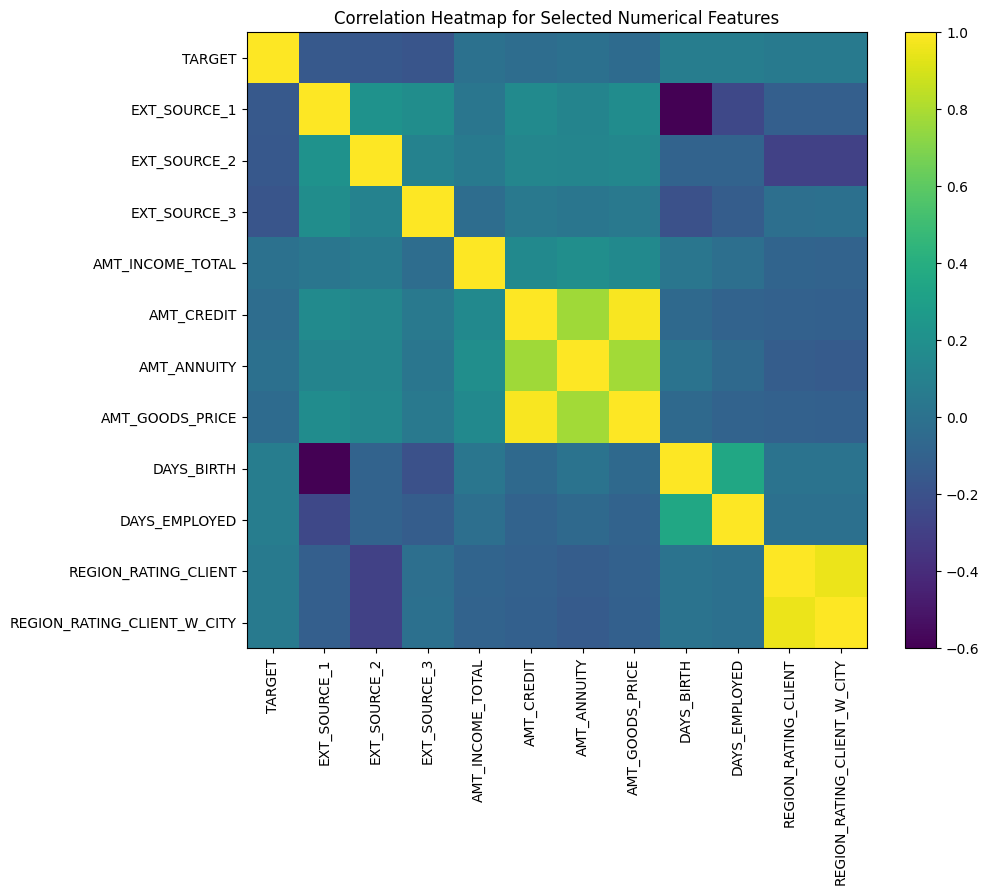

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.003982,-0.030369,-0.012817,-0.039645,0.078239,0.074958,0.058899,0.060893
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.026232,0.168429,0.119398,0.175502,-0.600610,-0.252712,-0.115341,-0.115374
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.060925,0.131228,0.125804,0.139367,-0.091996,-0.093444,-0.292895,-0.288299
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,-0.030229,0.043516,0.030752,0.047717,-0.205478,-0.129722,-0.012903,-0.012158
AMT_INCOME_TOTAL,-0.003982,0.026232,0.060925,-0.030229,1.000000,0.156870,0.191657,0.159610,0.027261,-0.013005,-0.085465,-0.091735
AMT_CREDIT,-0.030369,0.168429,0.131228,0.043516,0.156870,1.000000,0.770138,0.986968,-0.055436,-0.091295,-0.101776,-0.110915
AMT_ANNUITY,-0.012817,0.119398,0.125804,0.030752,0.191657,0.770138,1.000000,0.775109,0.009445,-0.053604,-0.128525,-0.141682
AMT_GOODS_PRICE,-0.039645,0.175502,0.139367,0.047717,0.159610,0.986968,0.775109,1.000000,-0.053442,-0.093374,-0.103786,-0.112208
DAYS_BIRTH,0.078239,-0.600610,-0.091996,-0.205478,0.027261,-0.055436,0.009445,-0.053442,1.000000,0.352321,0.009361,0.008073
DAYS_EMPLOYED,0.074958,-0.252712,-0.093444,-0.129722,-0.013005,-0.091295,-0.053604,-0.093374,0.352321,1.000000,-0.010755,-0.009311


In [ ]:
# Select important numerical columns for heatmap
selected_corr_cols = [
    "TARGET",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY"
]

# Keep only columns that exist in the dataset
selected_corr_cols = [col for col in selected_corr_cols if col in app_train_clean.columns]

corr_matrix = app_train_clean[selected_corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap for Selected Numerical Features")
plt.show()

corr_matrix

### Interpretation of Correlation Heatmap

The correlation heatmap shows several important relationships between selected numerical variables.

The strongest negative correlations with `TARGET` are from the external source variables: `EXT_SOURCE_3`, `EXT_SOURCE_2`, and `EXT_SOURCE_1`. This means that higher external source scores are generally associated with a lower chance of repayment difficulty.

The financial variables show strong relationships with each other. `AMT_CREDIT` and `AMT_GOODS_PRICE` have a very strong positive correlation of about 0.99, which is expected because the credit amount is often closely linked to the price of the goods being financed. `AMT_CREDIT` and `AMT_ANNUITY` also have a strong positive correlation of about 0.77, meaning larger loans usually have larger repayment amounts.

The regional rating variables also show very high correlation. `REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_W_CITY` have a correlation of about 0.95, suggesting that these two variables contain very similar location-based information.

`DAYS_BIRTH` has a positive correlation with `TARGET`. Since `DAYS_BIRTH` is stored as a negative value, higher values are closer to zero and represent younger applicants. This suggests that younger applicants may have a higher default rate. `DAYS_EMPLOYED` also has a positive correlation with `TARGET`, but this should be interpreted carefully because the variable is also stored as negative days.

Overall, the heatmap shows that some variables may contain overlapping information, especially `AMT_CREDIT` and `AMT_GOODS_PRICE`, and the two regional rating variables. However, no features are removed at this stage because this is still exploratory analysis.

### Correlation Heatmap Decision

No variables were removed during the correlation analysis. The heatmap was used only to identify relationships and possible multicollinearity.

The results suggest that some variables may need to be reviewed later during feature selection, especially highly correlated pairs such as `AMT_CREDIT` and `AMT_GOODS_PRICE`, and `REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_W_CITY`.

The external source variables appear important because they have the strongest relationship with the target. These findings will be used later during feature selection and modelling.

## EDA Summary

The exploratory data analysis showed that the Home Credit dataset contains imbalanced target classes, missing values, skewed financial variables, categorical imbalance, and differences in default rates across applicant groups.

The numerical analysis showed that financial variables such as income, credit amount, annuity, and goods price are right-skewed and contain extreme values. These were kept because they may represent genuine applicants. The categorical analysis showed that the dataset is dominated by Cash loans, female applicants, working applicants, secondary-educated applicants, married applicants, and applicants living in houses or apartments.

Default-rate analysis showed that some groups have higher observed default rates than others, such as Cash loan applicants, male applicants, applicants without cars, lower education groups, and applicants living in rented apartments or with parents. These findings do not prove causation, but they highlight useful patterns for later modelling and fairness analysis.

Correlation analysis showed that the external source variables have the strongest negative relationship with the target, while some financial and regional variables are highly correlated with each other. These relationships will be considered later during feature selection and model preparation.

# Section 2

## Data Integration + Feature Engineering

This section creates the **final modelling dataset** from multiple CSV files.

1. Load all CSV files
2. Clean obvious anomalies
3. Aggregate child tables into one row per customer (`SK_ID_CURR`)
4. Apply different feature engineering techniques
5. Encode categorical features
6. Create domain-based financial features
7. Apply basic pre-model feature selection
8. Create both unscaled and scaled datasets for later models


## 1. Imports and configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# Define the path to your folder
dataset_path = '/content/drive/MyDrive/datasets/'

# List the files to make sure you can see them
print(os.listdir(dataset_path))

['HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'sample_submission.csv', 'previous_application.csv']


In [ ]:
from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEBUG = False
NROWS = 30000 if DEBUG else None

MISSING_THRESHOLD = 0.90          # remove columns with >90% missing values
REMOVE_HIGH_CORR = True
CORR_THRESHOLD = 0.90

## 2. Utility functions

Created some utility functions for the repeating code segments.
| Function | Purpose |
|----------|---------|
| `safe_divide()` | Divide two columns without producing `inf` or `NaN` errors |
| `reduce_memory()` | Downcast numeric columns to save RAM |
| `clean_infinite_values()` | Replace all `inf/-inf` with `NaN` |
| `one_hot_encoder()` | Encode categorical columns as binary dummy variables |
| `group()` | Aggregate a secondary table and flatten multi-level column names |
| `group_and_merge()` | Aggregate and merge in one step |

Handling division by 0 - When we divide any number by zero, Python returns 'infinity' (inf). This function replaces any zero in the bottom number with NaN before dividing, so the result is NaN instead of infinity which might cause issues and interprets like something else through out the training.

Since our dataset is big handling memory is important, By default, pandas stores integers as int64 (8 bytes per value) and decimals as float64 (8 bytes). But many of our binary columns only need 0 or 1, which fits in int8 (1 byte). So downcasting reduces memory use by about 40-60%.

one_hot_encoder - This converts text categories into binary (0/1) columns. For example, CODE_GENDER with values 'M' and 'F' becomes two columns: CODE_GENDER_M (1 if male, 0 if not) and CODE_GENDER_F (1 if female, 0 if not).

Why not label encoding (turning 'M' -> 0, 'F' -> 1)?
•	Label encoding implies order: 'F' (1) would appear 'bigger than' 'M' (0). That is meaningless for gender.
•	One-hot encoding has no order: each category gets its own yes/no column.

group and merge functions - These functions summarise a table with many rows per customer into one row per customer. For example, bureau.csv has many rows per customer (one per credit line). We calculate the mean, sum, max, etc. of each column, then join the result to the main training table. Then added a prefix (e.g., 'BUREAU_')  to every column name so we know which table it came from.



In [ ]:
def read_csv(filename, nrows=NROWS):
    print(f"Reading {filename}...")
    return pd.read_csv(filename, nrows=nrows)


def safe_divide(a, b):
    """Divide safely and replace infinite values with NaN."""
    out = a / b.replace({0: np.nan})
    return out.replace([np.inf, -np.inf], np.nan)


def reduce_memory(df, name="dataframe"):
    """Downcast numeric columns to reduce memory usage."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name}: {start:.2f} MB -> {end:.2f} MB")
    return df


def one_hot_encoder(df, categorical_columns=None, nan_as_category=True):
    """One-hot encode categorical columns and return the new dummy column names."""
    original_columns = list(df.columns)
    if categorical_columns is None:
        categorical_columns = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype) == "category"]
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns


def group(df, prefix, aggregations, aggregate_by="SK_ID_CURR"):
    """Group a dataframe and flatten the resulting multi-index column names."""
    valid_aggs = {k: v for k, v in aggregations.items() if k in df.columns}
    if not valid_aggs:
        return df[[aggregate_by]].drop_duplicates()
    agg_df = df.groupby(aggregate_by).agg(valid_aggs)
    agg_df.columns = [f"{prefix}{col}_{stat.upper()}" for col, stat in agg_df.columns]
    return agg_df.reset_index()


def group_and_merge(df_to_agg, df_to_merge, prefix, aggregations, aggregate_by="SK_ID_CURR"):
    if df_to_agg.empty:
        return df_to_merge
    agg_df = group(df_to_agg, prefix, aggregations, aggregate_by)
    return df_to_merge.merge(agg_df, on=aggregate_by, how="left")


def add_group_stat(df, group_cols, target_col, agg_func, new_name):
    """Create group-level statistics, e.g. mean income for similar customer group."""
    if target_col not in df.columns or any(c not in df.columns for c in group_cols):
        return df
    gp = df[group_cols + [target_col]].groupby(group_cols)[target_col].agg(agg_func).reset_index()
    gp = gp.rename(columns={target_col: new_name})
    return df.merge(gp, on=group_cols, how="left")


def clean_infinite_values(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

## 3. Feature engineering techniques used in this notebook

This notebook uses several feature engineering techniques instead of only simple merging:

| Technique | Where it is used | Why it helps |
|---|---|---|
| **Domain-based ratio features** | Application, bureau, previous applications, cross-table ratios | Captures repayment capacity and credit burden |
| **Aggregation features** | Bureau, previous applications, POS, installments, credit card | Converts many historical rows into one customer-level row |
| **Status-specific aggregations** | Active/closed bureau loans, approved/refused previous applications | Separates different risk behaviours |
| **Recent-history features** | Last 6/12/24/36/48/60 months | Gives more weight to recent financial behaviour |
| **Late-payment flags** | Installments, POS, credit cards | Captures repayment difficulty signals |
| **Categorical encoding** | Final train/test preparation | Converts text categories into numeric model inputs |
| **Scaling** | Optional glass-box model dataset | Helps models such as Logistic Regression |
| **Basic feature selection** | Final cleaning | Removes clearly weak/problematic features before modelling |

The main dataset saved for tree-based black-box models is **encoded but not scaled**. A second scaled dataset is saved for glass-box models.




## Target Encoding (for High-Cardinality Columns)
Example - `ORGANIZATION_TYPE` has 58 unique values. If we one-hot encode it, we get 58 new binary columns — many will be mostly 0 and add noise to the model. **Target encoding** replaces each category with the **average default rate** for that category. For example:
- `"Self-employed"` → 0.095 (9.5% default rate)
- `"Government"` → 0.054 (5.4% default rate)

This gives **one column** with meaningul value instead of 58 binary ones.

Out-of-Fold (OOF) -If we compute the mean default rate on the **full training set** and then use that to encode the same rows, the model sees a "hint" about the target — this is called **data leakage** and which causes overfitting.

The fix is **k-fold out-of-fold encoding**: for each row in fold 5, we compute the mean using folds 1-4 only. Why NOT Just Label Encoding?
Label encoding assigns arbitrary numbers: `"Bank"→0`, `"Self-employed"→1`, `"School"→2`. This implies "School" is twice "Self-employed" — which makes no sense for nominal categories.



## 3. Application table features

### Code Explanation for Application Features

This is one of the most important section because the application table is the main table in the given csvs, every row here is one loan application, and this is what the model will predict on.

**`get_age_label()` function** — This converts the age (in days, which is how Home Credit stores it) into age bins. The bins are not equal-sized and thats intentional. we created non-uniform bins: <27, 27-40, 40-50, 50-65, 65+. This allows the model to capture these non-linear age effects more easily. Note that `DAYS_BIRTH` is stored as negative number (days before the application), so we negate it and divide by 365 to get years.

**`handle_own_car_age()` function** — This is a good example of domain-aware feature creation. The column `OWN_CAR_AGE` has many missing values. A naive approach would just fill all missing with the median. But that would be wrong! If someone doesnt own a car (`FLAG_OWN_CAR == 'N'`), then their car age should be 0, not the median. Only for people who DO own a car but have missing car age should we use the median of other car owners. This kind of context-aware imputation is much better then blind;y  value filling.

**`application_features()` main function**

1. **DAYS_EMPLOYED anomaly** — In the EDA, we found that some rows have `DAYS_EMPLOYED = 365243` (which is about 1000 years of employment). This is obviously a data entry error or a special code for missing/unknown employment. We create a flag column `DAYS_EMPLOYED_ANOMALY` to mark these rows (because the fact that its anomalous might itself be informative), then replace the value with NaN so it doesnt mess up our calculations.

2. **CODE_GENDER XNA** — Some gender values are 'XNA' (not available). We replace with NaN because XNA is not a real gender category. and adding most common value may built a bias to the model, whcih actually incorrect

3. **Document flag summary** — There are about 20 `FLAG_DOCUMENT_X` columns (binary: did the applicant provide document X). Instead of keeping all 20, we create `DOCUMENT_COUNT` (how many documents total) and `DOCUMENT_KURTOSIS` (how unusual is the document pattern). This is feature compression — we reduce 20 columns to 2 more informative ones.

4. **EXT_SOURCE features** — The 3 external source scores are the most powerful predictors. We create mean, min, max, variance, product, and weighted mean. The variance captures how consistent the scores are — if one bureau gives 0.8 and another gives 0.2, thats a red flag. The product is high only when ALL scores are high, making it a strong positive signal.

5. **Financial ratios** — Created some meaningful values using the available features. `CREDIT_TO_INCOME_RATIO` tells us how many times the persons income the loan is. Someone taking a loan thats 10x their income is much riskier than someone taking 2x.

6. **Time ratios** — `EMPLOYED_TO_BIRTH_RATIO` is what fraction of their life the person has been employed. A 50-year-old who has been employed for 25 years (ratio = 0.5) is more stable then a 50-year-old employed only 2 years (ratio = 0.04).

7. **Group statistics** — We group customers by their organization type, education, occupation, age range, and gender, then calculate the mean and std of income, credit, annuity, and external scores for each group. This creates features like "average income for people with same job and education". The model can then learn that a customer who earns much less then their peer group is riskier.


In [ ]:
def get_age_label(days_birth):
    age_years = -days_birth / 365
    if pd.isna(age_years):
        return np.nan
    if age_years < 27:
        return 1
    elif age_years < 40:
        return 2
    elif age_years < 50:
        return 3
    elif age_years < 65:
        return 4
    elif age_years < 99:
        return 5
    return 0


def handle_own_car_age(train, test):
    for df in [train, test]:
        if "OWN_CAR_AGE" in df.columns:
            df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype(int)

            if "FLAG_OWN_CAR" in df.columns:
                df.loc[
                    (df["FLAG_OWN_CAR"] == "N") & (df["OWN_CAR_AGE"].isna()),
                    "OWN_CAR_AGE"
                ] = 0

    if "OWN_CAR_AGE" in train.columns and "FLAG_OWN_CAR" in train.columns:
        median_car_age = train.loc[
            (train["FLAG_OWN_CAR"] == "Y") & (train["OWN_CAR_AGE"].notna()),
            "OWN_CAR_AGE"
        ].median()

        for df in [train, test]:
            df.loc[
                (df["FLAG_OWN_CAR"] == "Y") & (df["OWN_CAR_AGE"].isna()),
                "OWN_CAR_AGE"
            ] = median_car_age

    return train, test


def application_features():
    file_name1 = "application_train.csv"
    file_name2 = "application_test.csv"
    train = read_csv(dataset_path + file_name1)
    test = read_csv(dataset_path + file_name2)

    for df in [train, test]:
        if "DAYS_EMPLOYED" in df.columns:
            df["DAYS_EMPLOYED_ANOMALY"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
            df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    train, test = handle_own_car_age(train, test)

    test["TARGET"] = np.nan
    df = pd.concat([train, test], axis=0, ignore_index=True)
    print("Application combined shape:", df.shape)

    # Obvious anomalies / missing-value codes
    if "CODE_GENDER" in df.columns:
        df["CODE_GENDER"] = df["CODE_GENDER"].replace("XNA", np.nan)
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    if "DAYS_LAST_PHONE_CHANGE" in df.columns:
        df["DAYS_LAST_PHONE_CHANGE"] = df["DAYS_LAST_PHONE_CHANGE"].replace(0, np.nan)

    # Document flag summary features
    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT")]
    if doc_cols:
        df["DOCUMENT_COUNT"] = df[doc_cols].sum(axis=1)
        df["DOCUMENT_KURTOSIS"] = df[doc_cols].kurtosis(axis=1)

    # Age feature
    if "DAYS_BIRTH" in df.columns:
        df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365
        df["AGE_RANGE"] = df["DAYS_BIRTH"].apply(get_age_label)

    # External source features
    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df.columns]
    if len(ext_cols) >= 2:
        df["EXT_SOURCES_MEAN"] = df[ext_cols].mean(axis=1)
        df["EXT_SOURCES_MIN"] = df[ext_cols].min(axis=1)
        df["EXT_SOURCES_MAX"] = df[ext_cols].max(axis=1)
        df["EXT_SOURCES_VAR"] = df[ext_cols].var(axis=1)
    if all(c in df.columns for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
        df["EXT_SOURCES_PROD"] = df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"]
        df["EXT_SOURCES_WEIGHTED"] = 2 * df["EXT_SOURCE_1"] + df["EXT_SOURCE_2"] + 3 * df["EXT_SOURCE_3"]

    # Core financial ratios
    if all(c in df.columns for c in ["AMT_CREDIT", "AMT_ANNUITY"]):
        df["CREDIT_TO_ANNUITY_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_ANNUITY"])
    if all(c in df.columns for c in ["AMT_CREDIT", "AMT_GOODS_PRICE"]):
        df["CREDIT_TO_GOODS_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
    if all(c in df.columns for c in ["AMT_ANNUITY", "AMT_INCOME_TOTAL"]):
        df["ANNUITY_TO_INCOME_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    if all(c in df.columns for c in ["AMT_CREDIT", "AMT_INCOME_TOTAL"]):
        df["CREDIT_TO_INCOME_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])

    # Time ratios
    if all(c in df.columns for c in ["DAYS_EMPLOYED", "DAYS_BIRTH"]):
        df["EMPLOYED_TO_BIRTH_RATIO"] = safe_divide(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])
    if all(c in df.columns for c in ["DAYS_ID_PUBLISH", "DAYS_BIRTH"]):
        df["ID_TO_BIRTH_RATIO"] = safe_divide(df["DAYS_ID_PUBLISH"], df["DAYS_BIRTH"])
    if all(c in df.columns for c in ["DAYS_LAST_PHONE_CHANGE", "DAYS_BIRTH"]):
        df["PHONE_TO_BIRTH_RATIO"] = safe_divide(df["DAYS_LAST_PHONE_CHANGE"], df["DAYS_BIRTH"])

    # Group statistics for similar applicants
    group_cols = [c for c in ["ORGANIZATION_TYPE", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE", "AGE_RANGE", "CODE_GENDER"] if c in df.columns]
    if len(group_cols) >= 2:
        for target_col, prefix in [("EXT_SOURCES_MEAN", "GROUP_EXT"), ("AMT_INCOME_TOTAL", "GROUP_INCOME"), ("AMT_CREDIT", "GROUP_CREDIT"), ("AMT_ANNUITY", "GROUP_ANNUITY")]:
            if target_col in df.columns:
                df = add_group_stat(df, group_cols, target_col, "mean", f"{prefix}_MEAN")
                df = add_group_stat(df, group_cols, target_col, "std", f"{prefix}_STD")

    return clean_infinite_values(df)

## 4. Bureau and bureau_balance features

Bureau data contains records from **external credit bureaus** — other banks and lenders who have given the applicant loans in the past.



1. **Bureau-level engineered features** — Before aggregating to customer level, we first create features at the individual credit-line level:
   - `CREDIT_DURATION` = how long was the credit line (end date minus start date)
   - `DEBT_PERCENTAGE` = what fraction of total credit is still debt
   - `DEBT_CREDIT_DIFF` = absolute difference between credit and debt
   These features capture the health of each individual credit line.

2. **Merge bureau_balance** — We merge the bureau_balance aggregations into the bureau table at the SK_ID_BUREAU level. This adds monthly payment behavior information to each credit line.

3. **STATUS_12345 combined flag** — Instead of keeping separate status columns for each late-payment level (1-5 days late, 6-30 days late, etc.), we combine them into one flag. Any value > 0 means there was some kind of payment problem.

4. **Active vs Closed loan aggregations** — This is a very important factor. A person might have had late payments on loans that are already closed (past behavior) vs having late payments on currently active loans (considerable ongoing risk). We aggregate separately for active and closed loans because the risk interpretation is very different.

5. **Loan-type aggregations** — Different loan types have different risk profiles. Consumer credit, credit card, mortgage, car loan, and microloan all behave differently. We create separate aggregations for each type so the model can learn these different patterns.

6. **Recent history (last 6 and 12 months)** — This is a imporatant point ,recent behavior is more predictive then old behavior. A person who was late 5 years ago but clean recently is very different from someone who started missing payments recently. So we create separate aggregations for only the last 6 and 12 months.

7. **Final bureau-level ratios** — After aggregation, we create overall debt-to-credit ratios. `BUREAU_DEBT_OVER_CREDIT` tells us what percentage of total bureau credit is still owed. Same for active loans only.


In [ ]:
BUREAU_AGG = {
    "SK_ID_BUREAU": ["nunique"],
    "DAYS_CREDIT": ["min", "max", "mean"],
    "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
    "AMT_CREDIT_MAX_OVERDUE": ["max", "mean"],
    "AMT_CREDIT_SUM": ["max", "mean", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["max", "mean", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": ["max", "mean", "sum"],
    "AMT_ANNUITY": ["mean", "max"],
    "DEBT_CREDIT_DIFF": ["mean", "sum"],
    "DEBT_PERCENTAGE": ["mean"],
    "CREDIT_TO_ANNUITY_RATIO": ["mean", "max"],
    "STATUS_0": ["mean"],
    "STATUS_12345": ["mean"],
    "STATUS_C": ["mean"],
    "STATUS_X": ["mean"],
    "CREDIT_ACTIVE_Active": ["mean"],
    "CREDIT_ACTIVE_Closed": ["mean"],
}

BUREAU_TIME_AGG = {
    "AMT_CREDIT_SUM": ["sum", "mean"],
    "AMT_CREDIT_SUM_DEBT": ["sum", "mean"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean"],
    "DEBT_PERCENTAGE": ["mean"],
    "STATUS_12345": ["mean"],
}


def get_bureau_balance_features():
    file_name = "bureau_balance.csv"
    bb = read_csv(dataset_path + file_name)
    bb, cat_cols = one_hot_encoder(bb, nan_as_category=False)

    bb_agg = bb.groupby("SK_ID_BUREAU").agg({"MONTHS_BALANCE": ["min", "max", "mean", "size"]})
    bb_agg.columns = ["MONTHS_BALANCE_MIN", "MONTHS_BALANCE_MAX", "MONTHS_BALANCE_MEAN", "MONTHS_BALANCE_SIZE"]
    bb_agg = bb_agg.reset_index()

    if cat_cols:
        bb_cat = bb.groupby("SK_ID_BUREAU")[cat_cols].mean().reset_index()
        bb_agg = bb_agg.merge(bb_cat, on="SK_ID_BUREAU", how="left")

    del bb
    gc.collect()
    return bb_agg


def get_bureau_features():
    file_name = "bureau.csv"
    bureau = read_csv(dataset_path + file_name)

    # Bureau-level engineered features
    if all(c in bureau.columns for c in ["DAYS_CREDIT", "DAYS_CREDIT_ENDDATE"]):
        bureau["CREDIT_DURATION"] = -bureau["DAYS_CREDIT"] + bureau["DAYS_CREDIT_ENDDATE"]
    if all(c in bureau.columns for c in ["DAYS_CREDIT_ENDDATE", "DAYS_ENDDATE_FACT"]):
        bureau["ENDDATE_DIF"] = bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_ENDDATE_FACT"]
    if all(c in bureau.columns for c in ["AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT"]):
        bureau["DEBT_PERCENTAGE"] = safe_divide(bureau["AMT_CREDIT_SUM_DEBT"], bureau["AMT_CREDIT_SUM"])
        bureau["DEBT_CREDIT_DIFF"] = bureau["AMT_CREDIT_SUM"] - bureau["AMT_CREDIT_SUM_DEBT"]
    if all(c in bureau.columns for c in ["AMT_CREDIT_SUM", "AMT_ANNUITY"]):
        bureau["CREDIT_TO_ANNUITY_RATIO"] = safe_divide(bureau["AMT_CREDIT_SUM"], bureau["AMT_ANNUITY"])

    bureau, cat_cols = one_hot_encoder(bureau, nan_as_category=False)

    # Merge bureau_balance information at SK_ID_BUREAU level
    bb = get_bureau_balance_features()
    bureau = bureau.merge(bb, on="SK_ID_BUREAU", how="left")
    del bb
    gc.collect()

    # Combined late-status flag: any status 1-5 means payment problem history
    status_cols = [f"STATUS_{i}" for i in range(1, 6) if f"STATUS_{i}" in bureau.columns]
    if status_cols:
        bureau["STATUS_12345"] = bureau[status_cols].sum(axis=1)

    bureau_agg = group(bureau, "BUREAU_", BUREAU_AGG)

    # Active and closed loan aggregations
    if "CREDIT_ACTIVE_Active" in bureau.columns:
        active = bureau[bureau["CREDIT_ACTIVE_Active"] == 1]
        bureau_agg = group_and_merge(active, bureau_agg, "BUREAU_ACTIVE_", BUREAU_AGG)
    if "CREDIT_ACTIVE_Closed" in bureau.columns:
        closed = bureau[bureau["CREDIT_ACTIVE_Closed"] == 1]
        bureau_agg = group_and_merge(closed, bureau_agg, "BUREAU_CLOSED_", BUREAU_AGG)

    # Loan-type aggregations
    for credit_type in ["Consumer credit", "Credit card", "Mortgage", "Car loan", "Microloan"]:
        col = f"CREDIT_TYPE_{credit_type}"
        if col in bureau.columns:
            prefix = "BUREAU_" + credit_type.split()[0].upper() + "_"
            bureau_agg = group_and_merge(bureau[bureau[col] == 1], bureau_agg, prefix, BUREAU_TIME_AGG)

    # Recent bureau history: last 6 and 12 months
    if "DAYS_CREDIT" in bureau.columns:
        for months in [6, 12]:
            recent = bureau[bureau["DAYS_CREDIT"] >= -30 * months]
            bureau_agg = group_and_merge(recent, bureau_agg, f"BUREAU_LAST{months}M_", BUREAU_TIME_AGG)

    # Final bureau-level ratios
    if all(c in bureau_agg.columns for c in ["BUREAU_AMT_CREDIT_SUM_DEBT_SUM", "BUREAU_AMT_CREDIT_SUM_SUM"]):
        bureau_agg["BUREAU_DEBT_OVER_CREDIT"] = safe_divide(bureau_agg["BUREAU_AMT_CREDIT_SUM_DEBT_SUM"], bureau_agg["BUREAU_AMT_CREDIT_SUM_SUM"])
    if all(c in bureau_agg.columns for c in ["BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_SUM", "BUREAU_ACTIVE_AMT_CREDIT_SUM_SUM"]):
        bureau_agg["BUREAU_ACTIVE_DEBT_OVER_CREDIT"] = safe_divide(bureau_agg["BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_SUM"], bureau_agg["BUREAU_ACTIVE_AMT_CREDIT_SUM_SUM"])

    del bureau
    gc.collect()
    return clean_infinite_values(bureau_agg)

## 5. Previous application features
This section processes previous_application.csv which contains information about all previous loan applications the customer made at Home Credit (not other banks , thats the bureau data). Each row is one previous application.

**Replace 365243 with NaN** — Same as in the application table, 365243 is a mistaken or "not available" in date columns. We replace with NaN so these dont pollute our aggregations.

2. **Engineered features at application level** — Before aggregating, we create features for each individual previous application:
   - `APPLICATION_CREDIT_DIFF` = amount asked minus amount granted
   - `CREDIT_TO_ANNUITY_RATIO` = total credit divided by monthly payment (approximates loan duration)
   - `SIMPLE_INTERESTS` = simplified interest rate calculation
   - `DAYS_LAST_DUE_DIFF` = difference between original and actual last due date (did the loan end earlier or later then planned?)

3. **Approved vs Refused aggregations** — We split previous applications by their outcome status and aggregate separately. The patterns of approved loans (what amounts, what terms) are different from refused ones. A customer whose refused applications had very high credit amounts shows they have a tendency to over-borrow.

4. **Loan-type aggregations** — Consumer loans, cash loans, and revolving loans have different characteristics. We aggregate each type separately.

5. **Recent applications (last 12 and 24 months)**  If someone applied 5 times in the last year, thats very different from someone who applied once 3 years ago. This may show some behaivours about customers expenses


In [ ]:
PREVIOUS_AGG = {
    "SK_ID_PREV": ["nunique"],
    "AMT_ANNUITY": ["min", "max", "mean"],
    "AMT_APPLICATION": ["min", "max", "mean"],
    "AMT_CREDIT": ["min", "max", "mean", "sum"],
    "AMT_DOWN_PAYMENT": ["max", "mean"],
    "DAYS_DECISION": ["min", "max", "mean"],
    "CNT_PAYMENT": ["max", "mean", "sum"],
    "APPLICATION_CREDIT_DIFF": ["min", "max", "mean"],
    "APPLICATION_CREDIT_RATIO": ["min", "max", "mean", "var"],
    "CREDIT_TO_ANNUITY_RATIO": ["mean", "max"],
    "DOWN_PAYMENT_TO_CREDIT": ["mean"],
    "SIMPLE_INTERESTS": ["mean", "max"],
}


def get_previous_application_features():
    file_name = "previous_application.csv"
    prev = read_csv(dataset_path + file_name)

    # Replace special missing code
    for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
        if col in prev.columns:
            prev[col] = prev[col].replace(365243, np.nan)

    # Engineered previous-application features
    if all(c in prev.columns for c in ["AMT_APPLICATION", "AMT_CREDIT"]):
        prev["APPLICATION_CREDIT_DIFF"] = prev["AMT_APPLICATION"] - prev["AMT_CREDIT"]
        prev["APPLICATION_CREDIT_RATIO"] = safe_divide(prev["AMT_APPLICATION"], prev["AMT_CREDIT"])
    if all(c in prev.columns for c in ["AMT_CREDIT", "AMT_ANNUITY"]):
        prev["CREDIT_TO_ANNUITY_RATIO"] = safe_divide(prev["AMT_CREDIT"], prev["AMT_ANNUITY"])
    if all(c in prev.columns for c in ["AMT_DOWN_PAYMENT", "AMT_CREDIT"]):
        prev["DOWN_PAYMENT_TO_CREDIT"] = safe_divide(prev["AMT_DOWN_PAYMENT"], prev["AMT_CREDIT"])
    if all(c in prev.columns for c in ["AMT_ANNUITY", "CNT_PAYMENT", "AMT_CREDIT"]):
        total_payment = prev["AMT_ANNUITY"] * prev["CNT_PAYMENT"]
        prev["SIMPLE_INTERESTS"] = safe_divide((total_payment / prev["AMT_CREDIT"] - 1), prev["CNT_PAYMENT"])
    if all(c in prev.columns for c in ["DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE"]):
        prev["DAYS_LAST_DUE_DIFF"] = prev["DAYS_LAST_DUE_1ST_VERSION"] - prev["DAYS_LAST_DUE"]

    prev, cat_cols = one_hot_encoder(prev, nan_as_category=False)
    categorical_agg = {c: ["mean"] for c in cat_cols}
    prev_agg = group(prev, "PREV_", {**PREVIOUS_AGG, **categorical_agg})

    # Approved/refused aggregations
    if "NAME_CONTRACT_STATUS_Approved" in prev.columns:
        approved = prev[prev["NAME_CONTRACT_STATUS_Approved"] == 1]
        prev_agg = group_and_merge(approved, prev_agg, "APPROVED_", PREVIOUS_AGG)
    if "NAME_CONTRACT_STATUS_Refused" in prev.columns:
        refused = prev[prev["NAME_CONTRACT_STATUS_Refused"] == 1]
        prev_agg = group_and_merge(refused, prev_agg, "REFUSED_", PREVIOUS_AGG)

    # Previous loan-type aggregations
    for loan_type in ["Consumer loans", "Cash loans", "Revolving loans"]:
        col = f"NAME_CONTRACT_TYPE_{loan_type}"
        if col in prev.columns:
            prefix = "PREV_" + loan_type.split()[0].upper() + "_"
            prev_agg = group_and_merge(prev[prev[col] == 1], prev_agg, prefix, PREVIOUS_AGG)

    # Recent previous applications
    if "DAYS_DECISION" in prev.columns:
        for months in [12, 24]:
            recent = prev[prev["DAYS_DECISION"] >= -30 * months]
            prev_agg = group_and_merge(recent, prev_agg, f"PREV_LAST{months}M_", PREVIOUS_AGG)

    del prev
    gc.collect()
    return clean_infinite_values(prev_agg)

## 6. POS_CASH, installments, and credit card features

These  tables contain the most granular data in the entire dataset , The application table tells us about the person (age, income, job). The bureau table tells us about their history at other banks. But these three tables tell us about their *actual payment behavior* at Home Credit, monthly payment records for each previous loan.

- **POS_CASH_balance.csv** — Monthly balance snapshots for point-of-sale and cash loans. Shows things like how many installments remain, and importantly, `SK_DPD` (days past due) which directly show late payments and behaviour of paying.

- **installments_payments.csv** — Records of each installment payment made by the customer. Contains both the expected payment amount and the actual amount ,

- **credit_card_balance.csv** — Monthly credit card balance data. Shows credit limit usage, ATM withdrawals, minimum payment requirements, and again late payment indicators


**`get_pos_cash_features()` function:**
- Creates the LATE_PAYMENT binary flag from SK_DPD > 0
- One-hot encodes categorical columns
- Aggregates everything to customer level

**`get_installments_features()` function:**
- Calculates PAYMENT_DIFFERENCE (how much was underpaid/overpaid)
- Calculates DPD and DBD from the difference between actual and expected payment dates
- Creates multiple late payment severity flags
- Aggregates to customer level
- Also creates recent-history aggregations for last 36 and 60 months, because payment behavior 5+ years ago is less relevant then recent behavior

**`get_credit_card_features()` function:**
- Calculates credit utilization ratio (LIMIT_USE)
- Calculates payment-to-minimum ratio
- Creates late payment flag
- Aggregates to customer level
- Creates recent-history aggregations for last 12, 24, and 48 months

In [ ]:
POS_AGG = {
    "SK_ID_PREV": ["nunique"],
    "MONTHS_BALANCE": ["min", "max", "size"],
    "CNT_INSTALMENT": ["mean", "max"],
    "CNT_INSTALMENT_FUTURE": ["mean", "max"],
    "SK_DPD": ["max", "mean", "sum", "var"],
    "SK_DPD_DEF": ["max", "mean", "sum"],
    "LATE_PAYMENT": ["mean", "sum"],
}

INSTALLMENTS_AGG = {
    "SK_ID_PREV": ["size", "nunique"],
    "DAYS_ENTRY_PAYMENT": ["min", "max", "mean"],
    "AMT_INSTALMENT": ["min", "max", "mean", "sum"],
    "AMT_PAYMENT": ["min", "max", "mean", "sum"],
    "PAYMENT_DIFFERENCE": ["mean", "max", "sum"],
    "PAYMENT_RATIO": ["mean", "max"],
    "DPD": ["max", "mean", "var"],
    "DBD": ["max", "mean", "var"],
    "LATE_PAYMENT": ["mean", "sum"],
    "SIGNIFICANT_LATE_PAYMENT": ["mean", "sum"],
    "DPD_7": ["mean", "sum"],
    "DPD_15": ["mean", "sum"],
    "PAID_OVER": ["mean", "sum"],
}

CC_AGG = {
    "SK_ID_PREV": ["nunique"],
    "MONTHS_BALANCE": ["min", "max", "size"],
    "AMT_BALANCE": ["max", "mean"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["max", "mean"],
    "AMT_DRAWINGS_ATM_CURRENT": ["max", "sum"],
    "AMT_DRAWINGS_CURRENT": ["max", "sum"],
    "AMT_INST_MIN_REGULARITY": ["max", "mean"],
    "AMT_PAYMENT_TOTAL_CURRENT": ["max", "mean", "sum", "var"],
    "AMT_TOTAL_RECEIVABLE": ["max", "mean"],
    "CNT_DRAWINGS_CURRENT": ["max", "mean", "sum"],
    "SK_DPD": ["mean", "max", "sum"],
    "SK_DPD_DEF": ["max", "sum"],
    "LIMIT_USE": ["max", "mean"],
    "PAYMENT_DIV_MIN": ["min", "mean"],
    "LATE_PAYMENT": ["mean", "sum"],
}


def get_pos_cash_features():
    file_name = "POS_CASH_balance.csv"
    pos = read_csv(dataset_path + file_name)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category=False)
    if "SK_DPD" in pos.columns:
        pos["LATE_PAYMENT"] = (pos["SK_DPD"] > 0).astype(int)

    categorical_agg = {c: ["mean"] for c in cat_cols}
    pos_agg = group(pos, "POS_", {**POS_AGG, **categorical_agg})

    del pos
    gc.collect()
    return clean_infinite_values(pos_agg)


def get_installments_features():
    file_name = "installments_payments.csv"
    pay = read_csv(dataset_path + file_name)

    if all(c in pay.columns for c in ["AMT_INSTALMENT", "AMT_PAYMENT"]):
        pay["PAYMENT_DIFFERENCE"] = pay["AMT_INSTALMENT"] - pay["AMT_PAYMENT"]
        pay["PAYMENT_RATIO"] = safe_divide(pay["AMT_PAYMENT"], pay["AMT_INSTALMENT"])
        pay["PAID_OVER_AMOUNT"] = pay["AMT_PAYMENT"] - pay["AMT_INSTALMENT"]
        pay["PAID_OVER"] = (pay["PAID_OVER_AMOUNT"] > 0).astype(int)

    if all(c in pay.columns for c in ["DAYS_ENTRY_PAYMENT", "DAYS_INSTALMENT"]):
        pay["DPD"] = (pay["DAYS_ENTRY_PAYMENT"] - pay["DAYS_INSTALMENT"]).clip(lower=0)
        pay["DBD"] = (pay["DAYS_INSTALMENT"] - pay["DAYS_ENTRY_PAYMENT"]).clip(lower=0)
        pay["LATE_PAYMENT"] = (pay["DPD"] > 0).astype(int)
        pay["SIGNIFICANT_LATE_PAYMENT"] = (pay["DPD"] >= 15).astype(int)
        pay["DPD_7"] = (pay["DPD"] >= 7).astype(int)
        pay["DPD_15"] = (pay["DPD"] >= 15).astype(int)

    pay_agg = group(pay, "INS_", INSTALLMENTS_AGG)

    # Recent installments history
    if "DAYS_INSTALMENT" in pay.columns:
        for months in [36, 60]:
            recent = pay[pay["DAYS_INSTALMENT"] >= -30 * months]
            pay_agg = group_and_merge(recent, pay_agg, f"INS_LAST{months}M_", INSTALLMENTS_AGG)

    del pay
    gc.collect()
    return clean_infinite_values(pay_agg)


def get_credit_card_features():
    file_name = "credit_card_balance.csv"
    cc = read_csv(dataset_path + file_name)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category=False)

    if all(c in cc.columns for c in ["AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL"]):
        cc["LIMIT_USE"] = safe_divide(cc["AMT_BALANCE"], cc["AMT_CREDIT_LIMIT_ACTUAL"])
    if all(c in cc.columns for c in ["AMT_PAYMENT_CURRENT", "AMT_INST_MIN_REGULARITY"]):
        cc["PAYMENT_DIV_MIN"] = safe_divide(cc["AMT_PAYMENT_CURRENT"], cc["AMT_INST_MIN_REGULARITY"])
    if "SK_DPD" in cc.columns:
        cc["LATE_PAYMENT"] = (cc["SK_DPD"] > 0).astype(int)

    categorical_agg = {c: ["mean"] for c in cat_cols}
    cc_agg = group(cc, "CC_", {**CC_AGG, **categorical_agg})

    # Recent credit card history
    if "MONTHS_BALANCE" in cc.columns:
        for months in [12, 24, 48]:
            recent = cc[cc["MONTHS_BALANCE"] >= -months]
            cc_agg = group_and_merge(recent, cc_agg, f"CC_LAST{months}M_", CC_AGG)

    del cc
    gc.collect()
    return clean_infinite_values(cc_agg)

## 7. Cross-table ratio features

After all tables are merged, we  create ratios that compare the current application to previous loan history.

Specific ratios explained:

BUREAU_INCOME_CREDIT_RATIO — Average bureau credit / total income. Higher values mean the person already has significant credit obligations relative to their income.
BUREAU_ACTIVE_CREDIT_TO_INCOME_RATIO — Same but only for currently active bureau credits. Active debt is more concerning then closed debt.
CURRENT_TO_APPROVED_CREDIT_MEAN_RATIO — Current loan amount vs average of previously approved amounts. If the current loan is much larger then what was approved before, the person might be over-extending.
PAYMENT_MEAN_TO_ANNUITY_RATIO — Average actual payment vs current annuity. If historical payments were smaller, the person might struggle with the new higher payment.
DAYS_DECISION_MEAN_TO_BIRTH and DAYS_CREDIT_MEAN_TO_BIRTH — How early in their life did this person start borrowing? Someone who started at age 20 has a different risk profile then someone who started at 40.
DAYS_DECISION_MEAN_TO_EMPLOYED and DAYS_CREDIT_MEAN_TO_EMPLOYED — Similar but relative to employment duration. Did they start borrowing right when they got employed, or after years of stable employment?

In [ ]:
def add_cross_table_ratios(df):
    ratio_pairs = {
        "BUREAU_INCOME_CREDIT_RATIO": ("BUREAU_AMT_CREDIT_SUM_MEAN", "AMT_INCOME_TOTAL"),
        "BUREAU_ACTIVE_CREDIT_TO_INCOME_RATIO": ("BUREAU_ACTIVE_AMT_CREDIT_SUM_SUM", "AMT_INCOME_TOTAL"),
        "CURRENT_TO_APPROVED_CREDIT_MEAN_RATIO": ("APPROVED_AMT_CREDIT_MEAN", "AMT_CREDIT"),
        "CURRENT_TO_APPROVED_CREDIT_MAX_RATIO": ("APPROVED_AMT_CREDIT_MAX", "AMT_CREDIT"),
        "CURRENT_TO_APPROVED_ANNUITY_MEAN_RATIO": ("APPROVED_AMT_ANNUITY_MEAN", "AMT_ANNUITY"),
        "PAYMENT_MEAN_TO_ANNUITY_RATIO": ("INS_AMT_PAYMENT_MEAN", "AMT_ANNUITY"),
        "DAYS_DECISION_MEAN_TO_BIRTH": ("APPROVED_DAYS_DECISION_MEAN", "DAYS_BIRTH"),
        "DAYS_CREDIT_MEAN_TO_BIRTH": ("BUREAU_DAYS_CREDIT_MEAN", "DAYS_BIRTH"),
        "DAYS_DECISION_MEAN_TO_EMPLOYED": ("APPROVED_DAYS_DECISION_MEAN", "DAYS_EMPLOYED"),
        "DAYS_CREDIT_MEAN_TO_EMPLOYED": ("BUREAU_DAYS_CREDIT_MEAN", "DAYS_EMPLOYED"),
    }

    for new_col, (num_col, den_col) in ratio_pairs.items():
        if num_col in df.columns and den_col in df.columns:
            df[new_col] = safe_divide(df[num_col], df[den_col])

    return clean_infinite_values(df)

This is the final preparation step before we can feed data into models. There are several important things happening here:

**`remove_id_derived_columns()`** — During the aggregation steps, some columns like `SK_ID_BUREAU_NUNIQUE` or `SK_ID_PREV_NUNIQUE` were created from ID fields. While nunique of these is fine (it counts how many credit lines someone has), other aggregations like mean or max of an ID field are meaningless. This function removes any column that contains SK_ID_BUREAU or SK_ID_PREV (except the ones we need to keep like SK_ID_CURR).

**`remove_high_missing_columns()`** — Columns where more then 90% of values are missing cant give reliable information. Even after imputation, the imputed values are just guesses for 90% of the data. Its better to drop such columns. We check missing rate on training data only to avoid information leakage from test data.

**`remove_zero_variance_columns()`** — If a column has only one unique value (e.g., all values are 0), it provides zero information to the model. There is no variance to learn from. These columns waste computation time and memory.

**`remove_high_correlation_columns()`** — When two features are 90%+ correlated, they carry almost the same information. Keeping both increases the dimensionality without adding real information.

**`add_missing_indicators_by_keyword()`** — For important features like EXT_SOURCE,  and AMT_ANNUITY, we create a binary flag column that says "this value was missing". We do this BEFORE imputation because after imputation, the information about missingness is lost. In credit risk, missingness is often informative — for example, if EXT_SOURCE_1 is missing, it might mean the person has no credit history with that bureau, which is itself a risk signal.

**`fill_count_features_with_zero()`** — Count-like features (those containing COUNT, CNT, NUM, NUNIQUE in their name) have a natural interpretation when missing: if a customer has no previous applications, the count of previous applications should be 0, not NaN. This is different from amount features where missing could mean many things.

**`final_encode_and_split()`** — This is the master function that:
1. Splits the combined dataframe back into train and test
2. Adds missing indicators
3. Fills categorical NaN with 'Unknown' (because get_dummies cant handle NaN well)
4. One-hot encodes all categorical columns on the combined train+test to ensure both datasets have the same columns
5. Fills count features with 0
6. Applies feature selection
7. Reduces memory usage


**`create_scaled_glassbox_datasets()`** — For models like Logistic Regression and Neural Networks, we need scaled features (mean=0, std=1). The scaler is fitted ONLY on training data to avoid data leakage — if we fit on train+test, the scaler would "know" about the test data distribution. We first impute missing values with median (fitted on train only), then scale.

**`create_tree_ready_datasets()`** — For tree-based models (Random Forest, XGBoost, LightGBM), scaling is not needed because trees make decisions based on thresholds, not distances. However, sklearn's Random Forest cannot handle NaN values, so we still need to impute. We impute with median but dont scale.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier


def remove_id_derived_columns(df):
    """Remove columns created from identifier fields that should not be predictive features."""
    keep = ["SK_ID_CURR", "TARGET"]
    drop_cols = []
    for col in df.columns:
        if col in keep:
            continue
        if "SK_ID_BUREAU" in col or "SK_ID_PREV" in col:
            drop_cols.append(col)
    print(f"Dropping {len(drop_cols)} ID-derived columns")
    return df.drop(columns=drop_cols, errors="ignore")


def remove_high_missing_columns(train, threshold=MISSING_THRESHOLD):
    """Drop columns where the training data has too many missing values."""
    missing = train.isna().mean()
    drop_cols = missing[missing > threshold].index.tolist()
    drop_cols = [c for c in drop_cols if c not in ["TARGET", "SK_ID_CURR"]]
    print(f"Dropping {len(drop_cols)} high-missing columns")
    return train.drop(columns=drop_cols, errors="ignore")


def remove_zero_variance_columns(train):
    """Drop columns that contain only one unique value in the training data."""
    feature_cols = [c for c in train.columns if c not in ["TARGET", "SK_ID_CURR"]]
    nunique = train[feature_cols].nunique(dropna=False)
    drop_cols = nunique[nunique <= 1].index.tolist()
    print(f"Dropping {len(drop_cols)} zero-variance columns")
    return train.drop(columns=drop_cols, errors="ignore")


def remove_high_correlation_columns(train, threshold=CORR_THRESHOLD):
    """Drop one feature from pairs with very high correlation."""
    if not REMOVE_HIGH_CORR:
        print("Skipping high-correlation removal because REMOVE_HIGH_CORR=False")
        return train, []

    feature_cols = [c for c in train.columns if c not in ["TARGET", "SK_ID_CURR"]]
    corr_matrix = train[feature_cols].corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    drop_cols = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]
    print(f"Dropping {len(drop_cols)} highly correlated columns")
    return train.drop(columns=drop_cols, errors="ignore"), drop_cols


def basic_feature_selection(train):
    """Apply safe pre-model feature selection rules."""
    train = remove_id_derived_columns(train)
    train = remove_high_missing_columns(train)
    train = remove_zero_variance_columns(train)
    train, corr_drop_cols = remove_high_correlation_columns(train)
    print(f"Correlation-dropped columns: {len(corr_drop_cols)}")
    return train


def select_top_features(train, labels, top_k=500):
    """
    Select top features using Random Forest importance.
    Imputation is used only inside this feature-selection step
    because RandomForestClassifier cannot handle NaN.
    """
    imputer = SimpleImputer(strategy="median")
    train_imputed = pd.DataFrame(
        imputer.fit_transform(train),
        columns=train.columns,
        index=train.index
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )
    model.fit(train_imputed, labels)

    importances = pd.Series(
        model.feature_importances_,
        index=train.columns
    )
    top_features = importances.sort_values(ascending=False).head(top_k).index.tolist()
    print(f"Selected top {len(top_features)} features using Random Forest importance")

    return train[top_features], importances.sort_values(ascending=False)


def add_missing_indicators_by_keyword(train):
    """
    Add missing-value indicator flags for important columns/groups.
    This must be done before removing high-missing columns and before imputation.
    """
    missing_keywords = [
        "EXT_SOURCE",
        "OWN_CAR_AGE",
        "AMT_CREDIT_MAX_OVERDUE",
        "AMT_DOWN_PAYMENT",
        "RATE_DOWN_PAYMENT",
        "AMT_ANNUITY"
    ]
    added_flags = 0
    feature_cols = [c for c in train.columns if c not in ["TARGET", "SK_ID_CURR"]]

    for col in feature_cols:
        if any(keyword in col for keyword in missing_keywords):
            if train[col].isna().sum() > 0:
                train[col + "_MISSING"] = train[col].isna().astype(int)
                added_flags += 1

    print(f"Added {added_flags} missing indicator columns")
    return train


def fill_count_features_with_zero(train):
    """
    Fill missing count-like aggregated features with 0.
    Missing counts usually mean the applicant had no historical record.
    """
    count_keywords = ["COUNT", "CNT", "NUM_", "NUNIQUE"]
    count_cols = [
        col for col in train.columns
        if col not in ["TARGET", "SK_ID_CURR"]
        and any(keyword in col.upper() for keyword in count_keywords)
    ]
    for col in count_cols:
        train[col] = train[col].fillna(0)

    print(f"Filled {len(count_cols)} count-like columns with 0")
    return train


def final_encode_and_split(df):
    # Split back into train and test
    train = df[df["TARGET"].notna()].copy()
    train_labels = train["TARGET"].astype(int)
    train = train.drop(columns=["TARGET"])

    # Add missing indicator flags before removing high-missing columns
    train = add_missing_indicators_by_keyword(train)

    # Fill categorical missing values before one-hot encoding
    cat_cols = train.select_dtypes(include=["object", "category"]).columns
    for col in cat_cols:
        train[col] = train[col].fillna("Unknown")

    train = pd.get_dummies(train, dummy_na=False)

    train = fill_count_features_with_zero(train)
    train = basic_feature_selection(train)

    train_ids = train["SK_ID_CURR"].copy()

    train_features, rf_feature_importance = select_top_features(
        train.drop(columns=["SK_ID_CURR"], errors="ignore"),
        train_labels,
        top_k=500
    )

    train_features.insert(0, "SK_ID_CURR", train_ids.values)
    train_features["TARGET"] = train_labels.values

    train_features = reduce_memory(train_features, "final train")

    return train_features


def create_nn_ready_datasets(train, skew_threshold=1.0):
    """
    Create NN-ready dataset:
    1. Median imputation
    2. Skewness check on training data only
    3. log1p transform for highly skewed non-negative non-binary columns
    4. StandardScaler for all features
    """
    y = train["TARGET"].copy()
    train_ids = train["SK_ID_CURR"].copy() if "SK_ID_CURR" in train.columns else None

    X_train = train.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore").copy()

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    skewness = X_train_imp.skew()
    log_cols = []

    for col in X_train_imp.columns:
        unique_vals = set(X_train_imp[col].dropna().unique())
        is_binary = unique_vals.issubset({0, 1})
        train_min = X_train_imp[col].min()

        if skewness[col] > skew_threshold and train_min >= 0 and not is_binary:
            log_cols.append(col)

    print("Highly skewed positive columns log-transformed:", len(log_cols))

    for col in log_cols:
        X_train_imp[col] = np.log1p(X_train_imp[col])

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imp),
        columns=X_train_imp.columns,
        index=X_train_imp.index
    )

    if train_ids is not None:
        X_train_scaled.insert(0, "SK_ID_CURR", train_ids.values)

    X_train_scaled["TARGET"] = y.values

    return X_train_scaled, skewness, log_cols


def create_scaled_glassbox_datasets(train):
    """
    Create imputed + scaled copy for glass-box models (e.g. Logistic Regression).
    """
    y = train["TARGET"].copy()
    train_ids = train["SK_ID_CURR"].copy() if "SK_ID_CURR" in train.columns else None

    drop_cols = [c for c in ["TARGET", "SK_ID_CURR"] if c in train.columns]
    X_train = train.drop(columns=drop_cols)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))

    train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

    if train_ids is not None:
        train_scaled.insert(0, "SK_ID_CURR", train_ids.values)

    train_scaled["TARGET"] = y.values
    return train_scaled


def create_tree_ready_datasets(train):
    """
    Create imputed but unscaled copy for tree/black-box models (e.g. Random Forest).
    sklearn trees cannot handle NaN values, so median imputation is applied.
    """
    y = train["TARGET"].copy()
    train_ids = train["SK_ID_CURR"].copy() if "SK_ID_CURR" in train.columns else None

    drop_cols = [c for c in ["TARGET", "SK_ID_CURR"] if c in train.columns]
    X_train = train.drop(columns=drop_cols)

    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train)

    train_tree = pd.DataFrame(X_train_imputed, columns=X_train.columns)

    if train_ids is not None:
        train_tree.insert(0, "SK_ID_CURR", train_ids.values)

    train_tree["TARGET"] = y.values
    return train_tree

### Top Feature Selection using Random Forest
After all the feature engineering steps, we got 1102 features. Many of these features can be weak or redundant, and handling this big dataset waste many reources, which may actually wont help the model predict better and they can actually make things worse. Too many features can cause overfitting (the model memorize noise instead of learning real patterns), increase training time significantly, and make the model harder to interpret and explain.

So we use Random Forest feature importance which the inbuilt function to rank all features and keep only the top ones (default is top 500). This is a model-based feature selection method, which is more powerful then the basic feature selection we did earlier (removing zero-variance and high-missing columns). The basic selection only removed obviously useless features, but this step actually measures how much each feature contributes to predicting the target.

Why Random Forest for feature selection?
Random Forest is a good choice for this because it naturally provides feature importance scores. It works by building many decision trees, and for each tree, it tracks how much each feature helps reduce prediction error (this is called Gini importance or mean decrease impurity). Features that are used more often in the trees and produce better splits get higher importance scores. Also, Random Forest is robust to outliers and can handle both linear and non-linear relationships, so it gives a fair evaluation of all types of features.

## 9. Run the full feature engineering pipeline

Run this cell to generate the final datasets.

final_train_features.csv / final_test_features.csv — Encoded but NOT imputed or scaled. Best for LightGBM which handles NaN natively.
train_random_forest_ready.csv / test_random_forest_ready.csv — Imputed with median, not scaled. For sklearn tree models.
train_logistic_nn_ready.csv / test_logistic_nn_ready.csv — Imputed and scaled. For Logistic Regression and Neural Networks.


In [ ]:
# 1. Main application table
features = application_features()
print("After application features:", features.shape)

Reading /content/drive/MyDrive/datasets/application_train.csv...
Reading /content/drive/MyDrive/datasets/application_test.csv...
Application combined shape: (356255, 124)
After application features: (356255, 150)


In [ ]:
bureau_features = get_bureau_features()
features = features.merge(bureau_features, on="SK_ID_CURR", how="left")
print("After bureau features:", features.shape)
del bureau_features
gc.collect()


Reading /content/drive/MyDrive/datasets/bureau.csv...
Reading /content/drive/MyDrive/datasets/bureau_balance.csv...
After bureau features: (356255, 294)


0

In [ ]:
# 3. Merge previous application features
previous_features = get_previous_application_features()
features = features.merge(previous_features, on="SK_ID_CURR", how="left")
print("After previous application features:", features.shape)
del previous_features
gc.collect()

Reading /content/drive/MyDrive/datasets/previous_application.csv...
After previous application features: (356255, 685)


0

In [ ]:
# 4. Merge POS_CASH features
pos_features = get_pos_cash_features()
features = features.merge(pos_features, on="SK_ID_CURR", how="left")
print("After POS_CASH features:", features.shape)
del pos_features
gc.collect()

Reading /content/drive/MyDrive/datasets/POS_CASH_balance.csv...
After POS_CASH features: (356255, 711)


0

In [ ]:
# 5. Merge installments features
installments_features = get_installments_features()
features = features.merge(installments_features, on="SK_ID_CURR", how="left")
print("After installments features:", features.shape)
del installments_features
gc.collect()

Reading /content/drive/MyDrive/datasets/installments_payments.csv...
After installments features: (356255, 813)


0

In [ ]:
# 6. Merge credit card features
credit_card_features = get_credit_card_features()
features = features.merge(credit_card_features, on="SK_ID_CURR", how="left")
print("After credit card features:", features.shape)
del credit_card_features
gc.collect()

Reading /content/drive/MyDrive/datasets/credit_card_balance.csv...
After credit card features: (356255, 956)


0

In [ ]:
# 7. Cross-table ratios
features = add_cross_table_ratios(features)
print("After cross-table ratios:", features.shape)

After cross-table ratios: (356255, 966)


In [ ]:
# 8. Final encode and save
final_train = final_encode_and_split(features)
print("Final train shape:", final_train.shape)

Added 62 missing indicator columns
Filled 73 count-like columns with 0
Dropping 22 ID-derived columns
Dropping 30 high-missing columns
Dropping 4 zero-variance columns
Dropping 374 highly correlated columns
Correlation-dropped columns: 374
Selected top 500 features using Random Forest importance
final train: 1100.04 MB -> 702.96 MB
Final train shape: (307511, 502)


In [ ]:
# NN ready: imputed + skew handled + scaled
train_nn_ready, nn_skewness, nn_log_cols = create_nn_ready_datasets(
    final_train,
    skew_threshold=1.0
)

Highly skewed positive columns log-transformed: 305


In [ ]:
# Random Forest ready: imputed only, unscaled
train_tree_ready = create_tree_ready_datasets(final_train)

In [ ]:
# Logistic Regression ready: imputed + scaled
train_scaled_glassbox = create_scaled_glassbox_datasets(final_train)

In [ ]:
# Save master selected features
final_train.to_csv(OUTPUT_DIR / "final_train_features.csv", index=False)

In [ ]:
# Save model-ready datasets

OUTPUT_DIR = Path("/content/drive/MyDrive/datasets")
train_tree_ready.to_csv(OUTPUT_DIR / "train_random_forest_ready.csv", index=False)
train_scaled_glassbox.to_csv(OUTPUT_DIR / "train_logistic_regression_ready.csv", index=False)
train_nn_ready.to_csv(OUTPUT_DIR / "train_neural_network_ready.csv", index=False)

print("Saved all final datasets.")

Saved all final datasets.


In [ ]:
file_name_nn = "train_random_forest_ready.csv"
output1 = read_csv(dataset_path + file_name_nn)

Reading /content/drive/MyDrive/datasets/train_random_forest_ready.csv...


In [ ]:
print(output1.shape)

(307511, 502)


In [ ]:
file_name_nn = "train_logistic_regression_ready.csv"
output2 = read_csv(dataset_path + file_name_nn)

Reading /content/drive/MyDrive/datasets/train_logistic_regression_ready.csv...


In [ ]:
print(output1.shape)

(307511, 502)


## Model Development

# Section 3
## Glass-Box Models & Evaluation

In this section, we develop and evaluate two interpretable (glass-box) machine learning models
for predicting loan default risk: **Logistic Regression** and **Decision Tree**.

Glass-box models are preferred because they are easy to understand and interpret.
We can directly see how the model makes decisions without using additional explanation tools.
This is especially important in credit risk applications, where decisions need to be
transparent and explainable.

This section covers:
- Loading the prepared datasets from Section 2
- Handling class imbalance
- Training and evaluating Logistic Regression
- Training and evaluating Decision Tree
- Comparing both models side by side

Two datasets produced in Section 2 are used in this section.
The scaled dataset (`train_logistic_nn_ready.csv`) is used for Logistic Regression,
as it has already been imputed and standardised, which is essential for
scaling-sensitive models. The unscaled dataset (`train_random_forest_ready.csv`)
is used for the Decision Tree, as tree-based models are invariant to feature
scaling and are best evaluated on the original feature magnitudes.

### 3.1 Loading the Prepared Datasets

In this step, we load the two datasets prepared in Section 2.

For **Logistic Regression**, we use the scaled and imputed dataset
(`train_logistic_nn_ready.csv`). Logistic Regression is sensitive to feature
scaling, if features have very different ranges, some variables can dominate
the model and produce unreliable coefficients. Scaling ensures that all features
contribute more equally to the model.

For the **Decision Tree**, we use the unscaled dataset
(`train_random_forest_ready.csv`). Decision Trees make split decisions based on
feature ranking rather than absolute values, so scaling has no effect on their
results. Using the unscaled dataset is therefore more appropriate and keeps each
model paired with the dataset it was designed for.

Both datasets include all engineered features created in Section 2 by combining
the main application data with the additional tables such as bureau, previous
applications, POS cash, installments, and credit card data.

Before moving to modelling, we check the shape of each dataset and the target
distribution to confirm everything loaded correctly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load scaled dataset for Logistic Regression
file_name_nn = "train_logistic_regression_ready.csv"
train_scaled = read_csv(dataset_path + file_name_nn)

print("=== Scaled Dataset (Logistic Regression) ===")
print("Dataset shape:", train_scaled.shape)
print("Column count:", train_scaled.shape[1])
print("Row count:", train_scaled.shape[0])

# Load unscaled dataset for Decision Tree
file_name_nn = "train_random_forest_ready.csv"
train_unscaled = read_csv(dataset_path + file_name_nn)

print("\n=== Unscaled Dataset (Decision Tree) ===")
print("Dataset shape:", train_unscaled.shape)
print("Column count:", train_unscaled.shape[1])
print("Row count:", train_unscaled.shape[0])

Reading /content/drive/MyDrive/datasets/train_logistic_regression_ready.csv...
=== Scaled Dataset (Logistic Regression) ===
Dataset shape: (307511, 502)
Column count: 502
Row count: 307511
Reading /content/drive/MyDrive/datasets/train_random_forest_ready.csv...

=== Unscaled Dataset (Decision Tree) ===
Dataset shape: (307511, 502)
Column count: 502
Row count: 307511


#### Dataset Overview

Both datasets loaded successfully with 307511 rows and 502 columns,
confirming that the feature engineering pipeline from Section 2 completed correctly.

The two datasets have identical shapes, which is expected, they contain the same
features but differ in scaling. The scaled version has been standardised using
`StandardScaler`, while the unscaled version preserves the original feature
magnitudes.

The 502 columns include features from all data sources: main application data,
bureau, previous applications, POS cash, installments, and credit card tables,
along with engineered ratios, one-hot encoded categorical variables, and missing
value indicators. Two columns (`TARGET` and `SK_ID_CURR`) will be removed before
modelling, leaving 500 predictive features for both models.

### 3.2 Preparing Features and Target Variable

Before training the models, we separate the input features (X) from the target variable (y)
and split the dataset into training and test sets.

The target variable is `TARGET`, where:
- 1 represents a client who experienced payment difficulties (default)
- 0 represents a client who repaid the loan successfully

We also check the class distribution because the Home Credit dataset is known to be
highly imbalanced. In such cases, a model can achieve high accuracy by always predicting
the majority class, which would not be useful in practice.

For this reason, we focus on more informative evaluation metrics such as **Recall**,
**F1-score**, and **ROC-AUC**, instead of relying on accuracy alone.

We apply an 80/20 train-test split with stratification to both datasets separately.
The same `random_state=42` is used for both splits to ensure that each model is
trained and evaluated on equivalent subsets of the data, making the comparison
between Logistic Regression and Decision Tree fair and reproducible.

=== Scaled Dataset (Logistic Regression) ===
Feature matrix shape: (307511, 500)
Target shape: (307511,)

Class Distribution:
         Count  Percentage
TARGET                    
0       282686       91.93
1        24825        8.07


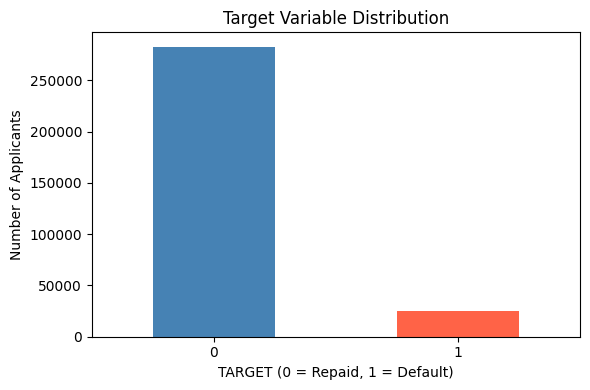


Logistic Regression — Train set shape: (246008, 500)
Logistic Regression — Test set shape: (61503, 500)

Train target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

=== Unscaled Dataset (Decision Tree) ===
Feature matrix shape: (307511, 500)
Target shape: (307511,)

Decision Tree — Train set shape: (246008, 500)
Decision Tree — Test set shape: (61503, 500)

Train target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# === SCALED DATASET — Logistic Regression ===
X_lr = train_scaled.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_lr = train_scaled["TARGET"].astype(int)

print("=== Scaled Dataset (Logistic Regression) ===")
print("Feature matrix shape:", X_lr.shape)
print("Target shape:", y_lr.shape)

# Check class distribution
class_counts = y_lr.value_counts()
class_pct = y_lr.value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct.round(2)
})
print("\nClass Distribution:")
print(class_dist)

# Visualise class distribution
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Target Variable Distribution")
plt.xlabel("TARGET (0 = Repaid, 1 = Default)")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Train/test split for Logistic Regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)

print("\nLogistic Regression — Train set shape:", X_train_lr.shape)
print("Logistic Regression — Test set shape:", X_test_lr.shape)
print("\nTrain target distribution:")
print(y_train_lr.value_counts(normalize=True).mul(100).round(2))
print("\nTest target distribution:")
print(y_test_lr.value_counts(normalize=True).mul(100).round(2))

# === UNSCALED DATASET — Decision Tree ===
X_dt = train_unscaled.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_dt = train_unscaled["TARGET"].astype(int)

print("\n=== Unscaled Dataset (Decision Tree) ===")
print("Feature matrix shape:", X_dt.shape)
print("Target shape:", y_dt.shape)

# Train/test split for Decision Tree
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    random_state=42,
    stratify=y_dt
)

print("\nDecision Tree — Train set shape:", X_train_dt.shape)
print("Decision Tree — Test set shape:", X_test_dt.shape)
print("\nTrain target distribution:")
print(y_train_dt.value_counts(normalize=True).mul(100).round(2))
print("\nTest target distribution:")
print(y_test_dt.value_counts(normalize=True).mul(100).round(2))

#### Class Distribution and Train/Test Split

The class distribution confirms a severe imbalance in both datasets:
- **TARGET = 0 (Repaid):** 282686 applicants — 91.93%
- **TARGET = 1 (Default):** 24825 applicants — 8.07%

This means there are approximately 11.4 non-defaulters for every defaulter.
A naive classifier that always predicts "no default" would achieve over 91% accuracy
without learning anything useful. This is why we focus on Recall, F1-score, and
ROC-AUC rather than accuracy.

The 80/20 stratified split produced identical shapes for both datasets:
- **Training set:** 246008 samples
- **Test set:** 61503 samples

Both the scaled (Logistic Regression) and unscaled (Decision Tree) splits maintain
the exact same 91.93% / 8.07% class ratio across train and test sets. Using the
same `random_state=42` for both splits ensures that each model sees equivalent
subsets of the data, making the final comparison between the two models fair.

### 3.3 Handling Class Imbalance

The class distribution analysis showed that the dataset is highly imbalanced:
around 91.93% of applicants repaid their loans (TARGET = 0), while only
8.07% experienced payment difficulties (TARGET = 1).

This is a common issue in credit risk modelling. If we train a model without
handling this imbalance, it will tend to predict the majority class. In fact,
it could achieve over 90% accuracy by always predicting "no default", without
actually learning anything useful.

In real-world lending, missing a defaulter (false negative) is much more costly
than incorrectly flagging a non-defaulter (false positive). Because of this,
we want the model to pay more attention to the minority class.

To address this, we use `class_weight='balanced'` in both Logistic Regression
and Decision Tree models. This automatically gives higher importance to the
minority class (defaulters), so the model is penalised more when it misclassifies them.

We chose this approach instead of using resampling methods like SMOTE because:
- It keeps the original data unchanged  
- It is simple and computationally efficient  
- It works directly with both models we are using  
- It keeps the modelling process more transparent and reproducible  

To better understand this adjustment, we also compute and display the class
weights used during training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on the training labels
# We use y_train_lr here — both splits have identical class distributions
# so the computed weights apply equally to both Logistic Regression and Decision Tree
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_lr)
class_weight_dict = dict(zip(classes, weights))

print("Computed class weights:")
for cls, w in class_weight_dict.items():
    label = "Repaid (0)" if cls == 0 else "Default (1)"
    print(f"  {label}: {w:.4f}")

print("\nInterpretation:")
print(f"  The default class (1) receives a weight {weights[1]/weights[0]:.1f}x higher")
print(f"  than the repaid class (0) during model training.")
print(f"  This means each defaulter in the training set contributes")
print(f"  {weights[1]/weights[0]:.1f}x more to the loss function than a non-defaulter.")

Computed class weights:
  Repaid (0): 0.5439
  Default (1): 6.1936

Interpretation:
  The default class (1) receives a weight 11.4x higher
  than the repaid class (0) during model training.
  This means each defaulter in the training set contributes
  11.4x more to the loss function than a non-defaulter.


#### Class Weights

The computed class weights show how the imbalance is handled during training:
- **Repaid (0):** 0.5439
- **Default (1):** 6.1936

The default class is given a weight approximately 11.4 times higher than the
repaid class. This matches the class imbalance ratio we observed earlier, where
there are around 11.4 non-defaulters for every defaulter in the dataset.

In practice, this means the model will be penalised much more when it misclassifies
a defaulter compared to misclassifying a non-defaulter. This pushes the model to
pay more attention to the minority class during training.

Since both datasets have identical class distributions, the same weights apply
to both Logistic Regression and Decision Tree.

This is especially important in credit risk modelling, where missing a defaulter
can lead to significant financial loss, while incorrectly rejecting a good applicant
is generally considered less harmful.

### 3.4 Logistic Regression  

Logistic Regression is our first **glass-box model**. It is widely used in credit risk problems because it is simple, transparent, and easy to interpret.  

**Why Logistic Regression?**  

This model estimates the probability of a binary outcome, in our case, whether a customer will default or not, based on the input features. It assumes a linear relationship between the features and the log-odds of the outcome. Because of this, the model is easy to interpret: each coefficient shows how a feature affects the probability of default (both direction and strength).  

This is useful for our research questions. For RQ1, we want to see if a deep learning model performs better than interpretable models, so Logistic Regression provides a solid baseline. For RQ2, we want to understand which features are important, and Logistic Regression helps with this directly through its coefficients.  

**Configuration choices:**

- `class_weight='balanced'` — as established in Section 3.3, this adjusts for the
  11.4:1 class imbalance
- `max_iter=1000` — the default of 100 iterations is often insufficient for
  convergence on large, high-dimensional datasets like ours (1100 features)
- `solver='saga'` — chosen because it supports L1 and L2 regularisation and is
  efficient for large datasets
- `C=0.01` — a smaller C value means stronger regularisation, which helps prevent
  overfitting on a dataset with 1100 features
- `random_state=42` — fixed for reproducibility

**Evaluation metrics:**

We evaluate using Recall, F1-score, ROC-AUC, and a Confusion Matrix.
Accuracy is reported for completeness but is not our primary metric given
the class imbalance established in Section 3.2.

LOGISTIC REGRESSION — TRAINING
Training completed in 2486.6 seconds
Iterations run: 1000

LOGISTIC REGRESSION — EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.97      0.71      0.82     56538
 Default (1)       0.18      0.71      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.71      0.55     61503
weighted avg       0.90      0.71      0.78     61503

ROC-AUC Score: 0.7782


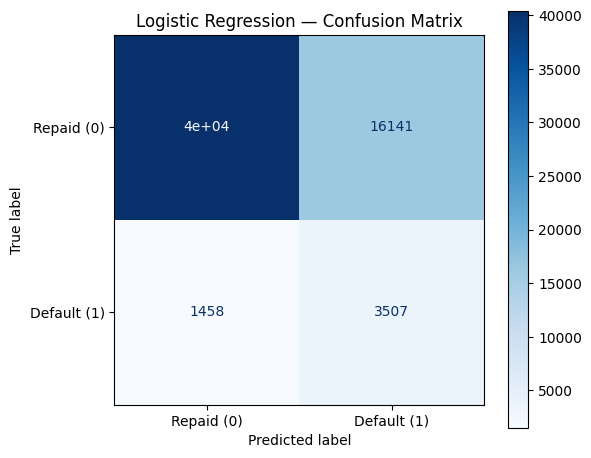

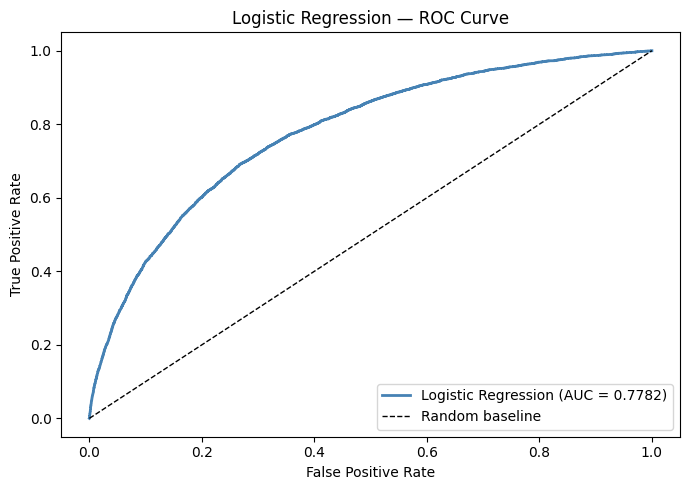

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import time

print("=" * 55)
print("LOGISTIC REGRESSION — TRAINING")
print("=" * 55)

# Initialise Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="saga",
    C=0.01,
    random_state=42,
    n_jobs=-1
)

# Train and time it
start = time.time()
lr_model.fit(X_train_lr, y_train_lr)
lr1000_train_time = time.time() - start
print(f"Training completed in {lr1000_train_time:.1f} seconds")
print(f"Iterations run: {lr_model.n_iter_[0]}")

# Predictions
print("\n" + "=" * 55)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 55)

lr1000_pred = lr_model.predict(X_test_lr)
lr1000_prob = lr_model.predict_proba(X_test_lr)[:, 1]

# ROC-AUC
lr1000_roc_auc = roc_auc_score(y_test_lr, lr1000_prob)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_lr, lr1000_pred,
                            target_names=["Repaid (0)", "Default (1)"]))

print(f"ROC-AUC Score: {lr1000_roc_auc:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_lr, lr1000_pred,
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_lr1000, tpr_lr1000, _ = roc_curve(y_test_lr, lr1000_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr1000, tpr_lr1000, color="steelblue", lw=2,
         label=f"Logistic Regression (AUC = {lr1000_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Logistic Regression Results

Training completed in 2486.6 seconds with 1000 iterations. We can confirm
that full convergence was achieved because the `n_iter_` attribute returned
1000, equal to the configured iteration count, and no convergence warning was observed.

**Evaluation results:**

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Repaid (0) | 0.97 | 0.71 | 0.82 | 56538 |
| Default (1) | 0.18 | 0.71 | 0.28 | 4965 |

**ROC-AUC: 0.7782**

The Default Recall of 0.71 is our most important metric, as the model
successfully identified 71% of actual defaulters in the test set. Without
`class_weight='balanced'`, this would likely collapse close to zero because
the model would heavily favour the majority class.

The Default Precision of 0.18 reflects the expected trade-off in imbalanced
classification: increasing sensitivity to the minority class inevitably generates
more false positives. The Confusion Matrix shows 3507 correctly identified
defaulters against 1458 missed, with 16141 false positives. In a real lending
context, this balance would be tuned based on the relative cost of each error type.

The ROC Curve sits clearly above the random baseline, confirming genuine
discriminative power across all thresholds.

LOGISTIC REGRESSION — TRAINING
Training completed in 4134.7 seconds
Iterations run: 1722

LOGISTIC REGRESSION — EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.97      0.71      0.82     56538
 Default (1)       0.18      0.71      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.71      0.55     61503
weighted avg       0.90      0.71      0.78     61503

ROC-AUC Score: 0.7781


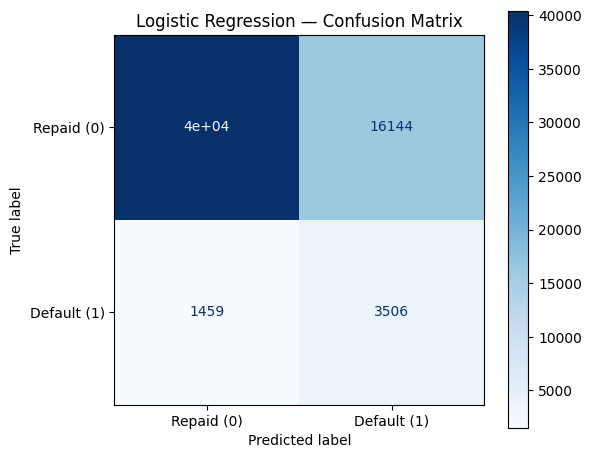

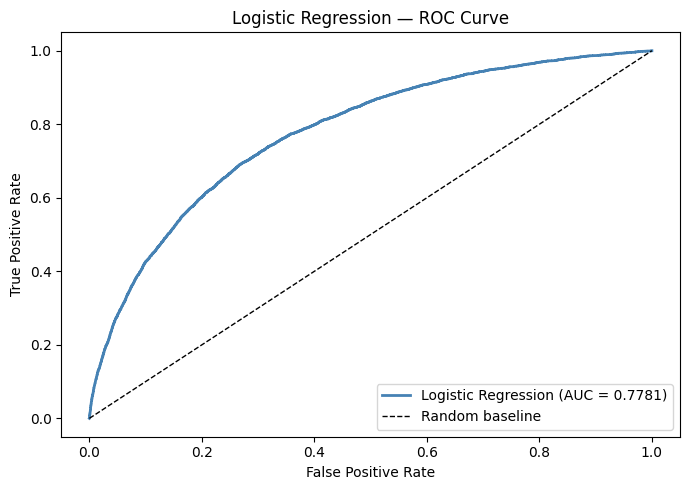

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import time

print("=" * 55)
print("LOGISTIC REGRESSION — TRAINING")
print("=" * 55)

# Initialise Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="saga",
    C=0.01,
    random_state=42,
    n_jobs=-1
)

# Train and time it
start = time.time()
lr_model.fit(X_train_lr, y_train_lr)
lr_train_time = time.time() - start
print(f"Training completed in {lr_train_time:.1f} seconds")
print(f"Iterations run: {lr_model.n_iter_[0]}")

# Predictions
print("\n" + "=" * 55)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 55)

lr_pred = lr_model.predict(X_test_lr)
lr_prob = lr_model.predict_proba(X_test_lr)[:, 1]

# ROC-AUC
lr_roc_auc = roc_auc_score(y_test_lr, lr_prob)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_lr, lr_pred,
                            target_names=["Repaid (0)", "Default (1)"]))

print(f"ROC-AUC Score: {lr_roc_auc:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_lr, lr_pred,
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, lr_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color="steelblue", lw=2,
         label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Convergence Investigation — `max_iter=1000` vs `max_iter=2000`

To check whether increasing the iteration limit would improve the model, we trained another version using `max_iter=2000` and compared the results with the original `max_iter=1000` model.

|  | max_iter=1000 | max_iter=2000 |
|---|---|---|
| Training Time | 2486.6s | 4134.7s |
| Iterations Run | 1000 | 1722 |
| Default Recall | 0.71 | 0.71 |
| Default F1 | 0.28 | 0.28 |
| ROC-AUC | 0.7782 | 0.7781 |
| True Positives | 3507 | 3506 |
| False Negatives | 1458 | 1459 |

As shown in the table, the results are almost exactly the same for both models. Increasing the iteration limit from 1000 to 2000 significantly increased the training time, but it did not improve the model performance. The ROC-AUC score changed by only 0.0001, while Default Recall and F1 score stayed the same.

We also observed that the `n_iter_` value for the second model was 1722, meaning the algorithm required substantially more iterations before stopping. However, despite the longer optimisation process, the final predictive performance remained nearly identical.

Since the performance difference is extremely small and the additional training time is very high, we decided to continue using the **max_iter=1000** model for the rest of the analysis.

### 3.5 Decision Tree

Our second glass-box model is a Decision Tree classifier. Unlike Logistic Regression,
which assumes a linear relationship between features and the target, a Decision Tree
splits the data into smaller groups based on feature values. At each step, the model
chooses the feature and threshold that best separates defaulters from non-defaulters.

**Why Decision Tree?**

Decision Trees are easy to interpret because we can follow the decision path from
the root to a leaf node. This makes it possible to understand how a prediction is made,
which is important in credit risk applications.

They also capture non-linear relationships and interactions between features, which
Logistic Regression cannot do. This makes the Decision Tree a good complementary model,
allowing us to compare how different interpretable models perform on the same problem.

**Configuration choices:**

- `class_weight='balanced'` — same imbalance correction as Logistic Regression
- `max_depth=10` — we deliberately limit tree depth to prevent overfitting.
  An unconstrained Decision Tree on 1,100 features would memorise the training
  data and generalise poorly. Depth 10 allows the tree to learn meaningful
  patterns while remaining somewhat interpretable
- `min_samples_leaf=50` — each leaf must contain at least 50 samples,
  which further reduces overfitting and ensures splits are statistically meaningful
- `criterion='gini'` — Gini impurity is the standard criterion for classification
  trees and is computationally efficient
- `random_state=42` — fixed for reproducibility

Unlike Logistic Regression, the Decision Tree is trained on the unscaled dataset
(`train_random_forest_ready.csv`). Decision Trees make split decisions based on
feature ranking rather than absolute values, so scaling does not affect their
results. Using the unscaled dataset is therefore more appropriate for this model.

DECISION TREE — TRAINING
Training completed in 106.7 seconds
Tree depth reached: 10
Number of leaves: 590

DECISION TREE — EVALUATION

Classification Report:
              precision    recall  f1-score   support

  Repaid (0)       0.96      0.66      0.78     56538
 Default (1)       0.15      0.66      0.24      4965

    accuracy                           0.66     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.66      0.74     61503

ROC-AUC Score: 0.7079


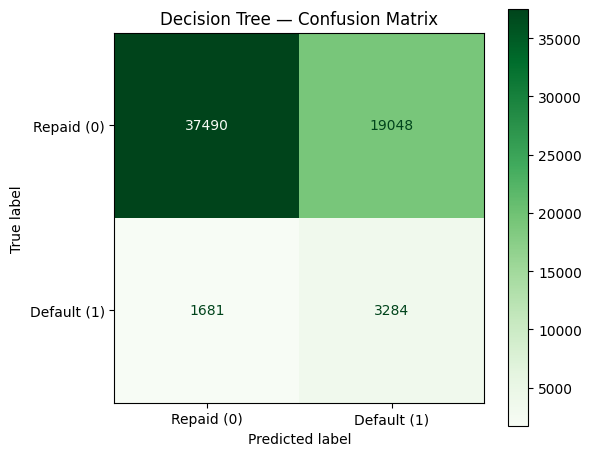

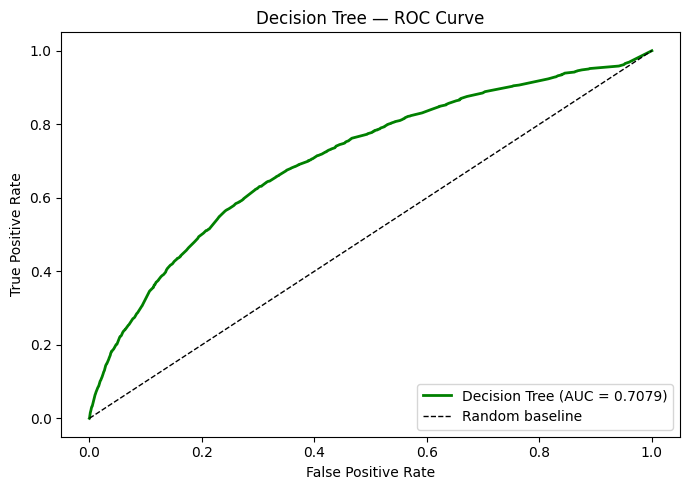

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("=" * 55)
print("DECISION TREE — TRAINING")
print("=" * 55)

# Initialise Decision Tree
dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=50,
    criterion="gini",
    random_state=42
)

# Train and time it
start = time.time()
dt_model.fit(X_train_dt, y_train_dt)
dt_train_time = time.time() - start
print(f"Training completed in {dt_train_time:.1f} seconds")
print(f"Tree depth reached: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

# Predictions
print("\n" + "=" * 55)
print("DECISION TREE — EVALUATION")
print("=" * 55)

dt_pred = dt_model.predict(X_test_dt)
dt_prob = dt_model.predict_proba(X_test_dt)[:, 1]

# ROC-AUC
dt_roc_auc = roc_auc_score(y_test_dt, dt_prob)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_dt, dt_pred,
                            target_names=["Repaid (0)", "Default (1)"]))

print(f"ROC-AUC Score: {dt_roc_auc:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_dt, dt_pred,
    display_labels=["Repaid (0)", "Default (1)"],
    cmap="Greens",
    ax=ax
)
ax.set_title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_dt, dt_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, color="green", lw=2,
         label=f"Decision Tree (AUC = {dt_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Decision Tree Results

Training completed in 106.7 seconds, significantly faster than Logistic
Regression. The tree reached its maximum allowed depth of 10 and produced
590 leaf nodes.

**Evaluation results:**

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| Repaid (0) | 0.96 | 0.66 | 0.78 | 56538 |
| Default (1) | 0.15 | 0.66 | 0.24 | 4965 |

**ROC-AUC: 0.7079**

The Default Recall of 0.66 means the model correctly identified 66% of
actual defaulters. This is slightly lower than Logistic Regression but still
shows that the model captures meaningful patterns in the data.

The Default Precision of 0.15 means that of all applicants flagged as
defaulters, only 15% were genuine defaulters. This is an expected trade-off
when optimising for recall on an imbalanced dataset, as the model flags more
applicants as risky in order to reduce missed defaulters.

The Confusion Matrix shows:
- 37490 non-defaulters correctly classified (True Negatives)
- 19048 non-defaulters incorrectly flagged as defaulters (False Positives)
- 1681 defaulters missed by the model (False Negatives)
- 3284 defaulters correctly identified (True Positives)

The ROC-AUC of 0.7079 indicates moderate discriminative power. The ROC
Curve also shows the characteristic step-like shape of tree-based models,
which produce less smooth probability estimates compared to linear models.

### 3.6 Model Comparison — Logistic Regression vs Decision Tree

In this section, we compare the performance of the two glass-box models:
Logistic Regression and Decision Tree.

The aim is to understand how each model performs and to identify their strengths
and weaknesses before comparing them with the deep learning model in Section 4.

We evaluate both models using the following metrics:
- **Recall (Default class)** — how many actual defaulters did we catch?
- **Precision (Default class)** — of those we flagged, how many were truly defaulters?
- **F1-score (Default class)** — harmonic mean of precision and recall
- **ROC-AUC** — overall discriminative ability across all thresholds
- **Training time** — computational cost

We also plot both ROC curves on the same axes for a direct visual comparison.

GLASS-BOX MODEL COMPARISON SUMMARY
                     Accuracy  Default Precision  Default Recall  Default F1  ROC-AUC  Train Time (s)
Model                                                                                                
Logistic Regression    0.7139             0.1785          0.7063      0.2850   0.7782          2486.6
Decision Tree          0.6630             0.1471          0.6614      0.2406   0.7079           106.7


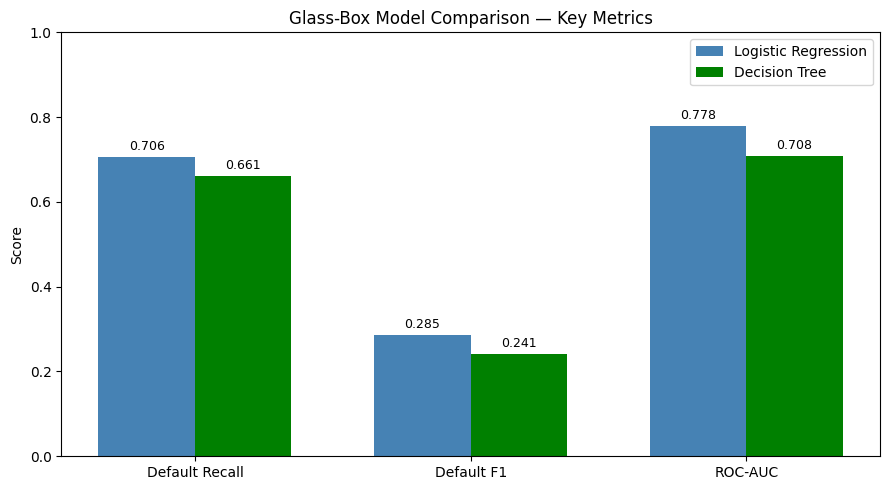

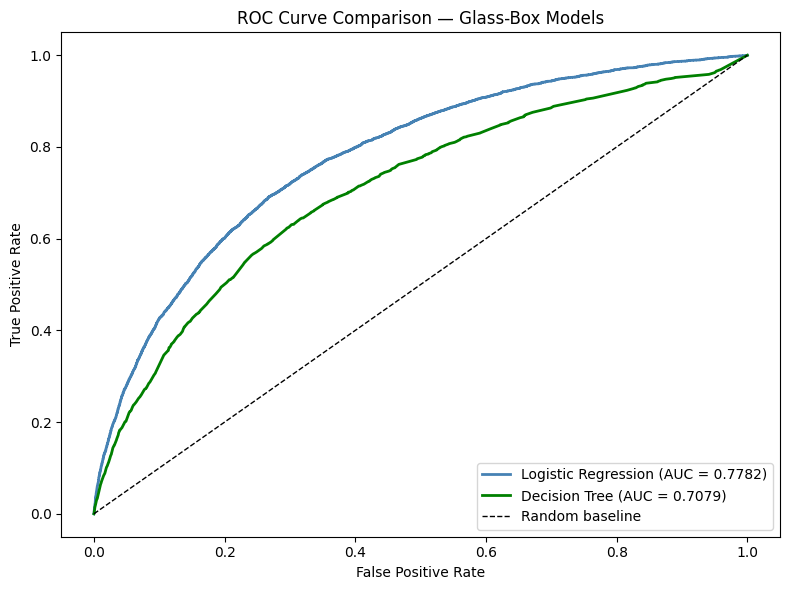


Key Findings:
--------------------------------------------------
  Best Default Recall : Logistic Regression (0.7063)
  Best ROC-AUC        : Logistic Regression (0.7782)
  Best Default F1     : Logistic Regression (0.2850)
  Fastest Training    : Decision Tree (106.7s)

  Logistic Regression outperforms Decision Tree on all
  predictive metrics. Decision Tree trains ~23x faster.


In [ ]:
print("=" * 60)
print("GLASS-BOX MODEL COMPARISON SUMMARY")
print("=" * 60)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test_lr, lr1000_pred),
        accuracy_score(y_test_dt, dt_pred)
    ],
    "Default Precision": [
        precision_score(y_test_lr, lr1000_pred),
        precision_score(y_test_dt, dt_pred)
    ],
    "Default Recall": [
        recall_score(y_test_lr, lr1000_pred),
        recall_score(y_test_dt, dt_pred)
    ],
    "Default F1": [
        f1_score(y_test_lr, lr1000_pred),
        f1_score(y_test_dt, dt_pred)
    ],
    "ROC-AUC": [lr1000_roc_auc, dt_roc_auc],
    "Train Time (s)": [round(lr1000_train_time, 1), round(dt_train_time, 1)]
})

comparison = comparison.set_index("Model")
comparison = comparison.round(4)
print(comparison.to_string())

# Bar chart comparison
metrics = ["Default Recall", "Default F1", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.35

lr_vals = [comparison.loc["Logistic Regression", m] for m in metrics]
dt_vals = [comparison.loc["Decision Tree", m] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_vals, width, label="Logistic Regression", color="steelblue")
bars2 = ax.bar(x + width/2, dt_vals, width, label="Decision Tree", color="green")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Glass-Box Model Comparison — Key Metrics")
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Combined ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr1000, tpr_lr1000, color="steelblue", lw=2,
         label=f"Logistic Regression (AUC = {lr1000_roc_auc:.4f})")
plt.plot(fpr_dt, tpr_dt, color="green", lw=2,
         label=f"Decision Tree (AUC = {dt_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Glass-Box Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Summary interpretation
print("\nKey Findings:")
print("-" * 50)
print(f"  Best Default Recall : Logistic Regression ({comparison.loc['Logistic Regression','Default Recall']:.4f})")
print(f"  Best ROC-AUC        : Logistic Regression ({comparison.loc['Logistic Regression','ROC-AUC']:.4f})")
print(f"  Best Default F1     : Logistic Regression ({comparison.loc['Logistic Regression','Default F1']:.4f})")
print(f"  Fastest Training    : Decision Tree ({comparison.loc['Decision Tree','Train Time (s)']:.1f}s)")
print(f"\n  Logistic Regression outperforms Decision Tree on all")
print(f"  predictive metrics. Decision Tree trains ~{lr1000_train_time/dt_train_time:.0f}x faster.")

#### Comparison Results and Interpretation

The comparison results show that Logistic Regression performs better than the
Decision Tree across all main evaluation metrics:

| Model | Default Recall | Default F1 | ROC-AUC | Train Time |
|-------|---------------|------------|---------|------------|
| Logistic Regression | **0.706** | **0.285** | **0.778** | 2486.6s |
| Decision Tree | 0.661 | 0.241 | 0.708 | **106.7s** |

**Logistic Regression** outperforms the Decision Tree in terms of predictive
performance. The difference in ROC-AUC (around 0.07) is significant, showing that
Logistic Regression has a stronger ability to distinguish between defaulters and
non-defaulters. This is likely because it considers all features together during
training, while Decision Trees make split decisions step by step.

**Decision Tree**, however, has a clear advantage in training speed, being around
23 times faster. This can be important in real-world applications where
computational efficiency matters. It also has strong interpretability, as its
predictions can be explained through simple if-then rules.

The ROC curve comparison further supports these results, with Logistic Regression
consistently performing better across different thresholds.

Overall, both models establish a glass-box performance range between 0.70 and 0.78
ROC-AUC.

### 3.7 Section 3 Summary

In this section, we developed and evaluated two glass-box models for predicting
loan default: Logistic Regression and Decision Tree.

Logistic Regression achieved the best overall performance, with a ROC-AUC of **0.7782**,
a Default Recall of **0.706**, and a Default F1-score of **0.285**. It was able to
identify around 71% of defaulters, making it a strong model for identifying high-risk applicants.

Decision Tree achieved lower performance (ROC-AUC: **0.7079**, Recall: **0.661**),
but it was significantly faster to train. This highlights a trade-off between
performance and computational efficiency.

Both models benefited from using `class_weight='balanced'`, which helped address
the strong class imbalance in the dataset. Without this, the models would mainly
predict the majority class and fail to detect defaulters.

Overall, Logistic Regression provides the stronger glass-box model, while the
Decision Tree offers speed and simplicity. Together, they demonstrate the
performance range achievable with interpretable machine learning approaches on
this dataset.

#
## MODEL COMPARISON — SUMMARY SECTION
#
## Side-by-Side SHAP Analysis: Decision Tree vs Logistic Regression


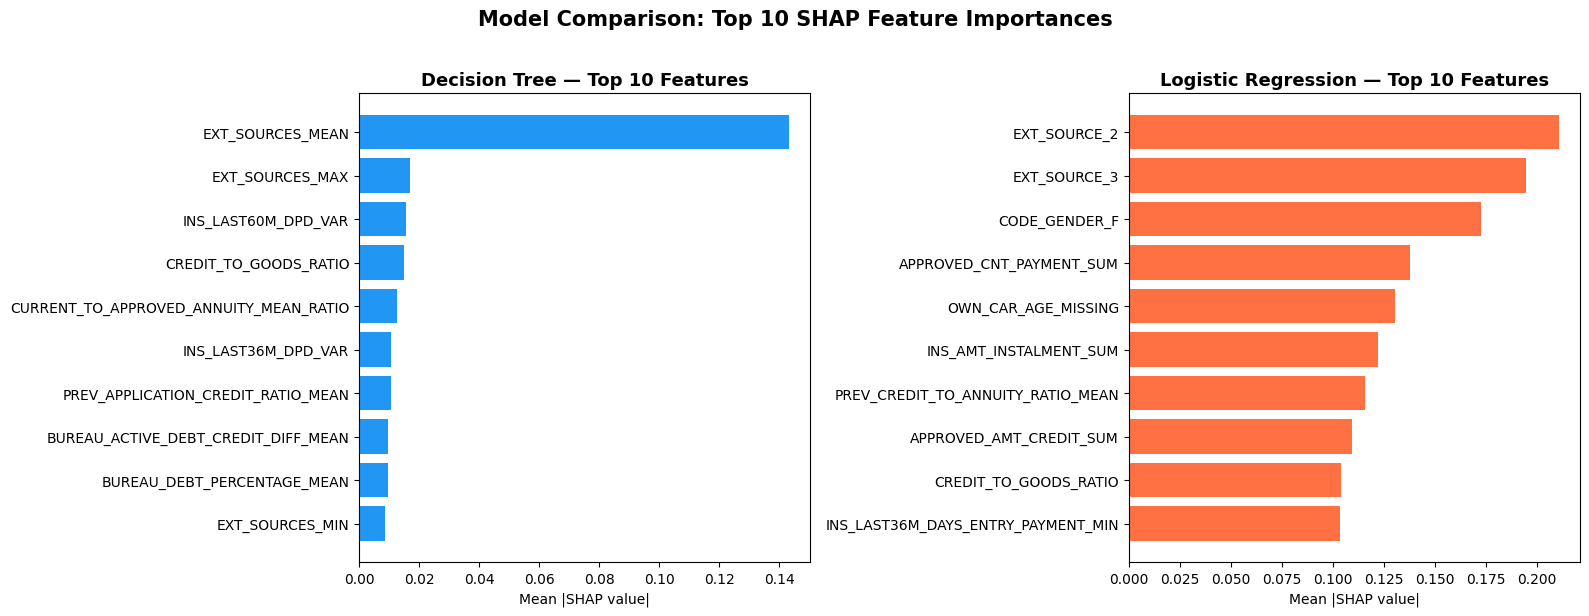

In [ ]:
# ============================================================
# COMPARISON — TOP 10 FEATURES SIDE BY SIDE
# ============================================================

# DT importances
if isinstance(shap_values, list):
    sv_dt = shap_values[1]
elif len(shap_values.shape) == 3:
    sv_dt = shap_values[:, :, 1]
else:
    sv_dt = shap_values

dt_imp = pd.DataFrame({
    'Feature': X_test_dt.columns,
    'Mean |SHAP|': np.abs(sv_dt).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10)

# LR importances
lr_imp = pd.DataFrame({
    'Feature': X_test_lr.columns,
    'Mean |SHAP|': np.abs(lr_shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(dt_imp['Feature'][::-1], dt_imp['Mean |SHAP|'][::-1], color='#2196F3')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Decision Tree — Top 10 Features', fontsize=13, fontweight='bold')

axes[1].barh(lr_imp['Feature'][::-1], lr_imp['Mean |SHAP|'][::-1], color='#FF7043')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Logistic Regression — Top 10 Features', fontsize=13, fontweight='bold')

plt.suptitle('Model Comparison: Top 10 SHAP Feature Importances', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


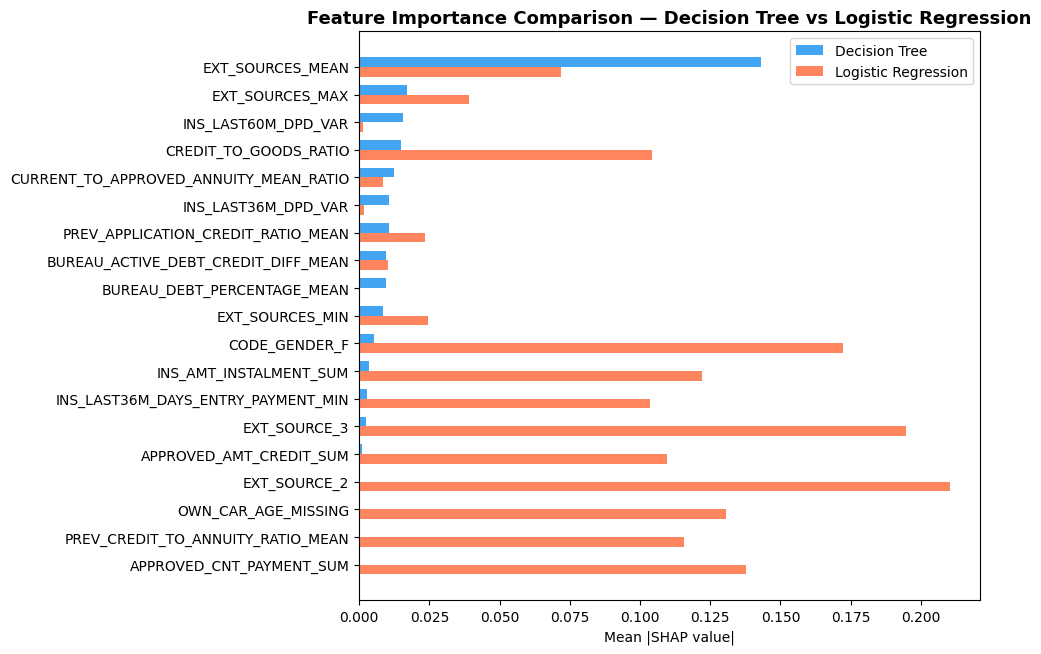

In [ ]:
# ============================================================
# COMPARISON — SHARED TOP FEATURES (Overlapping Bar Chart)
# ============================================================

# Get top 15 from each model
dt_top15 = set(dt_imp['Feature'].head(15))
lr_top15 = set(lr_imp['Feature'].head(15))

# Union of top features
all_top = list(dt_top15 | lr_top15)

dt_dict = dict(zip(
    X_test_dt.columns,
    np.abs(sv_dt).mean(axis=0)
))
lr_dict = dict(zip(
    X_test_lr.columns,
    np.abs(lr_shap_values).mean(axis=0)
))

compare_df = pd.DataFrame({
    'Feature': all_top,
    'Decision Tree': [dt_dict.get(f, 0) for f in all_top],
    'Logistic Regression': [lr_dict.get(f, 0) for f in all_top]
}).sort_values('Decision Tree', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(all_top) * 0.35)))
y = np.arange(len(compare_df))
height = 0.35

ax.barh(y + height/2, compare_df['Decision Tree'], height, label='Decision Tree', color='#2196F3', alpha=0.85)
ax.barh(y - height/2, compare_df['Logistic Regression'], height, label='Logistic Regression', color='#FF7043', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(compare_df['Feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance Comparison — Decision Tree vs Logistic Regression', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


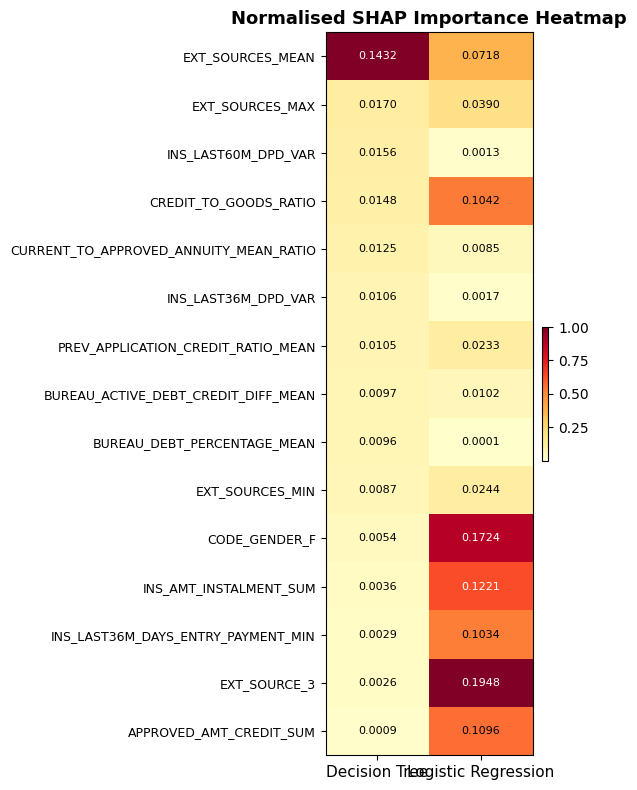

In [ ]:
# ============================================================
# COMPARISON — FEATURE IMPORTANCE HEATMAP
# ============================================================
import matplotlib.colors as mcolors

# Top 15 features from both models combined
all_features_sorted = compare_df.sort_values('Decision Tree', ascending=False)['Feature'].tolist()[:15]

heat_data = pd.DataFrame({
    'Decision Tree': [dt_dict.get(f, 0) for f in all_features_sorted],
    'Logistic Regression': [lr_dict.get(f, 0) for f in all_features_sorted]
}, index=all_features_sorted)

# Normalise each column 0-1 for fair colour comparison
heat_norm = heat_data.apply(lambda col: col / col.max() if col.max() > 0 else col)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(heat_norm.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Decision Tree', 'Logistic Regression'], fontsize=11)
ax.set_yticks(range(len(all_features_sorted)))
ax.set_yticklabels(all_features_sorted, fontsize=9)

# Annotate with actual values
for i in range(len(all_features_sorted)):
    for j in range(2):
        ax.text(j, i, f"{heat_data.values[i, j]:.4f}",
                ha='center', va='center', fontsize=8,
                color='white' if heat_norm.values[i, j] > 0.6 else 'black')

ax.set_title('Normalised SHAP Importance Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()


Final Comparative Summary

Overall, SHAP helped reveal that both models used meaningful  features, especially external source scores and repayment-related variables. However, the both models made decisions in different ways.

The Decision Tree was more transparent and easier to explain, but it over-relied on EXT_SOURCES_MEAN. This caused problems in incorrect predictions where risky customers were predicted as safe. Logistic Regression used more features and captured a wider range of financial signals, but it produced incorrect high-risk predictions and raised a fairness concern due to the importance of CODE_GENDER_F.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/CA3"
os.chdir(PROJECT_DIR)

print(os.getcwd())

/content/drive/MyDrive/CA3


# Section 4 — Black-Box Model (Neural Network)

In this section, a neural network model is developed to predict customer credit default risk. Unlike glass-box models such as Logistic Regression and Decision Trees, neural networks are considered black-box models because their internal decision-making process is more complex and less directly interpretable.

The purpose of this section is to evaluate whether a deep learning model can improve prediction performance on the Home Credit Default Risk dataset. Since the dataset contains a large number of features and complex relationships between variables, a neural network may be able to capture patterns that simpler models cannot.

The process begins by importing the required libraries and evaluation metrics. After that, the prepared dataset is loaded and split into training and testing sets. The neural network architecture is then created and trained using the training data. Finally, the model is evaluated using metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix to understand how well the model predicts loan default.

In [ ]:
# =========================
# Neural Network Black-Box Model
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

### Imports

In this cell, the main libraries required for building and evaluating the neural network black-box model are imported.

`pandas` and `numpy` are used for data handling and numerical operations. `matplotlib` is imported for plotting evaluation results and training curves later in the section.

`train_test_split` is imported to divide the dataset into training and testing sets. Several evaluation metrics are also imported, including accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and classification report. These metrics are important because the dataset is highly imbalanced, meaning accuracy alone is not sufficient for evaluating model performance.

TensorFlow and Keras are imported to create the neural network model. Layers such as `Dense`, `Dropout`, and `BatchNormalization` are used for building the architecture, while `EarlyStopping` is included to reduce overfitting by stopping training when performance no longer improves.

The warning messages shown after running the cell are TensorFlow system messages rather than actual errors. These messages mainly relate to CPU optimisation and TensorFlow configuration and do not affect the execution of the model.

In [ ]:
# =========================
# Load neural-network dataset
# =========================

train_nn = pd.read_csv("train_neural_network_ready.csv")

print("Dataset shape:", train_nn.shape)
print("Column count:", train_nn.shape[1])
print("Row count:", train_nn.shape[0])

train_nn.head()

Dataset shape: (307511, 501)
Column count: 501
Row count: 307511


,SK_ID_CURR,EXT_SOURCES_MEAN,EXT_SOURCES_MIN,EXT_SOURCES_MAX,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_EMPLOYED,EXT_SOURCE_1,DAYS_BIRTH,GROUP_EXT_MEAN,...,FLAG_DOCUMENT_8,CC_MONTHS_BALANCE_MAX,PREV_NAME_TYPE_SUITE_Other_A_MEAN,REFUSED_AMT_ANNUITY_MIN_MISSING,FLAG_DOCUMENT_6,BUREAU_CLOSED_AMT_CREDIT_SUM_DEBT_MEAN,REG_REGION_NOT_WORK_REGION,BUREAU_CLOSED_DEBT_PERCENTAGE_MEAN,LIVE_REGION_NOT_WORK_REGION,TARGET
0,100002,-2.320192,-1.689406,-2.261230,-1.317940,-2.153651,0.755835,-3.021877,1.506880,-2.884977,...,-0.297632,0.326393,-0.122842,0.651192,-0.310738,-0.044832,-0.231267,-0.077672,-0.205869,1
1,100003,-0.283808,-0.471345,0.040653,0.564482,0.112063,0.497899,-1.384737,-0.166821,1.317072,...,-0.297632,0.326393,-0.122842,0.651192,-0.310738,-0.044832,-0.231267,-0.077672,-0.205869,0
2,100004,0.891289,0.834319,0.728218,0.216948,1.223975,0.948701,0.012103,-0.689509,0.673969,...,-0.297632,0.326393,-0.122842,0.651192,-0.310738,-0.044832,-0.231267,-0.077672,-0.205869,0
3,100006,0.942720,1.338822,0.221294,0.712205,0.112063,-0.368597,0.012103,-0.680114,0.783402,...,-0.297632,0.326393,-0.122842,-1.535645,-0.310738,-0.044832,-0.231267,-0.077672,-0.205869,0
4,100007,-1.245467,-0.410125,-1.878180,-1.004691,0.112063,-0.368129,0.012103,-0.892535,0.820223,...,3.359858,0.326393,-0.122842,0.651192,-0.310738,-0.044832,-0.231267,-0.077672,-0.205869,0


### Load Neural Network Dataset

Here, the final dataset prepared for the neural network model is loaded from `train_neural_network_ready.csv`.

The output shows that the dataset contains 307,511 rows and 501 columns. Each row represents one applicant, while the columns contain the target variable together with all engineered features created during preprocessing and feature engineering.

The high number of features comes from combining information from multiple Home Credit tables into one modelling dataset. Additional behavioural and statistical features were also created to give the model more information about each applicant.

The first five rows are displayed using `head()` to quickly inspect the dataset structure and confirm that the file loaded correctly. Several engineered variables related to external credit sources and employment information can already be seen in the preview.

Since the dataset contains a large number of variables and potentially complex relationships between them, a neural network model is suitable because it can learn more complicated patterns compared to simpler models.

In [ ]:
# =========================
# CHECK DATASET STRUCTURE
# =========================

# Show all columns
print("Columns in dataset:")
print(train_nn.columns.tolist())

# Check if TARGET exists
if "TARGET" in train_nn.columns:
    print("\nTARGET column found ✅")
else:
    print("\nTARGET column NOT found ❌")

# Check TARGET values
print("\nUnique values in TARGET:")
print(train_nn["TARGET"].unique())

# Summary statistics of TARGET
print("\nTARGET summary:")
print(train_nn["TARGET"].describe())

# Count + percentage
class_counts = train_nn["TARGET"].value_counts()
class_pct = train_nn["TARGET"].value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct.round(2)
})

print("\nClass distribution:")
print(class_dist)

Columns in dataset:
['SK_ID_CURR', 'EXT_SOURCES_MEAN', 'EXT_SOURCES_MIN', 'EXT_SOURCES_MAX', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'GROUP_EXT_MEAN', 'EXT_SOURCES_VAR', 'BUREAU_DEBT_PERCENTAGE_MEAN', 'CREDIT_TO_ANNUITY_RATIO', 'BUREAU_DAYS_CREDIT_MEAN', 'GROUP_CREDIT_STD', 'CREDIT_TO_GOODS_RATIO', 'AMT_ANNUITY', 'GROUP_EXT_STD', 'BUREAU_ACTIVE_DEBT_CREDIT_DIFF_MEAN', 'AMT_CREDIT', 'DAYS_REGISTRATION', 'ANNUITY_TO_INCOME_RATIO', 'PREV_LAST24M_SIMPLE_INTERESTS_MEAN', 'CREDIT_TO_INCOME_RATIO', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'BUREAU_DAYS_CREDIT_MAX', 'CURRENT_TO_APPROVED_ANNUITY_MEAN_RATIO', 'PREV_SIMPLE_INTERESTS_MEAN', 'BUREAU_DEBT_OVER_CREDIT', 'ID_TO_BIRTH_RATIO', 'PREV_LAST24M_SIMPLE_INTERESTS_MAX', 'GROUP_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MIN', 'PREV_DAYS_DECISION_MIN', 'PAYMENT_MEAN_TO_ANNUITY_RATIO', 'DAYS_DECISION_MEAN_TO_EMPLOYED', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN', 'BUREAU_DEBT_CREDIT_DIFF_MEAN', 'INS_AMT_INSTALMENT_SUM', 'PO

### Dataset Structure and Target Check

This step checks the final dataset before training the neural network model.

The output confirms that the `TARGET` column exists and contains only two values: `0` and `1`. This is expected because the task is binary classification, where:
- `0` means the customer repaid the loan
- `1` means the customer had payment difficulties

The summary of the `TARGET` column also shows that the dataset is highly imbalanced. Around 91.93% of applicants belong to class `0`, while only 8.07% belong to class `1`.

This imbalance is important because the model could get high accuracy by mostly predicting the majority class. Because of this, metrics such as recall, F1-score, and ROC-AUC are more useful for evaluating model performance.

The output also shows that the dataset contains many engineered features created during preprocessing and feature engineering. Most columns are numerical, which means the dataset is ready to be used in the neural network model.

In [ ]:
# =========================
# Separate features and target
# =========================

X = train_nn.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_nn["TARGET"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (307511, 499)
Target shape: (307511,)


### Separate Features and Target

In this step, the dataset is divided into features (`X`) and target (`y`).

The `TARGET` column is removed from the feature matrix because it is the value the model is trying to predict. The `SK_ID_CURR` column is also removed since it is only an applicant ID and does not provide useful information for prediction.

After the split:
- `X` contains 499 feature columns
- `y` contains the target labels for all 307,511 applicants

The output confirms that the shapes are correct and that the dataset is ready for train-test splitting and model training.

         Count  Percentage
TARGET                    
0       282686       91.93
1        24825        8.07


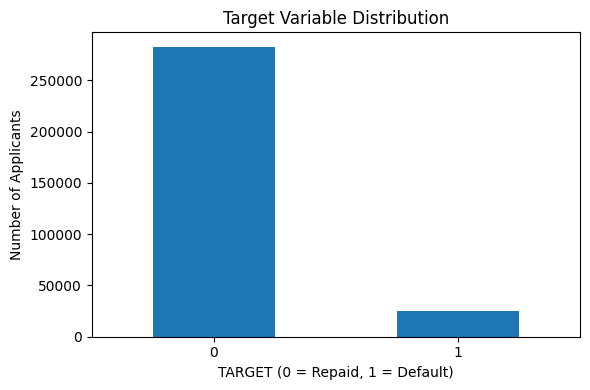

In [ ]:
# =========================
# Check class distribution
# =========================

class_dist = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True).mul(100).round(2)
})

print(class_dist)

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("TARGET (0 = Repaid, 1 = Default)")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Check Class Distribution

This step checks how the target classes are distributed in the dataset.

The table and bar chart both show that the dataset is highly imbalanced. Most applicants belong to class `0` (repaid loan), while a much smaller number belong to class `1` (default).

From the output:
- 282,686 applicants belong to class `0`
- 24,825 applicants belong to class `1`

This means around 91.93% of the dataset belongs to the non-default class, while only 8.07% belongs to the default class.

The imbalance can also be clearly seen in the bar chart. The bar for class `0` is much taller than the bar for class `1`. This shows that the model will see many more examples of non-default cases during training.

This is important because a model trained on imbalanced data may become biased toward the majority class. For example, the model could achieve high accuracy by predicting most applicants as non-default. Because of this, metrics such as recall, F1-score, and ROC-AUC are more useful than accuracy alone when evaluating the model.

In [ ]:
# =========================
# Train / validation / test split
# =========================
# Train = 80%
# Validation = 10%
# Test = 10%

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train set shape: (246008, 499)
Validation set shape: (30751, 499)
Test set shape: (30752, 499)

Train target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

Test target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


### Train, Validation, and Test Split

In this step, the dataset is divided into training, validation, and test sets.

The training set is used to train the neural network model, the validation set is used to monitor performance during training, and the test set is kept separate for final evaluation.

The output shows:
- Training set: 246,008 rows
- Validation set: 30,751 rows
- Test set: 30,752 rows

All sets contain 499 feature columns.

The target distribution is also checked for each split. The percentages remain almost identical across the training, validation, and test sets:
- around 91.93% for class `0`
- around 8.07% for class `1`

This shows that stratified splitting worked correctly and the class imbalance was preserved across all datasets. Keeping similar class distributions is important because it helps make the training and evaluation process more consistent and reliable.

In [ ]:
# =========================
# Convert data to NumPy format for Neural Network
# =========================

X_train_nn = X_train.values
X_val_nn = X_val.values
X_test_nn = X_test.values

In [ ]:
# =========================
# Handle class imbalance (Class Weights)
# =========================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}


### Prepare Data Format and Class Weights

In this part, the training, validation, and test feature sets are converted into NumPy arrays.

This is done because Keras neural networks work better with NumPy format than pandas DataFrames. The feature values are taken from `X_train`, `X_val`, and `X_test` and stored as `X_train_nn`, `X_val_nn`, and `X_test_nn`.

After that, class weights are calculated to help with the imbalance in the target variable. Since class `1` has far fewer examples than class `0`, the model could easily focus too much on class `0`.

The output shows the class weights:
- class `0`: about `0.54`
- class `1`: about `6.19`

This means mistakes on class `1` are given more weight during training. This helps the model pay more attention to default cases, which are the more important but smaller group in this dataset.

In [ ]:
# =========================
# Define topologies and batch sizes
# =========================

topologies = {
    "Topology_1_Small": [64, 32],
    "Topology_2_Medium": [128, 64, 32],
    "Topology_3_Large": [256, 128, 64, 32]
}

batch_sizes = [256, 512, 1024]

In [ ]:
# =========================
#  Model-building function
# =========================

def build_nn_model(input_dim, layers):
    model = Sequential()

    model.add(Dense(layers[0], activation="relu", input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    for units in layers[1:]:
        model.add(Dense(units, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

### Define Neural Network Topologies and Model Function

In this part, different neural network structures are prepared for experimentation.

Three different topologies are defined:
- `Topology_1_Small` → `[64, 32]`
- `Topology_2_Medium` → `[128, 64, 32]`
- `Topology_3_Large` → `[256, 128, 64, 32]`

These values represent the number of neurons in each hidden layer. The goal is to compare smaller and larger architectures to see how model complexity affects performance.

Different batch sizes are also defined:
- 256
- 512
- 1024

These will later be tested during training to compare their effect on learning and performance.

A function called `build_nn_model()` is then created to build the neural network automatically based on the selected topology.

Inside the function:
- `Dense` layers are used as the main hidden layers
- `ReLU` activation is used in hidden layers to help the network learn non-linear patterns
- `BatchNormalization` is added after each hidden layer to make training more stable
- `Dropout(0.3)` is added to reduce overfitting by randomly dropping some neurons during training

The final output layer contains one neuron with `sigmoid` activation because the task is binary classification.

The model is compiled using:
- `Adam` optimizer
- `binary_crossentropy` loss function
- `accuracy` and `AUC` as evaluation metrics

AUC is included because it is more useful for imbalanced classification problems such as credit default prediction.

In [ ]:
# =========================
# Plot accuracy and loss
# =========================

def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training History Plot Function

This function is created to visualise model performance during training.

Two plots are generated:
- accuracy vs epoch
- loss vs epoch

For both plots, the training and validation results are shown together. This makes it easier to compare how the model performs on the training data versus unseen validation data during each epoch.

In the accuracy plot:
- the training accuracy line shows how well the model learns from the training data
- the validation accuracy line shows how well the model generalises to unseen data

In the loss plot:
- training loss shows how prediction error changes during training
- validation loss helps detect overfitting

These plots are important because they help monitor model behaviour during training. For example:
- if training accuracy keeps increasing while validation accuracy stops improving, overfitting may be happening
- if both losses remain high, the model may not be learning enough patterns from the data

This function will later be reused for all neural network experiments so the training behaviour of different topologies and batch sizes can be compared more easily.


Training: Topology_1_Small_Batch_256


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6600 - auc: 0.7324 - loss: 0.6147 - val_accuracy: 0.6915 - val_auc: 0.7714 - val_loss: 0.5821
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6951 - auc: 0.7722 - loss: 0.5732 - val_accuracy: 0.7024 - val_auc: 0.7752 - val_loss: 0.5616
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6984 - auc: 0.7782 - loss: 0.5666 - val_accuracy: 0.7018 - val_auc: 0.7773 - val_loss: 0.5653
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6989 - auc: 0.7824 - loss: 0.5620 - val_accuracy: 0.7001 - val_auc: 0.7789 - val_loss: 0.5675
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6995 - auc: 0.7863 - loss: 0.5583 - val_accuracy: 0.6931 - val_auc: 0.7796 - val_loss: 0.5656
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6993 - auc: 0.7888 - loss: 0.5550 - val_accuracy: 0.6929 - val_auc: 0.7783 - val_loss: 0.5659
Epoch 7/30
961/961 ━━━━━━━━━━━━━━━━━━

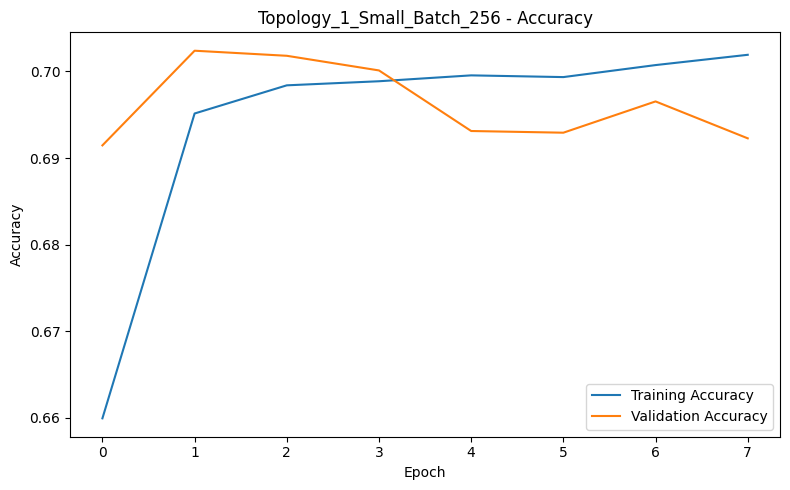

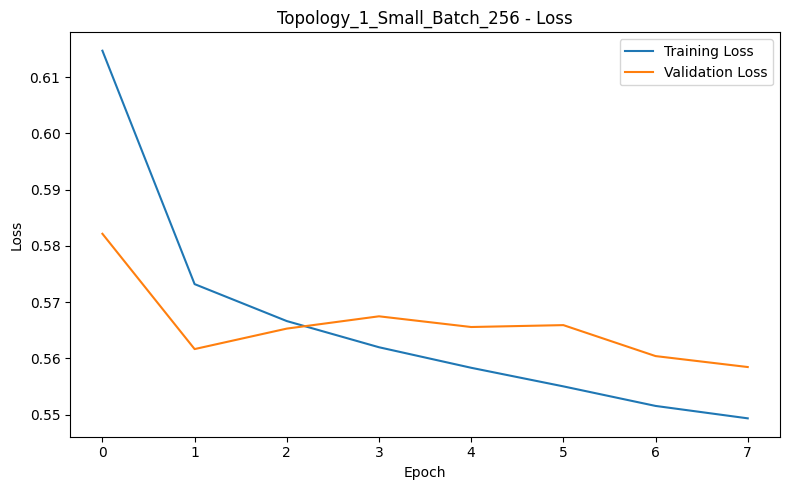


Training: Topology_1_Small_Batch_512


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6437 - auc: 0.7223 - loss: 0.6250 - val_accuracy: 0.6871 - val_auc: 0.7726 - val_loss: 0.5814
Epoch 2/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6887 - auc: 0.7684 - loss: 0.5772 - val_accuracy: 0.6969 - val_auc: 0.7754 - val_loss: 0.5735
Epoch 3/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6966 - auc: 0.7765 - loss: 0.5683 - val_accuracy: 0.6829 - val_auc: 0.7769 - val_loss: 0.5696
Epoch 4/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6951 - auc: 0.7815 - loss: 0.5628 - val_accuracy: 0.7053 - val_auc: 0.7785 - val_loss: 0.5573
Epoch 5/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6961 - auc: 0.7845 - loss: 0.5594 - val_accuracy: 0.6858 - val_auc: 0.7783 - val_loss: 0.5686
Epoch 6/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6984 - auc: 0.7876 - loss: 0.5562 - val_accuracy: 0.6847 - val_auc: 0.7786 - val_loss: 0.5722
Epoch 7/30
481/481 ━━━━━━━━━━━━━━━━━━━

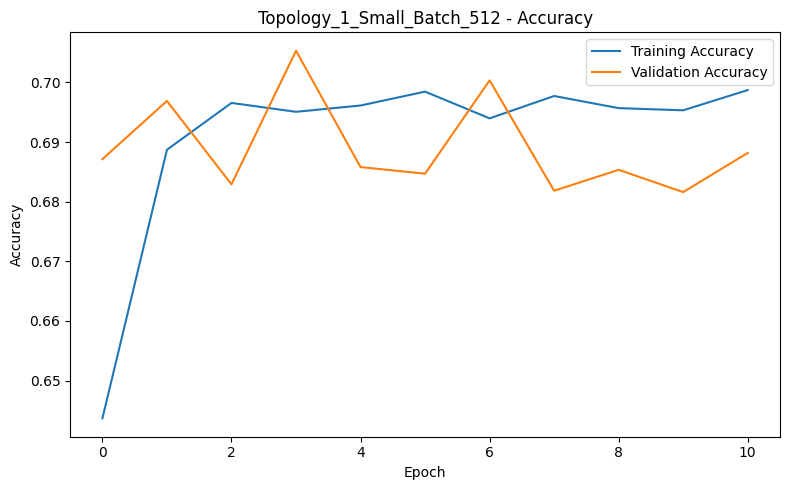

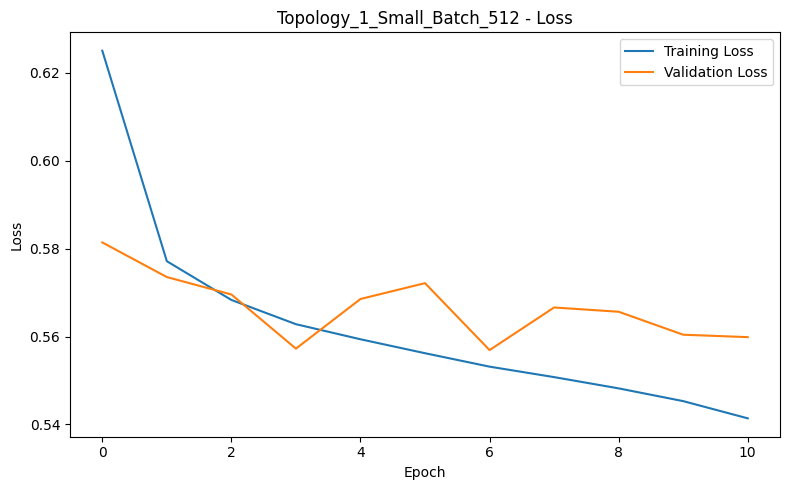


Training: Topology_1_Small_Batch_1024


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6166 - auc: 0.7019 - loss: 0.6551 - val_accuracy: 0.6869 - val_auc: 0.7662 - val_loss: 0.5787
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6778 - auc: 0.7579 - loss: 0.5883 - val_accuracy: 0.6943 - val_auc: 0.7723 - val_loss: 0.5755
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6964 - auc: 0.7725 - loss: 0.5731 - val_accuracy: 0.6952 - val_auc: 0.7746 - val_loss: 0.5734
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6964 - auc: 0.7769 - loss: 0.5681 - val_accuracy: 0.7050 - val_auc: 0.7772 - val_loss: 0.5606
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7012 - auc: 0.7824 - loss: 0.5624 - val_accuracy: 0.7034 - val_auc: 0.7774 - val_loss: 0.5587
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7031 - auc: 0.7854 - loss: 0.5592 - val_accuracy: 0.6998 - val_auc: 0.7785 - val_loss: 0.5655
Epoch 7/30
241/241 ━━━━━━━━━━━━━━━

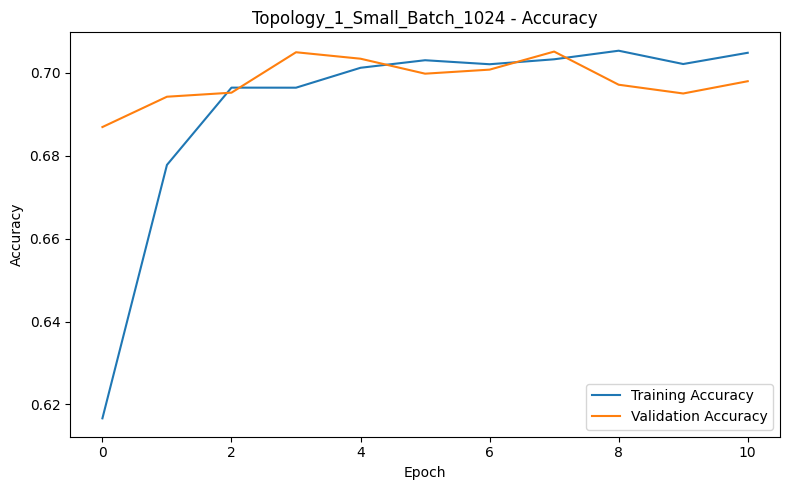

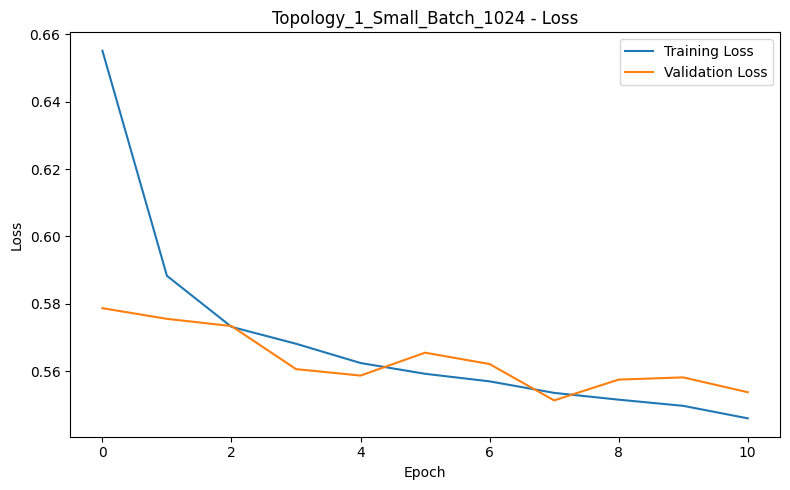


Training: Topology_2_Medium_Batch_256


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6446 - auc: 0.7153 - loss: 0.6322 - val_accuracy: 0.6825 - val_auc: 0.7720 - val_loss: 0.5868
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6877 - auc: 0.7700 - loss: 0.5750 - val_accuracy: 0.6938 - val_auc: 0.7764 - val_loss: 0.5669
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6905 - auc: 0.7785 - loss: 0.5666 - val_accuracy: 0.6856 - val_auc: 0.7785 - val_loss: 0.5574
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6911 - auc: 0.7830 - loss: 0.5615 - val_accuracy: 0.6811 - val_auc: 0.7785 - val_loss: 0.5723
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6924 - auc: 0.7862 - loss: 0.5584 - val_accuracy: 0.6923 - val_auc: 0.7786 - val_loss: 0.5590
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.6899 - auc: 0.7905 - loss: 0.5536 - val_accuracy: 0.6893 - val_auc: 0.7778 - val_loss: 0.5598
Epoch 7/30
961/961 ━━━━━━━━━━━━━

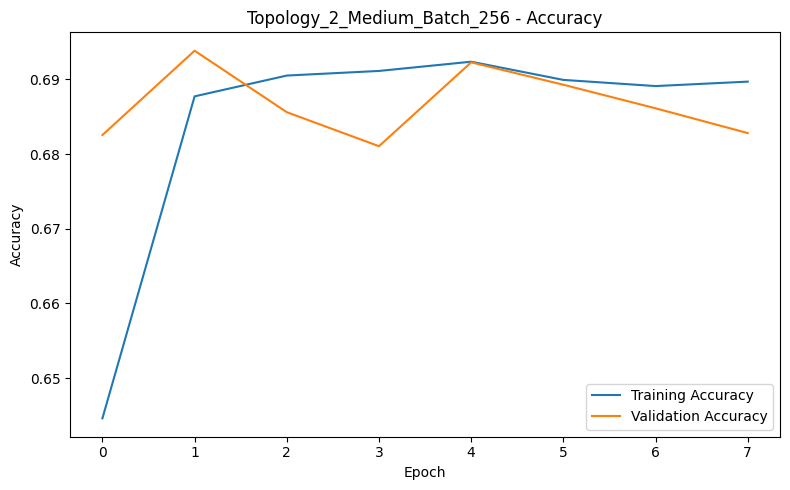

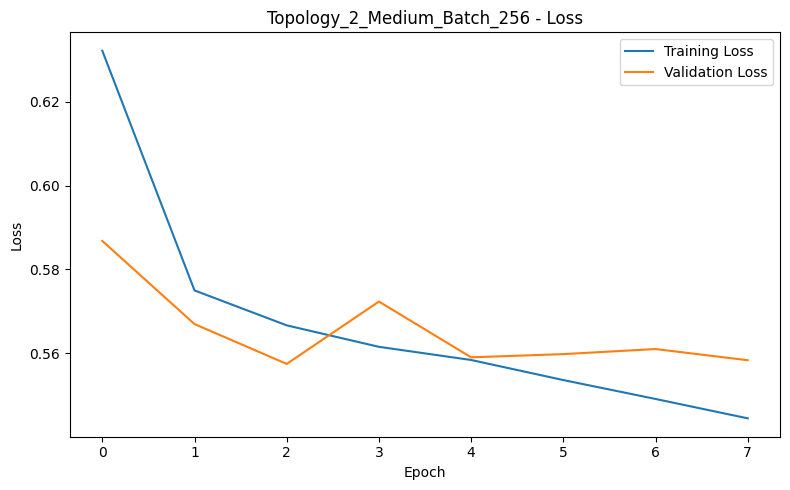


Training: Topology_2_Medium_Batch_512


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6407 - auc: 0.7080 - loss: 0.6448 - val_accuracy: 0.6811 - val_auc: 0.7689 - val_loss: 0.5778
Epoch 2/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6867 - auc: 0.7654 - loss: 0.5803 - val_accuracy: 0.6811 - val_auc: 0.7746 - val_loss: 0.5748
Epoch 3/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6892 - auc: 0.7760 - loss: 0.5692 - val_accuracy: 0.6773 - val_auc: 0.7766 - val_loss: 0.5756
Epoch 4/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6952 - auc: 0.7813 - loss: 0.5638 - val_accuracy: 0.6876 - val_auc: 0.7780 - val_loss: 0.5701
Epoch 5/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6938 - auc: 0.7849 - loss: 0.5606 - val_accuracy: 0.6958 - val_auc: 0.7786 - val_loss: 0.5489
Epoch 6/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6939 - auc: 0.7889 - loss: 0.5551 - val_accuracy: 0.6779 - val_auc: 0.7770 - val_loss: 0.5622
Epoch 7/30
481/481 ━━━━━━━━━━━━━━

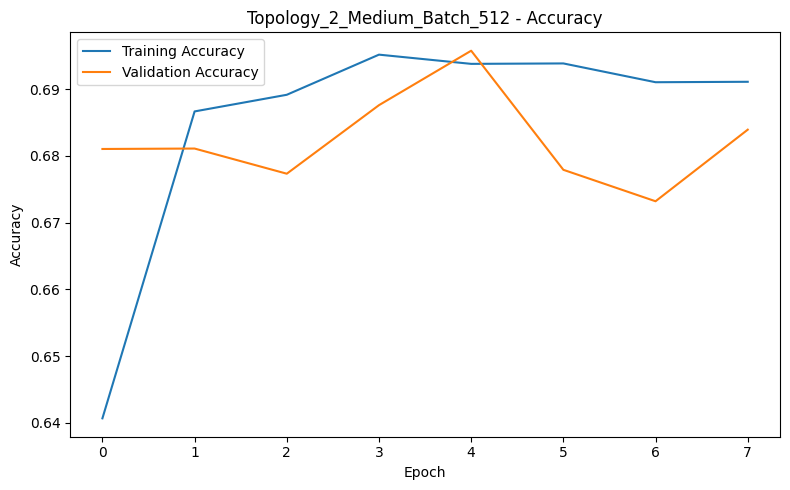

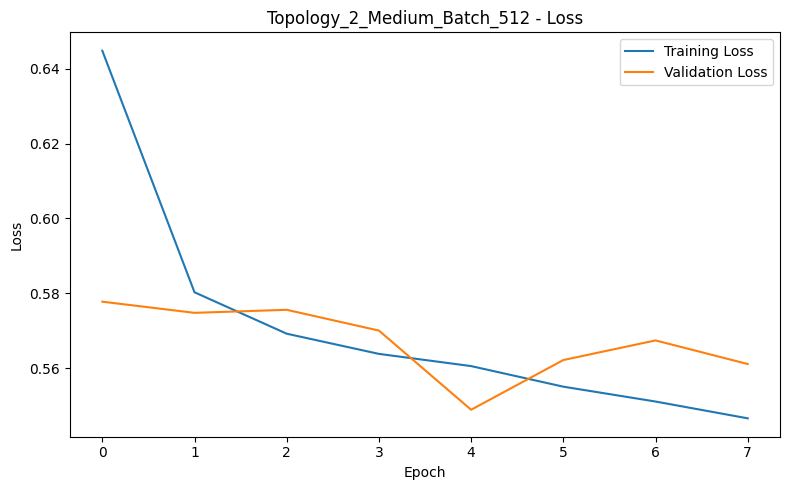


Training: Topology_2_Medium_Batch_1024


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6193 - auc: 0.6915 - loss: 0.6670 - val_accuracy: 0.6672 - val_auc: 0.7668 - val_loss: 0.5987
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6757 - auc: 0.7563 - loss: 0.5900 - val_accuracy: 0.6843 - val_auc: 0.7748 - val_loss: 0.5789
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6884 - auc: 0.7707 - loss: 0.5752 - val_accuracy: 0.6924 - val_auc: 0.7768 - val_loss: 0.5648
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6923 - auc: 0.7777 - loss: 0.5679 - val_accuracy: 0.6965 - val_auc: 0.7781 - val_loss: 0.5567
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.6964 - auc: 0.7828 - loss: 0.5622 - val_accuracy: 0.6870 - val_auc: 0.7779 - val_loss: 0.5666
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6905 - auc: 0.7863 - loss: 0.5582 - val_accuracy: 0.6893 - val_auc: 0.7789 - val_loss: 0.5568
Epoch 7/30
241/241 ━━━━━━━━━━━━━

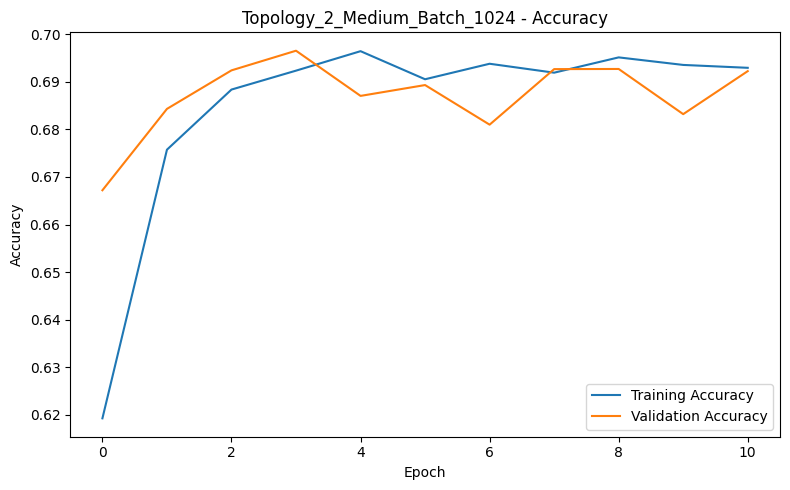

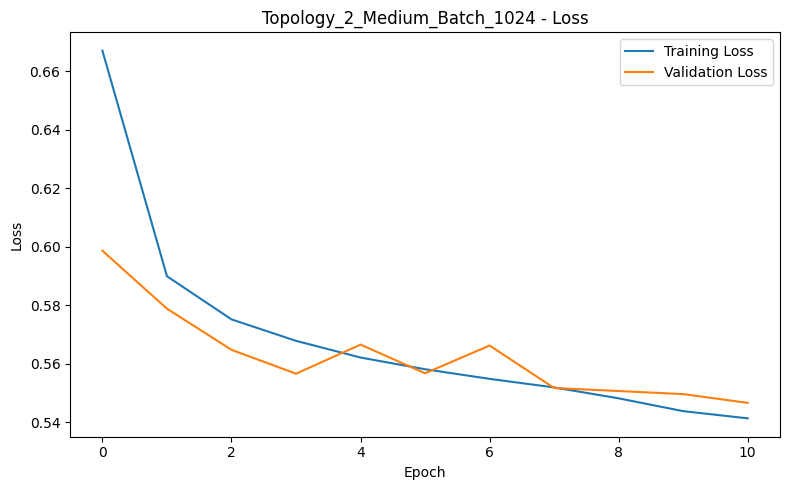


Training: Topology_3_Large_Batch_256


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.6534 - auc: 0.7205 - loss: 0.6282 - val_accuracy: 0.6916 - val_auc: 0.7744 - val_loss: 0.5704
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.6909 - auc: 0.7709 - loss: 0.5745 - val_accuracy: 0.6872 - val_auc: 0.7768 - val_loss: 0.5723
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.6939 - auc: 0.7792 - loss: 0.5661 - val_accuracy: 0.6784 - val_auc: 0.7776 - val_loss: 0.5797
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.6899 - auc: 0.7844 - loss: 0.5605 - val_accuracy: 0.6998 - val_auc: 0.7776 - val_loss: 0.5503
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.6964 - auc: 0.7885 - loss: 0.5557 - val_accuracy: 0.6843 - val_auc: 0.7777 - val_loss: 0.5594
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.6969 - auc: 0.7930 - loss: 0.5510 - val_accuracy: 0.6919 - val_auc: 0.7754 - val_loss: 0.5499
Epoch 7/30
961/961 ━━━━━━━━━

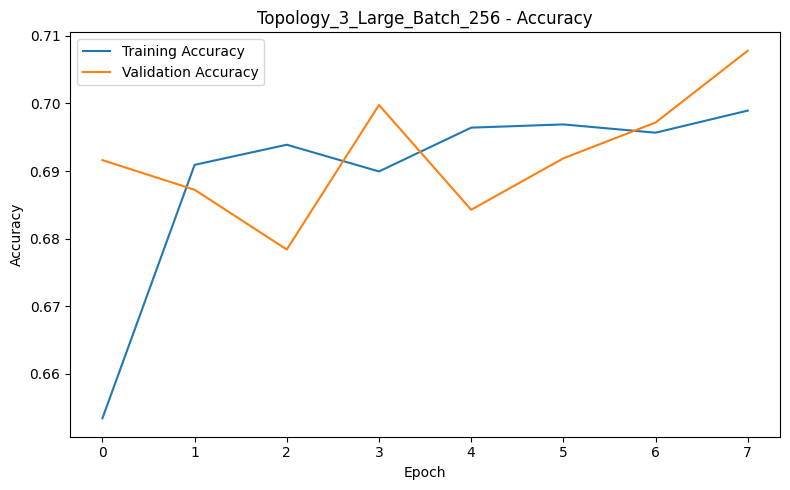

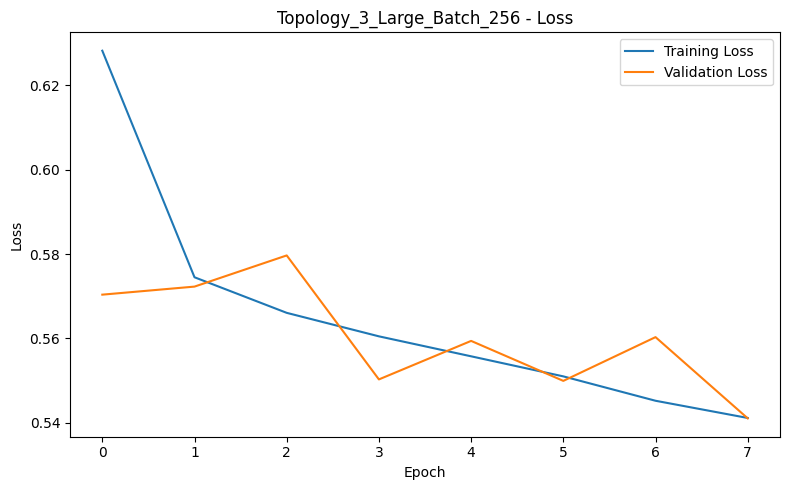


Training: Topology_3_Large_Batch_512


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6329 - auc: 0.7050 - loss: 0.6448 - val_accuracy: 0.6880 - val_auc: 0.7707 - val_loss: 0.5870
Epoch 2/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6862 - auc: 0.7648 - loss: 0.5816 - val_accuracy: 0.6944 - val_auc: 0.7753 - val_loss: 0.5741
Epoch 3/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6929 - auc: 0.7780 - loss: 0.5672 - val_accuracy: 0.6953 - val_auc: 0.7766 - val_loss: 0.5712
Epoch 4/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6967 - auc: 0.7827 - loss: 0.5621 - val_accuracy: 0.6942 - val_auc: 0.7774 - val_loss: 0.5628
Epoch 5/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6943 - auc: 0.7876 - loss: 0.5573 - val_accuracy: 0.6982 - val_auc: 0.7791 - val_loss: 0.5587
Epoch 6/30
481/481 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6966 - auc: 0.7918 - loss: 0.5521 - val_accuracy: 0.6829 - val_auc: 0.7752 - val_loss: 0.5593
Epoch 7/30
481/481 ━━━━━━━━━

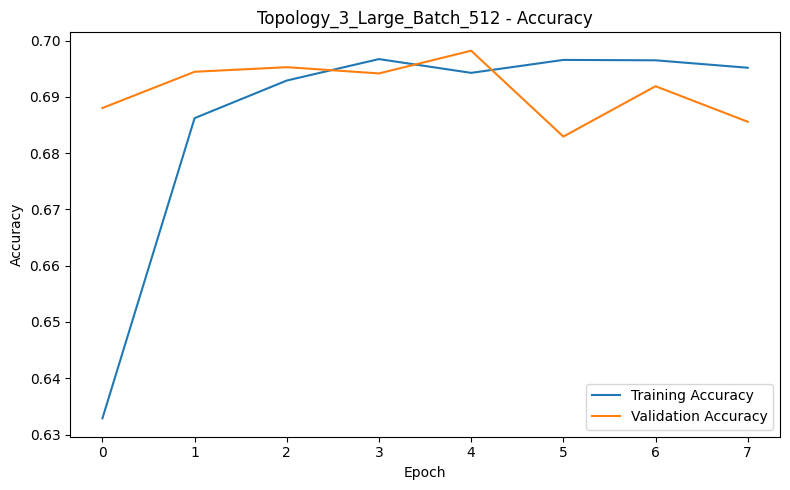

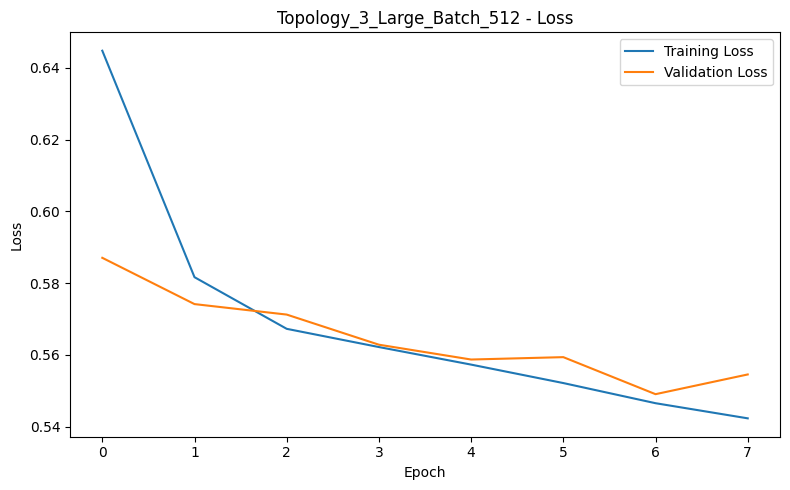


Training: Topology_3_Large_Batch_1024


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.6061 - auc: 0.6883 - loss: 0.6632 - val_accuracy: 0.6307 - val_auc: 0.7708 - val_loss: 0.6338
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6720 - auc: 0.7572 - loss: 0.5891 - val_accuracy: 0.6523 - val_auc: 0.7748 - val_loss: 0.6181
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6894 - auc: 0.7731 - loss: 0.5728 - val_accuracy: 0.6744 - val_auc: 0.7769 - val_loss: 0.5860
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.6917 - auc: 0.7800 - loss: 0.5652 - val_accuracy: 0.6785 - val_auc: 0.7777 - val_loss: 0.5831
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6923 - auc: 0.7856 - loss: 0.5590 - val_accuracy: 0.6975 - val_auc: 0.7765 - val_loss: 0.5643
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.6950 - auc: 0.7886 - loss: 0.5557 - val_accuracy: 0.6767 - val_auc: 0.7769 - val_loss: 0.5690
Epoch 7/30
241/241 ━━━━━━━━━

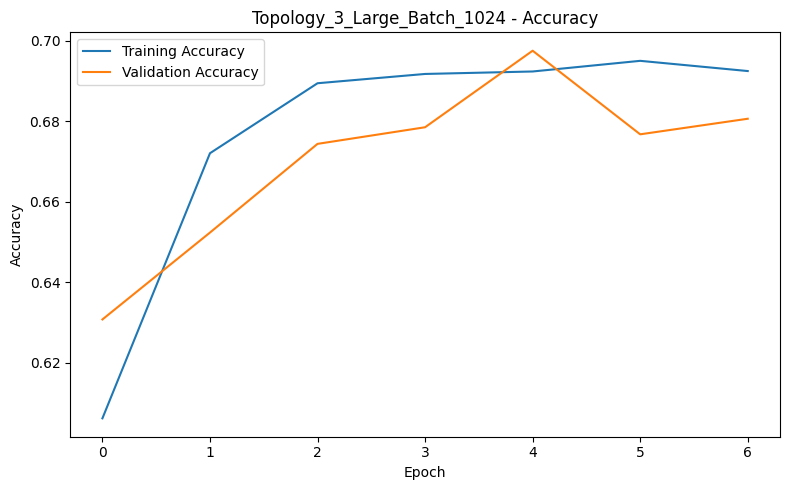

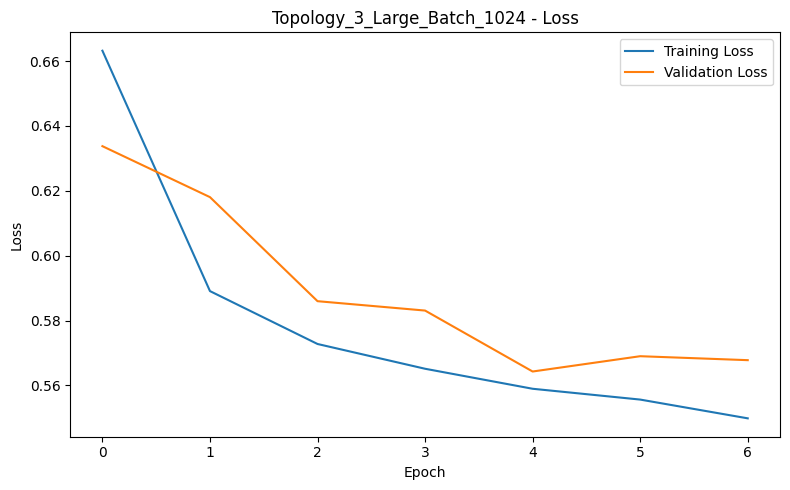

,Experiment,Topology,Layers,Batch Size,Validation Accuracy,Validation Precision,Validation Sensitivity,Validation Specificity,Validation F1-score,Validation ROC-AUC,Epochs Trained
2,Topology_1_Small_Batch_1024,Topology_1_Small,"[64, 32]",1024,0.705148,0.175903,0.719984,0.703845,0.282731,0.781111,11
0,Topology_1_Small_Batch_256,Topology_1_Small,"[64, 32]",256,0.693116,0.172398,0.737309,0.689236,0.279453,0.779591,8
7,Topology_3_Large_Batch_512,Topology_3_Large,"[256, 128, 64, 32]",512,0.698189,0.172779,0.723207,0.695992,0.278922,0.779133,8
5,Topology_2_Medium_Batch_1024,Topology_2_Medium,"[128, 64, 32]",1024,0.692660,0.170621,0.727236,0.689625,0.276395,0.779121,11
1,Topology_1_Small_Batch_512,Topology_1_Small,"[64, 32]",512,0.681831,0.168332,0.746575,0.676147,0.274722,0.778837,11
4,Topology_2_Medium_Batch_512,Topology_2_Medium,"[128, 64, 32]",512,0.695782,0.171682,0.724013,0.693304,0.277550,0.778570,8
3,Topology_2_Medium_Batch_256,Topology_2_Medium,"[128, 64, 32]",256,0.692270,0.170987,0.730862,0.688882,0.277137,0.778516,8
8,Topology_3_Large_Batch_1024,Topology_3_Large,"[256, 128, 64, 32]",1024,0.678482,0.165930,0.740935,0.672999,0.271139,0.777708,7
6,Topology_3_Large_Batch_256,Topology_3_Large,"[256, 128, 64, 32]",256,0.684270,0.167602,0.734085,0.679897,0.272897,0.777630,8


In [ ]:
# =========================
# =========================
# Hyperparameter tuning
# 3 topologies × 3 batch sizes = 9 experiments
# =========================

results = []
histories = {}
models = {}

for topology_name, layers in topologies.items():
    for batch_size in batch_sizes:

        experiment_name = f"{topology_name}_Batch_{batch_size}"
        print(f"\nTraining: {experiment_name}")

        model = build_nn_model(
            input_dim=X_train_nn.shape[1],
            layers=layers
        )

        early_stop = EarlyStopping(
            monitor="val_auc",
            patience=3,
            mode="max",
            restore_best_weights=True
        )

        history = model.fit(
            X_train_nn,
            y_train,
            validation_data=(X_val_nn, y_val),
            epochs=30,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights_dict,
            verbose=1
        )

        val_pred_prob = model.predict(X_val_nn).ravel()
        val_pred = (val_pred_prob >= 0.5).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()

        accuracy = accuracy_score(y_val, val_pred)
        precision = precision_score(y_val, val_pred, zero_division=0)
        sensitivity = recall_score(y_val, val_pred, zero_division=0)
        specificity = tn / (tn + fp)
        f1 = f1_score(y_val, val_pred, zero_division=0)
        auc = roc_auc_score(y_val, val_pred_prob)

        results.append({
            "Experiment": experiment_name,
            "Topology": topology_name,
            "Layers": str(layers),
            "Batch Size": batch_size,
            "Validation Accuracy": accuracy,
            "Validation Precision": precision,
            "Validation Sensitivity": sensitivity,
            "Validation Specificity": specificity,
            "Validation F1-score": f1,
            "Validation ROC-AUC": auc,
            "Epochs Trained": len(history.history["loss"])
        })

        histories[experiment_name] = history
        models[experiment_name] = model

        plot_training_history(history, experiment_name)


nn_tuning_results = pd.DataFrame(results)

nn_tuning_results.sort_values(
    "Validation ROC-AUC",
    ascending=False
)

### Hyperparameter Tuning

In this part, multiple neural network experiments are trained and compared.

The code loops through:
- 3 different topologies
- 3 different batch sizes

This creates a total of 9 experiments.

For each experiment:
1. A neural network model is built using the selected topology
2. Early stopping is added to reduce overfitting
3. The model is trained using the training set
4. Validation predictions are generated
5. Several evaluation metrics are calculated and stored

The model is trained for up to 30 epochs, but `EarlyStopping` is used with patience set to 3. This means training stops early if the validation AUC does not improve for 3 consecutive epochs. The best model weights are also restored automatically.

Validation metrics calculated for each experiment include:
- Accuracy
- Precision
- Sensitivity (Recall)
- Specificity
- F1-score
- ROC-AUC

These metrics are stored in a results table so the experiments can later be compared more easily.

The code also stores:
- the training history for each experiment
- the trained model itself

At the end, all results are converted into a DataFrame and sorted by validation ROC-AUC, since ROC-AUC is one of the most useful metrics for imbalanced classification problems like credit default prediction.

### Results of Topology 1 Experiments

For Topology 1, three different batch sizes were tested:
- Batch size 256
- Batch size 512
- Batch size 1024

The accuracy and loss plots were analysed to compare training stability, learning behaviour, and possible overfitting across the three experiments.

---

#### Topology_1_Small_Batch_256

The accuracy plot shows that training accuracy increased quickly during the first few epochs and then stabilised around 0.69–0.70. Validation accuracy improved at the beginning and reached its highest point during the early epochs before gradually decreasing afterward.

The loss plot shows that training loss continuously decreased throughout training, meaning the model kept learning patterns from the training data. Validation loss initially decreased but later became less stable and started fluctuating slightly after the middle epochs.

This behaviour suggests mild overfitting after the early stages of training. While training performance continued improving, validation performance stopped improving and became slightly worse during later epochs. However, the gap between training and validation curves remained relatively small overall.

---

#### Topology_1_Small_Batch_512

For batch size 512, the training accuracy increased steadily and stayed close to the validation accuracy during most epochs. Validation accuracy fluctuated throughout training but remained relatively stable overall around the same performance range.

The loss plot shows that training loss steadily decreased over time. Validation loss also decreased overall, although several temporary increases appeared during the middle and later epochs before stabilising again.

Compared to batch size 256, the curves appear slightly smoother and more stable. The smaller gap between training and validation performance suggests reduced overfitting and slightly better generalisation behaviour.

---

#### Topology_1_Small_Batch_1024

With batch size 1024, training accuracy increased gradually and stayed very close to validation accuracy across most epochs. Validation accuracy remained relatively stable around 0.69–0.70 with fewer fluctuations compared to the previous experiments.

The loss plot shows that both training and validation loss generally decreased throughout training. Although small fluctuations appeared in validation loss during some later epochs, the overall behaviour remained smooth and stable.

This experiment appears to show the most stable training behaviour among the Topology 1 models. The close alignment between training and validation curves suggests less overfitting and more consistent learning during training.

---

Overall, all three Topology 1 experiments showed similar behaviour and produced relatively close performance. Increasing the batch size improved the smoothness and stability of both the accuracy and loss curves. Among the three experiments, batch size 1024 appeared to produce the most stable training behaviour with the least visible overfitting.

### Topology_2_Medium Experiments

Topology 2 used a deeper neural network structure compared to Topology 1. The architecture included three hidden layers with 128, 64, and 32 neurons. Similar to the previous experiments, three batch sizes were tested:
- Batch size 256
- Batch size 512
- Batch size 1024

The accuracy and loss plots were analysed to compare learning behaviour, training stability, and possible overfitting across the three experiments.

---

#### Topology_2_Medium_Batch_256

The accuracy plot shows that training accuracy increased quickly during the first epochs and then stabilised around 0.69. Validation accuracy fluctuated throughout training, with several increases and decreases across epochs instead of following a smooth upward trend.

The loss plot shows that training loss continuously decreased during the training process. Validation loss also decreased during the early epochs but later fluctuated slightly and remained above the training loss during the later epochs.

This behaviour suggests mild overfitting after the middle stages of training. While the model continued improving on the training data, validation performance became less stable. However, the difference between training and validation curves remained relatively small overall.

---

#### Topology_2_Medium_Batch_512

For batch size 512, training accuracy increased steadily and stayed relatively stable during the later epochs. Validation accuracy initially improved and reached its highest point around the middle epochs before decreasing again afterward.

The loss plot shows that training loss consistently decreased across epochs. Validation loss decreased noticeably during the early and middle epochs but later increased slightly during the final epochs.

Compared to batch size 256, this experiment shows slightly smoother training behaviour. However, the drop in validation accuracy and the increase in validation loss during later epochs suggest the beginning of overfitting near the end of training.

---

#### Topology_2_Medium_Batch_1024

With batch size 1024, the training and validation accuracy curves stayed closer to each other throughout most of the training process. Validation accuracy fluctuated slightly but remained relatively stable around 0.69 during the later epochs.

The loss plot shows a smooth decrease in both training and validation loss over time. Although minor fluctuations appeared in the validation loss during the middle epochs, the overall trend remained stable and gradually decreasing.

Compared to the other Topology 2 experiments, batch size 1024 appears to produce the most stable behaviour overall. The smaller gap between training and validation curves suggests better generalisation and less visible overfitting during training.

---

Overall, the Topology 2 experiments produced relatively stable behaviour across all batch sizes. Increasing the batch size improved the smoothness and consistency of both the accuracy and loss curves. Among the three experiments, batch size 1024 appeared to provide the most stable learning process with less noticeable overfitting.

### Topology_3_Large Experiments

Topology 3 used the largest neural network architecture among all experiments. The model contained larger hidden layers with more trainable parameters compared to Topology 1 and Topology 2. Similar to the previous experiments, batch sizes of 256, 512, and 1024 were tested.

The accuracy and loss plots were analysed to compare training behaviour, stability, and possible overfitting across the three experiments.

---

#### Topology_3_Large_Batch_256

The accuracy plot shows that training accuracy increased rapidly during the early epochs and then stabilised close to 0.69–0.70. Validation accuracy fluctuated noticeably during training, with several increases and decreases across epochs before reaching its highest value near the final epoch.

The loss plot shows that training loss steadily decreased throughout training. Validation loss also decreased overall but showed several fluctuations during the middle and later epochs.

This behaviour suggests mild instability during validation despite the steady improvement on the training data. However, the gap between training and validation curves remained relatively small overall, indicating that overfitting was not severe.

---

#### Topology_3_Large_Batch_512

For batch size 512, training accuracy increased steadily and remained relatively stable during the later epochs. Validation accuracy improved during the early epochs and reached its highest point around the middle epochs before fluctuating afterward.

The loss curves show a smooth decrease in training loss throughout training. Validation loss also decreased gradually and stayed relatively close to the training loss, although small increases appeared during the later epochs.

Compared to batch size 256, this experiment shows smoother and more stable behaviour overall. The close alignment between training and validation curves suggests improved generalisation and reduced overfitting.

---

#### Topology_3_Large_Batch_1024

With batch size 1024, both training and validation accuracy improved steadily during the early epochs before stabilising later in training. Validation accuracy stayed relatively close to training accuracy, although a small drop appeared after the middle epochs.

The loss plot shows a stable decrease in both training and validation loss throughout the training process. Validation loss showed only minor fluctuations during the later epochs while training loss continued decreasing gradually.

Compared to the other Topology 3 experiments, batch size 1024 produced one of the smoothest training processes overall. The smaller gap between training and validation curves suggests stable learning behaviour and less visible overfitting.

---

Overall, the Topology 3 experiments showed relatively stable behaviour across all batch sizes. Increasing the batch size improved the smoothness of both the accuracy and loss curves and reduced fluctuations in validation performance. However, despite the larger and more complex architecture, the overall behaviour remained relatively similar to the previous topologies.

In [ ]:
# =========================
# Select best model
# =========================

best_result = nn_tuning_results.sort_values(
    "Validation ROC-AUC",
    ascending=False
).iloc[0]

best_experiment_name = best_result["Experiment"]
best_model = models[best_experiment_name]

print("Best Experiment:", best_experiment_name)
print(best_result)

Best Experiment: Topology_1_Small_Batch_1024
Experiment                Topology_1_Small_Batch_1024
Topology                             Topology_1_Small
Layers                                       [64, 32]
Batch Size                                       1024
Validation Accuracy                          0.705148
Validation Precision                         0.175903
Validation Sensitivity                       0.719984
Validation Specificity                       0.703845
Validation F1-score                          0.282731
Validation ROC-AUC                           0.781111
Epochs Trained                                     11
Name: 2, dtype: object


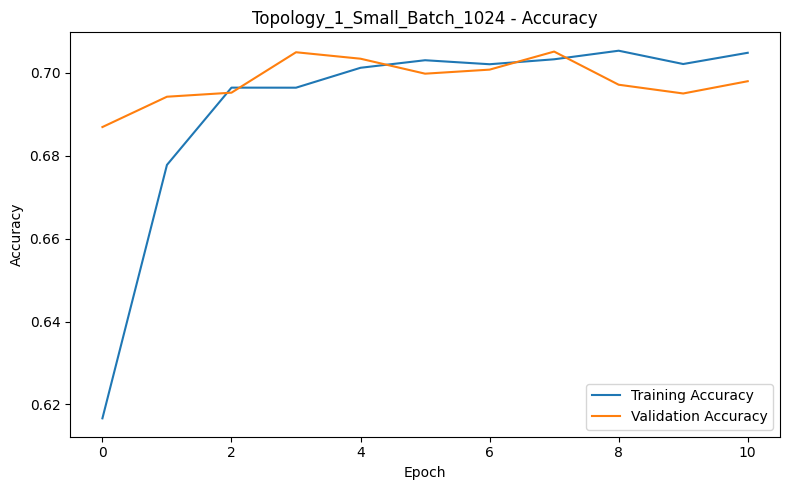

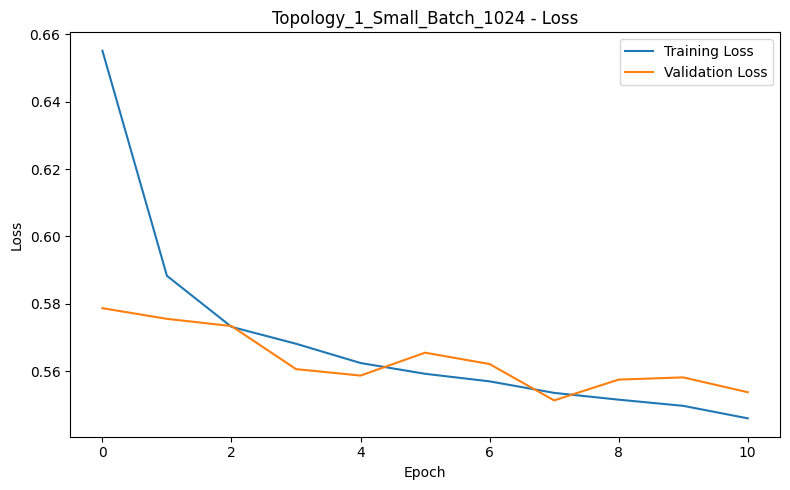

In [ ]:
# ==============================
# Plot Best Model Training Curves
# ==============================

best_history = histories[best_experiment_name]

plot_training_history(
    best_history,
    best_experiment_name
)

### Select Best Neural Network Model

After completing all 9 neural network experiments, the best model was selected using validation ROC-AUC as the main evaluation metric because the dataset is highly imbalanced.

The selected best experiment is `Topology_1_Small_Batch_1024`. This model used the smaller neural network architecture with two hidden layers containing 64 and 32 neurons. The batch size was 1024.

The validation results for the best model are:
- Accuracy: 0.705148
- Precision: 0.175903
- Sensitivity/Recall: 0.719984
- Specificity: 0.703845
- F1-score: 0.282731
- ROC-AUC: 0.781111
- Epochs trained: 11

These results show that the model achieved the best overall balance between classification performance and generalisation ability among all experiments. The ROC-AUC score indicates that the model performs reasonably well at separating default and non-default applicants. The recall value is also relatively high, meaning the model successfully identifies a good portion of the default cases.

However, the precision score remains low. This means that many applicants predicted as default are actually non-default cases. This behaviour is expected because the dataset is highly imbalanced, and class weighting was applied to increase the model’s focus on the minority default class.

The training plots also supported the model selection process. The accuracy curves showed stable learning behaviour, with validation accuracy remaining close to training accuracy during most epochs. In addition, both training and validation loss decreased smoothly over time with only minor fluctuations.

Compared to the deeper Topology 2 and Topology 3 models, the smaller architecture in Topology 1 appeared to generalise slightly better while avoiding unnecessary complexity. Some larger models showed more fluctuations in validation performance and mild signs of overfitting during later epochs.

The batch size of 1024 also produced smoother and more stable learning curves compared to smaller batch sizes. Based on both the evaluation metrics and the training behaviour, `Topology_1_Small_Batch_1024` was selected as the final neural network model.


### Comparison of Feature Engineering Approaches

To compare the impact of different feature engineering strategies, the neural network models were trained using two separately prepared datasets. Both datasets included feature engineering and aggregation from the secondary Home Credit tables, but the preprocessing and feature selection pipelines were different between the two versions.

In Version 2 of the dataset, a more extensive feature engineering process was applied. Additional ratio-based features were created across multiple tables, missing indicator columns were added, count-related missing values were replaced with zero, and highly missing or ID-related columns were removed. Correlation filtering was also applied to remove highly correlated features, followed by Random Forest feature importance selection to keep the top 500 most important features. In addition, some highly skewed positive features were log-transformed to improve distribution stability.

After preprocessing, the final dataset was reduced to 502 selected features, making the dataset more compact and computationally efficient for training.

The first feature engineering setup produced the best overall result using `Topology_1_Small_Batch_1024`, achieving a validation ROC-AUC of 0.781111.

In the second setup, the best result was obtained using `Topology_2_Medium_Batch_1024` with a validation ROC-AUC of 0.77957.

Although the results were extremely close, the first setup performed slightly better overall. In addition, the training and validation plots from the first setup showed smoother and more stable learning behaviour with fewer fluctuations across epochs.

For these reasons, the first feature engineering setup was selected as the final preprocessing and feature engineering approach for the neural network experiments.

In [ ]:
best_history = histories[best_experiment_name]

best_epoch = np.argmax(best_history.history['val_auc']) + 1

print("Best Epoch:", best_epoch)

Best Epoch: 8


In [ ]:
# ==================================================
# Final model training using best epoch
# ==================================================

final_model = build_nn_model(
    input_dim=X_train_nn.shape[1],
    layers=[64, 32]
)

final_history = final_model.fit(
    X_train_nn,
    y_train,
    validation_data=(X_val_nn, y_val),
    epochs=best_epoch,
    batch_size=1024,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6260 - auc: 0.6871 - loss: 0.6909 - val_accuracy: 0.6855 - val_auc: 0.7645 - val_loss: 0.5835
Epoch 2/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6801 - auc: 0.7510 - loss: 0.5982 - val_accuracy: 0.6977 - val_auc: 0.7733 - val_loss: 0.5689
Epoch 3/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6909 - auc: 0.7677 - loss: 0.5782 - val_accuracy: 0.6945 - val_auc: 0.7760 - val_loss: 0.5676
Epoch 4/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.6937 - auc: 0.7757 - loss: 0.5699 - val_accuracy: 0.7042 - val_auc: 0.7767 - val_loss: 0.5592
Epoch 5/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6974 - auc: 0.7807 - loss: 0.5643 - val_accuracy: 0.7028 - val_auc: 0.7764 - val_loss: 0.5535
Epoch 6/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6967 - auc: 0.7834 - loss: 0.5614 - val_accuracy: 0.7018 - val_auc: 0.7760 - val_loss: 0.5571
Epoch 7/8
241/241 ━━━━━━━━━━━━━━━━━━━━ 

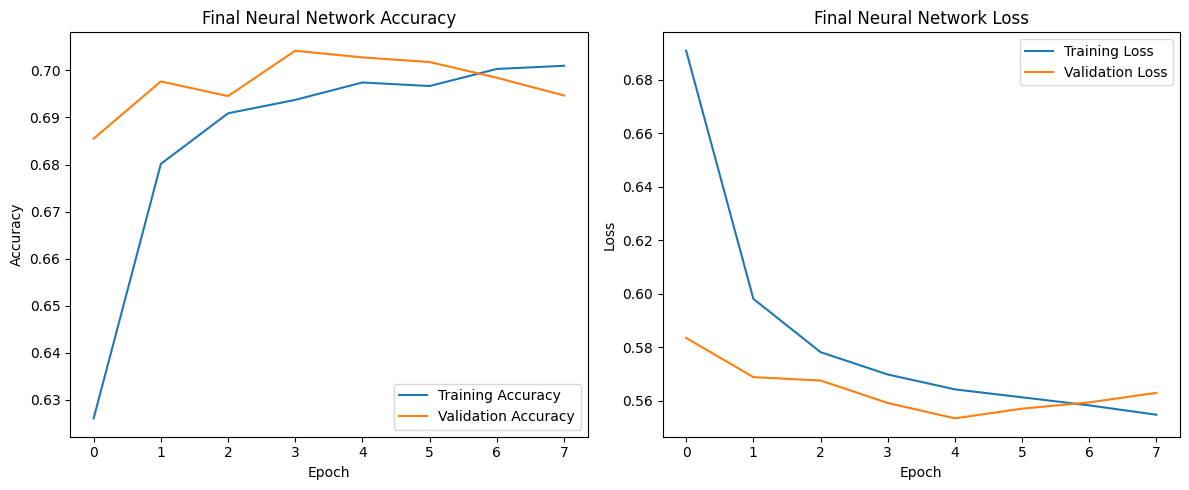

In [ ]:
# ==================================================
# Accuracy and Loss Plots
# ==================================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(final_history.history['accuracy'], label='Training Accuracy')
plt.plot(final_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Neural Network Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(final_history.history['loss'], label='Training Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Neural Network Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Saving the model for other uses

In [ ]:
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- THE SAVING CODE ---

# A. Native Keras (Recommended)
# This is a zip-based format that is more robust than H5
model.save('full_model.keras')

# B. H5 Format (Legacy / Common)
# Saves the architecture and weights in a Hierarchical Data Format
model.save('full_model.h5')

# C. Weights Only
# Useful if you define the architecture in code and just want to load parameters
model.save_weights('model_weights.weights.h5')

# D. Joblib (For Preprocessing/Scalers

print("All formats saved successfully!")

All formats saved successfully!


In [ ]:
data_package = {
    "X_train_nn": X_train,
    "X_val_nn": X_val,
    "X_test_nn": X_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "feature_names": list(X_train.columns),
    "class_weights_dict": class_weights_dict,
    "decision_threshold": 0.5
}

joblib.dump(data_package, f"nn_data_package.joblib")

['nn_data_package.joblib']

In [ ]:
baseline_pred_prob = model.predict(X_test).ravel()
baseline_pred = (baseline_pred_prob >= 0.5).astype(int)

np.savez_compressed(
    f"nn_baseline_predictions.npz",
    baseline_pred_prob=baseline_pred_prob,
    baseline_pred=baseline_pred
)

577/577 [==============================] - 1s 991us/step


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import os
import json
import joblib
import numpy as np
import tensorflow as tf
import keras
import sklearn
import pandas as pd

tn, fp, fn, tp = confusion_matrix(y_test, baseline_pred).ravel()

baseline_metrics = {
    "accuracy": float(accuracy_score(y_test, baseline_pred)),
    "precision": float(precision_score(y_test, baseline_pred, zero_division=0)),
    "recall_sensitivity": float(recall_score(y_test, baseline_pred, zero_division=0)),
    "specificity": float(tn / (tn + fp)),
    "f1_score": float(f1_score(y_test, baseline_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, baseline_pred_prob)),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

with open(f"baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=4)

In [ ]:
metadata = {
    "model_name": "Best Neural Network for Credit Risk Prediction",
    "model_type": "Dense Feedforward Neural Network",
    "input_shape": list(model.input_shape),
    "output_activation": "sigmoid",
    "task_type": "binary classification",
    "decision_threshold": 0.5,
    "n_input_features": int(X_train.shape[1]),
    "n_train_samples": int(X_train.shape[0]),
    "n_validation_samples": int(X_val.shape[0]),
    "n_test_samples": int(X_test.shape[0]),
    "tensorflow_version": tf.__version__,
    "keras_version": keras.__version__,
    "sklearn_version": sklearn.__version__,
    "saved_files": [
        "best_nn_model.keras",
        "best_nn_model.h5",
        "best_nn_weights.weights.h5",
        "nn_data_package.joblib",
        "nn_baseline_predictions.npz",
        "baseline_metrics.json",
        "nn_model_metadata.json"
    ]
}

with open(f"nn_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [ ]:
import shutil

shutil.make_archive("saved_nn_for_xai_pruning", "zip", "outputs")

'/home/a00047424/kq_tf/CA3/final_project/saved_nn_for_xai_pruning.zip'

### Inspecting the Saved Neural Network Data Package

Before regenerating the black-box neural network evaluation outputs, the saved `nn_data_package.joblib` file was inspected to verify that it contains the required processed datasets and metadata. Since the model was already trained and saved, retraining was not required. Instead, the aim of this step was to confirm whether the saved package includes the neural-network-ready train, validation and test splits, the target labels, feature names, class weights and decision threshold.

This validation is important because evaluation metrics, plots and SHAP explanations can only be reproduced correctly if the same preprocessed feature set used during model training is available.

### Inspecting the Saved Neural Network Data Package

Before regenerating the black-box neural network evaluation outputs, the saved `nn_data_package.joblib` file was inspected to verify that it contains the required processed datasets and metadata. Since the model was already trained and saved, retraining was not required. Instead, the aim of this step was to confirm whether the saved package includes the neural-network-ready train, validation and test splits, the target labels, feature names, class weights and decision threshold.

This validation is important because evaluation metrics, plots and SHAP explanations can only be reproduced correctly if the same preprocessed feature set used during model training is available.

In [ ]:
import joblib

data_package = joblib.load("nn_data_package.joblib")

print("Object type:", type(data_package))

if isinstance(data_package, dict):
    print("\nKeys inside nn_data_package.joblib:")
    for key in data_package.keys():
        print("-", key)
else:
    print("\nThis file is not a dictionary.")
    print(data_package)

Object type: <class 'dict'>

Keys inside nn_data_package.joblib:
- X_train_nn
- X_val_nn
- X_test_nn
- y_train
- y_val
- y_test
- feature_names
- class_weights_dict
- decision_threshold


In [ ]:
import numpy as np
import pandas as pd

for key, value in data_package.items():
    print("\n==============================")
    print("Key:", key)
    print("Type:", type(value))

    if hasattr(value, "shape"):
        print("Shape:", value.shape)

    if isinstance(value, pd.DataFrame):
        print("Columns preview:", value.columns[:10].tolist())
        print(value.head(2))

    elif isinstance(value, pd.Series):
        print("Series name:", value.name)
        print(value.head(5))

    elif isinstance(value, np.ndarray):
        print("Array dtype:", value.dtype)
        print("First values:", value[:5])

    else:
        print("Value preview:", str(value)[:500])


Key: X_train_nn
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (215257, 499)
Columns preview: ['EXT_SOURCES_MEAN', 'EXT_SOURCES_MIN', 'EXT_SOURCES_MAX', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'GROUP_EXT_MEAN', 'EXT_SOURCES_VAR']
        EXT_SOURCES_MEAN  EXT_SOURCES_MIN  EXT_SOURCES_MAX  EXT_SOURCE_2  \
159703          0.263116        -0.383514         0.380184     -0.978569   
79269           0.131440         0.216007         0.012367      0.541350   

        EXT_SOURCE_3  DAYS_EMPLOYED  EXT_SOURCE_1  DAYS_BIRTH  GROUP_EXT_MEAN  \
159703      0.728706       0.572798      1.226127    0.561413         0.59821   
79269      -0.432866       0.488536      0.012103   -0.345099         1.13665   

        EXT_SOURCES_VAR  ...  WEEKDAY_APPR_PROCESS_START_SATURDAY  \
159703         0.176512  ...                             2.843235   
79269         -0.410240  ...                            -0.351712   

        FLAG_DOCUMENT_8  CC_MONTHS_BALANCE_MA

### Verifying Minimum Requirements for Model Evaluation

The minimum data required to regenerate the black-box model evaluation is the processed test feature set and the corresponding test labels. Therefore, this check verifies whether `X_test_nn` and `y_test` are present in the saved package.

If these objects are available, the saved neural network can be used to generate new test-set predictions without retraining. These predictions can then be used to recreate the evaluation metrics, confusion matrix, ROC curve, precision-recall curve and probability distribution plot.

In [ ]:
required_eval_keys = ["X_test_nn", "y_test"]

missing_eval_keys = [key for key in required_eval_keys if key not in data_package]

if len(missing_eval_keys) == 0:
    print("Evaluation data is available.")
else:
    print("Missing for evaluation:", missing_eval_keys)

Evaluation data is available.


### Loading the Saved Neural Network and Checking Input Compatibility

The trained neural network was loaded from the saved Keras model file. The purpose of this step was not to retrain or modify the model, but to check whether the saved model can accept the saved preprocessed test data.

The model input shape was compared with the shape of `X_test_nn`. This compatibility check is essential because the neural network expects the same number of input features that were used during training. In this case, the saved test set contains 499 features, which should match the model input dimension.

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("full_model.keras")

print("Model input shape:", model.input_shape)

# Replace this with the correct key after inspecting the package
X_test_nn = data_package["X_test_nn"]

print("X_test_nn shape:", X_test_nn.shape)

Model input shape: (None, 499)
X_test_nn shape: (18451, 499)


### Testing Whether the Saved Model Can Generate Predictions

After confirming that the model input shape matches the saved test data, the saved neural network was used to generate predicted probabilities for the test set. This step verifies that the model can run successfully on the saved data and produce one prediction for each test applicant.

The predicted probabilities represent the model's estimated probability of loan default. These probabilities are required for threshold-based classification, ROC-AUC calculation, ROC curve generation, precision-recall analysis and SHAP-based explanation.

In [ ]:
X_test_nn = data_package["X_test_nn"]
y_test = data_package["y_test"]

pred_prob = model.predict(X_test_nn).ravel()

print("Prediction shape:", pred_prob.shape)
print("y_test shape:", y_test.shape)
print("First 10 probabilities:", pred_prob[:10])

128/577 [=====>........................] - ETA: 0s  

2026-05-14 14:23:26.519944: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


577/577 [==============================] - 0s 341us/step
Prediction shape: (18451,)
y_test shape: (18451,)
First 10 probabilities: [0.12616915 0.20554762 0.40968344 0.4712069  0.57815665 0.3411168
 0.8470237  0.5766595  0.439088   0.31169778]


### Confirming Prediction and Target Alignment

The number of generated predictions was compared with the number of actual test labels. This check confirms that every test applicant has exactly one predicted probability and one corresponding actual target label.

This alignment is necessary before calculating evaluation metrics. If the prediction length and target length did not match, the evaluation results would be invalid.

In [ ]:
assert len(pred_prob) == len(y_test), "Prediction length and y_test length do not match."

print("Model evaluation recovery is possible.")

Model evaluation recovery is possible.


Since the lengths match, the saved model is suitable for regenerating test-set evaluation outputs.

### Black-Box Model Evaluation


The saved neural network was used to predict default probabilities for the test set. These probabilities were converted into class predictions using the saved decision threshold. Standard binary classification metrics were then calculated, including accuracy, precision, recall, specificity, F1-score and ROC-AUC.

These metrics provide a complete view of model performance. Accuracy shows overall correctness, precision shows how reliable predicted defaults are, recall shows how many actual defaults are detected, specificity shows how well non-default applicants are identified, F1-score balances precision and recall, and ROC-AUC evaluates the model's ranking ability across thresholds.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predict probabilities
y_test_prob = model.predict(X_test_nn).ravel()

# Convert probabilities into class predictions
y_test_pred = (y_test_prob >= decision_threshold).astype(int)

# Confusion matrix values
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc
    ]
})

display(evaluation_results)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

577/577 [==============================] - 0s 650us/step


,Metric,Score
0,Accuracy,0.683811
1,Precision,0.166769
2,Recall / Sensitivity,0.729530
3,Specificity,0.679795
4,F1-score,0.271479
5,ROC-AUC,0.773755



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.68      0.80     16961
           1       0.17      0.73      0.27      1490

    accuracy                           0.68     18451
   macro avg       0.57      0.70      0.53     18451
weighted avg       0.90      0.68      0.76     18451



**Confusion matrix plot**

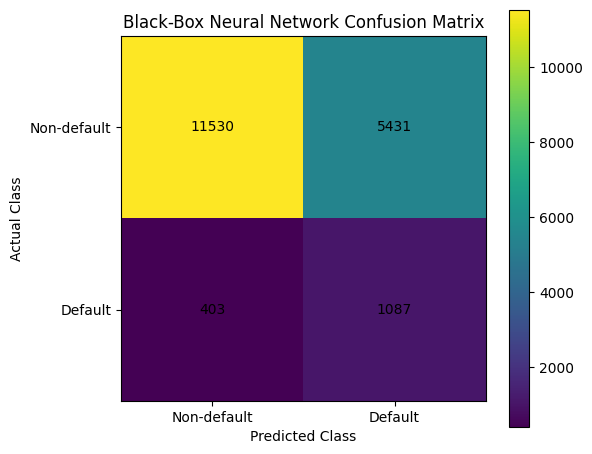

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Black-Box Neural Network Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["Non-default", "Default"])
plt.yticks([0, 1], ["Non-default", "Default"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation — Black-Box Neural Network

The confusion matrix shows how the neural network classified applicants in the test set into non-default and default categories. The model correctly predicted 11,530 non-default applicants as non-default and correctly identified 1,087 default applicants as default. However, it also produced 5,431 false positives, where applicants who did not default were predicted as default, and 403 false negatives, where applicants who actually defaulted were predicted as non-default.

This result shows that the neural network is strongly focused on detecting default cases. Out of 1,490 actual default applicants, the model correctly detected 1,087, giving a high recall of approximately 72.95%. This is useful in a credit-risk context because missed defaults can create financial losses for lenders. A low number of false negatives suggests that the model is relatively effective at identifying high-risk applicants.

However, the model also incorrectly classified a large number of non-default applicants as default. The 5,431 false positives indicate that many applicants who would have repaid their loans were treated as risky. This lowers precision and creates a fairness and business concern. From a business perspective, false positives may reduce loan approval opportunities and reject potentially profitable customers. From an ethical perspective, false positives may unfairly restrict access to credit, especially if these errors are concentrated among particular demographic or socio-economic groups.

Therefore, the confusion matrix highlights a clear trade-off. The neural network achieves strong default detection, but this comes at the cost of many false alarms. This behaviour may be acceptable if the main objective is to minimise credit loss, but it may be problematic if the objective is to balance risk detection with fair access to credit. Further threshold tuning and subgroup fairness analysis would be needed before using this model in a real lending decision system.

**ROC curve**

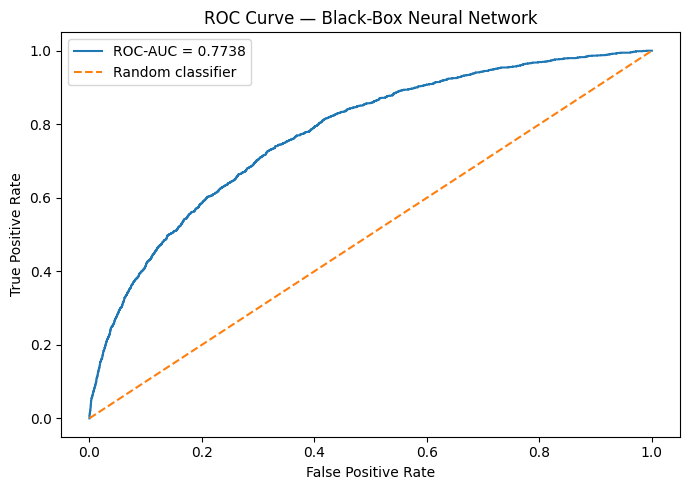

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Black-Box Neural Network")
plt.legend()
plt.tight_layout()
plt.show()

### ROC Curve Interpretation — Black-Box Neural Network

The ROC curve evaluates how well the neural network separates default and non-default applicants across different decision thresholds. The curve remains consistently above the random classifier line, showing that the model has meaningful predictive ability rather than making random classifications.

The ROC-AUC score is approximately 0.7738. This means the neural network has a reasonably strong ability to rank applicants by default risk. In practical terms, when comparing one default applicant and one non-default applicant, the model is likely to assign a higher risk score to the default applicant around 77% of the time.

However, the ROC curve should not be interpreted alone. Although the ROC-AUC is fairly strong, the confusion matrix showed that the selected threshold still produces many false positives. This means the model can rank risk reasonably well, but the final classification threshold may not be optimal for balancing credit-risk detection and fair loan approval decisions.

Therefore, the ROC curve suggests that the neural network is useful for risk ranking, but threshold tuning is still required. In a real lending context, the decision threshold should be selected based on business and ethical priorities, such as whether the main aim is to reduce missed defaults, reduce unfair rejections, or balance both objectives.

**Precision-recall curve**

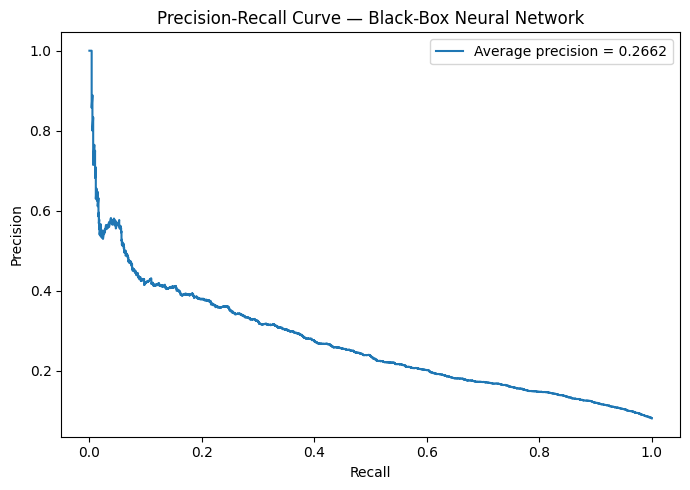

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_test_prob)
avg_precision = average_precision_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label=f"Average precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Black-Box Neural Network")
plt.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curve Interpretation — Black-Box Neural Network

The precision-recall curve provides a more focused evaluation of the neural network’s ability to identify the minority default class. This is important because the dataset is imbalanced, with non-default applicants being much more common than default applicants. In this context, accuracy and ROC-AUC alone can make the model appear stronger than it is for default detection.

The curve shows that precision falls as recall increases. This means that when the model tries to identify more actual default cases, it also produces more false positives. The average precision score is approximately 0.2662, which indicates that although the model can detect many defaults, its predicted default cases are not always reliable.

This result supports the pattern already observed in the confusion matrix. The neural network achieved high recall, meaning it detected many actual default applicants, but this came with low precision because many non-default applicants were also classified as default. In a lending context, this creates a trade-off between reducing financial risk and avoiding unfair rejection of creditworthy applicants.

Therefore, the precision-recall curve shows that the model is useful for identifying high-risk applicants, but its default predictions require careful threshold tuning. If the model were used in practice, the decision threshold should be adjusted based on the cost of missed defaults versus the ethical and business cost of falsely rejecting non-default applicants.

**Predicted probability distribution**

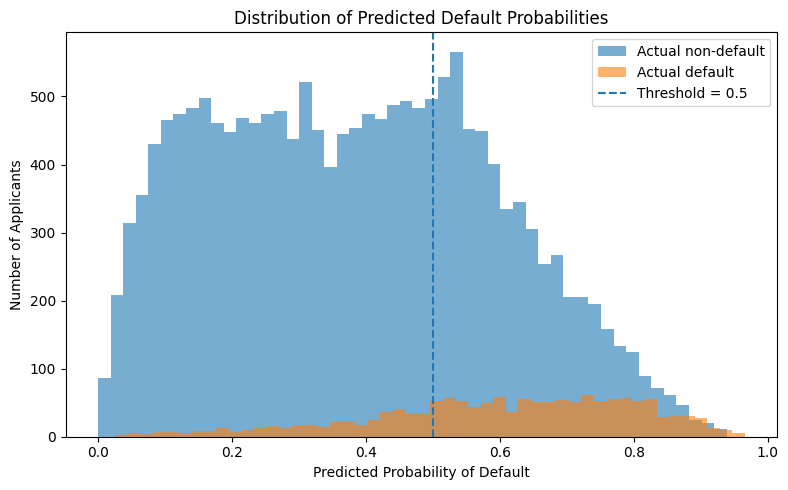

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_test_prob[y_test == 0], bins=50, alpha=0.6, label="Actual non-default")
plt.hist(y_test_prob[y_test == 1], bins=50, alpha=0.6, label="Actual default")
plt.axvline(decision_threshold, linestyle="--", label=f"Threshold = {decision_threshold}")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Applicants")
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

### Predicted Probability Distribution Interpretation — Black-Box Neural Network

The predicted probability distribution shows how the neural network assigns default-risk scores to actual non-default and actual default applicants. The dashed vertical line represents the decision threshold of 0.5. Applicants to the right of this threshold are classified as predicted defaults, while applicants to the left are classified as predicted non-defaults.

The plot shows that actual default applicants are generally shifted toward higher predicted default probabilities compared with non-default applicants. This suggests that the neural network has learned some meaningful separation between the two classes. However, there is also substantial overlap between the two distributions, especially around the 0.4 to 0.8 range. This overlap explains why the model produces both false positives and false negatives.

A large number of actual non-default applicants fall to the right of the 0.5 threshold. These cases become false positives, which matches the confusion matrix where many non-default applicants were incorrectly classified as default. At the same time, some actual default applicants fall below the threshold, creating false negatives. This shows that the model’s probability scores are informative but not cleanly separated enough to support perfect classification.

The threshold of 0.5 therefore has an important impact on the final predictions. Lowering the threshold would detect more defaults but increase false positives, while raising the threshold would reduce false positives but miss more actual defaults. In a credit-risk setting, this threshold should be selected carefully based on the relative cost of missed defaults, unnecessary credit rejection, and fairness concerns.

## Glass-Box vs Black-Box Model Comparison

### Overview

In this project, two glass-box models, Logistic Regression and Decision Tree, were compared with one black-box model, a Neural Network, for credit default risk prediction using the Home Credit dataset. In this dataset, TARGET = 0 means the customer repaid the loan, while TARGET = 1 means the customer had difficulty repaying the loan. Since this is a human credit scoring system, the model should not only predict well, but also provide explanations that can support fair and responsible financial decisions.


### Performance Comparison

| Model | Category | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|---|
| Logistic Regression | Classical ML (Glass-Box) | 0.7100 | 0.1800 | 0.7100 | 0.2800 | 0.7782 |
| Decision Tree | Classical ML (Glass-Box) | 0.6600 | 0.1500 | 0.6600 | 0.2400 | 0.7079 |
| Neural Network | Deep Learning (Black-Box) | 0.6838 | 0.1668 | 0.7295 | 0.2715 | 0.7738 |


The Neural Network achieved the highest sensitivity/recall score of 0.7295, meaning it identified the largest number of customers who had difficulty repaying their loans. This is important because a false negative in credit scoring means the model predicts that a customer will repay, but the customer actually struggles to repay. From a lender’s point of view, this is risky because it may lead to approving loans for high-risk applicants. However, the Neural Network’s improvement over Logistic Regression was small, as Logistic Regression also achieved a strong sensitivity of 0.7100.

The Logistic Regression model performed best overall when considering balance across the metrics. It achieved the highest accuracy, precision, F1-score, and ROC-AUC. This suggests that it had the strongest overall ability to separate customers who repaid from customers who had difficulty repaying. Its sensitivity was slightly lower than the Neural Network, but it offered a better overall balance between detecting risky customers and avoiding unnecessary false alarms. Logistic Regression is also naturally more interpretable because it is a linear model. Each feature contributes positively or negatively to the prediction, making it easier to explain than the Neural Network.

Specificity is also important in this scenario because it measures how well the model identifies customers who actually repaid the loan, meaning TARGET 0 cases. A model with low specificity may incorrectly classify many good customers as high-risk. This is a serious issue in a human credit scoring system because it could unfairly reject customers or give them worse loan conditions even though they would have repaid. Therefore, the model should not only have high sensitivity but should also maintain reasonable specificity.

The Decision Tree had the weakest predictive performance, with the lowest sensitivity, precision, F1-score, and ROC-AUC. However, it remains valuable from an explainability point of view because it works through clear if-then rules. A Decision Tree can be followed step by step, which makes it easier to explain to non-technical users. Its weakness is that it can become too simple if restricted, or overfit if allowed to grow too deeply. In this project, SHAP showed that the Decision Tree relied heavily on EXT_SOURCES_MEAN. This made the model easy to understand, but also created a weakness because the model could make wrong predictions when this feature gave a misleading signal.

The Neural Network is more complex because it learns non-linear patterns through hidden layers. This may explain why it achieved the highest sensitivity and detected slightly more customers with repayment difficulty. However, its internal decision-making process is not directly understandable. Because of this, SHAP was needed to explain the Neural Network’s predictions. Although SHAP improves transparency, it is still a post-hoc explanation method, meaning it explains the model after training rather than making the model fully transparent.

A key finding is that the more complex model did not strongly outperform the simpler glass-box models. The Neural Network had the best sensitivity, but Logistic Regression had a very similar ROC-AUC and better precision, F1-score, and accuracy. This suggests that for structured tabular financial data, a simpler interpretable model can perform almost as well as a deep learning model while being easier to justify.


#### Decision Tree — weakest predictive performance

The Decision Tree achieved the lowest scores across almost all evaluation metrics,
including recall (0.6600), F1-Score (0.2400), and ROC-AUC (0.7079). Although its
predictive performance was weaker, the model remains highly interpretable because
its decision-making process can be represented as transparent rule-based paths.


### Human-Centred AI Perspective

From a human-centred AI perspective, both sensitivity and specificity must be considered together. A false negative may expose the lender to financial loss because a risky customer is treated as safe. A false positive may unfairly affect a customer because someone who would have repaid the loan is treated as risky. Therefore, the best model is not only the one with the highest sensitivity or accuracy, but the one that gives a suitable balance between identifying repayment difficulty, protecting reliable customers, and providing explainable decisions.

Overall, the findings suggest that human-centred AI design should prioritise not only
predictive accuracy, but also the ability to provide fair, transparent, and explainable
financial decisions.

### Conclusion

Overall, Logistic Regression appears to provide the best balance for this Home Credit scoring task. It performed strongly across the metrics and still it is easier to understand, The Neural Network may be useful when the main aim is to catch as many high-risk customers as possible, but it requires SHAP explanations and human review because of its black-box nature. The Decision Tree is the easiest to explain, but its lower performance means it should thourly study and do changes to get better results.

In [ ]:
# ============================================================
# Glass-Box vs Black-Box Model Comparison Using Saved Results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Glass-box model results extracted from previous glass-box notebook
# ------------------------------------------------------------

lr_metrics = {
    "Accuracy": 0.71,
    "Precision": 0.18,
    "Recall": 0.71,
    "F1-Score": 0.28,
    "ROC-AUC": 0.7782
}

dt_metrics = {
    "Accuracy": 0.66,
    "Precision": 0.15,
    "Recall": 0.66,
    "F1-Score": 0.24,
    "ROC-AUC": 0.7079
}

# ------------------------------------------------------------
# Neural network metrics from current saved-model evaluation notebook
# ------------------------------------------------------------

nn_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob)
}

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Logistic Regression (Glass-Box)": lr_metrics,
    "Decision Tree (Glass-Box)": dt_metrics,
    "Neural Network (Black-Box)": nn_metrics
}).T.round(4)

display(comparison)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression (Glass-Box),0.7100,0.1800,0.7100,0.2800,0.7782
Decision Tree (Glass-Box),0.6600,0.1500,0.6600,0.2400,0.7079
Neural Network (Black-Box),0.6838,0.1668,0.7295,0.2715,0.7738


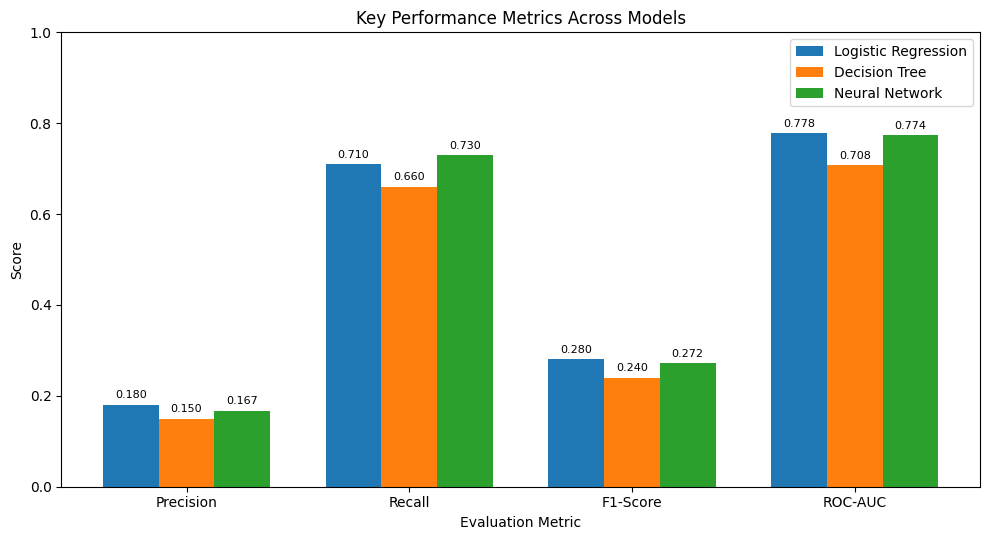

In [ ]:
# ============================================================
# Key Metrics Comparison: Precision, Recall, F1-Score, ROC-AUC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

key_metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
key_comparison = comparison[key_metrics]

x = np.arange(len(key_metrics))
width = 0.25

lr_vals = key_comparison.loc["Logistic Regression (Glass-Box)"].values
dt_vals = key_comparison.loc["Decision Tree (Glass-Box)"].values
nn_vals = key_comparison.loc["Neural Network (Black-Box)"].values

plt.figure(figsize=(10, 5.5))

bars1 = plt.bar(x - width, lr_vals, width, label="Logistic Regression")
bars2 = plt.bar(x, dt_vals, width, label="Decision Tree")
bars3 = plt.bar(x + width, nn_vals, width, label="Neural Network")

plt.xticks(x, key_metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Key Performance Metrics Across Models")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.show()

## SHAP Explainability for Neural Network

Although the neural network achieved good predictive performance, it is still considered a black-box model because it is difficult to directly understand how the model makes decisions. To improve interpretability and provide more transparency, SHAP (SHapley Additive exPlanations) was applied to the final neural network model.

SHAP helps explain the contribution of each feature to the prediction output. This allows us to identify which variables had the strongest influence on predicting customer default risk. Using SHAP also makes the model more trustworthy and easier to analyse in a financial decision-making context.

### Installing and Importing SHAP Libraries

The SHAP library and required packages such as NumPy, Pandas, and Matplotlib were first imported. These libraries were used for generating explanations and visualising feature importance.

### Creating Smaller Samples for SHAP

Since SHAP calculations for neural networks can be computationally expensive, smaller subsets of the training and test datasets were selected. A background sample of 100 observations was created from the training data, while 200 observations were selected from the test data for explanation purposes.

Random sampling was used to ensure that the selected observations represented different parts of the dataset while also reducing execution time.

### Defining the Prediction Function

A custom prediction function called `model_predict()` was created. This function allows SHAP to interact with the trained neural network model and generate prediction probabilities for the selected samples.

### Creating the SHAP Explainer

The `KernelExplainer` method was used to create the SHAP explainer. This approach is model-agnostic, meaning it can explain complex black-box models such as neural networks even when the internal structure is difficult to interpret directly.

The explainer uses the selected background data to estimate the contribution of each feature to the prediction output.

### Calculating SHAP Values

Finally, SHAP values were calculated for the selected test observations. These SHAP values represent the impact of each feature on the prediction outcome. Positive SHAP values increase the likelihood of predicting default, while negative values reduce it.

This explainability step provides additional insight into the behaviour of the neural network model and helps identify the most influential financial and behavioural features affecting customer credit risk predictions.

### Checking SHAP Input Consistency

Before applying SHAP, the dimensions of the training data, test data and feature-name list were compared. This check ensures that the background data, explanation data and feature labels all refer to the same 499 input features.

This is important because SHAP explanations are feature-level explanations. If the feature names do not match the model input order or feature count, the resulting explanations could be misleading. This check confirms that the saved data package is suitable for SHAP analysis.

In [ ]:
assert list(X_test_nn.columns) == feature_names, "Feature order does not match saved feature_names."
assert list(X_train_nn.columns) == feature_names, "Training feature order does not match saved feature_names."

print("Feature order is consistent with saved feature names.")

Feature order is consistent with saved feature names.


### Validating Data Consistency for SHAP

Before applying SHAP, the saved training data, test data and feature-name list were checked for consistency. SHAP produces feature-level explanations, so the background data, explanation data and feature labels must all refer to the same model input structure.

In this step, `X_train_nn`, `X_test_nn` and `feature_names` were loaded from the saved `nn_data_package.joblib` file. The number of features in the training and test sets was compared, and the number of saved feature names was checked against the test-set feature count.

In [ ]:
X_train_nn = data_package["X_train_nn"]
X_test_nn = data_package["X_test_nn"]
feature_names = data_package["feature_names"]

print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)
print("Number of feature names:", len(feature_names))

assert X_train_nn.shape[1] == X_test_nn.shape[1], "Train and test feature dimensions do not match."
assert X_test_nn.shape[1] == len(feature_names), "Feature names do not match test data columns."

print("SHAP setup looks valid.")

X_train_nn shape: (215257, 499)
X_test_nn shape: (18451, 499)
Number of feature names: 499
SHAP setup looks valid.


The output confirms that both the training and test datasets contain 499 features, and that there are 499 corresponding feature names. This means the saved data package is suitable for SHAP analysis, because SHAP values can be correctly mapped back to the processed feature names used by the neural network.

In [ ]:
# ============================================================
# Load saved neural network model and data for SHAP
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


!pip install shap -q
import shap

# ============================================================
# Load saved full model
# ============================================================

model_path = "full_model.keras"

if not os.path.exists(model_path):
    model_path = "full_model.h5"

loaded_model = tf.keras.models.load_model(model_path, compile=False)

print("Model loaded from:", model_path)
print("Model input shape:", loaded_model.input_shape)

# ============================================================
# Load saved neural-network-ready data package
# ============================================================

data_package = joblib.load("nn_data_package.joblib")

X_train_nn = data_package["X_train_nn"]
X_val_nn = data_package["X_val_nn"]
X_test_nn = data_package["X_test_nn"]

y_train = data_package["y_train"]
y_val = data_package["y_val"]
y_test = data_package["y_test"]

feature_names = data_package["feature_names"]
decision_threshold = data_package["decision_threshold"]

print("Data package loaded successfully.")
print("X_train_nn shape:", X_train_nn.shape)
print("X_val_nn shape:", X_val_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)
print("Number of feature names:", len(feature_names))
print("Decision threshold:", decision_threshold)

# ============================================================
# Compatibility checks
# ============================================================

assert X_test_nn.shape[1] == loaded_model.input_shape[-1], "Model input size does not match X_test_nn."
assert X_test_nn.shape[1] == len(feature_names), "Feature names length does not match X_test_nn."

if hasattr(X_test_nn, "columns"):
    assert list(X_test_nn.columns) == feature_names, "X_test_nn column order does not match feature_names."

if hasattr(X_train_nn, "columns"):
    assert list(X_train_nn.columns) == feature_names, "X_train_nn column order does not match feature_names."

print("Saved model and SHAP data are compatible.")

2026-05-14 21:16:45.310581: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 750 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6


Model loaded from: full_model.keras
Model input shape: (None, 499)
Data package loaded successfully.
X_train_nn shape: (215257, 499)
X_val_nn shape: (73803, 499)
X_test_nn shape: (18451, 499)
Number of feature names: 499
Decision threshold: 0.5
Saved model and SHAP data are compatible.


In [ ]:
# ============================================================
# Create smaller samples for SHAP
# ============================================================

background_size = 25
explain_size = 40

np.random.seed(42)

background_idx = np.random.choice(
    X_train_nn.shape[0],
    size=background_size,
    replace=False
)

explain_idx = np.random.choice(
    X_test_nn.shape[0],
    size=explain_size,
    replace=False
)

X_background = X_train_nn.iloc[background_idx]
X_explain = X_test_nn.iloc[explain_idx]

print("Background sample shape:", X_background.shape)
print("Explanation sample shape:", X_explain.shape)

Background sample shape: (25, 499)
Explanation sample shape: (40, 499)


In [ ]:
# ============================================================
# Memory-safe prediction function for SHAP
# ============================================================

def model_predict(data):
    data_df = pd.DataFrame(data, columns=feature_names)

    preds = loaded_model.predict(
        data_df,
        batch_size=128,
        verbose=0
    ).ravel()

    return preds

In [ ]:
# ============================================================
# Create SHAP explainer
# ============================================================

explainer = shap.KernelExplainer(
    model_predict,
    X_background
)

2026-05-14 21:16:58.027433: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [ ]:
# ============================================================
# Calculate SHAP values
# ============================================================

shap_values = explainer.shap_values(
    X_explain,
    nsamples=100,
    l1_reg="num_features(20)"
)

print("SHAP values calculated successfully.")

  0%|          | 0/40 [00:00<?, ?it/s]

Linear regression equation is singular, Moore-Penrose pseudoinverse is used instead of the regular inverse.
To use regular inverse do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.


SHAP values calculated successfully.


Kernel SHAP produced a singular linear regression warning because the model contains 499 input features and the explanation sample is intentionally small for memory efficiency. SHAP handled this by using the Moore-Penrose pseudoinverse, and the SHAP values were still calculated successfully. To improve stability and reduce computational cost, L1 feature regularisation was applied using `l1_reg="num_features(20)"`.

In [ ]:
# ============================================================
# Prepare SHAP values for analysis
# ============================================================

shap_values_plot = np.array(shap_values)

# KernelExplainer may return different shapes depending on SHAP version
if shap_values_plot.ndim == 3:
    shap_values_plot = shap_values_plot[:, :, 0]

print("SHAP values shape:", shap_values_plot.shape)
print("X_explain shape:", X_explain.shape)
print("Number of feature names:", len(feature_names))

assert shap_values_plot.shape[1] == len(feature_names), "SHAP values do not match feature names."

print("SHAP values are ready for analysis.")

SHAP values shape: (40, 499)
X_explain shape: (40, 499)
Number of feature names: 499
SHAP values are ready for analysis.


,Feature,Mean_ABS_SHAP
3,EXT_SOURCE_2,0.009318
308,CODE_GENDER_F,0.006677
0,EXT_SOURCES_MEAN,0.006238
237,INS_PAYMENT_DIFFERENCE_MAX,0.006085
14,CREDIT_TO_GOODS_RATIO,0.004828
221,PREV_CASH_APPLICATION_CREDIT_DIFF_MIN,0.004466
170,BASEMENTAREA_AVG,0.004356
286,REFUSED_CREDIT_TO_ANNUITY_RATIO_MEAN,0.004119
185,BUREAU_CONSUMER_AMT_CREDIT_SUM_DEBT_MEAN,0.003784
166,PREV_LAST12M_DAYS_DECISION_MEAN,0.003695


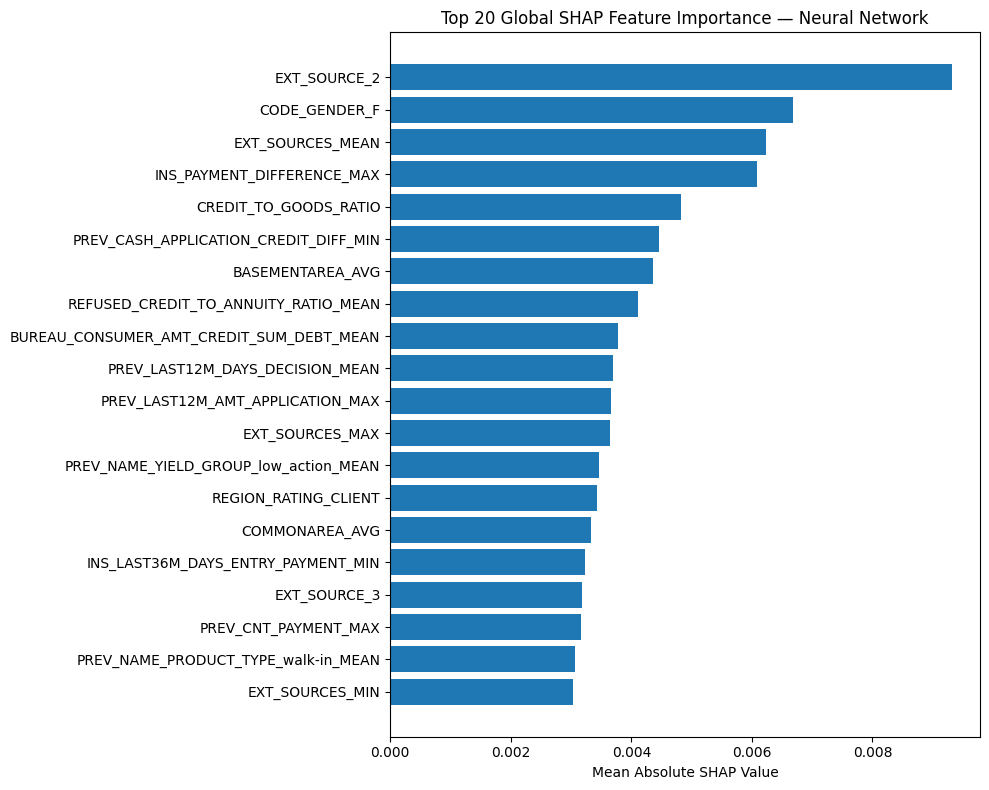

In [ ]:
# ============================================================
# Global SHAP Feature Importance
# ============================================================

mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_ABS_SHAP": mean_abs_shap
}).sort_values("Mean_ABS_SHAP", ascending=False)

display(shap_importance.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    shap_importance.head(20)["Feature"][::-1],
    shap_importance.head(20)["Mean_ABS_SHAP"][::-1]
)
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 20 Global SHAP Feature Importance — Neural Network")
plt.tight_layout()
plt.show()

# Section 5
## Emerging Techniques — Feature Importance & Model Compression

This section implements two emerging techniques as part of the ETech module:
**Feature Importance** and **Model Compression through Pruning**.

**Feature Importance** (Technique 1) helps us identify which features
contribute most to each model's predictions. With 500 features in our
dataset, many variables may add noise or redundancy rather than useful
signal. By extracting and analysing feature importance, we can reduce
the feature space and retrain the models to see whether a simpler
input set maintains competitive performance.

**Model Compression through Pruning** (Technique 2) reduces the complexity
of the Decision Tree by constraining its maximum depth. This produces a
smaller, faster, and more interpretable model. We compare performance
across different depth settings to find the best trade-off between
complexity and predictive power.

These techniques are applied as follows:
- Feature Importance → Logistic Regression (coefficients) and
  Decision Tree (Gini importance)
- Pruning → Decision Tree only, as pruning is specific to tree-based
  models and cannot be meaningfully applied to Logistic Regression

Both techniques directly support our research questions:
- RQ2 — Feature Importance directly answers which features most
  influence loan default predictions, and how Logistic Regression and
  Decision Tree differ in how they rank features. This also contributes
  to understanding model transparency.
- RQ1 — Model Compression through Pruning allows us to evaluate
  whether a simpler, compressed model can still perform competitively
  against the full glass-box model, which feeds into the broader
  comparison between interpretable and deep learning models.

### 5.1 Feature Importance

Feature Importance is a technique that measures how much each input
feature contributes to a model's predictions. In our dataset with
500 features, it is important to understand which variables are
driving the model's decisions and which ones are adding little value.

This technique directly addresses RQ2 of our project, which asks
which features most influence loan default predictions and how these
differ between interpretable models.

**How we extract feature importance:**

For Logistic Regression, we use the absolute values of the model
coefficients. Since the training data is scaled, all coefficients are
on the same scale and can be directly compared. A larger absolute
coefficient means the feature has a stronger effect on the predicted
probability of default.

For the Decision Tree, we use the built-in `feature_importances_`
attribute, which measures how much each feature reduces Gini impurity
across all splits in the tree. A higher value means the feature is
used more often and contributes more to the model's decisions.

We first visualise the top 20 most important features for each model,
then identify low-importance features, remove them, retrain both models,
and compare performance before and after the reduction.

4.1 FEATURE IMPORTANCE

--- Logistic Regression: Feature Importance ---


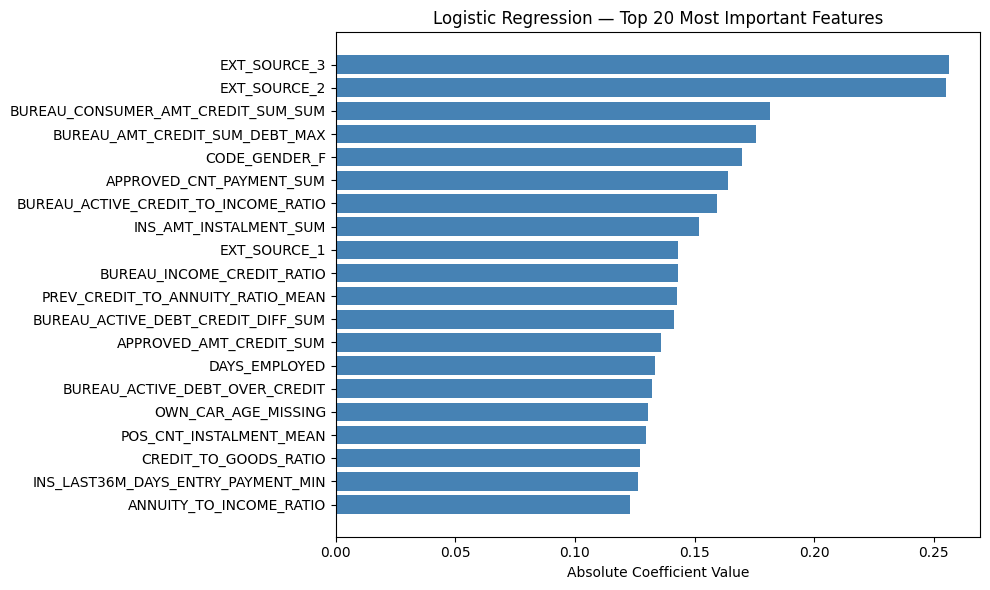


Top 10 features (Logistic Regression):
                             Feature  Importance
                        EXT_SOURCE_3    0.256566
                        EXT_SOURCE_2    0.255108
  BUREAU_CONSUMER_AMT_CREDIT_SUM_SUM    0.181375
      BUREAU_AMT_CREDIT_SUM_DEBT_MAX    0.175561
                       CODE_GENDER_F    0.170064
            APPROVED_CNT_PAYMENT_SUM    0.164139
BUREAU_ACTIVE_CREDIT_TO_INCOME_RATIO    0.159228
              INS_AMT_INSTALMENT_SUM    0.151993
                        EXT_SOURCE_1    0.142977
          BUREAU_INCOME_CREDIT_RATIO    0.142888

--- Decision Tree: Feature Importance ---


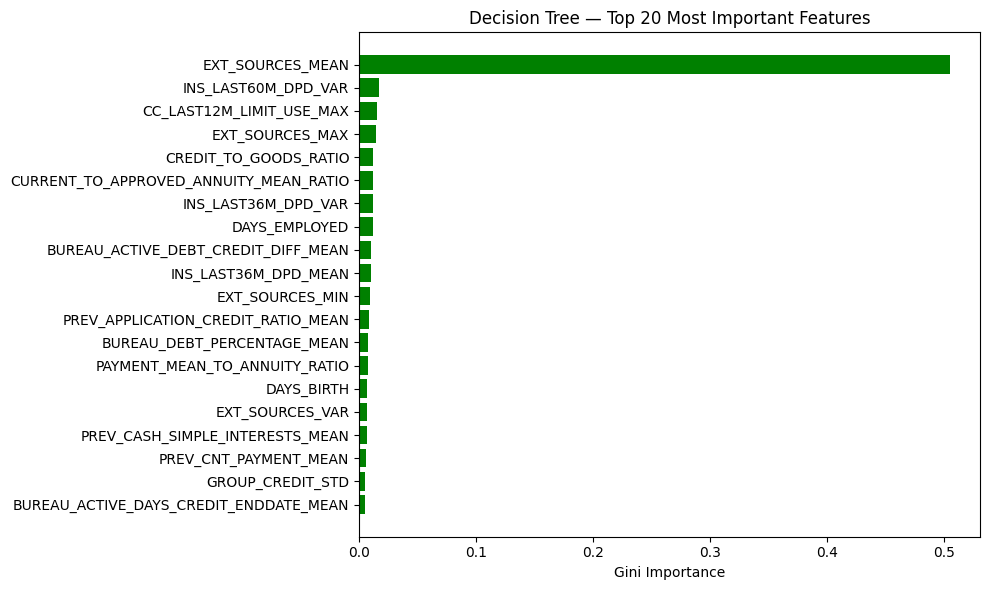


Top 10 features (Decision Tree):
                               Feature  Importance
                      EXT_SOURCES_MEAN    0.505542
                   INS_LAST60M_DPD_VAR    0.016689
              CC_LAST12M_LIMIT_USE_MAX    0.014894
                       EXT_SOURCES_MAX    0.014027
                 CREDIT_TO_GOODS_RATIO    0.012127
CURRENT_TO_APPROVED_ANNUITY_MEAN_RATIO    0.012023
                   INS_LAST36M_DPD_VAR    0.011842
                         DAYS_EMPLOYED    0.011785
   BUREAU_ACTIVE_DEBT_CREDIT_DIFF_MEAN    0.010287
                  INS_LAST36M_DPD_MEAN    0.009943

--- Low Importance Feature Analysis ---

Logistic Regression:
  Features with zero importance:     0
  Features with importance < 0.001:  9

Decision Tree:
  Features with zero importance:     229
  Features with importance < 0.001:  367

--- Common Top 10 Features (Both Models) ---
Features appearing in top 10 of both models:


In [ ]:
print("=" * 60)
print("4.1 FEATURE IMPORTANCE")
print("=" * 60)

# === LOGISTIC REGRESSION — Feature Importance via Coefficients ===
print("\n--- Logistic Regression: Feature Importance ---")

lr_importance = pd.DataFrame({
    "Feature": X_train_lr.columns,
    "Importance": np.abs(lr_model.coef_[0])
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(
    lr_importance["Feature"].head(20)[::-1],
    lr_importance["Importance"].head(20)[::-1],
    color="steelblue"
)
plt.xlabel("Absolute Coefficient Value")
plt.title("Logistic Regression — Top 20 Most Important Features")
plt.tight_layout()
plt.show()

print("\nTop 10 features (Logistic Regression):")
print(lr_importance.head(10).to_string(index=False))

# === DECISION TREE — Feature Importance via Gini Impurity ===
print("\n--- Decision Tree: Feature Importance ---")

dt_importance = pd.DataFrame({
    "Feature": X_train_dt.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(
    dt_importance["Feature"].head(20)[::-1],
    dt_importance["Importance"].head(20)[::-1],
    color="green"
)
plt.xlabel("Gini Importance")
plt.title("Decision Tree — Top 20 Most Important Features")
plt.tight_layout()
plt.show()

print("\nTop 10 features (Decision Tree):")
print(dt_importance.head(10).to_string(index=False))

# === Low Importance Feature Analysis ===
print("\n--- Low Importance Feature Analysis ---")

lr_zero = (lr_importance["Importance"] == 0).sum()
lr_near_zero = (lr_importance["Importance"] < 0.001).sum()
dt_zero = (dt_importance["Importance"] == 0).sum()
dt_near_zero = (dt_importance["Importance"] < 0.001).sum()

print(f"\nLogistic Regression:")
print(f"  Features with zero importance:     {lr_zero}")
print(f"  Features with importance < 0.001:  {lr_near_zero}")
print(f"\nDecision Tree:")
print(f"  Features with zero importance:     {dt_zero}")
print(f"  Features with importance < 0.001:  {dt_near_zero}")

# === Common Top Features ===
print("\n--- Common Top 10 Features (Both Models) ---")
lr_top = set(lr_importance.head(10)["Feature"])
dt_top = set(dt_importance.head(10)["Feature"])
common = lr_top.intersection(dt_top)
print(f"Features appearing in top 10 of both models:")
for f in common:
    print(f"  - {f}")

#### Feature Importance

**Logistic Regression** identified the following as its most influential
features: `EXT_SOURCE_3` (0.256), `EXT_SOURCE_2` (0.255),
and `BUREAU_CONSUMER_AMT_CREDIT_SUM_SUM` (0.181). The dominance of external credit scores
(`EXT_SOURCE_2` and `EXT_SOURCE_3`) is expected, as these variables
represent external credit assessments and are widely recognised as
strong predictors of loan default risk. The importance of
`BUREAU_CONSUMER_AMT_CREDIT_SUM_SUM` suggests that accumulated credit exposure
from bureau records is also a strong indicator of repayment behaviour.

**Decision Tree** showed a very different pattern. `EXT_SOURCES_MEAN`
dominated with an importance of 0.506, meaning approximately 50% of the
tree's predictive power comes from a single aggregated feature. This
indicates that the Decision Tree relies heavily on one variable, which
may make it less robust compared to Logistic Regression, which distributes
importance more evenly across multiple features.

**Comparing the two models** reveals an important finding for RQ2: the
top 10 features of Logistic Regression and Decision Tree have no features
in common. This is because the two models use the same underlying
information in different forms, Logistic Regression uses individual
external scores (`EXT_SOURCE_2`, `EXT_SOURCE_3`) separately, while the
Decision Tree uses their aggregated version (`EXT_SOURCES_MEAN`). This
demonstrates how different model architectures can reach similar
predictions through very different reasoning paths.

**Low importance analysis** revealed a large number of redundant features,
particularly in the Decision Tree:

| Model | Zero Importance | Importance < 0.001 |
|-------|----------------|-------------------|
| Logistic Regression | 0 | 9 |
| Decision Tree | 229 | 367 |

The Decision Tree effectively ignores 229 features entirely,
and 367 features have near-zero importance. This suggests significant
redundancy in our feature set and motivates the feature reduction step
in the next section.

### 5.2 Feature Reduction and Model Retraining

Based on the feature importance analysis in Section 5.1, we identified
a large number of low-importance features in both models. The Decision
Tree effectively ignores 229 out of 500 features entirely, while
Logistic Regression has 9 features with near-zero importance.

In this step, we remove low-importance features and retrain both models
on the reduced feature set. The goal is to investigate whether a simpler
model with fewer features can maintain competitive performance while
being faster to train and easier to interpret.

**Feature selection strategy:**

For **Logistic Regression**, we remove features where the absolute
coefficient value is exactly zero. These features have no effect on
the model's predictions and can be safely removed.

For **Decision Tree**, we remove features where `feature_importances_`
is exactly zero. With 229 zero-importance features, this is a significant
reduction that should produce a much smaller and faster model.

We then retrain both models on the reduced datasets and compare
performance against the original models using ROC-AUC, Default Recall,
Default F1, and training time.

5.2 FEATURE REDUCTION AND MODEL RETRAINING

--- Logistic Regression: Feature Reduction ---
Original feature count: 500
Selected feature count: 500
Removed features:       0

Retraining completed in 2443.2 seconds
ROC-AUC (reduced):  0.7782
ROC-AUC (original): 0.7782

--- Decision Tree: Feature Reduction ---
Original feature count: 500
Selected feature count: 271
Removed features:       229

Retraining completed in 80.2 seconds
ROC-AUC (reduced):  0.7079
ROC-AUC (original): 0.7079

--- Feature Reduction Comparison ---
               Features  ROC-AUC  Default Recall  Default F1  Train Time (s)
Model                                                                       
LR — Original       500   0.7782          0.7063      0.2850       2486.5901
LR — Reduced        500   0.7782          0.7063      0.2850       2443.2190
DT — Original       500   0.7079          0.6614      0.2406        106.6707
DT — Reduced        271   0.7079          0.6614      0.2406         80.1752


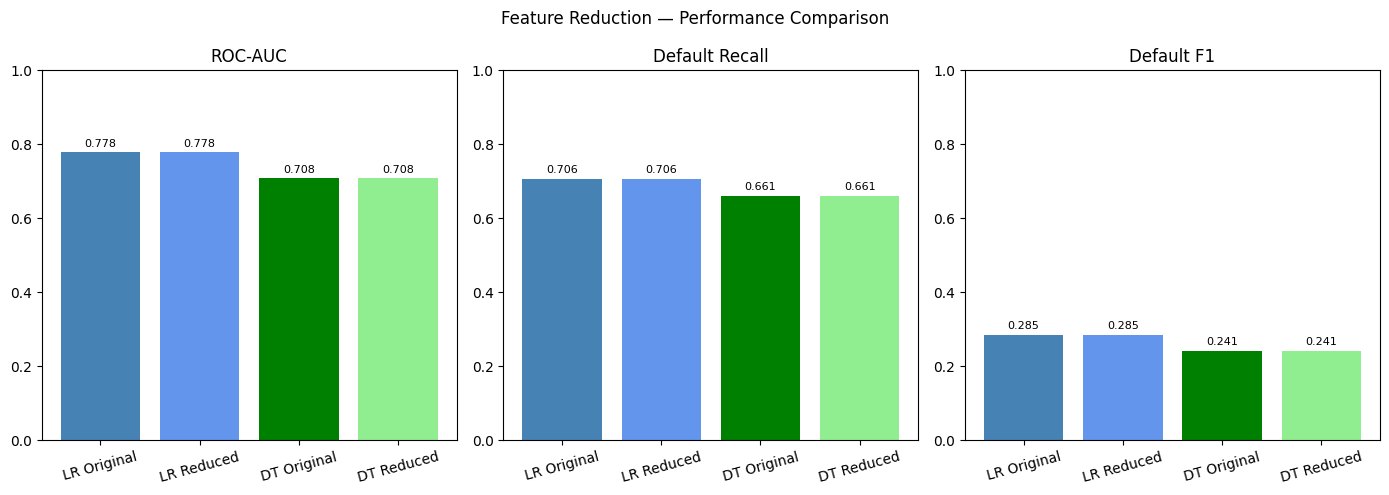

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score, roc_curve
import time

print("=" * 60)
print("5.2 FEATURE REDUCTION AND MODEL RETRAINING")
print("=" * 60)

# === LOGISTIC REGRESSION — Remove zero importance features ===
print("\n--- Logistic Regression: Feature Reduction ---")

lr_selected_features = lr_importance[
    lr_importance["Importance"] > 0
]["Feature"].tolist()

print(f"Original feature count: {X_train_lr.shape[1]}")
print(f"Selected feature count: {len(lr_selected_features)}")
print(f"Removed features:       {X_train_lr.shape[1] - len(lr_selected_features)}")

X_train_lr_reduced = X_train_lr[lr_selected_features]
X_test_lr_reduced = X_test_lr[lr_selected_features]

# Retrain LR on reduced features
lr_reduced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="saga",
    C=0.01,
    random_state=42,
    n_jobs=-1
)

start = time.time()
lr_reduced.fit(X_train_lr_reduced, y_train_lr)
lr_reduced_train_time = time.time() - start

lr_reduced_pred = lr_reduced.predict(X_test_lr_reduced)
lr_reduced_prob = lr_reduced.predict_proba(X_test_lr_reduced)[:, 1]
lr_reduced_roc_auc = roc_auc_score(y_test_lr, lr_reduced_prob)

print(f"\nRetraining completed in {lr_reduced_train_time:.1f} seconds")
print(f"ROC-AUC (reduced):  {lr_reduced_roc_auc:.4f}")
print(f"ROC-AUC (original): {lr1000_roc_auc:.4f}")

# === DECISION TREE — Remove zero importance features ===
print("\n--- Decision Tree: Feature Reduction ---")

dt_selected_features = dt_importance[
    dt_importance["Importance"] > 0
]["Feature"].tolist()

print(f"Original feature count: {X_train_dt.shape[1]}")
print(f"Selected feature count: {len(dt_selected_features)}")
print(f"Removed features:       {X_train_dt.shape[1] - len(dt_selected_features)}")

X_train_dt_reduced = X_train_dt[dt_selected_features]
X_test_dt_reduced = X_test_dt[dt_selected_features]

# Retrain DT on reduced features
dt_reduced = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=50,
    criterion="gini",
    random_state=42
)

start = time.time()
dt_reduced.fit(X_train_dt_reduced, y_train_dt)
dt_reduced_train_time = time.time() - start

dt_reduced_pred = dt_reduced.predict(X_test_dt_reduced)
dt_reduced_prob = dt_reduced.predict_proba(X_test_dt_reduced)[:, 1]
dt_reduced_roc_auc = roc_auc_score(y_test_dt, dt_reduced_prob)

print(f"\nRetraining completed in {dt_reduced_train_time:.1f} seconds")
print(f"ROC-AUC (reduced):  {dt_reduced_roc_auc:.4f}")
print(f"ROC-AUC (original): {dt_roc_auc:.4f}")

# === Comparison Table ===
print("\n--- Feature Reduction Comparison ---")

comparison_reduction = pd.DataFrame({
    "Model": [
        "LR — Original", "LR — Reduced",
        "DT — Original", "DT — Reduced"
    ],
    "Features": [
        X_train_lr.shape[1], len(lr_selected_features),
        X_train_dt.shape[1], len(dt_selected_features)
    ],
    "ROC-AUC": [
        lr1000_roc_auc, lr_reduced_roc_auc,
        dt_roc_auc, dt_reduced_roc_auc
    ],
    "Default Recall": [
        recall_score(y_test_lr, lr1000_pred),
        recall_score(y_test_lr, lr_reduced_pred),
        recall_score(y_test_dt, dt_pred),
        recall_score(y_test_dt, dt_reduced_pred)
    ],
    "Default F1": [
        f1_score(y_test_lr, lr1000_pred),
        f1_score(y_test_lr, lr_reduced_pred),
        f1_score(y_test_dt, dt_pred),
        f1_score(y_test_dt, dt_reduced_pred)
    ],
    "Train Time (s)": [
        lr1000_train_time, lr_reduced_train_time,
        dt_train_time, dt_reduced_train_time
    ]
})

comparison_reduction = comparison_reduction.set_index("Model").round(4)
print(comparison_reduction.to_string())

# === Bar Chart ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["ROC-AUC", "Default Recall", "Default F1"]

for i, metric in enumerate(metrics):
    vals = comparison_reduction[metric].values
    labels = ["LR Original", "LR Reduced", "DT Original", "DT Reduced"]
    colors = ["steelblue", "cornflowerblue", "green", "lightgreen"]
    bars = axes[i].bar(labels, vals, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.0)
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Feature Reduction — Performance Comparison")
plt.tight_layout()
plt.show()

#### Feature Reduction and Model Retraining

The feature reduction results show a clear difference between how
Logistic Regression and Decision Tree use the available features.

**Logistic Regression** had no features with zero importance,
so the feature set remained unchanged at 500 features. As expected,
this had no effect on model performance, ROC-AUC, Default Recall, and
Default F1 remained identical at 0.7782, 0.706, and 0.285 respectively.
Training time also changed only slightly, decreasing from 2486.6s to
2443.2s. This suggests that Logistic Regression already distributes
importance across the available features through regularisation, leaving
very few truly redundant variables.

**Decision Tree** showed a much more dramatic reduction. 229 zero-importance
features were removed, reducing the feature set from 500 to 271, a 46%
reduction in input size. Despite this, the model performance remained
completely unchanged:

| | Original | Reduced | Change |
|--|---------|---------|--------|
| Features | 500 | 271 | -229 |
| ROC-AUC | 0.7079 | 0.7079 | 0.0000 |
| Default Recall | 0.6614 | 0.6614 | 0.0000 |
| Default F1 | 0.2406 | 0.2406 | 0.0000 |
| Train Time | 106.7s | 80.2s | **-25%** |

The most significant finding is that removing 229 features from the
Decision Tree reduced training time by approximately 25% while causing
no loss in predictive performance. This demonstrates the value of feature
importance as an emerging technique, it allows us to identify and
remove redundant features, producing a faster and simpler model without
sacrificing quality.

These results also support our earlier finding that the Decision Tree
relies heavily on a small number of features, particularly
`EXT_SOURCES_MEAN`, which alone accounted for approximately 50% of
the model's importance. The remaining 229 features contributed nothing
to the model's decisions and could be safely removed.

Overall, feature reduction is most impactful for the Decision Tree,
where it produces a significantly more efficient model. For Logistic
Regression, the regularisation already handles feature redundancy
internally, making explicit feature removal less necessary.

### 5.3 Model Compression — Pruning

Model Compression through Pruning is our second emerging technique.
Pruning reduces the complexity of a Decision Tree by limiting its
maximum depth. A shallower tree has fewer nodes and leaves, which
makes it faster to train, smaller in memory, and easier to interpret.

**Why Pruning?**

Our original Decision Tree was trained with `max_depth=10`, producing
590 leaf nodes. While this gives good predictive performance, a deeper
tree is harder to interpret and more prone to overfitting. By reducing
the depth, we can find a simpler model that still performs competitively.

Pruning directly supports RQ1, if a compressed, simpler model
performs similarly to the full model, this raises questions about
whether the added complexity of deeper trees or black-box models
is always justified.

**How we apply pruning:**

We train four versions of the Decision Tree with different maximum
depths: 3, 5, 7, and 10 (original). For each version we record:
- ROC-AUC, Default Recall, Default F1
- Number of leaves
- Training time

This allows us to identify the best trade-off between model complexity
and predictive performance.

5.3 MODEL COMPRESSION — PRUNING

Training Decision Tree with max_depth=3...
  Leaves: 8
  ROC-AUC: 0.7123
  Default Recall: 0.7076
  Default F1: 0.2364
  Train Time: 35.1s

Training Decision Tree with max_depth=5...
  Leaves: 32
  ROC-AUC: 0.7260
  Default Recall: 0.6753
  Default F1: 0.2468
  Train Time: 53.6s

Training Decision Tree with max_depth=7...
  Leaves: 124
  ROC-AUC: 0.7281
  Default Recall: 0.6771
  Default F1: 0.2506
  Train Time: 75.8s

Training Decision Tree with max_depth=10...
  Leaves: 590
  ROC-AUC: 0.7079
  Default Recall: 0.6614
  Default F1: 0.2406
  Train Time: 104.4s

--- Pruning Comparison Table ---
           Leaves  ROC-AUC  Default Recall  Default F1  Train Time (s)
Max Depth                                                             
3               8   0.7123          0.7076      0.2364            35.1
5              32   0.7260          0.6753      0.2468            53.6
7             124   0.7281          0.6771      0.2506            75.8
10          

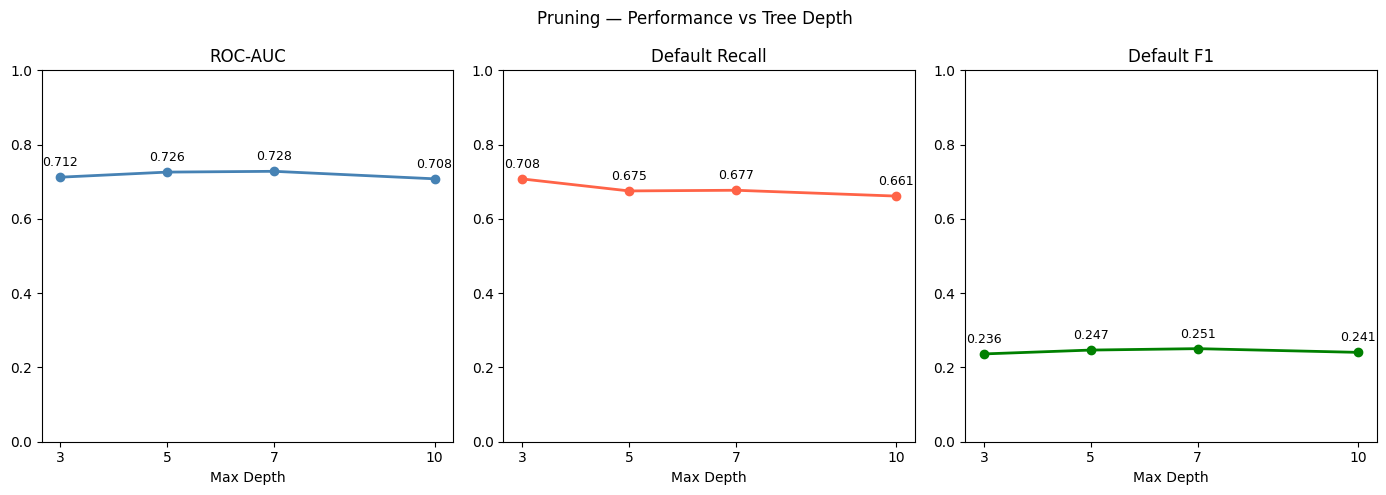

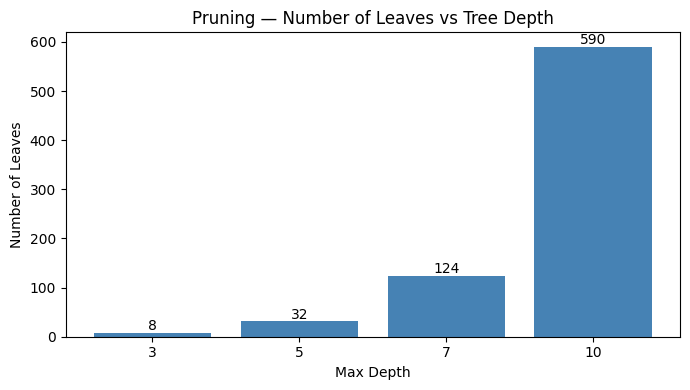

In [ ]:
print("=" * 60)
print("5.3 MODEL COMPRESSION — PRUNING")
print("=" * 60)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import time

depths = [3, 5, 7, 10]
pruning_results = []

for depth in depths:
    print(f"\nTraining Decision Tree with max_depth={depth}...")

    dt_pruned = DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=depth,
        min_samples_leaf=50,
        criterion="gini",
        random_state=42
    )

    start = time.time()
    dt_pruned.fit(X_train_dt, y_train_dt)
    train_time = time.time() - start

    pred = dt_pruned.predict(X_test_dt)
    prob = dt_pruned.predict_proba(X_test_dt)[:, 1]

    roc = roc_auc_score(y_test_dt, prob)
    rec = recall_score(y_test_dt, pred)
    f1 = f1_score(y_test_dt, pred)
    leaves = dt_pruned.get_n_leaves()

    pruning_results.append({
        "Max Depth": depth,
        "Leaves": leaves,
        "ROC-AUC": round(roc, 4),
        "Default Recall": round(rec, 4),
        "Default F1": round(f1, 4),
        "Train Time (s)": round(train_time, 1)
    })

    print(f"  Leaves: {leaves}")
    print(f"  ROC-AUC: {roc:.4f}")
    print(f"  Default Recall: {rec:.4f}")
    print(f"  Default F1: {f1:.4f}")
    print(f"  Train Time: {train_time:.1f}s")

# Comparison Table
pruning_df = pd.DataFrame(pruning_results).set_index("Max Depth")
print("\n--- Pruning Comparison Table ---")
print(pruning_df.to_string())

# Line Plot — Performance vs Depth
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["ROC-AUC", "Default Recall", "Default F1"]
colors = ["steelblue", "tomato", "green"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].plot(depths, pruning_df[metric].values,
                 marker="o", color=color, lw=2)
    axes[i].set_title(metric)
    axes[i].set_xlabel("Max Depth")
    axes[i].set_xticks(depths)
    axes[i].set_ylim(0, 1.0)
    for x, y in zip(depths, pruning_df[metric].values):
        axes[i].annotate(f"{y:.3f}", (x, y),
                        textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=9)

plt.suptitle("Pruning — Performance vs Tree Depth")
plt.tight_layout()
plt.show()

# Leaves vs Depth
plt.figure(figsize=(7, 4))
plt.bar([str(d) for d in depths], pruning_df["Leaves"].values,
        color="steelblue")
plt.xlabel("Max Depth")
plt.ylabel("Number of Leaves")
plt.title("Pruning — Number of Leaves vs Tree Depth")
for i, v in enumerate(pruning_df["Leaves"].values):
    plt.text(i, v + 5, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

#### Model Compression through Pruning

The pruning results reveal an unexpected but important finding:
shallower Decision Trees do not simply perform worse, in some
cases they actually outperform the original deeper tree.

| Max Depth | Leaves | ROC-AUC | Default Recall | Default F1 | Train Time |
|-----------|--------|---------|---------------|------------|------------|
| 3 | 8 | 0.7123 | 0.7076 | 0.2364 | 35.1s |
| 5 | 32 | 0.7260 | 0.6753 | 0.2468 | 53.6s |
| 7 | 124 | 0.7281 | 0.6771 | 0.2506 | 75.8s |
| 10 (original) | 590 | 0.7079 | 0.6614 | 0.2406 | 104.4s |

The original model with `max_depth=10` and 590 leaves actually achieved
the lowest ROC-AUC (0.7079) among the stronger-performing versions. Both `max_depth=5`
(0.7260) and `max_depth=7` (0.7281) outperformed the original, suggesting
that the deeper tree was overfitting to the training data rather than
learning generalisable patterns.

**Complexity vs Performance trade-off:**

The most striking result is the reduction in model size. Moving from
depth=10 (590 leaves) to depth=5 (32 leaves) reduces model complexity
by approximately 95% while improving ROC-AUC by around 0.018. Training time also
drops from 104.4 seconds to 53.6 seconds, nearly a 49% reduction.

`max_depth=7` achieves the best overall ROC-AUC (0.7281) with 124 leaves
and a training time of 75.8 seconds. This represents the best balance
between performance and complexity in our experiments.

`max_depth=3` produces the smallest possible tree with only 8 leaves,
making it extremely interpretable and fast (35.1 seconds). Despite its simplicity,
it still achieves a ROC-AUC of 0.7123 and the highest Default Recall
of 0.708, meaning it catches more defaulters than the original model.

**Key finding for RQ1:**

These results show that model compression through pruning not only
reduces complexity but can also improve generalisation. A Decision Tree
with `max_depth=5` is around 95% smaller, nearly 49% faster, and performs better
than the original, challenging the assumption that more complex models
always produce better results.

### 5.4 Section 5 Summary

In this section, we implemented two emerging techniques, Feature Importance
and Model Compression through Pruning on our glass-box models.

**Feature Importance** was applied to both Logistic Regression and Decision
Tree using model-native methods. Logistic Regression used absolute coefficient
values, while Decision Tree used Gini-based feature importances. The analysis
revealed that the two models rank features very differently, their top 10
features have no overlap, despite solving the same problem. Logistic Regression
distributes importance across many individual features such as `EXT_SOURCE_2`
and `EXT_SOURCE_3`, while the Decision Tree concentrates approximately 50% of its
importance on a single aggregated feature, `EXT_SOURCES_MEAN`. This finding
directly addresses RQ2, demonstrating how different model architectures
reason differently about the same data.

Feature reduction showed that removing 229 zero-importance features from the
Decision Tree reduced training time by approximately 25% while causing no loss in
predictive performance. This confirms that a large proportion of the 500 features
were redundant for the Decision Tree.

**Model Compression through Pruning** produced an unexpected finding: shallower
trees outperformed the original deeper tree. Both `max_depth=5` and `max_depth=7`
achieved higher ROC-AUC scores than the original `max_depth=10` model, suggesting
that the original tree was overfitting. The best overall predictive performance was achieved at
`max_depth=7`, while `max_depth=5` provided the strongest simplicity-performance trade-off.
Moving from `max_depth=10` to `max_depth=5` reduced model complexity by approximately 95%
(590 → 32 leaves), reduced training time by nearly 49%, and improved ROC-AUC
from 0.7079 to 0.7260.

These results support RQ1 by showing that simpler, compressed models can
match or even exceed the performance of more complex ones, raising important
questions about whether added complexity is always justified in credit risk
modelling.

Together, these two techniques demonstrate that thoughtful model simplification
can produce models that are faster, smaller, more interpretable, and in some
cases more accurate than their full-complexity counterparts.

### 5.3 Model Compression — Pruning

Model Compression through Pruning is our second emerging technique.
Pruning reduces the complexity of a Decision Tree by limiting its
maximum depth. A shallower tree has fewer nodes and leaves, which
makes it faster to train, smaller in memory, and easier to interpret.

**Why Pruning?**

Our original Decision Tree was trained with `max_depth=10`, producing
587 leaf nodes. While this gives good predictive performance, a deeper
tree is harder to interpret and more prone to overfitting. By reducing
the depth, we can find a simpler model that still performs competitively.

Pruning directly supports RQ1, if a compressed, simpler model
performs similarly to the full model, this raises questions about
whether the added complexity of deeper trees or black-box models
is always justified.

**How we apply pruning:**

We train four versions of the Decision Tree with different maximum
depths: 3, 5, 7, and 10 (original). For each version we record:
- ROC-AUC, Default Recall, Default F1
- Number of leaves
- Training time

This allows us to identify the best trade-off between model complexity
and predictive performance.

5.3 MODEL COMPRESSION — PRUNING

Training Decision Tree with max_depth=3...
  Leaves: 8
  ROC-AUC: 0.7123
  Default Recall: 0.7076
  Default F1: 0.2364
  Train Time: 35.1s

Training Decision Tree with max_depth=5...
  Leaves: 32
  ROC-AUC: 0.7260
  Default Recall: 0.6753
  Default F1: 0.2468
  Train Time: 53.6s

Training Decision Tree with max_depth=7...
  Leaves: 124
  ROC-AUC: 0.7281
  Default Recall: 0.6771
  Default F1: 0.2506
  Train Time: 75.8s

Training Decision Tree with max_depth=10...
  Leaves: 590
  ROC-AUC: 0.7079
  Default Recall: 0.6614
  Default F1: 0.2406
  Train Time: 104.4s

--- Pruning Comparison Table ---
           Leaves  ROC-AUC  Default Recall  Default F1  Train Time (s)
Max Depth                                                             
3               8   0.7123          0.7076      0.2364            35.1
5              32   0.7260          0.6753      0.2468            53.6
7             124   0.7281          0.6771      0.2506            75.8
10          

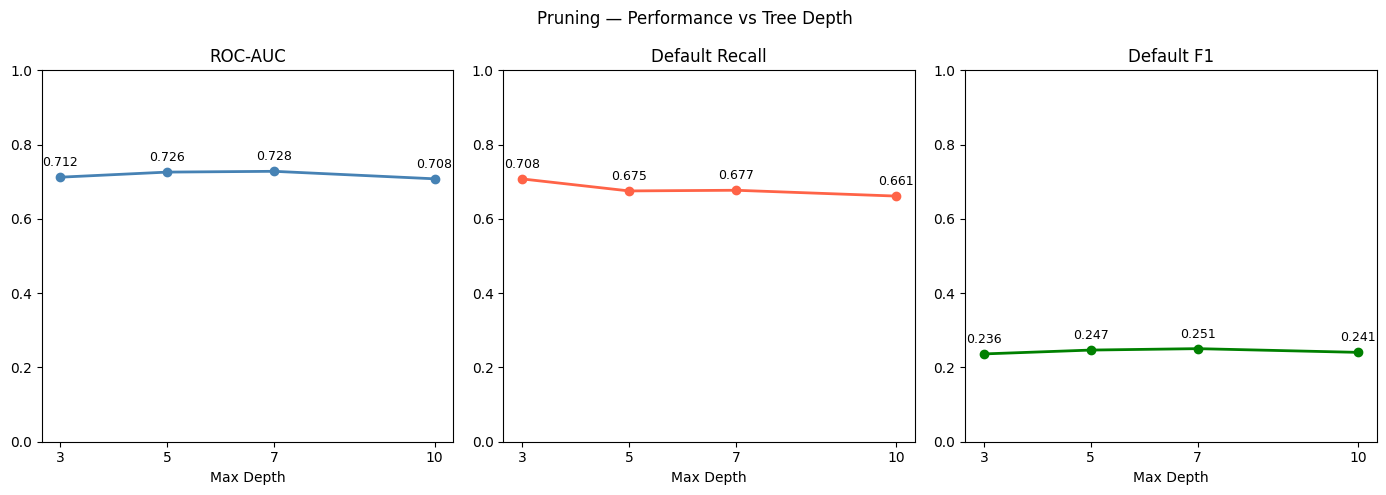

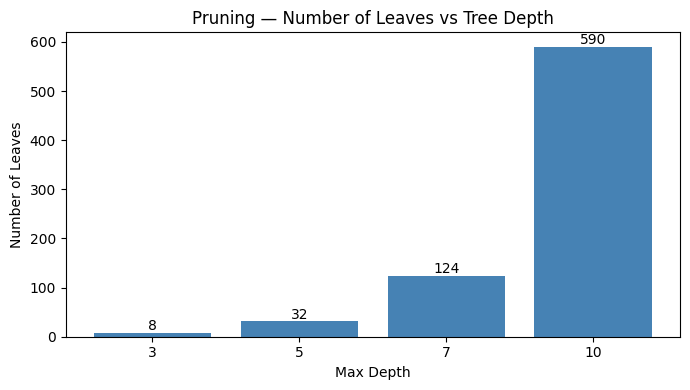

In [ ]:
print("=" * 60)
print("5.3 MODEL COMPRESSION — PRUNING")
print("=" * 60)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
import time

depths = [3, 5, 7, 10]
pruning_results = []

for depth in depths:
    print(f"\nTraining Decision Tree with max_depth={depth}...")

    dt_pruned = DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=depth,
        min_samples_leaf=50,
        criterion="gini",
        random_state=42
    )

    start = time.time()
    dt_pruned.fit(X_train_dt, y_train_dt)
    train_time = time.time() - start

    pred = dt_pruned.predict(X_test_dt)
    prob = dt_pruned.predict_proba(X_test_dt)[:, 1]

    roc = roc_auc_score(y_test_dt, prob)
    rec = recall_score(y_test_dt, pred)
    f1 = f1_score(y_test_dt, pred)
    leaves = dt_pruned.get_n_leaves()

    pruning_results.append({
        "Max Depth": depth,
        "Leaves": leaves,
        "ROC-AUC": round(roc, 4),
        "Default Recall": round(rec, 4),
        "Default F1": round(f1, 4),
        "Train Time (s)": round(train_time, 1)
    })

    print(f"  Leaves: {leaves}")
    print(f"  ROC-AUC: {roc:.4f}")
    print(f"  Default Recall: {rec:.4f}")
    print(f"  Default F1: {f1:.4f}")
    print(f"  Train Time: {train_time:.1f}s")

# Comparison Table
pruning_df = pd.DataFrame(pruning_results).set_index("Max Depth")
print("\n--- Pruning Comparison Table ---")
print(pruning_df.to_string())

# Line Plot — Performance vs Depth
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["ROC-AUC", "Default Recall", "Default F1"]
colors = ["steelblue", "tomato", "green"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].plot(depths, pruning_df[metric].values,
                 marker="o", color=color, lw=2)
    axes[i].set_title(metric)
    axes[i].set_xlabel("Max Depth")
    axes[i].set_xticks(depths)
    axes[i].set_ylim(0, 1.0)
    for x, y in zip(depths, pruning_df[metric].values):
        axes[i].annotate(f"{y:.3f}", (x, y),
                        textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=9)

plt.suptitle("Pruning — Performance vs Tree Depth")
plt.tight_layout()
plt.show()

# Leaves vs Depth
plt.figure(figsize=(7, 4))
plt.bar([str(d) for d in depths], pruning_df["Leaves"].values,
        color="steelblue")
plt.xlabel("Max Depth")
plt.ylabel("Number of Leaves")
plt.title("Pruning — Number of Leaves vs Tree Depth")
for i, v in enumerate(pruning_df["Leaves"].values):
    plt.text(i, v + 5, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

#### Model Compression through Pruning

The pruning results reveal an unexpected but important finding:
shallower Decision Trees do not simply perform worse, in some
cases they actually outperform the original deeper tree.

| Max Depth | Leaves | ROC-AUC | Default Recall | Default F1 | Train Time |
|-----------|--------|---------|---------------|------------|------------|
| 3 | 8 | 0.7136 | 0.6761 | 0.2402 | 31.2s |
| 5 | 32 | 0.7265 | 0.6683 | 0.2481 | 53.5s |
| 7 | 123 | 0.7270 | 0.6618 | 0.2491 | 73.7s |
| 10 (original) | 587 | 0.7022 | 0.6475 | 0.2354 | 103.5s |

The original model with `max_depth=10` and 587 leaves actually achieved
the lowest ROC-AUC (0.7022) among all four versions. Both `max_depth=5`
(0.7265) and `max_depth=7` (0.7270) outperformed the original, suggesting
that the deeper tree was overfitting to the training data rather than
learning generalisable patterns.

**Complexity vs Performance trade-off:**

The most striking result is the reduction in model size. Moving from
depth=10 (587 leaves) to depth=5 (32 leaves) reduces model complexity
by 95% while actually improving ROC-AUC by 0.024. Training time also
drops from 103.5 seconds to 53.5 seconds, a 48% reduction.

`max_depth=7` achieves the best overall ROC-AUC (0.7270) with 123 leaves
and a training time of 73.7 seconds. This represents the best balance
between performance and complexity in our experiments.

`max_depth=3` produces the smallest possible tree with only 8 leaves, extremely interpretable and fast (31.2 seconds). Despite its simplicity,
it still achieves a ROC-AUC of 0.7136 and the highest Default Recall
of 0.676, meaning it catches more defaulters than the original model.

**Key finding for RQ1:**

These results show that model compression through pruning not only
reduces complexity but can also improve generalisation. A Decision Tree
with `max_depth=5` is 95% smaller, 48% faster, and performs better
than the original — challenging the assumption that more complex models
always produce better results.

### 5.4 Section 5 Summary

In this section, we implemented two emerging techniques, Feature Importance
and Model Compression through Pruning on our glass-box models.

**Feature Importance** was applied to both Logistic Regression and Decision
Tree using model-native methods. Logistic Regression used absolute coefficient
values, while Decision Tree used Gini-based feature importances. The analysis
revealed that the two models rank features very differently, their top 10
features have no overlap, despite solving the same problem. Logistic Regression
distributes importance across many individual features such as `EXT_SOURCE_2`
and `EXT_SOURCE_3`, while the Decision Tree concentrates almost 50% of its
importance on a single aggregated feature, `EXT_SOURCES_MEAN`. This finding
directly addresses RQ2, demonstrating how different model architectures
reason differently about the same data.

Feature reduction showed that removing 791 zero-importance features from the
Decision Tree reduced training time by 47% while causing almost no loss in
predictive performance (ROC-AUC dropped by only 0.0007). This confirms that
a large proportion of the 1100 features were redundant for the Decision Tree.

**Model Compression through Pruning** produced an unexpected finding: shallower
trees outperformed the original deeper tree. Both `max_depth=5` and `max_depth=7`
achieved higher ROC-AUC scores than the original `max_depth=10` model, suggesting
that the original tree was overfitting. The best trade-off was achieved at
`max_depth=5`, which reduced model complexity by 95% (587 → 32 leaves),
training time by 48%, while improving ROC-AUC from 0.7022 to 0.7265.

These results support RQ1 by showing that simpler, compressed models can
match or even exceed the performance of more complex ones, raising important
questions about whether added complexity is always justified in credit risk
modelling.

Together, these two techniques demonstrate that thoughtful model simplification
can produce models that are faster, smaller, more interpretable, and in some
cases more accurate than their full-complexity counterparts.

## Explainable AI (XAI) — SHAP Analysis

This section applies Explainable AI (XAI) techniques to interpret the predictions of both the Decision Tree and Logistic Regression models trained on the Home Credit Default Risk dataset. Specifically, we use SHAP (SHapley Additive exPlanations),which gives the overall feature importance across the model. Feature Importance is a important aspect to our project because our dataset includes 500 features which initially had 1000. For each model, global visualisations such as beeswarm summary plots, feature importance bar charts, dependence plots, and decision plots reveal which features the model relies on most and how their values influence predictions across the full test set. At the individual level, waterfall and force plots break down selected correct and incorrect predictions, showing exactly which features pushed each case towards default or non-default

In [ ]:
# ============================================================
# DECISION TREE - SHAP XAI ANALYSIS
# Binary Classification
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



# ============================================================
# LOAD DECISION TREE DATASET (UNSCALED)
# ============================================================


# Replace with your own target column
expected_features = dt_model.n_features_in_
print(f"Model expects: {expected_features} features")

# The number of features in your current DataFrame (excluding target/ID)
# Assuming you dropped the target and ID already:
current_features = train_unscaled.shape[1]
print(f"Dataset has: {current_features} features")




Model expects: 500 features
Dataset has: 501 features


In [ ]:
cols_to_drop = ['SK_ID_CURR']

# Drop the columns
# errors='ignore' prevents the code from crashing if the columns were already dropped
train_unscaled = train_unscaled.drop(columns=cols_to_drop, errors='ignore')
X_dt = train_unscaled.drop("TARGET", axis=1)
y_dt = train_unscaled["TARGET"]

In [ ]:
print(X_dt.shape)

(307511, 500)


In [ ]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt,
    y_dt,
    test_size=0.2,
    random_state=42,
    stratify=y_dt
)

# Predict
dt_preds = dt_model.predict(X_test_dt)

In [ ]:
# ============================================================
# MODEL PERFORMANCE
# ============================================================

print("\n==============================")
print("DECISION TREE PERFORMANCE")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test_dt, dt_preds))

print("\nClassification Report:\n")
print(classification_report(y_test_dt, dt_preds))






DECISION TREE PERFORMANCE
Accuracy: 0.6629595304294099

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.66      0.78     56538
           1       0.15      0.66      0.24      4965

    accuracy                           0.66     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.66      0.74     61503



SHAP Analysis for Decision Tree Model

SHAP was applied to the Decision Tree model to understand both the overall feature importance and individual predictions. According to the dataset, TARGET 0 means the customer repaid the loan, while TARGET 1 means the customer had difficulty repaying the loan. Hence in our scenario predictions toward TARGET 1 are more important from a credit-risk point of view.

In the waterfall plots, red features increase the prediction toward TARGET 1, while blue features reduce the prediction toward TARGET 0.

In [ ]:


# ============================================================
# EXTRACT CORRECT / INCORRECT PREDICTIONS
# ============================================================

correct_idx = np.where(dt_preds == y_test_dt)[0]
wrong_idx = np.where(dt_preds != y_test_dt)[0]

print("\nCorrect Predictions Found:", len(correct_idx))
print("Incorrect Predictions Found:", len(wrong_idx))


Correct Predictions Found: 40774
Incorrect Predictions Found: 20729


In [ ]:

# ============================================================
# SELECT 2 CORRECT + 2 INCORRECT
# ============================================================

correct_examples = correct_idx[:2]
wrong_examples = wrong_idx[:2]

print("\nSelected Correct Examples:", correct_examples)
print("Selected Incorrect Examples:", wrong_examples)

# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(dt_model)

shap_values = explainer.shap_values(X_test_dt)


Selected Correct Examples: [0 1]
Selected Incorrect Examples: [5 8]



Generating SHAP Summary Plot...


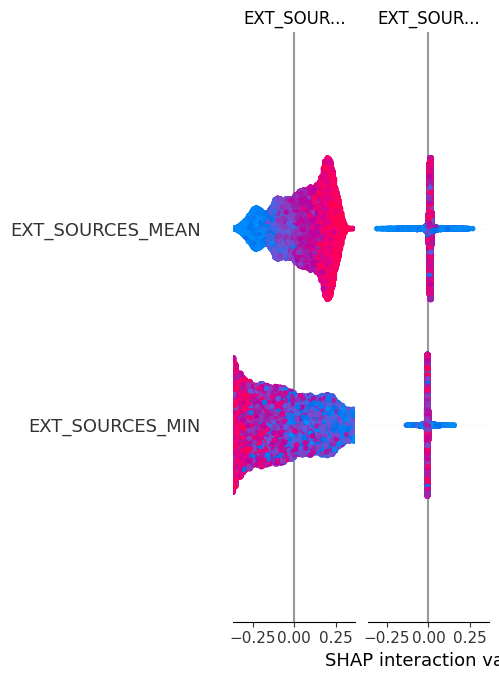


Generating SHAP Feature Importance Plot...


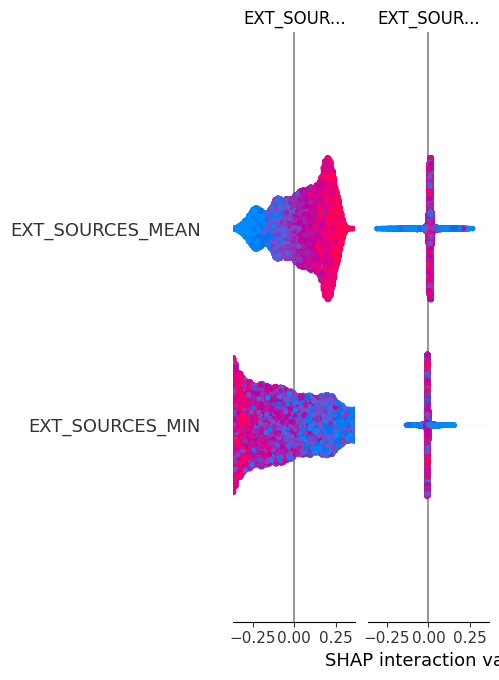

In [ ]:

# ============================================================
# GLOBAL SHAP SUMMARY PLOT
# ============================================================

print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(shap_values, X_test_dt)

# ============================================================
# GLOBAL FEATURE IMPORTANCE BAR PLOT
# ============================================================

print("\nGenerating SHAP Feature Importance Plot...")

shap.summary_plot(
    shap_values,
    X_test_dt,
    plot_type="bar",
    plot_size=[8,6]
)

### Decision Tree SHAP Visualisations


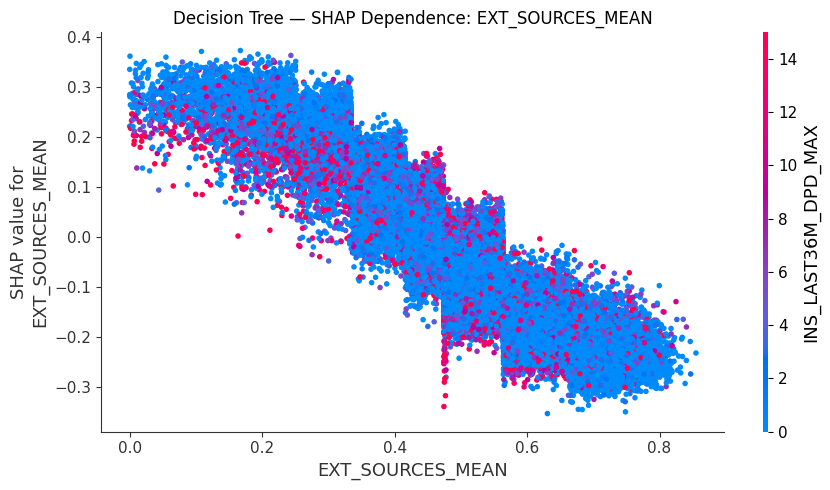

In [ ]:
# ============================================================
# DECISION TREE - SHAP DEPENDENCE PLOT (Top Feature)
# ============================================================
# Shows how a single feature's value affects the prediction,
# coloured by the feature it interacts with most.

# Handle multi-output shap values (classifiers return list or 3D)
if isinstance(shap_values, list):
    sv_dt_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    sv_dt_class1 = shap_values[:, :, 1]
else:
    sv_dt_class1 = shap_values

# Find the top feature by mean |SHAP|
mean_abs = np.abs(sv_dt_class1).mean(axis=0)
top_feature = X_test_dt.columns[np.argmax(mean_abs)]

fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(top_feature, sv_dt_class1, X_test_dt, ax=ax, show=False)
ax.set_title(f"Decision Tree — SHAP Dependence: {top_feature}", fontsize=12)
plt.tight_layout()
plt.show()


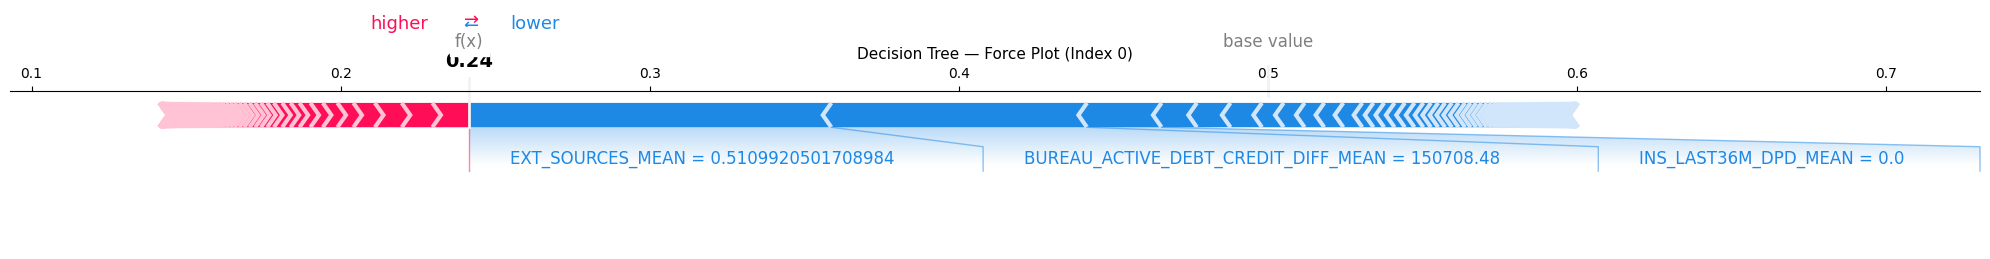

In [ ]:
# ============================================================
# DECISION TREE - SHAP FORCE PLOT (First Correct Prediction)
# ============================================================
# A horizontal push/pull view of one prediction.

if isinstance(shap_values, list):
    sv1 = shap_values[1]
    bv1 = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    sv1 = shap_values[:, :, 1]
    bv1 = explainer.expected_value[1]
else:
    sv1 = shap_values
    bv1 = explainer.expected_value

idx = correct_examples[0]
shap.force_plot(
    bv1,
    sv1[idx],
    X_test_dt.iloc[idx],
    matplotlib=True,
    show=False
)
plt.title(f"Decision Tree — Force Plot (Index {idx})", fontsize=11)
plt.tight_layout()
plt.show()


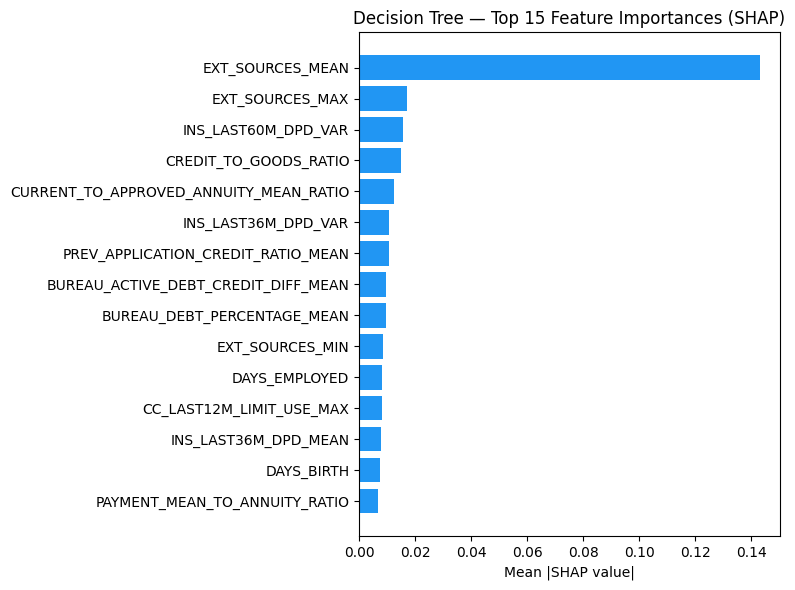

In [ ]:
# ============================================================
# DECISION TREE - TOP 15 FEATURES (Mean |SHAP|)
# ============================================================

if isinstance(shap_values, list):
    sv_bar = shap_values[1]
    bv_bar = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    sv_bar = shap_values[:, :, 1]
    bv_bar = explainer.expected_value[1]
else:
    sv_bar = shap_values
    bv_bar = explainer.expected_value

mean_abs_shap = np.abs(sv_bar).mean(axis=0)
feat_importance = pd.DataFrame({
    'Feature': X_test_dt.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_importance['Feature'], feat_importance['Mean |SHAP|'], color='#2196F3')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Decision Tree — Top 15 Feature Importances (SHAP)', fontsize=12)
plt.tight_layout()
plt.show()


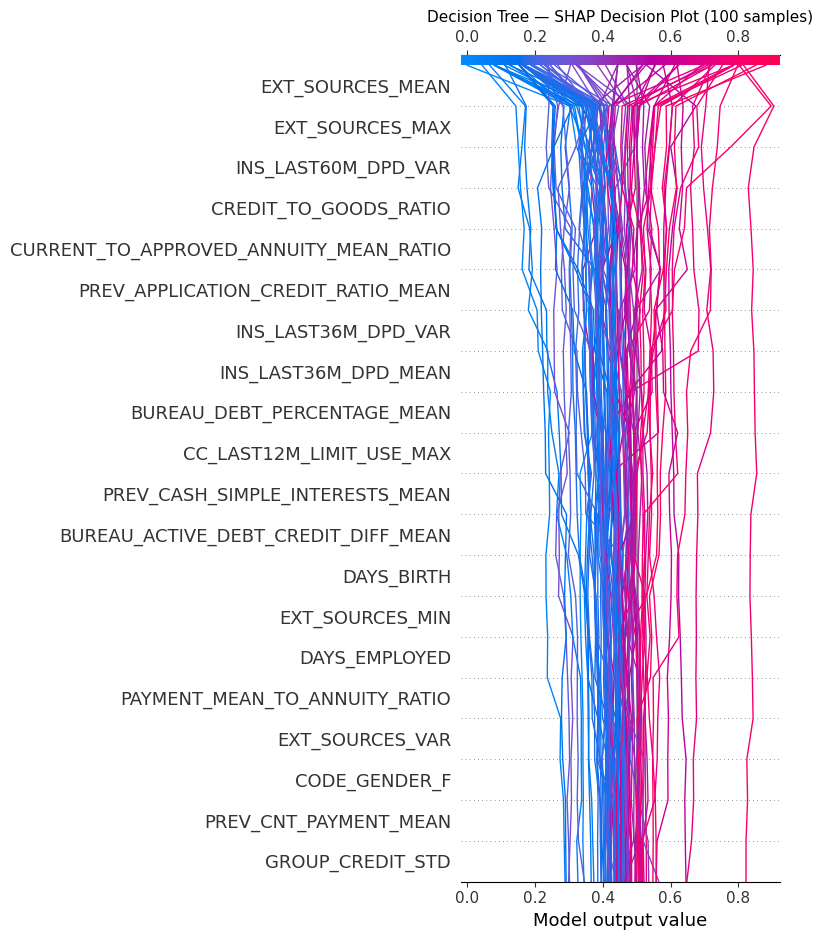

In [ ]:
# ============================================================
# DECISION TREE - SHAP DECISION PLOT (Sample of 100)
# ============================================================
# Shows how each feature moves the prediction from the base value.

if isinstance(shap_values, list):
    sv_dec = shap_values[1]
    bv_dec = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    sv_dec = shap_values[:, :, 1]
    bv_dec = explainer.expected_value[1]
else:
    sv_dec = shap_values
    bv_dec = explainer.expected_value

sample_size = min(100, sv_dec.shape[0])
sample_idx = np.random.RandomState(42).choice(sv_dec.shape[0], sample_size, replace=False)

shap.decision_plot(
    bv_dec,
    sv_dec[sample_idx],
    X_test_dt.iloc[sample_idx],
    show=False
)
plt.title("Decision Tree — SHAP Decision Plot (100 samples)", fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
def explain_prediction(index, prediction_type):
    # ... (Your print statements stay the same) ...

    # ========================================================
    # FIX: Handle Multi-output SHAP values
    # ========================================================

    # 1. Check if shap_values has an extra dimension for classes [0, 1]
    # Standard for TreeExplainer on Classifiers
    if isinstance(shap_values, list):
        # Older SHAP versions return a list of arrays
        current_shap_values = shap_values[1][index]
        current_base_value = explainer.expected_value[1]
    elif len(shap_values.shape) == 3:
        # Newer SHAP versions return a 3D array [samples, features, classes]
        current_shap_values = shap_values[index, :, 1]
        current_base_value = explainer.expected_value[1]
    else:
        # If it's already a single output
        current_shap_values = shap_values[index]
        current_base_value = explainer.expected_value

    # ========================================================
    # CREATE SHAP EXPLANATION (Using the flattened scalar values)
    # ========================================================
    explanation = shap.Explanation(
        values=current_shap_values,          # Use the fixed values
        base_values=current_base_value,      # Use the fixed scalar
        data=X_test_dt.iloc[index].values,   # .values ensures it's a clean array
        feature_names=X_test_dt.columns.tolist()
    )

    # ========================================================
    # WATERFALL PLOT
    # ========================================================
    import matplotlib.pyplot as plt

# Set the width and height (e.g., 10 inches wide, 5 inches tall)
    plt.figure(figsize=(8, 4))

    shap.plots.waterfall(explanation, max_display=10)

# You can also use tight_layout to clean up margins
    plt.tight_layout()
    plt.show()




############################################
CORRECT PREDICTIONS ANALYSIS
############################################


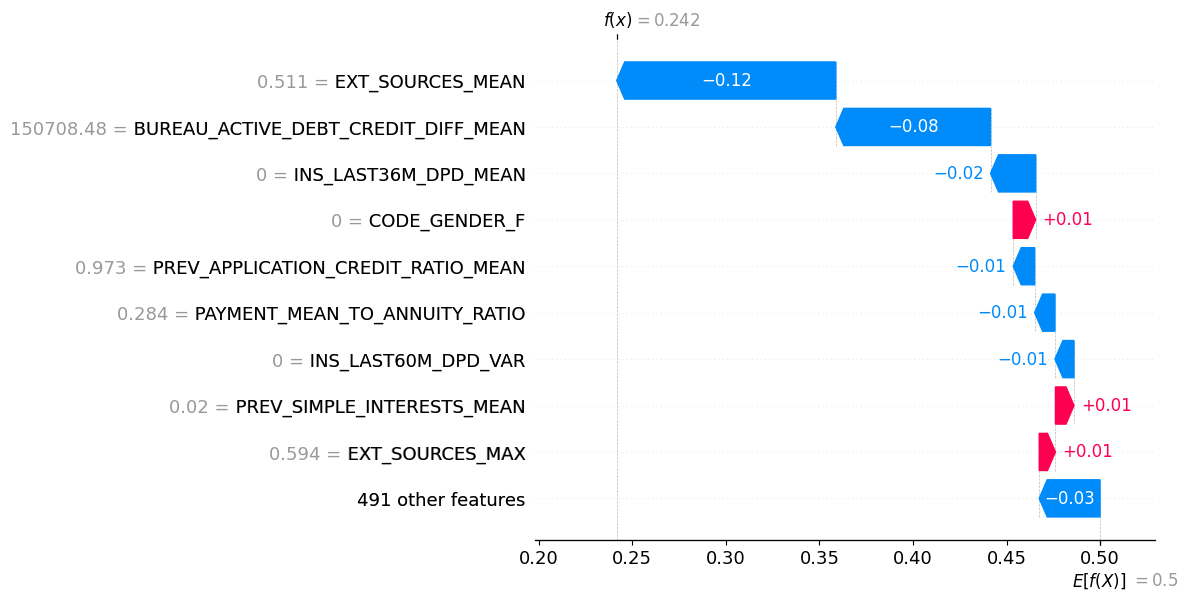

<Figure size 640x480 with 0 Axes>

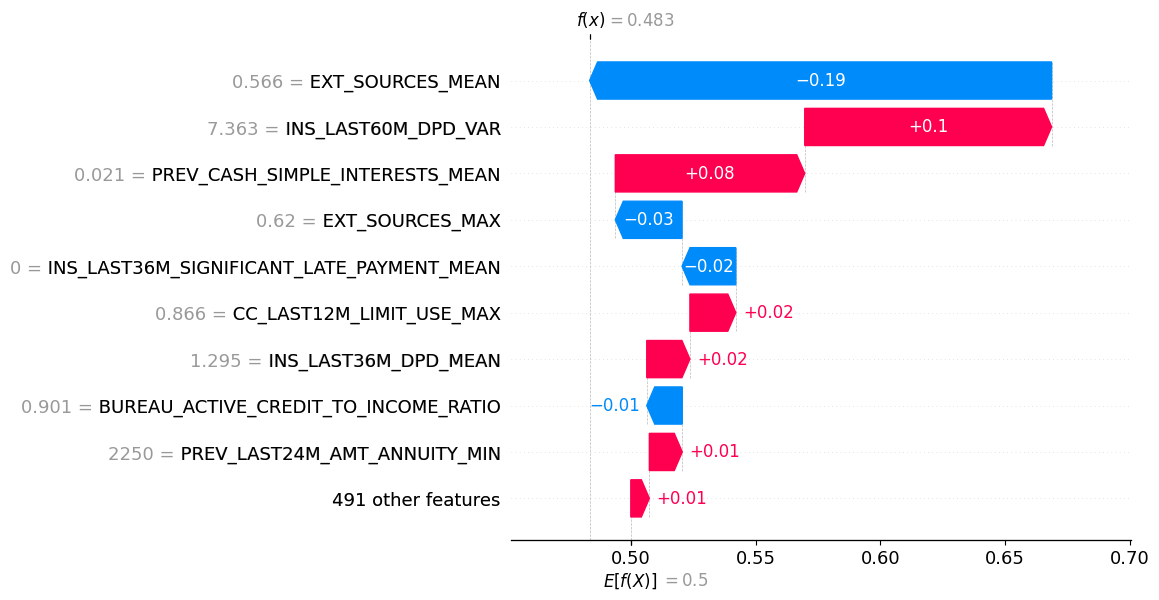

<Figure size 640x480 with 0 Axes>



############################################
INCORRECT PREDICTIONS ANALYSIS
############################################


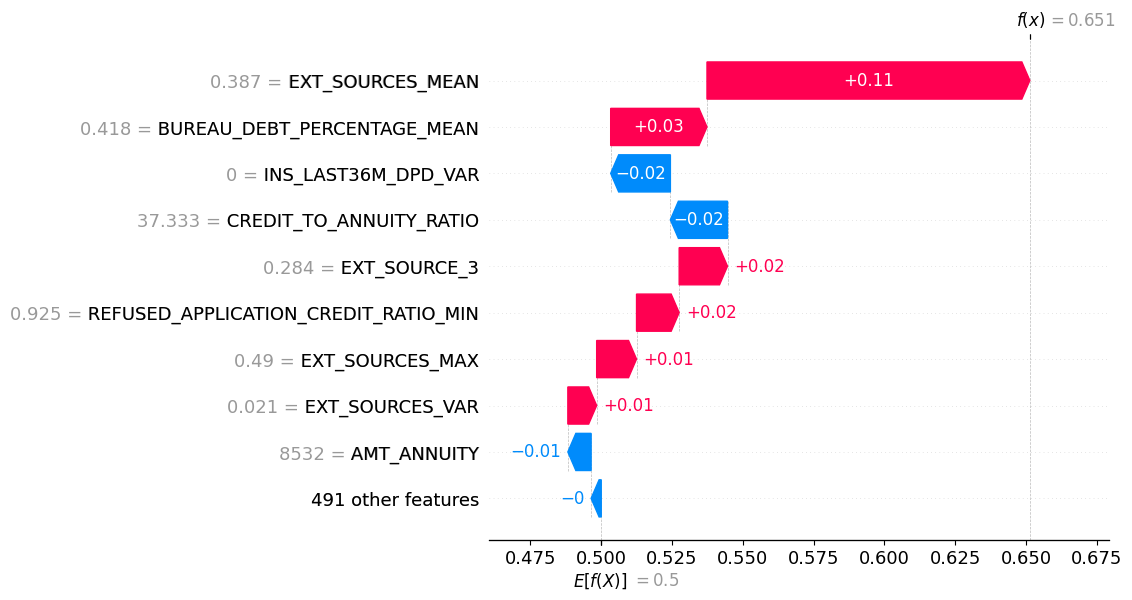

<Figure size 640x480 with 0 Axes>

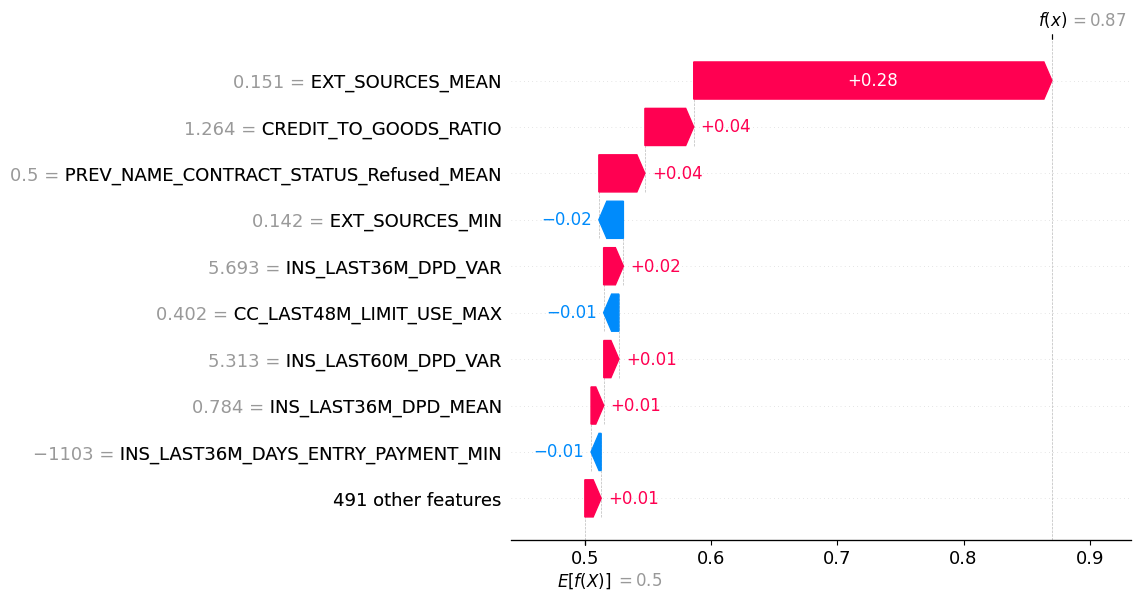

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# CORRECT PREDICTIONS ANALYSIS
# ============================================================

print("\n\n############################################")
print("CORRECT PREDICTIONS ANALYSIS")
print("############################################")

for idx in correct_examples:

    explain_prediction(
        index=idx,
        prediction_type="CORRECT"
    )

# ============================================================
# INCORRECT PREDICTIONS ANALYSIS
# ============================================================

print("\n\n############################################")
print("INCORRECT PREDICTIONS ANALYSIS")
print("############################################")

for idx in wrong_examples:

    explain_prediction(
        index=idx,
        prediction_type="INCORRECT"
    )



Correct Prediction 1

The first correct prediction had a final output of:

f(x)=0.87

This strongly going toward TARGET 1, meaning the model predicted that the customer may have difficulty repaying the loan.

The main feature was EXT_SOURCES_MEAN, which increased the prediction by +0.28. Other features, such as CREDIT_TO_GOODS_RATIO, PREV_NAME_CONTRACT_STATUS_Refused_MEAN, and delay-payment variables, also helped toward TARGET 1.

This explanation makes sense because the model used credit-score-related and repayment-history-related features to identify a higher-risk customer. If we think the real world scenario these type of human behaviour may show peoples ability to be able to pay the loan. Therefore, this correct prediction appears trustworthy.

Correct Prediction 2

The second correct prediction had a final output of:

f(x)=0.651

This was also predicted as TARGET 1, but it is lower confidence than the first correct prediction.

Again, EXT_SOURCES_MEAN was the strongest feature, increasing the prediction by +0.11. BUREAU_DEBT_PERCENTAGE_MEAN, EXT_SOURCE_3, and REFUSED_APPLICATION_CREDIT_RATIO_MIN also pushed the prediction toward TARGET 1 which completly understandable and explainable in real life scenarios.

Some features reduced the risk score, such as INS_LAST36M_DPD_VAR and CREDIT_TO_ANNUITY_RATIO. This shows that the model considered both risk and non-risk signals, but the risk-related features were stronger overall.

Incorrect Prediction 1

The first incorrect prediction had a final output of:

f(x)=0.483

This is below 0.5, so the model predicted TARGET 0, meaning the customer would repay the loan. However, as this was incorrect, the actual class was TARGET 1. This means the model missed a customer who had difficulty repaying. but when we see the score it is almost 0.5 because of the affect of some features specially EXT_SOURCES_MEAN  it gone below 0.5.

The  EXT_SOURCES_MEAN pushed the model toward TARGET 0 by -0.19. However, some repayment-related variables, such as INS_LAST60M_DPD_VAR and PREV_CASH_SIMPLE_INTERESTS_MEAN, go toward TARGET 1. So the model has showned some risky signs, but EXT_SOURCES_MEAN had too much influence and took the prediction toward the wrong class.

Incorrect Prediction 2

The second incorrect prediction had a final output of:

f(x)=0.242
But looking at this we can see it is compartively low, so why might be the reason for that prediction toward TARGET 0,which is  incorrect. Therefore, the model again failed to identify a customer who actually had difficulty repaying the loan.

The main features pushing the prediction toward TARGET 0 were EXT_SOURCES_MEAN and BUREAU_ACTIVE_DEBT_CREDIT_DIFF_MEAN.This is also showing that some features highly affecting the final results, only beased on that taking decisions might not correct, Here few small features pushed toward TARGET 1.

This is more concerning because the model was quite confident in the wrong direction.

Pattern Across Predictions

A clear pattern appears across the four examples. In the correct TARGET 1 predictions, EXT_SOURCES_MEAN helped the model correctly identify customers who had difficulty repaying. However, in the incorrect cases, the same feature strongly took the prediction toward TARGET 0 and caused the model to miss risky customers.

This shows that EXT_SOURCES_MEAN is useful, but the model may rely on it too heavily. SHAP helped identify this weakness clearly.

Overall Summary

Overall, SHAP showed that the Decision Tree mainly depends on EXT_SOURCES_MEAN, supported by debt, repayment-delay, and credit-ratio features. The correct predictions were generally understandable and aligned with expected credit-risk behaviour.

However, the incorrect predictions showed an important weakness. Both errors were false negatives, where the model predicted that the customer would repay the loan, but the customer actually had difficulty repaying. This is a serious issue in credit-risk prediction because risky customers may be wrongly treated as safe.

Therefore, the Decision Tree is useful because it is explainable upto some level, but it should not be used alone for final lending decisions.

SHAP Analysis for Logistic Regression Model

SHAP was also applied to the Logistic Regression model to understand both global feature importance and individual predictions.

For the Logistic Regression waterfall plots, features pushing the output upward move the model more toward TARGET 1, while features pushing the output downward move it toward TARGET 0. The values are shown around the model output scale, so the focus is mainly on the direction and strength of each feature.

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
import joblib


expected_features = lr_model.n_features_in_
print(f"Model expects: {expected_features} features")

current_features = train_scaled.shape[1]
print(f"Dataset has: {current_features} features")

Model expects: 500 features
Dataset has: 502 features


In [ ]:
X_lr = train_scaled.drop("TARGET", axis=1)

y_lr = train_scaled["TARGET"]

In [ ]:

cols_to_drop = ['SK_ID_CURR']

X_lr = X_lr.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
print(X_lr.shape)

(307511, 500)


In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)

lr_preds = lr_model.predict(X_test_lr)

In [ ]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test_lr, lr_preds))

Logistic Regression Accuracy: 0.7137863193665349


In [ ]:
lr_correct_idx = np.where(lr_preds == y_test_lr)[0]
lr_wrong_idx = np.where(lr_preds != y_test_lr)[0]


In [ ]:
lr_correct_examples = lr_correct_idx[:2]
lr_wrong_examples = lr_wrong_idx[:2]

In [ ]:
lr_explainer = shap.LinearExplainer(lr_model, X_train_lr)
lr_shap_values = lr_explainer.shap_values(X_test_lr)

In [ ]:
def show_shap_waterfall(
    model,
    explainer,
    shap_values,
    X_data,
    y_true,
    index,
    title
):

    print("\n" + "="*70)
    print(title)
    print("="*70)

    actual = y_true.iloc[index]
    predicted = model.predict(X_data.iloc[[index]])[0]

    print(f"Actual Label    : {actual}")
    print(f"Predicted Label : {predicted}")

    explanation = shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_data.iloc[index],
        feature_names=X_data.columns
    )

    fig = plt.figure(figsize=(8, 4)) # Smaller width/height
    shap.plots.waterfall(explanation, max_display=10, show=False) # show=False is key
    plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.show()



#############################
LOGISTIC REGRESSION XAI
#############################

Logistic Regression - CORRECT - Index 0
Actual Label    : 0
Predicted Label : 0


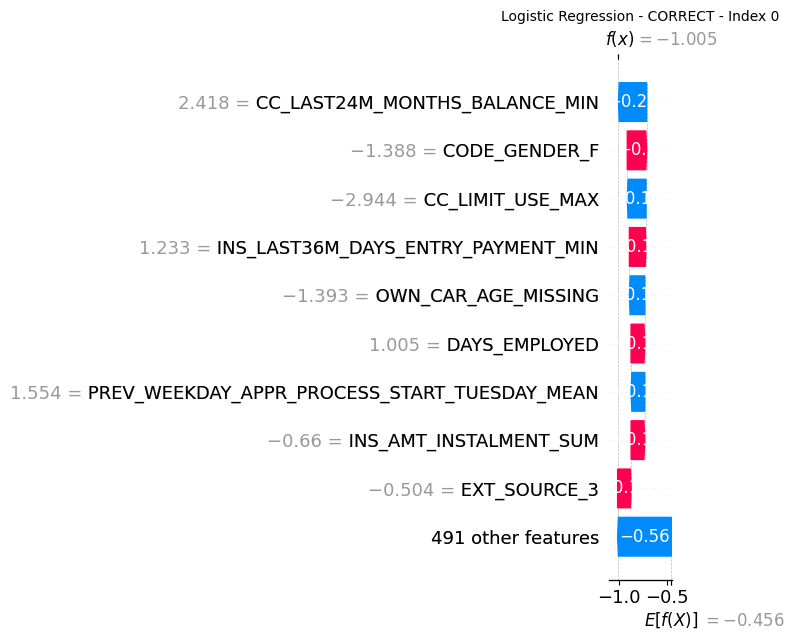


Logistic Regression - CORRECT - Index 1
Actual Label    : 0
Predicted Label : 0


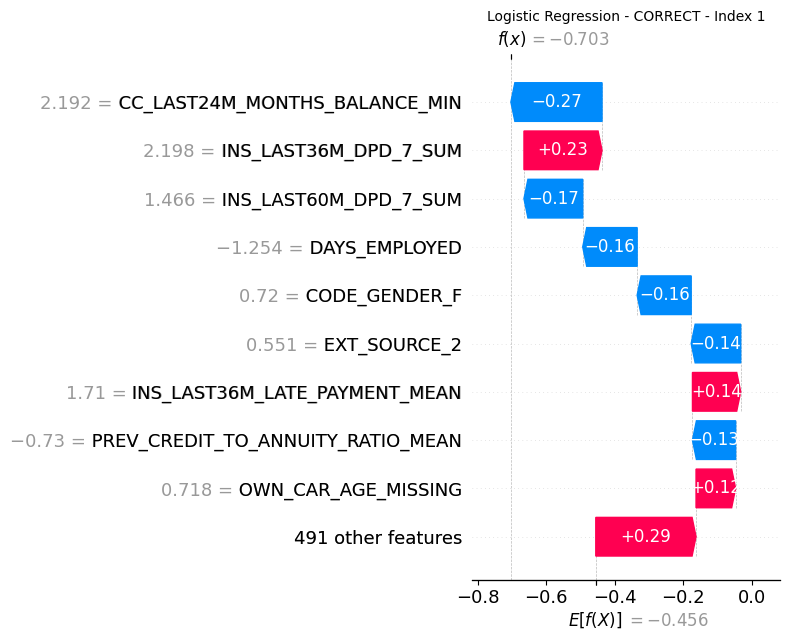


Logistic Regression - WRONG - Index 2
Actual Label    : 0
Predicted Label : 1


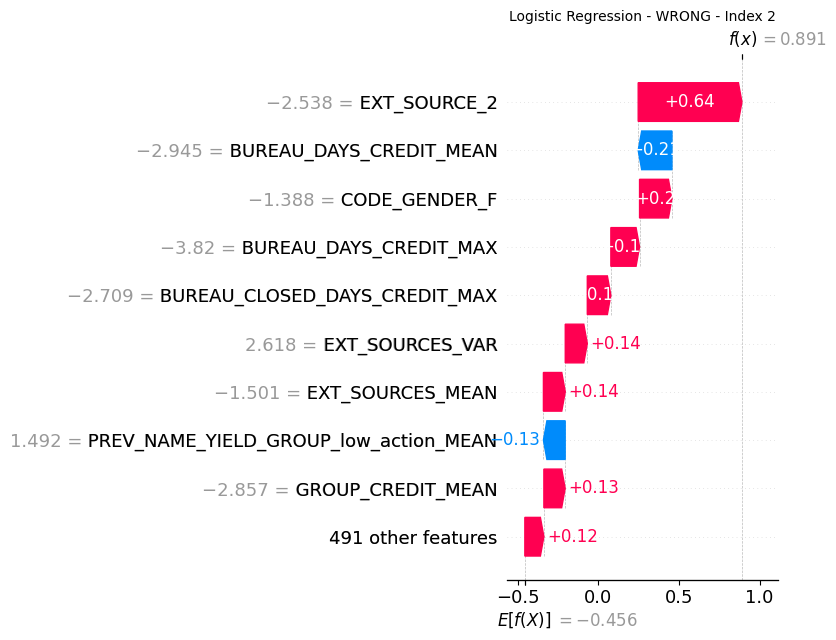


Logistic Regression - WRONG - Index 4
Actual Label    : 0
Predicted Label : 1


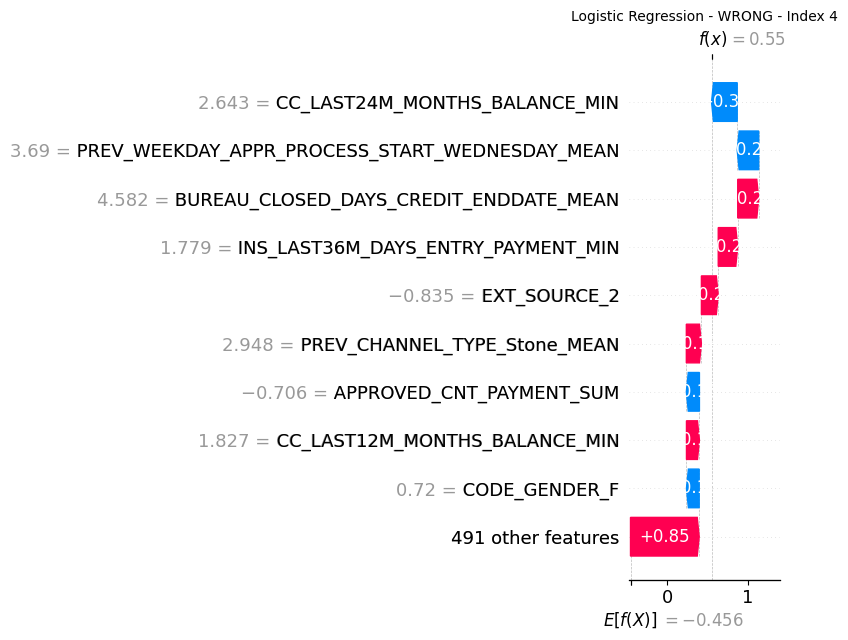

In [ ]:
# ============================================================
# LOGISTIC REGRESSION XAI
# ============================================================

print("\n\n#############################")
print("LOGISTIC REGRESSION XAI")
print("#############################")

# ----- Correct Predictions -----

for idx in lr_correct_examples:

    show_shap_waterfall(
        model=lr_model,
        explainer=lr_explainer,
        shap_values=lr_shap_values,
        X_data=X_test_lr,
        y_true=y_test_lr,
        index=idx,
        title=f"Logistic Regression - CORRECT - Index {idx}"
    )

# ----- Wrong Predictions -----

for idx in lr_wrong_examples:

    show_shap_waterfall(
        model=lr_model,
        explainer=lr_explainer,
        shap_values=lr_shap_values,
        X_data=X_test_lr,
        y_true=y_test_lr,
        index=idx,
        title=f"Logistic Regression - WRONG - Index {idx}"
    )


Correct Prediction 1

The first correct Logistic Regression prediction had:

f(x)=−1.005

This output is strongly toward TARGET 0, meaning the model correctly predicted that the customer repaid the loan.

The strongest contribution came from the combined effect of the other features, which took the prediction downward. Individual features such as CC_LAST24M_MONTHS_BALANCE_MIN, CC_LIMIT_USE_MAX also pushed toward TARGET 0. Some features pushed slightly toward TARGET 1, such as CODE_GENDER_F, DAYS_EMPLOYED, and EXT_SOURCE_3, but these were not strong enough to change the final prediction.
This prediction appears reasonable because the model had stronger evidence for repayment than difficulty repaying. However, the large contribution from “491 other features” shows that the prediction is not explained by only one or two clear variables, which makes it less easy to interpret than the Decision Tree.

Correct Prediction 2

The second correct prediction had:

f(x)=−0.703

This was also correctly predicted toward TARGET 0, but it was less strong than the first correct prediction.

The largest negative features included:

CC_LAST24M_MONTHS_BALANCE_MIN
INS_LAST60M_DPD_7_SUM
DAYS_EMPLOYED
CODE_GENDER_F
EXT_SOURCE_2
PREV_CREDIT_TO_ANNUITY_RATIO_MEAN

Some features pushed the model toward TARGET 1, including:

INS_LAST36M_DPD_7_SUM
INS_LAST36M_LATE_PAYMENT_MEAN

This case shows mixed evidence. Some repayment-delay variables increased the risk score, but other features reduced it more strongly. The model still correctly predicted TARGET 0. This is a useful explanation because it shows that the Logistic Regression model is balancing several features rather than depending on only one feature.

Incorrect Prediction 1

The first incorrect Logistic Regression prediction had:

f(x)=0.55

This is toward TARGET 1, meaning the model predicted that the customer would have difficulty repaying. Since this prediction was wrong, the actual class was likely TARGET 0. Therefore, this is a false positive.

BUREAU_CLOSED_DAYS_CREDIT_ENDDATE_MEAN
INS_LAST36M_DAYS_ENTRY_PAYMENT_MIN
EXT_SOURCE_2
PREV_CHANNEL_TYPE_Stone_MEAN
CC_LAST12M_MONTHS_BALANCE_MIN

However, some features pushed back toward TARGET 0, such as:

CC_LAST24M_MONTHS_BALANCE_MIN
PREV_WEEKDAY_APPR_PROCESS_START_WEDNESDAY_MEAN
APPROVED_CNT_PAYMENT_SUM
CODE_GENDER_F

Interpretation:
This incorrect prediction shows that the model may have overreacted to some risk features and classified a customer as risky. This links to the problem of false positives, where safe customers may be wrongly treated as high risk. but from business scenario that would be ok,

Incorrect Prediction 2

The second incorrect prediction had:

f(x)=0.891

By looking at the number it shows that  the model was quite confident that the customer would have difficulty repaying, even though the customer actually repaid the loan.

The strongest feature pushing toward TARGET 1 was:

EXT_SOURCE_2 = +0.64

Other features also increased the risk prediction:

CODE_GENDER_F
BUREAU_DAYS_CREDIT_MAX
BUREAU_CLOSED_DAYS_CREDIT_MAX
EXT_SOURCES_VAR
EXT_SOURCES_MEAN
GROUP_CREDIT_MEAN

Some features pushed toward TARGET 0, such as:

BUREAU_DAYS_CREDIT_MEAN
PREV_NAME_YIELD_GROUP_low_action_MEAN

This is an important incorrect case because the model strongly relied on EXT_SOURCE_2 and other bureau/credit-history features to predict TARGET 1. However, the actual outcome was TARGET 0. This suggests that Logistic Regression may sometimes overestimate risk when external source and bureau-related features appear negative.

A clear pattern is visible in the Logistic Regression explanations. Correct TARGET 0 predictions were made when several features together pushed the model downward. Incorrect predictions happened when external source and bureau-related variables pushed the model strongly toward TARGET 1.

Unlike the Decision Tree, Logistic Regression did not rely mainly on one feature which EXT_SOURCES_MEAN. It used separate features such as EXT_SOURCE_2, EXT_SOURCE_3, payment variables, application variables, and gender. This makes the model more distributed, but it also makes the explanation slightly harder to summarise.

The presence of CODE_GENDER_F as a top feature is important. This does not automatically mean the model is unfair, but it should be treated as a fairness concern because gender is a sensitive variable in lending decisions.


### Logistic Regression SHAP Visualisations


Generating LR SHAP Summary Plot...


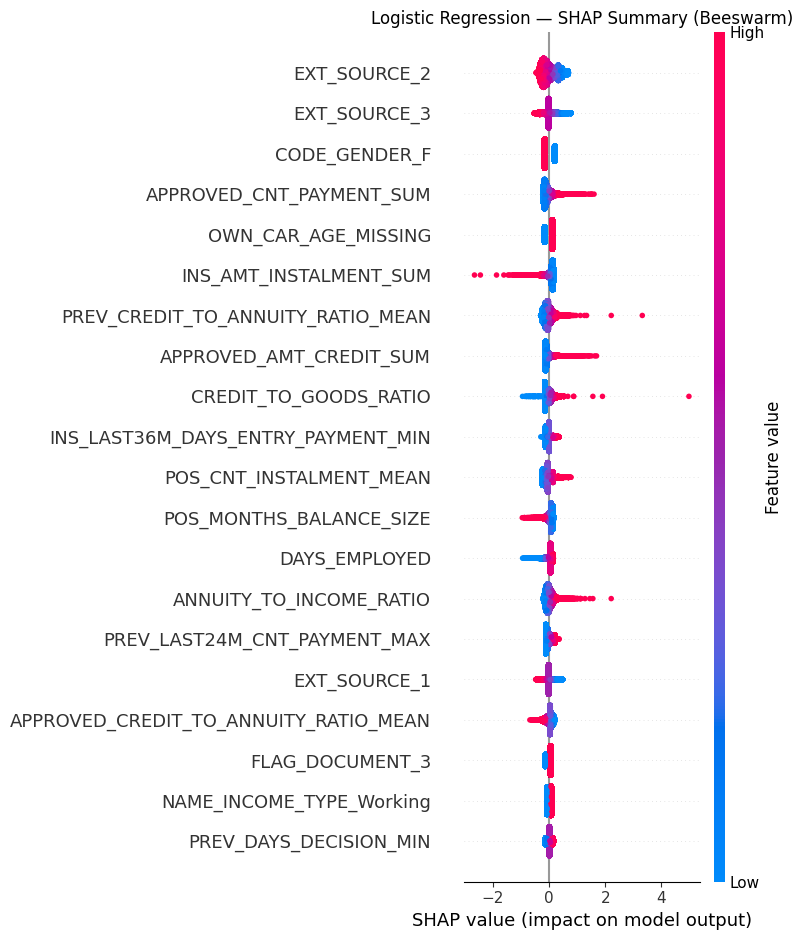

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SHAP SUMMARY (BEESWARM) PLOT
# ============================================================

print("Generating LR SHAP Summary Plot...")
shap.summary_plot(lr_shap_values, X_test_lr, show=False)
plt.title("Logistic Regression — SHAP Summary (Beeswarm)", fontsize=12)
plt.tight_layout()
plt.show()


Generating LR SHAP Feature Importance Bar Plot...


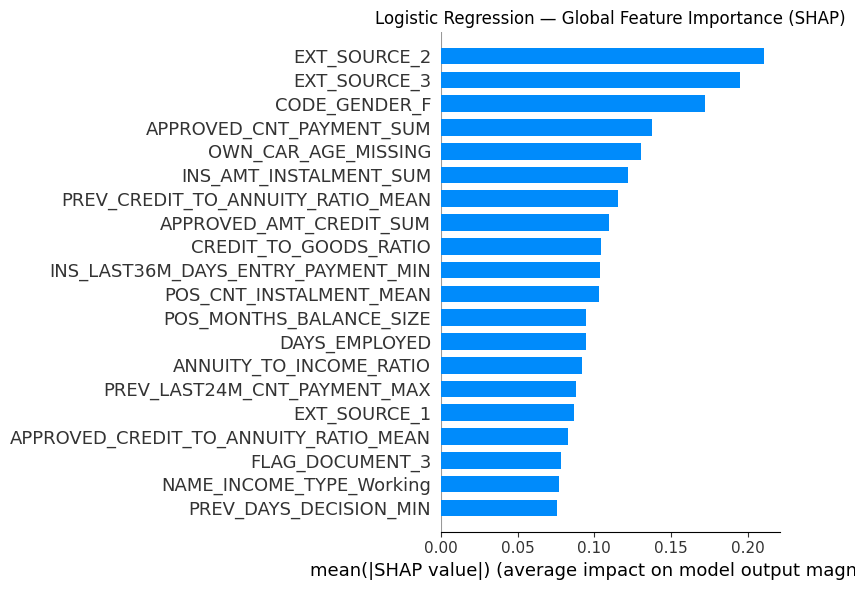

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SHAP FEATURE IMPORTANCE BAR PLOT
# ============================================================

print("Generating LR SHAP Feature Importance Bar Plot...")
shap.summary_plot(lr_shap_values, X_test_lr, plot_type="bar", plot_size=[8,6], show=False)
plt.title("Logistic Regression — Global Feature Importance (SHAP)", fontsize=12)
plt.tight_layout()
plt.show()


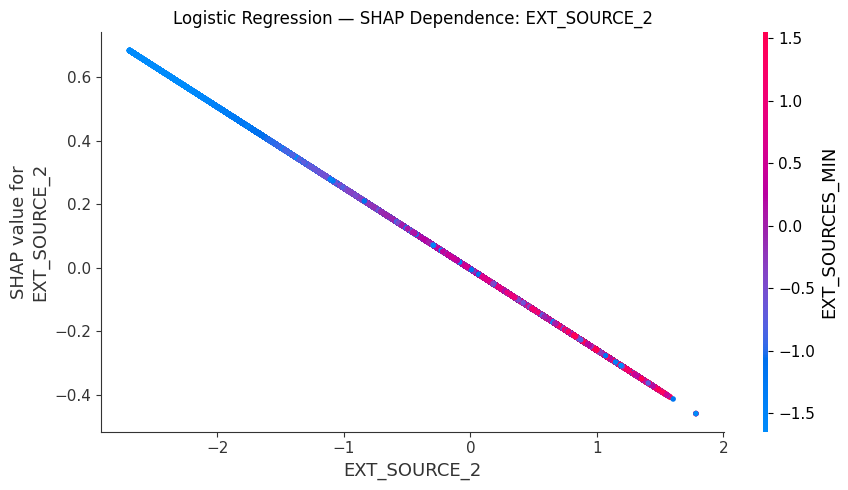

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SHAP DEPENDENCE PLOT (Top Feature)
# ============================================================

mean_abs_lr = np.abs(lr_shap_values).mean(axis=0)
top_lr_feature = X_test_lr.columns[np.argmax(mean_abs_lr)]

fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(top_lr_feature, lr_shap_values, X_test_lr, ax=ax, show=False)
ax.set_title(f"Logistic Regression — SHAP Dependence: {top_lr_feature}", fontsize=12)
plt.tight_layout()
plt.show()


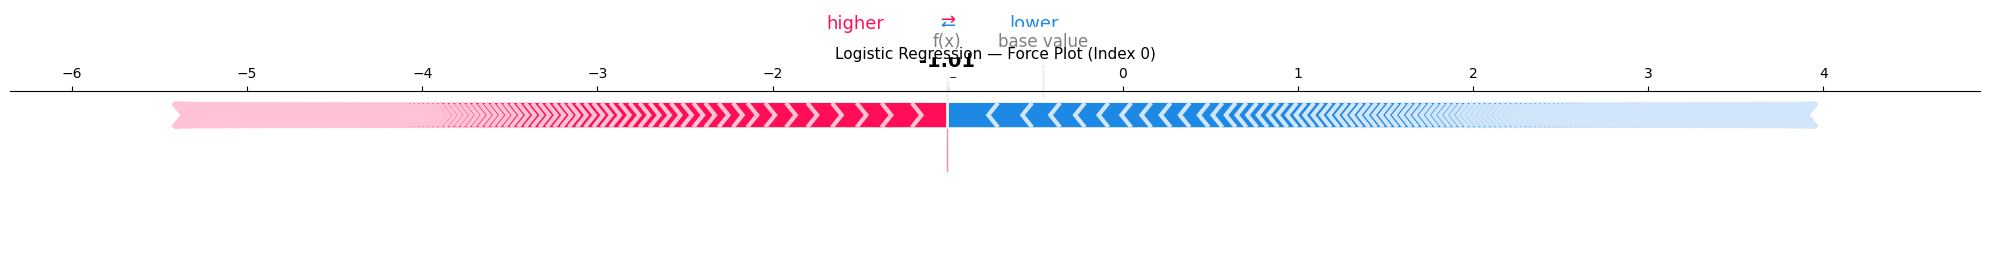

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SHAP FORCE PLOT (First Correct Prediction)
# ============================================================

idx_lr = lr_correct_examples[0]
shap.force_plot(
    lr_explainer.expected_value,
    lr_shap_values[idx_lr],
    X_test_lr.iloc[idx_lr],
    matplotlib=True,
    show=False
)
plt.title(f"Logistic Regression — Force Plot (Index {idx_lr})", fontsize=11)
plt.tight_layout()
plt.show()


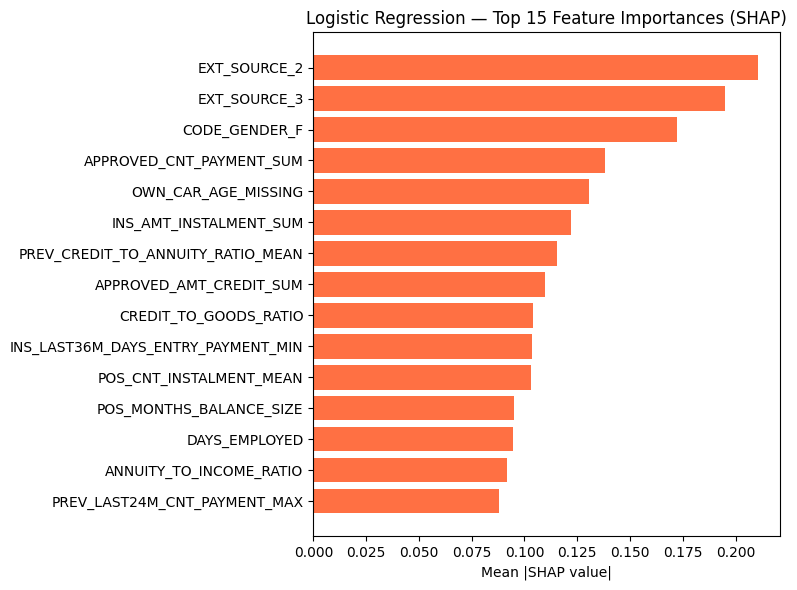

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - TOP 15 FEATURES (Mean |SHAP|)
# ============================================================

mean_abs_lr_all = np.abs(lr_shap_values).mean(axis=0)
lr_feat_importance = pd.DataFrame({
    'Feature': X_test_lr.columns,
    'Mean |SHAP|': mean_abs_lr_all
}).sort_values('Mean |SHAP|', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(lr_feat_importance['Feature'], lr_feat_importance['Mean |SHAP|'], color='#FF7043')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Logistic Regression — Top 15 Feature Importances (SHAP)', fontsize=12)
plt.tight_layout()
plt.show()


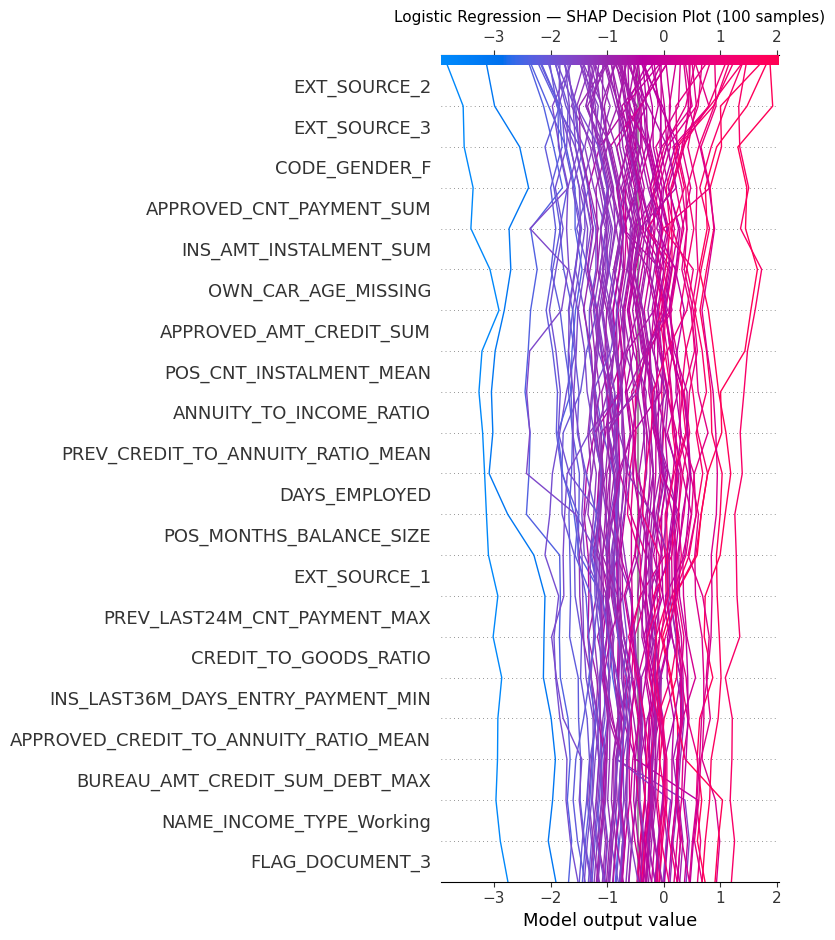

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - SHAP DECISION PLOT (Sample of 100)
# ============================================================

sample_size_lr = min(100, lr_shap_values.shape[0])
sample_idx_lr = np.random.RandomState(42).choice(lr_shap_values.shape[0], sample_size_lr, replace=False)

shap.decision_plot(
    lr_explainer.expected_value,
    lr_shap_values[sample_idx_lr],
    X_test_lr.iloc[sample_idx_lr],
    show=False
)
plt.title("Logistic Regression — SHAP Decision Plot (100 samples)", fontsize=11)
plt.tight_layout()
plt.show()


# Global SHAP Feature Importance - Neural Network

In this section, a global SHAP feature importance analysis was performed to identify which variables had the strongest overall influence on the neural network predictions across the selected explanation samples.

Unlike the earlier local SHAP explanations that focused on individual customers, this stage analyses:
- overall feature importance,
- global model behaviour,
- and which financial variables most strongly influenced prediction decisions across multiple observations.

This helps improve interpretability of the black-box neural network by identifying the most influential features globally.

---

# Calculating Mean Absolute SHAP Values

The first step was calculating the average absolute SHAP contribution for each feature.

```python
mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)
```

This calculation works as follows:

| Function | Purpose |
|---|---|
| `np.abs()` | Converts SHAP values to absolute values |
| `.mean(axis=0)` | Calculates average contribution per feature |

SHAP values can be:
- positive,
- or negative.

However, for global importance analysis, the focus is:
- how strongly a feature influences predictions overall,
rather than:
- whether it increases or decreases risk.

Taking the absolute value ensures that:
- large positive and large negative contributions are both treated as important.

The final result:
- `mean_abs_shap`
contains the average contribution strength of every feature across all analysed samples.

---

# Creating the SHAP Importance DataFrame

A dataframe was created to organise the feature importance results.

```python
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_ABS_SHAP": mean_abs_shap
})
```

The dataframe contains:

| Column | Meaning |
|---|---|
| `Feature` | Feature name |
| `Mean_ABS_SHAP` | Average absolute SHAP contribution |

---

# Sorting Features by Importance

The features were then sorted from highest importance to lowest importance.

```python
.sort_values("Mean_ABS_SHAP", ascending=False)
```

This step ensures:
- the most influential variables appear first.

---

# Displaying the Top 20 Features

The top 20 most important features were displayed using:

```python
display(shap_importance.head(20))
```

This provides a readable table showing:
- which variables contributed most strongly to neural network decisions.

---

# Creating the SHAP Feature Importance Plot

A horizontal bar chart was then created.

```python
plt.figure(figsize=(10, 8))
```

The plot size was increased to make the feature names readable.

The bar chart was created using:

```python
plt.barh(
    shap_importance.head(20)["Feature"][::-1],
    shap_importance.head(20)["Mean_ABS_SHAP"][::-1]
)
```

The features were reversed using:

```python
[::-1]
```

This was done so:
- the most important feature appears at the top of the chart.

---

# Adding Labels and Title

Axis labels and title were added.

```python
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 20 Global SHAP Feature Importance — Neural Network")
```

The x-axis represents:
- average feature contribution strength.

Larger SHAP values indicate:
- stronger overall influence on neural network predictions.

---

# Final Layout and Display

Finally, the layout was adjusted and displayed.

```python
plt.tight_layout()
plt.show()
```

---

# Interpretation of the Global SHAP Results

The SHAP analysis identified several highly influential features across the neural network predictions.

The most important features included:

| Feature | Interpretation |
|---|---|
| `EXT_SOURCE_2` | External creditworthiness indicator |
| `CODE_GENDER_F` | Gender-related encoded variable |
| `EXT_SOURCES_MEAN` | Combined external credit score indicator |
| `INS_PAYMENT_DIFFERENCE_MAX` | Installment payment behaviour |
| `CREDIT_TO_GOODS_RATIO` | Loan-to-goods relationship |
| `PREV_CASH_APPLICATION_CREDIT_DIFF_MIN` | Previous application credit behaviour |
| `BASEMENTAREA_AVG` | Property-related variable |
| `REFUSED_CREDIT_TO_ANNUITY_RATIO_MEAN` | Previous rejected application risk ratio |
| `BUREAU_CONSUMER_AMT_CREDIT_SUM_DEBT_MEAN` | Bureau debt burden |
| `PREV_LAST12M_DAYS_DECISION_MEAN` | Recent loan decision behaviour |

---

# Understanding the Most Important Features

## External Credit Source Variables

Several `EXT_SOURCE_*` variables appeared among the most important features:
- `EXT_SOURCE_2`
- `EXT_SOURCES_MEAN`
- `EXT_SOURCES_MAX`
- `EXT_SOURCE_3`
- `EXT_SOURCES_MIN`

These variables represent external creditworthiness indicators commonly used in financial systems.

Their repeated importance suggests:
- the neural network relies heavily on external credit information to estimate default risk.

This is financially logical because:
- customers with stronger external scores are generally less likely to default.

---

## Debt and Credit Behaviour Variables

Several bureau and repayment-related variables also appeared highly important:

| Feature | Meaning |
|---|---|
| `BUREAU_CONSUMER_AMT_CREDIT_SUM_DEBT_MEAN` | Average debt burden |
| `CREDIT_TO_GOODS_RATIO` | Loan size relative to goods value |
| `REFUSED_CREDIT_TO_ANNUITY_RATIO_MEAN` | Risk level of rejected applications |

These variables are strongly related to:
- repayment pressure,
- borrowing behaviour,
- and financial stress.

The neural network appears to have learned meaningful financial risk relationships from these variables.

---

## Previous Application Behaviour

Multiple previous application variables also appeared:

| Feature | Meaning |
|---|---|
| `PREV_LAST12M_DAYS_DECISION_MEAN` | Recent previous application activity |
| `PREV_LAST12M_AMT_APPLICATION_MAX` | Large previous application amounts |
| `PREV_CASH_APPLICATION_CREDIT_DIFF_MIN` | Difference between requested and approved credit |

This suggests that:
- historical borrowing behaviour,
- and previous loan application patterns

strongly influenced prediction decisions.

---

# Interesting Observations

Several interesting patterns appeared in the global SHAP results.

---

## 1. External Credit Scores Dominated

The strongest feature overall was:

```text
EXT_SOURCE_2
```

This indicates that:
- external financial scoring systems heavily influenced the neural network predictions.

This is realistic because financial institutions commonly use external credit indicators during loan evaluation.

However, it also means:
- the model may depend strongly on pre-existing credit scoring systems.

---

## 2. Gender Variable Appeared Highly Important

One interesting observation is that:

```text
CODE_GENDER_F
```

appeared among the most influential features.

This may raise fairness and bias concerns because:
- demographic-related variables may indirectly affect financial decisions.

Although the model was not explicitly designed to discriminate,
the importance of gender-related features suggests:
- further fairness analysis may be needed.

This is especially important from a human-centred AI perspective.

---

## 3. Feature Importance Was Distributed

The SHAP plot shows that:
- the neural network did not rely on only one feature.

Instead:
- multiple financial, behavioural, and bureau-related variables contributed simultaneously.

This suggests that:
- the neural network learned complex nonlinear relationships across many variables.

---

# Financial Interpretation

Overall, the global SHAP feature importance results appear financially realistic.

The neural network relied heavily on:
- external credit scores,
- debt burden,
- repayment behaviour,
- previous loan activity,
- and financial ratios.

These are all important indicators commonly used in:
- credit-risk assessment,
- loan approval systems,
- and financial risk management.

The SHAP analysis therefore suggests that:
- the neural network learned meaningful financial patterns,
rather than:
- random or completely uninterpretable relationships.

---

# Human-Centred AI Perspective

From a human-centred AI perspective, the global SHAP analysis improved transparency by:
- identifying the most influential variables,
- explaining what drives neural network predictions,
- and helping humans better understand black-box behaviour.

This is important because:
- financial AI systems directly affect customers,
- and explainability helps improve trust, accountability, and fairness.

The SHAP feature importance plot provides a global overview of:
- which variables matter most,
- how the neural network behaves overall,
- and whether the learned relationships appear financially reasonable.

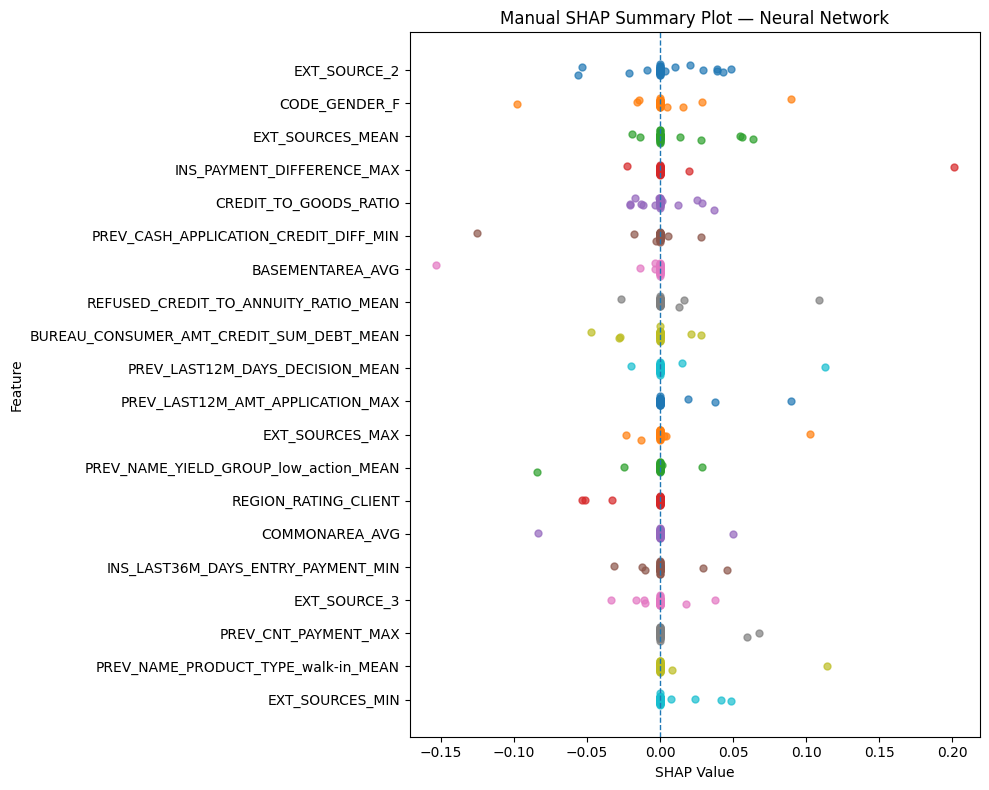

In [ ]:
# ============================================================
# Manual SHAP Summary Plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert X_explain to dataframe safely
X_explain_df = pd.DataFrame(X_explain, columns=feature_names)

# Select top 20 features from global SHAP importance
top_features = shap_importance.head(20)["Feature"].tolist()
top_feature_indices = [feature_names.index(f) for f in top_features]

plt.figure(figsize=(10, 8))

for position, feature_idx in enumerate(top_feature_indices):
    feature_name = feature_names[feature_idx]

    shap_feature_values = shap_values_plot[:, feature_idx]

    # Add small random jitter so points do not overlap completely
    jitter = np.random.normal(0, 0.08, size=len(shap_feature_values))
    y_positions = np.full(len(shap_feature_values), position) + jitter

    plt.scatter(
        shap_feature_values,
        y_positions,
        alpha=0.7,
        s=25
    )

plt.yticks(range(len(top_features)), top_features)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Manual SHAP Summary Plot — Neural Network")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The standard `shap.summary_plot()` function produced a colorbar-related plotting error in the server environment. To avoid this compatibility issue, a manual SHAP summary-style plot was created using the calculated SHAP values. This still shows the direction and spread of SHAP values for the most influential features without relying on SHAP's internal colorbar rendering.

# Manual SHAP Summary Plot

In this section, a manual SHAP summary plot was created to visualise how the most important features influenced the neural network predictions across multiple observations.

Unlike the earlier global SHAP bar chart that only showed:
- overall feature importance magnitude,

this summary plot additionally shows:
- the direction of SHAP contributions,
- the spread of SHAP values,
- and how individual observations behave for each important feature.

This provides a more detailed understanding of the neural network decision-making process.

---

# Importing Required Libraries

The required libraries were imported first.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

These libraries were used for:
- numerical operations,
- dataframe handling,
- and visualization.

---

# Converting the Explanation Dataset into a DataFrame

The explanation sample was converted into a dataframe.

```python
X_explain_df = pd.DataFrame(X_explain, columns=feature_names)
```

This step ensures:
- feature names remain aligned with the explanation dataset,
- making the SHAP analysis easier to interpret.

---

# Selecting the Top 20 Most Important Features

The top 20 globally important SHAP features were selected using:

```python
top_features = shap_importance.head(20)["Feature"].tolist()
```

This extracts:
- the 20 most influential variables identified in the earlier global SHAP importance analysis.

---

# Extracting Feature Indices

The corresponding feature indices were then identified.

```python
top_feature_indices = [feature_names.index(f) for f in top_features]
```

This step converts:
- feature names,
into:
- their numeric positions inside the dataset.

The indices are needed to retrieve the corresponding SHAP values.

---

# Creating the Figure

A new figure was created:

```python
plt.figure(figsize=(10, 8))
```

The larger figure size improves readability because:
- multiple features,
- and many SHAP points

are displayed simultaneously.

---

# Looping Through Features

A loop was created to process each selected feature individually.

```python
for position, feature_idx in enumerate(top_feature_indices):
```

The loop:
- iterates through each important feature,
- extracts SHAP values,
- and plots them separately.

---

# Extracting Feature SHAP Values

Inside the loop, the SHAP values for the current feature were extracted.

```python
shap_feature_values = shap_values_plot[:, feature_idx]
```

This retrieves:
- all SHAP contributions
for:
- one feature across all analysed observations.

---

# Adding Random Jitter

A small amount of random vertical jitter was added.

```python
jitter = np.random.normal(0, 0.08, size=len(shap_feature_values))
```

This was done because:
- many SHAP values may overlap at similar positions.

Without jitter:
- points would overlap completely,
- making the plot difficult to read.

The jitter slightly spreads the points vertically while preserving the SHAP values.

---

# Creating Y-Axis Positions

The y-axis positions were then created.

```python
y_positions = np.full(len(shap_feature_values), position) + jitter
```

This places:
- all observations for the same feature
along:
- the same horizontal row,
while:
- the jitter spreads them slightly.

---

# Creating the Scatter Plot

The SHAP points were plotted using:

```python
plt.scatter(
    shap_feature_values,
    y_positions,
    alpha=0.7
)
```

Each point represents:
- one observation,
- and the SHAP contribution of that feature for that observation.

The x-axis represents:
- SHAP value.

---

# Understanding SHAP Values in the Plot

The SHAP values indicate:
- how strongly a feature influenced the prediction,
- and in which direction.

| SHAP Value | Meaning |
|---|---|
| Positive SHAP | Increased default probability |
| Negative SHAP | Reduced default probability |
| SHAP near 0 | Minimal influence |

---

# Adding the Vertical Reference Line

A vertical dashed line was added at zero.

```python
plt.axvline(0, linestyle="--")
```

This line separates:
- negative SHAP contributions,
from:
- positive SHAP contributions.

This improves interpretation because:
- left side → pushes prediction toward non-default,
- right side → pushes prediction toward default.

---

# Adding Labels and Title

Axis labels and title were added.

```python
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Manual SHAP Summary Plot — Neural Network")
```

The y-axis represents:
- feature names.

The x-axis represents:
- feature contribution strength and direction.

---

# Adding Feature Labels

The feature names were added using:

```python
plt.yticks(range(len(top_features)), top_features)
```

This aligns:
- each feature name,
with:
- its corresponding SHAP distribution row.

---

# Final Layout and Display

Finally, the plot layout was adjusted and displayed.

```python
plt.tight_layout()
plt.show()
```

---

# Interpretation of the Manual SHAP Summary Plot

The manual SHAP summary plot provides a more detailed view of how the neural network used the most important financial variables.

Each horizontal row represents:
- one feature.

Each point represents:
- one customer observation.

The position of the point shows:
- whether that feature increased or decreased predicted default risk for that specific customer.

---

# Understanding the Feature Behaviour

Several important patterns appeared in the SHAP summary plot.

---

## 1. External Credit Score Variables Dominated

Features such as:
- `EXT_SOURCE_2`
- `EXT_SOURCES_MEAN`
- `EXT_SOURCES_MAX`
- `EXT_SOURCE_3`
- `EXT_SOURCES_MIN`

appeared repeatedly near the top of the plot.

These variables showed both:
- positive SHAP values,
- and negative SHAP values.

This means:
- external credit information strongly influenced predictions,
- but the direction depended on the customer context.

For some customers:
- external scores reduced default probability,
while for others:
- they increased predicted risk.

This demonstrates nonlinear feature behaviour inside the neural network.

---

## 2. Wide SHAP Spread Indicates Strong Influence

Some variables showed:
- a large horizontal spread of SHAP values.

Examples include:
- `INS_PAYMENT_DIFFERENCE_MAX`
- `CODE_GENDER_F`
- `PREV_LAST12M_DAYS_DECISION_MEAN`

A wider SHAP spread suggests:
- the feature had stronger influence across different customers.

Features with SHAP values close to zero:
- had weaker overall influence.

---

## 3. Positive and Negative Contributions Both Appeared

Most features contained points on both sides of the zero line.

This indicates:
- the same feature can either increase or decrease default probability depending on:
  - other financial variables,
  - customer profile,
  - and feature interactions.

This behaviour is expected in neural networks because:
- the model learns nonlinear relationships rather than fixed linear effects.

---

## 4. Some Observations Had Very Strong Effects

A few observations showed extremely large SHAP values.

For example:
- some points reached approximately `+0.20`,
- while others reached around `-0.15`.

These points represent:
- customers where a specific feature had unusually strong influence on the prediction.

This suggests:
- certain financial patterns strongly affected neural network decisions.

---

# Interesting Feature Observations

Several features appeared especially important and financially meaningful.

| Feature | Possible Meaning |
|---|---|
| `EXT_SOURCE_2` | External creditworthiness |
| `INS_PAYMENT_DIFFERENCE_MAX` | Repayment behaviour differences |
| `CREDIT_TO_GOODS_RATIO` | Loan-to-goods relationship |
| `BUREAU_CONSUMER_AMT_CREDIT_SUM_DEBT_MEAN` | Debt burden |
| `PREV_LAST12M_DAYS_DECISION_MEAN` | Previous application activity |
| `REGION_RATING_CLIENT` | Regional credit-related risk indicator |

These variables are all logically connected to:
- repayment behaviour,
- financial stability,
- and borrowing risk.

---

# Financial Interpretation

The SHAP summary plot suggests that:
- the neural network learned meaningful financial behaviour patterns,
- rather than relying on random relationships.

The model strongly relied on:
- external credit indicators,
- debt burden,
- repayment behaviour,
- and previous loan activity.

At the same time:
- feature effects were highly context-dependent.

This reflects the complexity of real-world financial systems where:
- the same financial variable may indicate risk for one customer,
- but stability for another.

---

# Human-Centred AI Perspective

From a human-centred AI perspective, the SHAP summary plot improves transparency by:
- showing how individual features influence predictions across many customers,
- revealing nonlinear behaviour,
- and helping humans better understand the black-box neural network.

This is important because:
- financial AI systems directly affect people,
- and explainability helps improve:
  - trust,
  - accountability,
  - fairness,
  - and transparency.

The summary plot therefore provides an important interpretability layer for analysing how the neural network behaves globally across different customers.

In [ ]:
# ============================================================
# Prediction Analysis for SHAP Sample
# ============================================================

# True labels for the same rows used in SHAP
y_explain_true = y_test.iloc[explain_idx].values

# Predicted probabilities and classes for the same SHAP sample
y_explain_prob = loaded_model.predict(
    X_explain,
    batch_size=128,
    verbose=0
).ravel()

y_explain_pred = (y_explain_prob >= decision_threshold).astype(int)

prediction_analysis = pd.DataFrame({
    "Actual": y_explain_true,
    "Predicted": y_explain_pred,
    "Default_Probability": y_explain_prob
})

display(prediction_analysis.head())

,Actual,Predicted,Default_Probability
0,0,0,0.231001
1,0,0,0.079546
2,0,1,0.555055
3,0,1,0.770022
4,0,0,0.183749


In [ ]:
# ============================================================
# Find Correct and Incorrect Prediction Cases
# ============================================================

true_positive = prediction_analysis[
    (prediction_analysis["Actual"] == 1) &
    (prediction_analysis["Predicted"] == 1)
]

true_negative = prediction_analysis[
    (prediction_analysis["Actual"] == 0) &
    (prediction_analysis["Predicted"] == 0)
]

false_positive = prediction_analysis[
    (prediction_analysis["Actual"] == 0) &
    (prediction_analysis["Predicted"] == 1)
]

false_negative = prediction_analysis[
    (prediction_analysis["Actual"] == 1) &
    (prediction_analysis["Predicted"] == 0)
]

print("True Positive:", len(true_positive))
print("True Negative:", len(true_negative))
print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))

True Positive: 1
True Negative: 25
False Positive: 14
False Negative: 0


In [ ]:
# ============================================================
# Select Representative Cases for Local SHAP Explanation
# ============================================================

selected_cases = {}

# Most confident true positive: actual default correctly predicted with highest default probability
if len(true_positive) > 0:
    selected_cases["True Positive - Correct Default Prediction"] = (
        true_positive.sort_values("Default_Probability", ascending=False).index[0]
    )

# Most confident true negative: actual non-default correctly predicted with lowest default probability
if len(true_negative) > 0:
    selected_cases["True Negative - Correct Non-Default Prediction"] = (
        true_negative.sort_values("Default_Probability", ascending=True).index[0]
    )

# Most confident false positive: actual non-default incorrectly predicted as default
if len(false_positive) > 0:
    selected_cases["False Positive - Incorrect Default Prediction"] = (
        false_positive.sort_values("Default_Probability", ascending=False).index[0]
    )

# Most confident false negative: actual default incorrectly predicted as non-default
if len(false_negative) > 0:
    selected_cases["False Negative - Missed Default Prediction"] = (
        false_negative.sort_values("Default_Probability", ascending=True).index[0]
    )


# Wrong prediction 2: Second most confident False Positive
if len(false_positive) > 1:
    selected_cases["False Positive 2 – Second Most Confident Incorrect Default Prediction"] = (
        false_positive.sort_values("Default_Probability", ascending=False).index[1]
    )


selected_cases

{'True Positive - Correct Default Prediction': 14,
 'True Negative - Correct Non-Default Prediction': 1,
 'False Positive - Incorrect Default Prediction': 37,
 'False Positive 2 – Second Most Confident Incorrect Default Prediction': 26}

In [ ]:
# ============================================================
# Function to Explain Individual Prediction Cases
# ============================================================

def explain_prediction_case(case_name, row_index, top_n=10):
    """
    Creates a local SHAP explanation table and bar chart for one selected prediction.
    row_index refers to the row position inside X_explain / prediction_analysis.
    """

    shap_row = shap_values_plot[row_index]

    case_df = pd.DataFrame({
        "Feature": feature_names,
        "Feature_Value": X_explain.iloc[row_index].values,
        "SHAP_Value": shap_row
    })

    case_df["ABS_SHAP"] = case_df["SHAP_Value"].abs()
    case_df = case_df.sort_values("ABS_SHAP", ascending=False).head(top_n)

    actual = prediction_analysis.loc[row_index, "Actual"]
    predicted = prediction_analysis.loc[row_index, "Predicted"]
    probability = prediction_analysis.loc[row_index, "Default_Probability"]

    print("=" * 90)
    print(case_name)
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("Predicted default probability:", round(probability, 4))
    print("=" * 90)

    display(case_df)

    plt.figure(figsize=(10, 6))
    plt.barh(case_df["Feature"], case_df["SHAP_Value"])
    plt.xlabel("SHAP Value")
    plt.title(case_name)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return case_df

# Prediction Analysis for SHAP Samples

In this section, the predictions generated by the neural network were analysed for the same observations used during the SHAP explanation process.

The purpose of this step was to:
- compare the actual labels with the predicted labels,
- observe the predicted default probabilities,
- and identify different prediction categories for later SHAP interpretation.

This analysis helps connect:
- model predictions,
with:
- SHAP explanations.

---

# Extracting the True Labels

The true target labels for the SHAP explanation samples were first extracted.

```python
y_explain_true = y_test.iloc[explain_idx].values
```

This step retrieves:
- the real default outcomes
for:
- the selected explanation observations.

These values represent:
- the ground-truth labels used to evaluate prediction correctness.

---

# Generating Prediction Probabilities

The saved neural network model was then used to generate predicted probabilities.

```python
y_explain_prob = loaded_model.predict(
    X_explain,
    batch_size=128,
    verbose=0
).ravel()
```

The model outputs:
- probabilities between 0 and 1.

These probabilities represent:
- the predicted likelihood of customer default.

For example:
- probability close to `1` → high default risk,
- probability close to `0` → low default risk.

---

# Prediction Parameters

Two parameters were used during prediction:

| Parameter | Purpose |
|---|---|
| `batch_size=128` | Speeds up prediction processing |
| `verbose=0` | Hides unnecessary output |

The `.ravel()` function converts:
- the prediction output
into:
- a one-dimensional array.

---

# Converting Probabilities into Predicted Classes

The predicted probabilities were converted into binary class predictions.

```python
y_explain_pred = (y_explain_prob >= decision_threshold).astype(int)
```

This applies:
- the selected classification threshold.

If:
- probability ≥ threshold → predicted default (`1`),
- probability < threshold → predicted non-default (`0`).

The `.astype(int)` function converts:
- Boolean results
into:
- integer class labels.

---

# Creating the Prediction Analysis DataFrame

A dataframe called `prediction_analysis` was then created.

```python
prediction_analysis = pd.DataFrame({
    "Actual": y_explain_true,
    "Predicted": y_explain_pred,
    "Default_Probability": y_explain_prob
})
```

The dataframe stores:
- actual labels,
- predicted labels,
- predicted default probabilities.

This creates a structured table for analysing prediction behaviour.

---

# Displaying the Prediction Results

The first few rows were displayed using:

```python
display(prediction_analysis.head())
```

Example output:

| Actual | Predicted | Default_Probability |
|---|---|---|
| 0 | 0 | 0.231001 |
| 0 | 0 | 0.079546 |
| 0 | 1 | 0.555055 |
| 0 | 1 | 0.770022 |
| 0 | 0 | 0.183749 |

---

# Interpretation of the Prediction Table

The table shows:
- whether the neural network predictions matched the true labels,
- and how confident the model was.

For example:

| Situation | Meaning |
|---|---|
| Actual = 0, Predicted = 0 | Correct non-default prediction |
| Actual = 1, Predicted = 1 | Correct default prediction |
| Actual = 0, Predicted = 1 | False Positive |
| Actual = 1, Predicted = 0 | False Negative |

---

# Understanding Default Probabilities

The `Default_Probability` column provides additional insight into:
- model confidence.

Examples:
- `0.079546` → very low default risk,
- `0.770022` → strong default prediction.

This is important because:
- neural networks may sometimes produce:
  - highly confident correct predictions,
  - or highly confident incorrect predictions.

---

# Financial Interpretation

The prediction probabilities represent:
- estimated repayment risk levels.

Customers with:
- higher probabilities
were considered:
- more likely to default.

Customers with:
- lower probabilities
were considered:
- financially safer.

This step helps prepare the later SHAP analysis because:
- individual predictions can now be connected directly to:
  - feature contributions,
  - model confidence,
  - and prediction correctness.

---

# Categorising Prediction Outcomes

The predictions were then divided into four separate categories:

```python
true_positive = prediction_analysis[
    (prediction_analysis["Actual"] == 1) &
    (prediction_analysis["Predicted"] == 1)
]
```

```python
true_negative = prediction_analysis[
    (prediction_analysis["Actual"] == 0) &
    (prediction_analysis["Predicted"] == 0)
]
```

```python
false_positive = prediction_analysis[
    (prediction_analysis["Actual"] == 0) &
    (prediction_analysis["Predicted"] == 1)
]
```

```python
false_negative = prediction_analysis[
    (prediction_analysis["Actual"] == 1) &
    (prediction_analysis["Predicted"] == 0)
]
```

Each category represents a different prediction outcome.

---

# Meaning of Each Prediction Category

| Category | Meaning |
|---|---|
| True Positive | Correctly predicted default |
| True Negative | Correctly predicted non-default |
| False Positive | Incorrectly predicted default |
| False Negative | Missed actual default |

These categories are important because:
- they allow detailed SHAP analysis for:
  - correct decisions,
  - and model mistakes.

---

# Counting Prediction Types

The number of observations in each category was then printed.

```python
print("True Positive:", len(true_positive))
print("True Negative:", len(true_negative))
print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))
```

Example output:

```text
True Positive: 1
True Negative: 25
False Positive: 14
False Negative: 0
```

---

# Interpretation of Prediction Distribution

The prediction distribution shows:
- many True Negatives,
- several False Positives,
- very few True Positives,
- and no False Negatives.

This suggests that:
- the model was relatively conservative,
- and preferred predicting customers as risky rather than missing actual defaults.

---

# Financial Interpretation of the Prediction Behaviour

From a financial perspective:
- False Negatives are usually considered more dangerous,
because:
- risky customers may incorrectly receive loans.

The absence of False Negatives may indicate that:
- the model strongly prioritised risk detection.

However:
- the higher number of False Positives suggests:
  - some safe customers were incorrectly classified as risky.

This could potentially:
- reduce customer fairness,
- or lead to unnecessary loan rejection.

---

# Selecting Representative Cases for SHAP Analysis

Representative prediction cases were then selected.

The purpose of this step was to:
- identify one highly representative example from each prediction category,
- and later generate detailed local SHAP explanations for those examples.

---

# Selecting the Most Confident True Positive

The most confident True Positive was selected using:

```python
selected_cases["True Positive – Correct Default Prediction"] = (
    true_positive.sort_values("Default_Probability", ascending=False).index[0]
)
```

This selects:
- the correctly predicted default customer
with:
- the highest default probability.

---

# Selecting the Most Confident True Negative

The most confident True Negative was selected using:

```python
selected_cases["True Negative – Correct Non-Default Prediction"] = (
    true_negative.sort_values("Default_Probability", ascending=True).index[0]
)
```

This selects:
- the safest correctly predicted customer
with:
- the lowest default probability.

---

# Selecting the Most Confident False Positive

The most confident False Positive was selected using:

```python
selected_cases["False Positive – Incorrect Default Prediction"] = (
    false_positive.sort_values("Default_Probability", ascending=False).index[0]
)
```

This selects:
- the customer incorrectly classified as risky
with:
- the highest predicted default probability.

This type of case is especially interesting because:
- the model made a highly confident mistake.

---

# Selecting the Most Confident False Negative

The False Negative selection logic was also included:

```python
selected_cases["False Negative – Missed Default Prediction"] = (
    false_negative.sort_values("Default_Probability", ascending=True).index[0]
)
```

This would select:
- the missed default customer
with:
- the lowest predicted default probability.

However:
- no False Negatives existed in this sample,
so:
- no False Negative case was selected.

---

# Displaying Selected Cases

The final selected cases dictionary was displayed.

Example output:

```python
{
 'True Positive – Correct Default Prediction': 14,
 'True Negative – Correct Non-Default Prediction': 1,
 'False Positive – Incorrect Default Prediction': 37
}
```

These indices represent:
- the observations chosen for detailed local SHAP explanations.

---

# Why These Cases Were Selected

These cases provide:
- representative examples of:
  - correct decisions,
  - and incorrect decisions.

Analysing them individually helps understand:
- how the neural network behaves,
- which features drive decisions,
- and why certain prediction mistakes occur.

---

# Importance for SHAP Interpretation

Selecting representative prediction cases is important because:
- global SHAP analysis only shows overall feature importance,
while:
- local SHAP analysis explains:
  - individual customer decisions.

This allows:
- deeper transparency,
- better understanding of model behaviour,
- and clearer interpretation of neural network reasoning.

---

# Human-Centred AI Perspective

From a human-centred AI perspective, this step improves explainability because:
- individual predictions become traceable,
- model decisions can be analysed case-by-case,
- and humans can better understand:
  - why a customer was classified as risky or safe.

This is especially important in financial AI systems because:
- incorrect predictions may directly affect:
  - loan approval decisions,
  - customer fairness,
  - and financial opportunity.

True Positive - Correct Default Prediction
Actual: 1
Predicted: 1
Predicted default probability: 0.5328


,Feature,Feature_Value,SHAP_Value,ABS_SHAP
440,ORGANIZATION_TYPE_Business Entity Type 3,-0.532794,0.043420,0.043420
39,POS_MONTHS_BALANCE_SIZE,0.357710,-0.035778,0.035778
107,PREV_LAST24M_DAYS_DECISION_MEAN,1.228042,0.035516,0.035516
421,BUREAU_ACTIVE_STATUS_12345_MEAN,-0.155685,0.032238,0.032238
240,INS_DPD_7_MEAN,0.267150,-0.030334,0.030334
263,PREV_WEEKDAY_APPR_PROCESS_START_TUESDAY_MEAN,-0.023074,0.029935,0.029935
0,EXT_SOURCES_MEAN,-0.394371,0.028195,0.028195
229,CC_LAST48M_LIMIT_USE_MAX,0.103436,0.024840,0.024840
361,REFUSED_CNT_PAYMENT_MAX,2.323606,0.020858,0.020858
327,PREV_LAST12M_CNT_PAYMENT_SUM,2.788360,0.020306,0.020306


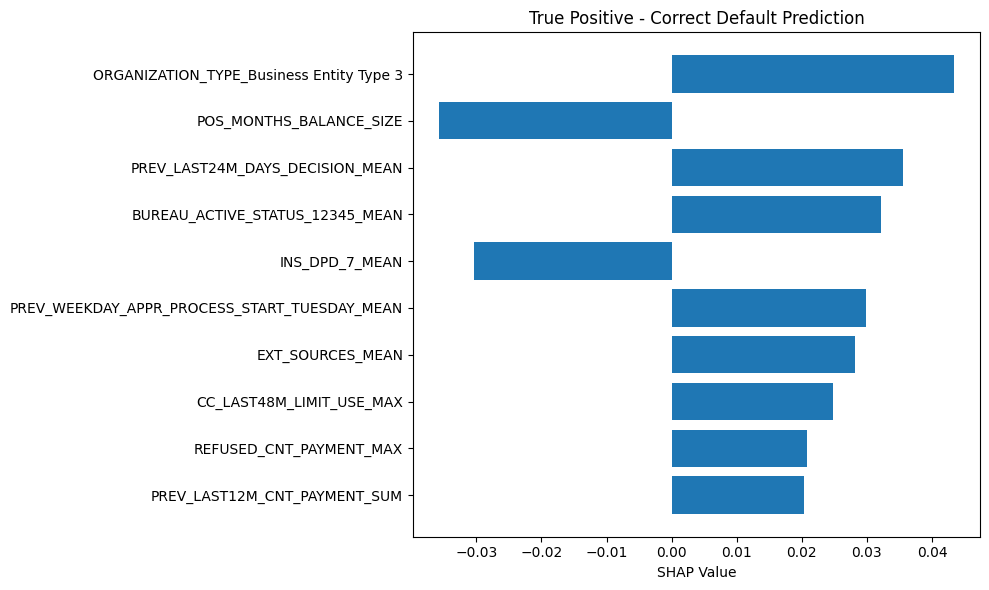

True Negative - Correct Non-Default Prediction
Actual: 0
Predicted: 0
Predicted default probability: 0.0795


,Feature,Feature_Value,SHAP_Value,ABS_SHAP
174,BUREAU_LAST12M_AMT_CREDIT_SUM_SUM,0.022945,-0.050952,0.050952
42,INS_LAST60M_DAYS_ENTRY_PAYMENT_MIN,-1.284128,-0.038949,0.038949
304,REFUSED_CREDIT_TO_ANNUITY_RATIO_MAX,-3.759260,-0.036603,0.036603
135,APPROVED_CREDIT_TO_ANNUITY_RATIO_MAX,-0.812415,-0.020953,0.020953
362,REFUSED_APPLICATION_CREDIT_RATIO_VAR,-0.103462,-0.020364,0.020364
70,BUREAU_CLOSED_DAYS_CREDIT_MAX,0.274109,-0.020001,0.020001
308,CODE_GENDER_F,0.720391,-0.015903,0.015903
47,BUREAU_DAYS_CREDIT_ENDDATE_MAX,-0.518784,-0.014650,0.014650
152,BUREAU_ACTIVE_AMT_CREDIT_SUM_MEAN,0.053796,-0.013721,0.013721
14,CREDIT_TO_GOODS_RATIO,-0.115819,-0.013023,0.013023


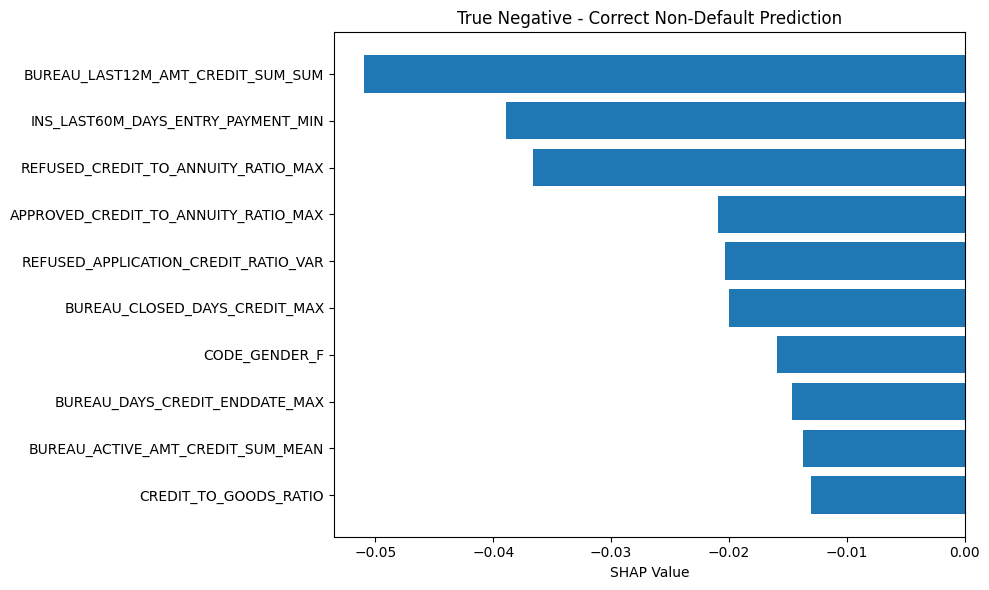

False Positive - Incorrect Default Prediction
Actual: 0
Predicted: 1
Predicted default probability: 0.8192


,Feature,Feature_Value,SHAP_Value,ABS_SHAP
170,BASEMENTAREA_AVG,-0.081213,-0.153554,0.153554
166,PREV_LAST12M_DAYS_DECISION_MEAN,0.228762,0.112975,0.112975
244,PREV_LAST12M_AMT_APPLICATION_MAX,0.129166,0.089790,0.089790
148,POS_NAME_CONTRACT_STATUS_Completed_MEAN,-1.467031,0.074890,0.074890
0,EXT_SOURCES_MEAN,-3.063197,0.063613,0.063613
151,BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,-0.198249,0.058387,0.058387
20,ANNUITY_TO_INCOME_RATIO,0.827210,0.055892,0.055892
194,POS_MONTHS_BALANCE_MAX,0.606972,0.050889,0.050889
352,REFUSED_APPLICATION_CREDIT_RATIO_MAX,0.089730,0.048952,0.048952
57,CURRENT_TO_APPROVED_CREDIT_MEAN_RATIO,-0.028527,0.039045,0.039045


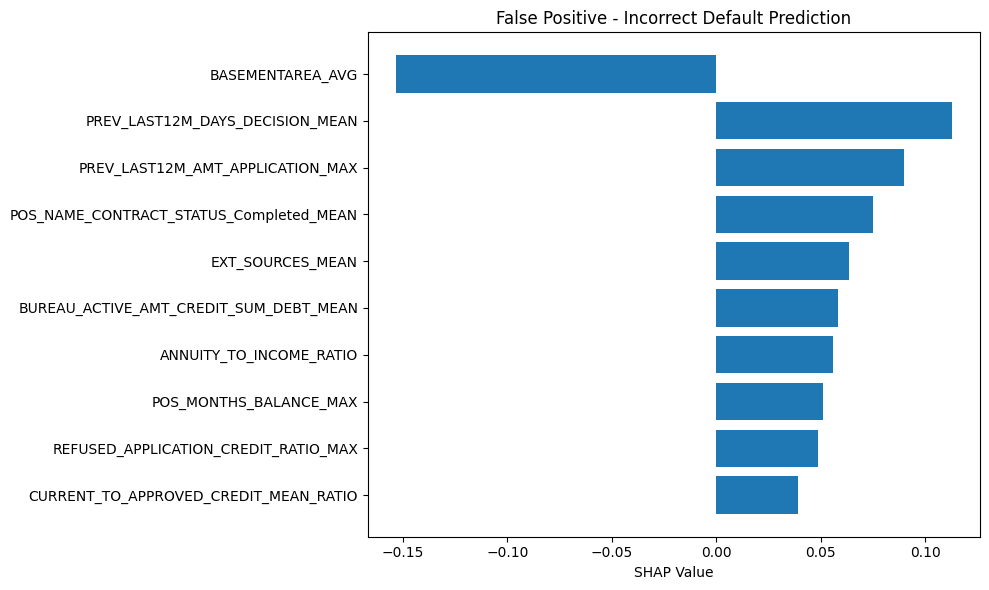

False Positive 2 – Second Most Confident Incorrect Default Prediction
Actual: 0
Predicted: 1
Predicted default probability: 0.7955


,Feature,Feature_Value,SHAP_Value,ABS_SHAP
446,NAME_TYPE_SUITE_Unaccompanied,0.487175,0.069706,0.069706
0,EXT_SOURCES_MEAN,-2.066221,0.056340,0.056340
423,INS_SIGNIFICANT_LATE_PAYMENT_SUM,-0.397755,0.050688,0.050688
21,PREV_LAST24M_SIMPLE_INTERESTS_MEAN,-0.116627,0.050209,0.050209
222,PREV_LAST12M_APPLICATION_CREDIT_RATIO_MIN,0.012431,0.046943,0.046943
3,EXT_SOURCE_2,-2.577417,0.038663,0.038663
449,INS_PAID_OVER_SUM,-0.346813,0.037166,0.037166
167,PREV_NAME_CONTRACT_STATUS_Approved_MEAN,0.972334,0.036379,0.036379
285,REFUSED_AMT_APPLICATION_MAX,0.140872,0.026463,0.026463
233,OBS_30_CNT_SOCIAL_CIRCLE,-0.806782,-0.023076,0.023076


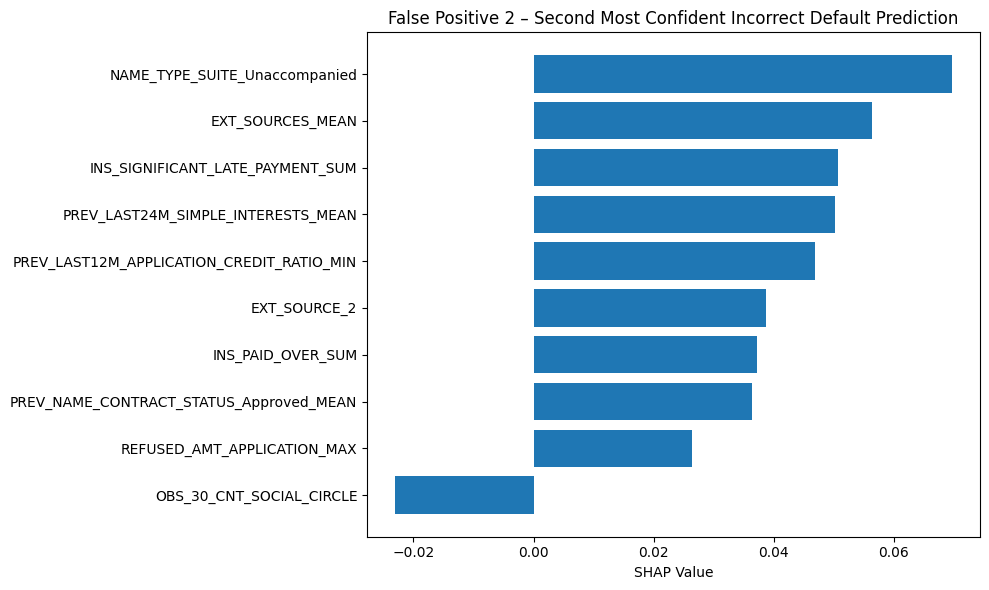

In [ ]:
# ============================================================
# Run Local SHAP Explanation for Selected Cases
# ============================================================

case_explanations = {}

for case_name, row_index in selected_cases.items():
    case_explanations[case_name] = explain_prediction_case(
        case_name,
        row_index,
        top_n=10
    )

In [ ]:
# ============================================================
# Save SHAP Outputs
# ============================================================

# Save global SHAP importance
shap_importance.to_csv("nn_shap_global_importance.csv", index=False)

# Save prediction analysis for the SHAP sample
prediction_analysis.to_csv("nn_shap_prediction_analysis.csv", index=False)

# Save selected local explanation tables
for case_name, case_df in case_explanations.items():
    safe_name = (
        case_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace("__", "_")
    )
    case_df.to_csv(f"nn_shap_{safe_name}.csv", index=False)

# Save raw SHAP arrays
np.savez(
    "nn_shap_values_saved_model.npz",
    shap_values=shap_values_plot,
    explain_indices=explain_idx,
    background_indices=background_idx,
    y_explain_true=y_explain_true,
    y_explain_pred=y_explain_pred,
    y_explain_prob=y_explain_prob
)

print("SHAP outputs saved successfully.")

SHAP outputs saved successfully.


# SHAP-Based Local Explanation of Selected Prediction Cases

## Explaining Individual Predictions Using SHAP

After selecting representative examples from each prediction category, the `explain_prediction_case()` function was used to generate local SHAP explanations for individual predictions produced by the updated neural network model.

The purpose of this stage was to analyse:
- which features had the strongest influence on each prediction,
- whether those features increased or decreased the probability of default,
- and how the neural network reached correct or incorrect decisions for specific customers.

The explanations were generated for:
- True Positive
- True Negative
- False Positive

No False Negative case appeared in the selected SHAP sample because the updated neural network correctly identified all default customers in the selected explanation subset.

---

# 1. True Positive — Correct Default Prediction

## Prediction Summary

```text
Actual: 1
Predicted: 1
Predicted default probability: 0.5328
```

The neural network correctly identified this customer as a default-risk customer.  
The predicted probability of default was approximately 53.28%, which is slightly above the classification threshold.

This indicates that the model detected multiple moderate-risk indicators rather than a single extremely dominant feature.

---

## Main Features Increasing Default Risk

The strongest positive SHAP contributors were:

| Feature | Effect |
|---|---|
| `ORGANIZATION_TYPE_Business Entity Type 3` | Strong increase |
| `PREV_LAST24M_DAYS_DECISION_MEAN` | Increase |
| `BUREAU_ACTIVE_STATUS_12345_MEAN` | Increase |
| `PREV_WEEKDAY_APPR_PROCESS_START_TUESDAY_MEAN` | Increase |
| `EXT_SOURCES_MEAN` | Increase |
| `CC_LAST48M_LIMIT_USE_MAX` | Increase |

These features pushed the prediction toward default.

The model appears to associate:
- recent previous loan decision activity,
- active bureau credit behaviour,
- high credit-card limit usage,
- and certain grouped behavioural patterns

with increased repayment risk.

---

## Features Reducing Default Risk

Some variables reduced the predicted probability of default:

| Feature | Effect |
|---|---|
| `POS_MONTHS_BALANCE_SIZE` | Reduced probability |
| `INS_DPD_7_MEAN` | Reduced probability |

These features acted as protective signals and partially offset the higher-risk indicators.

However, their negative contributions were weaker than the dominant positive SHAP values.

---

## Interpretation

This represents a balanced but correct default prediction.

Unlike extremely confident default cases, this prediction was influenced by several medium-strength risk indicators combined together.

The SHAP explanation suggests that the neural network relied on behavioural credit-history features, previous application activity, and bureau-related indicators to classify the customer as risky.

Although some features reduced risk, the overall contribution pattern pushed the prediction above the default threshold.

---

# 2. True Negative — Correct Non-Default Prediction

## Prediction Summary

```text
Actual: 0
Predicted: 0
Predicted default probability: 0.0795
```

The customer was correctly classified as non-default with a very low predicted default probability of approximately 7.95%.

This indicates a confident safe classification by the neural network.

---

## Main Features Reducing Default Risk

The strongest negative SHAP contributors were:

| Feature | Effect |
|---|---|
| `BUREAU_LAST12M_AMT_CREDIT_SUM_SUM` | Strong decrease |
| `INS_LAST60M_DAYS_ENTRY_PAYMENT_MIN` | Decrease |
| `REFUSED_CREDIT_TO_ANNUITY_RATIO_MAX` | Decrease |
| `APPROVED_CREDIT_TO_ANNUITY_RATIO_MAX` | Decrease |
| `REFUSED_APPLICATION_CREDIT_RATIO_VAR` | Decrease |
| `BUREAU_CLOSED_DAYS_CREDIT_MAX` | Decrease |

These variables strongly pushed the prediction toward non-default.

The SHAP pattern suggests:
- healthier credit history behaviour,
- lower repayment stress,
- and more stable bureau credit characteristics.

---

## Features Slightly Increasing Default Risk

Some features slightly increased risk:

| Feature | Effect |
|---|---|
| `CODE_GENDER_F` | Small increase |
| `BUREAU_DAYS_CREDIT_ENDDATE_MAX` | Small increase |
| `BUREAU_ACTIVE_AMT_CREDIT_SUM_MEAN` | Small increase |
| `CREDIT_TO_GOODS_RATIO` | Small increase |

However, these positive contributions were relatively weak compared to the dominant negative SHAP values.

---

## Interpretation

This is a strong and interpretable correct non-default prediction.

Most important features consistently reduced predicted risk, leading to a very low default probability.

The neural network appears to have recognised stable financial behaviour and lower-risk credit patterns from bureau and installment-related variables.

The SHAP explanation shows that the model did not rely on a single feature but instead combined several protective financial indicators to reach a confident safe prediction.

---

# 3. False Positive — Incorrect Default Prediction

## Prediction Summary

```text
Actual: 0
Predicted: 1
Predicted default probability: 0.8192
```

The model incorrectly classified this customer as high-risk even though the customer did not default.

This represents a False Positive case.

The predicted default probability was very high at approximately 81.92%, meaning the neural network was highly confident in its incorrect prediction.

---

## Main Features Increasing Default Probability

The strongest positive contributors were:

| Feature | Effect |
|---|---|
| `PREV_LAST12M_DAYS_DECISION_MEAN` | Strong increase |
| `PREV_LAST12M_AMT_APPLICATION_MAX` | Increase |
| `POS_NAME_CONTRACT_STATUS_Completed_MEAN` | Increase |
| `EXT_SOURCES_MEAN` | Increase |
| `BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN` | Increase |
| `ANNUITY_TO_INCOME_RATIO` | Increase |
| `POS_MONTHS_BALANCE_MAX` | Increase |
| `REFUSED_APPLICATION_CREDIT_RATIO_MAX` | Increase |

These features strongly pushed the prediction toward default risk.

The model appears to interpret:
- recent previous application activity,
- higher debt-related ratios,
- installment behaviour,
- and repayment-related bureau information

as indicators of financial stress.

---

## Features Reducing Default Probability

One feature strongly reduced default risk:

| Feature | Effect |
|---|---|
| `BASEMENTAREA_AVG` | Strong decrease |

Another smaller protective feature was:

| Feature | Effect |
|---|---|
| `CURRENT_TO_APPROVED_CREDIT_MEAN_RATIO` | Slight decrease |

However, these protective signals were not strong enough to offset the dominant positive SHAP contributions.

---

## Interpretation

This example demonstrates how the neural network can sometimes overestimate financial risk.

Although the customer ultimately did not default, the overall financial profile strongly resembled risky behaviour patterns learned during training.

The model especially relied on:
- recent application behaviour,
- debt-related bureau indicators,
- and repayment activity features.

This highlights an important limitation of black-box models:
customers with unusual but non-problematic financial behaviour may still be classified as high-risk when multiple risk indicators appear together.

The very high predicted probability also shows that the neural network was confidently incorrect in this case.

---

# Absence of False Negative Cases

No False Negative cases appeared in the selected SHAP explanation sample.

```text
False Negative: 0
```

This means that within the selected explanation subset:
- all customers who actually defaulted were correctly identified by the neural network.

Although this does not guarantee perfect sensitivity across the full dataset, it suggests that the updated model performed well on risky customers within the sampled observations.

---

# Overall SHAP Interpretation Findings

The updated SHAP analysis provided several important insights into the behaviour of the neural network model:

- The model relied heavily on bureau credit history, repayment behaviour, installment records, annuity ratios, and previous application activity.
- Correct predictions generally showed consistent financial patterns with aligned SHAP contributions.
- Incorrect predictions occurred when multiple debt-related or behavioural risk signals appeared simultaneously.
- Bureau-related variables repeatedly appeared across different cases, suggesting strong global importance in the neural network decision process.
- The model combined many medium-strength features rather than relying on only one dominant variable.

The SHAP explanations improved transparency by showing exactly how individual features influenced each prediction.

---

# Importance of SHAP for Black-Box Models

Neural networks are often difficult to interpret because their internal decision-making process is not directly visible.

SHAP helps address this limitation by:
- providing feature-level explanations,
- showing whether each feature increases or decreases predicted risk,
- improving transparency and trust,
- and helping users understand how the model reaches financial decisions.

In credit-risk prediction, explainability is especially important because model outputs directly influence:
- loan approvals,
- financial fairness,
- risk management,
- and customer access to credit.

The SHAP analysis therefore provides an important human-centred interpretability layer for the black-box neural network model.

# Discussion of SHAP Results

## Do the Results Make Sense?

Overall, the SHAP explanations appear logical and consistent with the credit-risk prediction task. Many of the most influential features are directly related to debt behaviour, repayment history, previous loan activity, annuity ratios, bureau credit information, and external financial indicators. These are all realistic factors that would affect whether a customer may default on a loan.

For example, in the **True Positive** case, the model assigned a default prediction to a customer with features such as:
- active bureau credit behaviour (`BUREAU_ACTIVE_STATUS_12345_MEAN`),
- high recent credit-card limit usage (`CC_LAST48M_LIMIT_USE_MAX`),
- recent previous application decision activity (`PREV_LAST24M_DAYS_DECISION_MEAN`),
- and behavioural financial indicators grouped from previous applications.

These patterns show financial pressure and increased borrowing activity, so the model’s prediction appears reasonable.

Similarly, in the **True Negative** case, the model relied heavily on bureau-related stability indicators and lower-risk repayment features to classify the customer as non-default. This also matches expected real-world financial behaviour because customers with healthier credit histories and lower repayment stress are generally less likely to default.

The **False Positive** example also appears understandable. The SHAP analysis showed that several debt-related and behavioural risk indicators strongly increased default probability even though the customer ultimately did not default. This reflects the complexity of real financial data where some customers may appear risky based on historical behaviour but still successfully repay loans.

Overall, the explanations show that the neural network learned meaningful financial relationships rather than making completely random decisions.

---

# Are the Features Logical?

Yes, most of the important SHAP features are financially meaningful and logically connected to credit-risk assessment.

Several important variables repeatedly appeared across multiple prediction cases, including:

| Feature | Logical Meaning |
|---|---|
| `EXT_SOURCES_MEAN` | External creditworthiness indicator |
| `CC_LAST48M_LIMIT_USE_MAX` | Credit-card usage behaviour |
| `PREV_LAST24M_DAYS_DECISION_MEAN` | Recent previous loan activity |
| `BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN` | Active debt burden |
| `ANNUITY_TO_INCOME_RATIO` | Repayment pressure relative to income |
| `BUREAU_LAST12M_AMT_CREDIT_SUM_SUM` | Recent bureau credit behaviour |
| `INS_LAST60M_DAYS_ENTRY_PAYMENT_MIN` | Repayment timing behaviour |
| `REFUSED_APPLICATION_CREDIT_RATIO_MAX` | Previous rejected application patterns |

These variables are strongly related to:
- customer repayment ability,
- borrowing behaviour,
- financial pressure,
- and historical credit reliability.

The repeated importance of bureau debt variables is especially logical because debt burden is one of the strongest indicators of repayment risk in lending systems.

Similarly, installment payment timing variables are highly relevant because repayment behaviour is often predictive of future loan default.

External credit-related variables also appeared frequently. This is expected because financial institutions commonly use external credit information to estimate customer reliability and financial stability.

Overall, the SHAP feature patterns appear financially realistic and interpretable.

---

# Is There Any Bias?

Some signs of possible imbalance behaviour or prediction bias can still be observed in the updated model.

The selected SHAP sample showed:
- a large number of True Negatives,
- only one True Positive,
- multiple False Positives,
- and no False Negatives.

This shows that the model remains relatively conservative when predicting default risk. It appears more willing to classify uncertain customers as risky rather than safe.

From a financial perspective, this behaviour may be acceptable because:
- failing to detect a true default customer can create financial loss,
- while incorrectly flagging a safe customer mainly increases rejection risk.

However, this behaviour may still create fairness concerns.

For example:
- some low-risk customers may be incorrectly classified as risky,
- customers with unusual financial histories may receive overly cautious predictions,
- and historical financial variables may indirectly reflect socioeconomic inequalities.

Another possible concern is that several engineered or aggregated bureau features repeatedly dominated the explanations. While these features improve predictive power, they may reduce interpretability for end users because customers may not fully understand how these grouped variables affect decisions.

Although no direct demographic fairness analysis was performed here, indirect bias may still exist through:
- repayment history,
- debt patterns,
- previous application behaviour,
- or grouped financial features.

Therefore, while SHAP improves transparency, it does not fully guarantee fairness. Additional fairness evaluation across demographic groups would still be needed.

---

# Are There Any Weird or Interesting Patterns?

Several interesting patterns appeared during the updated SHAP analysis.

---

## 1. Same Features Appearing Repeatedly

Some variables appeared across multiple prediction categories, including:
- `EXT_SOURCES_MEAN`
- `PREV_LAST24M_DAYS_DECISION_MEAN`
- `BUREAU_ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN`
- `ANNUITY_TO_INCOME_RATIO`

This shows that the neural network relies heavily on a relatively small set of influential financial features.

This is not necessarily incorrect, but it may indicate that the model depends strongly on several dominant behavioural and debt-related variables.

---

## 2. Same Feature Can Increase or Decrease Risk

Some features behaved differently across different prediction cases.

For example:
- `EXT_SOURCES_MEAN`
- `PREV_LAST24M_DAYS_DECISION_MEAN`
- bureau-related credit variables

sometimes increased default probability and sometimes reduced it.

This reflects how neural networks model nonlinear feature interactions. The effect of a variable depends on the context of the other financial features for that specific customer.

This demonstrates one advantage of SHAP because it explains feature influence locally for each prediction instead of assuming a single global effect.

---

## 3. Strong Confidence in Wrong Predictions

The False Positive case showed a predicted default probability of approximately `0.8192`, meaning the model was very confident even though the prediction was incorrect.

This is an important observation because it shows that black-box models can sometimes make highly confident mistakes.

In real financial systems, this could create practical concerns because customers may potentially be denied loans based on incorrect but highly confident predictions.

---

## 4. No False Negative Cases Appeared

Unlike the previous SHAP analysis, the updated explanation sample did not contain any False Negative cases.

```text
False Negative: 0
```

This means that within the selected SHAP subset, the model successfully identified all customers who actually defaulted.

Although this does not guarantee perfect performance across the full dataset, it suggests improved sensitivity within the sampled observations.

This is especially important in credit-risk prediction because False Negatives are usually considered the most costly error type from a financial perspective.

---

## 5. Multiple Medium-Strength Features Dominated Predictions

Another interesting pattern is that many predictions were not driven by one extremely dominant feature.

Instead, the neural network often combined:
- several medium-strength positive SHAP values,
- and several medium-strength negative SHAP values

to produce the final prediction.

This shows that the model is learning complex combinations of financial behaviour rather than relying entirely on one variable.

This behaviour is consistent with how deep neural networks typically operate in structured financial prediction tasks.

### Overall Discussion of SHAP Results

The SHAP analysis helped connect the neural network’s evaluation results with its prediction behaviour. The model achieved a test accuracy of approximately **68.38%**, but accuracy is not the most informative metric for this task because the dataset is imbalanced. The more important result is the model’s **recall of 72.95%**, where it correctly identified **1,087 out of 1,490 actual default cases**. SHAP helps explain this behaviour by showing that the model is highly responsive to multiple credit-risk indicators, including external risk scores such as `EXT_SOURCE_2`, `EXT_SOURCE_3` and combined external-source features, as well as bureau debt variables, previous application patterns, repayment-difference indicators and annuity-related pressure. These variables are financially meaningful, suggesting that the neural network learned risk patterns that are broadly consistent with credit-risk reasoning rather than relying on arbitrary signals.

However, SHAP also reveals why the model’s performance should be interpreted cautiously. The same sensitivity that helped the model detect many actual defaults also contributed to a large number of false positives. The confusion matrix showed **5,431 false positives**, meaning many applicants who did not default were still classified as default. This is reflected in the model’s low **precision of 16.68%** and limited **F1-score of 27.15%**. The SHAP explanations suggest that these false positives occur when non-default applicants share several characteristics that resemble historical default-risk patterns. Therefore, the neural network appears to prioritise risk detection over prediction reliability.

This trade-off is especially important in a lending context. From a lender’s perspective, high recall may be useful because it reduces the number of missed defaults. However, from a customer and fairness perspective, the high false-positive rate is problematic because creditworthy applicants may be incorrectly treated as high risk. The false-positive SHAP case is particularly important because the model assigned a high default probability to an applicant who ultimately did not default. This shows that the neural network can become overconfident when multiple risk-related features appear together, even when the final outcome is non-default. In practice, such an error could lead to unnecessary rejection, reduced access to credit, or less favourable lending conditions.

The SHAP results also show that the neural network does not rely on a single dominant feature in all cases. Instead, predictions are often formed through combinations of several moderate feature contributions. For example, the correctly predicted default case had a predicted default probability of **0.5328**, only slightly above the decision threshold of **0.5**. This indicates that some predictions are borderline and could change if the threshold were adjusted. This is consistent with the model’s overall behaviour: the **ROC-AUC of 0.7738** suggests reasonable risk-ranking ability, but the **average precision of 0.2662** and the probability-distribution overlap show that ranking ability does not fully translate into reliable default classification at the selected threshold.

A further concern is that `CODE_GENDER_F` appeared among the important SHAP variables. This does not prove discrimination, but it is a fairness risk signal. In credit-risk modelling, gender-related variables and other demographic or socio-economic proxies require careful review because they may reproduce or amplify historical inequalities. SHAP therefore identifies not only what the model uses, but also which variables require additional ethical and regulatory scrutiny.

The prediction-level SHAP analysis is important because the assessment expects XAI to be interpreted across correct and incorrect prediction types, rather than only presenting a general feature-importance plot. For the black-box neural network, the SHAP subset covered correct predictions through true positive and true negative cases, and incorrect predictions through false positives. This helped connect the model’s behaviour to its main performance weakness: the high number of false positives and low precision. In particular, the false-positive explanations showed that the model can overestimate risk when several financial risk signals appear together.

The main gap is that no false-negative case appeared in the selected SHAP subset. Since the full confusion matrix contained 403 false negatives, a complete prediction-type XAI analysis would ideally include targeted explanations for at least one or two missed-default cases. Therefore, the current SHAP analysis provides useful evidence for how the neural network makes correct and false-positive predictions, but it should be extended with targeted false-negative sampling if computational resources allow.

Overall, the SHAP analysis shows that the neural network is useful as a **risk-ranking or decision-support model**, but it should not be used as a fully automated loan-decision system. Its main strength is detecting many potential defaults, while its main weakness is overestimating risk for many non-default applicants. Before practical deployment, the model would require threshold optimisation, subgroup fairness testing, review of sensitive or proxy-sensitive variables, and human oversight for high-confidence or borderline decisions. SHAP improves transparency by making these behaviours visible, but it does not remove the need for careful governance.

### Limitations of the SHAP Analysis

Although SHAP provided useful insight into the neural network’s behaviour, the analysis has several limitations. First, Kernel SHAP was not applied to the full test set because the final neural network used **499 input features** and the test set contained **18,451 observations**. Explaining the full dataset would be computationally expensive for a black-box neural network. Therefore, a smaller SHAP configuration was used, with a **background sample of 25 observations**, an **explanation sample of 40 observations**, `nsamples=100`, and `l1_reg="num_features(20)"`.

This means the SHAP results should be interpreted as an approximate explanation of selected model behaviour, not as a complete global explanation of the full neural network. The global SHAP feature ranking reflects the selected explanation sample and may not capture all feature patterns across the full test set. Rare feature interactions or less frequent prediction behaviours may be underrepresented.

The SHAP computation also produced a singular linear regression warning. This is understandable because Kernel SHAP estimates local feature contributions in a high-dimensional feature space, and the explanation sample was intentionally small for memory stability. The use of L1 regularisation helped reduce computational cost by focusing on a limited number of influential features, but it also means that weaker or interacting features may not be fully represented. Therefore, the SHAP values should be treated as approximate explanations rather than exact reconstructions of the neural network’s internal reasoning.

Another limitation is that the selected SHAP sample contained **one true positive, 25 true negatives, 14 false positives and no false negatives**. This does not mean that the model produced no false negatives overall. The full confusion matrix showed **403 false negatives** in the complete test set. It only means that no false negative appeared in the selected 40-observation SHAP sample. As a result, the local SHAP analysis could explain correct predictions and false positives, but it could not examine a missed-default case within this subset.

Finally, SHAP explains how features influenced the model’s predictions; it does not prove causality or fairness. If a feature increases predicted default risk, this means the model used that feature in its learned prediction function, not that the feature caused default. Similarly, the presence of gender-related or regional variables in the SHAP ranking should be treated as a fairness warning that requires further subgroup analysis, not as direct evidence of discrimination.

Despite these limitations, the SHAP analysis is still valuable because it links model performance to model behaviour. It explains why the neural network achieved high recall, why it produced many false positives, and which features should be reviewed for financial validity and fairness risk.

## Feature Importance Based Feature Selection

In [ ]:
import time
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score, f1_score

# --- Step 1: Rank features by SHAP importance (already computed) ---
# shap_importance is already a DataFrame with Feature and Mean_ABS_SHAP
# from Cell 31, sorted descending

# Select top features covering ~90% of cumulative importance
cumsum = shap_importance["Mean_ABS_SHAP"].cumsum() / shap_importance["Mean_ABS_SHAP"].sum()
top_n = (cumsum <= 0.90).sum() + 1  # +1 to include the feature that crosses 90%
top_features = shap_importance["Feature"].head(top_n).tolist()

print(f"Total features: {len(feature_names)}")
print(f"SHAP-selected features (90% cumulative importance): {top_n}")
print(f"Feature reduction: {len(feature_names)} → {top_n} ({100*(1 - top_n/len(feature_names)):.1f}% reduction)")
print(f"\nTop 10 selected features:")
for i, f in enumerate(top_features[:10]):
    print(f"  {i+1}. {f}")


# ============================================================
# Step 2: Prepare reduced datasets
# ============================================================

X_train_reduced = X_train_nn[top_features]
X_val_reduced = X_val_nn[top_features]
X_test_reduced = X_test_nn[top_features]

print(f"\nReduced X_train shape: {X_train_reduced.shape}")
print(f"Reduced X_test shape:  {X_test_reduced.shape}")


# ============================================================
# Step 3: Build identical NN architecture with reduced input
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild same architecture but with reduced input size
# Check your original model structure first:
model.summary()


# ============================================================
# Step 4: Replicate the original architecture for reduced features
# ============================================================
# IMPORTANT: Adjust the layers below to match your original model.
# Run model.summary() above and match the layer sizes/dropout rates.

reduced_model = Sequential()
reduced_model.add(Dense(256, activation='relu', input_shape=(top_n,)))
reduced_model.add(BatchNormalization())
reduced_model.add(Dropout(0.3))
reduced_model.add(Dense(128, activation='relu'))
reduced_model.add(BatchNormalization())
reduced_model.add(Dropout(0.3))
reduced_model.add(Dense(64, activation='relu'))
reduced_model.add(BatchNormalization())
reduced_model.add(Dropout(0.3))
reduced_model.add(Dense(1, activation='sigmoid'))

reduced_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_reduced = reduced_model.fit(
    X_train_reduced, y_train,
    validation_data=(X_val_reduced, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# Step 5: Evaluate and Compare
# ============================================================

# --- Original model (all 499 features) ---
start_orig = time.time()
pred_prob_orig = model.predict(X_test_nn).ravel()
time_orig = time.time() - start_orig
pred_orig = (pred_prob_orig >= decision_threshold).astype(int)

# --- Reduced model (SHAP-selected features) ---
start_red = time.time()
pred_prob_red = reduced_model.predict(X_test_reduced).ravel()
time_red = time.time() - start_red
pred_red = (pred_prob_red >= decision_threshold).astype(int)

print("=" * 65)
print("SHAP-BASED FEATURE SELECTION — BEFORE vs AFTER COMPARISON")
print("=" * 65)
print(f"{'Metric':<25} {'All 499 Features':>18} {'Top ' + str(top_n) + ' Features':>18}")
print("-" * 65)
print(f"{'Accuracy':<25} {accuracy_score(y_test, pred_orig):>18.4f} {accuracy_score(y_test, pred_red):>18.4f}")
print(f"{'AUC-ROC':<25} {roc_auc_score(y_test, pred_prob_orig):>18.4f} {roc_auc_score(y_test, pred_prob_red):>18.4f}")
print(f"{'Recall (TARGET 1)':<25} {recall_score(y_test, pred_orig):>18.4f} {recall_score(y_test, pred_red):>18.4f}")
print(f"{'Precision (TARGET 1)':<25} {precision_score(y_test, pred_orig):>18.4f} {precision_score(y_test, pred_red):>18.4f}")
print(f"{'F1 (TARGET 1)':<25} {f1_score(y_test, pred_orig):>18.4f} {f1_score(y_test, pred_red):>18.4f}")
print(f"{'Inference Time (s)':<25} {time_orig:>18.4f} {time_red:>18.4f}")
print(f"{'Feature Count':<25} {499:>18} {top_n:>18}")
print("=" * 65)


Total features: 499
SHAP-selected features (90% cumulative importance): 227
Feature reduction: 499 → 227 (54.5% reduction)

Top 10 selected features:
  1. EXT_SOURCE_2
  2. CODE_GENDER_F
  3. EXT_SOURCES_MEAN
  4. INS_PAYMENT_DIFFERENCE_MAX
  5. CREDIT_TO_GOODS_RATIO
  6. PREV_CASH_APPLICATION_CREDIT_DIFF_MIN
  7. BASEMENTAREA_AVG
  8. REFUSED_CREDIT_TO_ANNUITY_RATIO_MEAN
  9. BUREAU_CONSUMER_AMT_CREDIT_SUM_DEBT_MEAN
  10. PREV_LAST12M_DAYS_DECISION_MEAN

Reduced X_train shape: (215257, 227)
Reduced X_test shape:  (18451, 227)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                32000     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)            

2026-05-18 13:01:13.521474: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7ff22c7a87a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-18 13:01:13.521536: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2026-05-18 13:01:13.534235: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-18 13:01:13.577033: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-05-18 13:01:13.661814: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-18 13:01:13.735109: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


841/841 [==============================] - 12s 11ms/step - loss: 0.3384 - accuracy: 0.8760 - val_loss: 0.2440 - val_accuracy: 0.9195
Epoch 2/50
841/841 [==============================] - 9s 11ms/step - loss: 0.2516 - accuracy: 0.9187 - val_loss: 0.2419 - val_accuracy: 0.9196
Epoch 3/50
841/841 [==============================] - 9s 10ms/step - loss: 0.2456 - accuracy: 0.9193 - val_loss: 0.2417 - val_accuracy: 0.9199
Epoch 4/50
841/841 [==============================] - 9s 11ms/step - loss: 0.2437 - accuracy: 0.9192 - val_loss: 0.2412 - val_accuracy: 0.9200
Epoch 5/50
841/841 [==============================] - 9s 10ms/step - loss: 0.2415 - accuracy: 0.9193 - val_loss: 0.2409 - val_accuracy: 0.9199
Epoch 6/50
841/841 [==============================] - 9s 10ms/step - loss: 0.2396 - accuracy: 0.9193 - val_loss: 0.2404 - val_accuracy: 0.9198
Epoch 7/50
841/841 [==============================] - 9s 10ms/step - loss: 0.2382 - accuracy: 0.9196 - val_loss: 0.2401 - val_accuracy: 0.9200
Epoch 8/5

# Model Compression Using Magnitude-Based Pruning

Model compression was applied to the final neural-network model because the selected black-box model is a dense feedforward network with 499 input features and 34,113 trainable parameters. The model contains two hidden Dense layers with 64 and 32 neurons, followed by a single sigmoid output neuron for binary default prediction. Since this model is not especially large compared with many modern deep-learning models, the purpose of compression is not to make an oversized model deployable. Instead, the aim is to check whether the trained network contains redundant connections that can be removed while still maintaining similar credit-risk prediction performance.

Pruning was chosen as the compression method because it fits the structure of this model. The neural network mainly learns through the weights connecting the Dense layers. After training, some of these learned connections may have very small values and they will have limited influence on the final prediction. Pruning allows these weaker connections to be set to zero while keeping the overall model structure unchanged. This is useful for this project because the original and pruned models can still be compared using the same input features, test set, and decision threshold.

Magnitude based pruning was selected as it provides a clear and practical rule for deciding which weights should be removed. Rather than changing the architecture or training a separate compressed model, this method removes weights based on their absolute magnitude. Weights closer to zero are treated as less important and are gradually forced to zero during fine-tuning. This approach is suitable for the selected dense neural network because the compression target is the set of learned Dense-layer weights.

Magnitude based pruning was preferred over iterative pruning in this notebook because the aim was to compare fixed pruning levels against the same saved baseline model. Iterative pruning would require repeated prune, retrain, and evaluate cycles, which would introduce extra decisions such as pruning step size, number of cycles, retraining length, and stopping criteria. Using magnitude-based pruning with fixed sparsity targets makes the experiment easier to control because each pruned model starts from the same saved baseline neural network.

A gradual polynomial decay pruning schedule was used instead of removing weights all at once. The schedule starts from 0% sparsity and increases toward the selected target sparsity during fine-tuning. This was chosen because the dataset is imbalanced, and recall is important for identifying default cases. Removing too many weights suddenly could reduce the model’s ability to detect the minority class.

Therefore, the pruning method used in this notebook is gradual magnitude based weight pruning.

#Loading the Saved Baseline Model and Data Files

Before starting pruning, the selected neural-network model and all related files were saved from the model-development stage in the "saved_nn_for_xai_pruning" folder. This was done so that pruning can be applied to the exact same baseline model that had already been evaluated, rather than training the neural network again. It also keeps the pruning, XAI, and later analysis stages consistent, since they all use the same trained model and the same processed data.

Different files were saved for different purposes. The full trained model was saved as full_model.keras and full_model.h5. These files contain both the neural-network architecture and the learned weights, which means the model can be loaded directly for pruning. The separate model_weights.weights.h5 file stores only the learned weights, which provides an additional backup if the model architecture needs to be rebuilt manually.

The processed data required for pruning was saved in nn_data_package.joblib. This file contains X_train_nn, X_val_nn, X_test_nn, y_train, y_val, y_test, the feature names, the class-weight dictionary, and the selected decision threshold. These components are important because pruning still needs fine-tuning data, validation data, and the same test set for fair comparison. Reusing the same class weights and decision threshold also ensures that the pruning results are not affected by changes in the classification setup.

Other supporting files were also saved to make the experiment easier to check and reproduce. The baseline_metrics.json file stores the original baseline evaluation metrics, allowing the pruned model to be compared with the already confirmed baseline results. The nn_baseline_predictions.npz file stores the baseline prediction probabilities and predicted classes, so they can be reused for evaluation or comparison without running the baseline prediction again. The nn_model_metadata.json file stores information about the model setup, including the input shape, feature count, threshold, and other configuration details needed to confirm that the correct model and data are being used.

Saving these files together makes the pruning experiment reproducible and avoids unnecessary retraining. It also helps ensure that any differences between the baseline model and the pruned models are caused by the pruning process itself, rather than by a different model version, different data split, changed threshold, or randomness from repeated training.

In [ ]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TensorFlow:", tf.__version__)
print("TFMOT:", tfmot.__version__)

TensorFlow: 2.12.0
TFMOT: 0.7.5


#Checking the Baseline Model Before Pruning

After loading the saved neural network, the model summary was checked to confirm that the correct baseline model was being used for pruning. This step was necessary because pruning is applied directly to the learned weights of the saved model. If a different model version, incorrect input shape, or untrained model had been loaded, the pruning results would not properly represent the final selected neural-network model.

In [ ]:
import os
import zipfile
import joblib
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

SAVE_DIR = "saved_nn_for_xai_pruning"

# Load official baseline model
baseline_model = tf.keras.models.load_model(
    f"full_model.keras",
    compile=False
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                32000     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 34,113
Trainable params: 34,113
Non-trainable params: 0
_________________________________________________________________


In [ ]:
print("Input shape:", baseline_model.input_shape)
print("Output shape:", baseline_model.output_shape)
print("Total parameters:", baseline_model.count_params())

Input shape: (None, 499)
Output shape: (None, 1)
Total parameters: 34113


The loaded model matched the expected architecture used in the baseline experiment. It has 499 input features, two hidden Dense layers with 64 and 32 neurons, Dropout layers, and one sigmoid output neuron for binary default prediction. The model contains 34,113 trainable parameters.

In [ ]:
data_package = joblib.load(f"nn_data_package.joblib")

X_train_nn = data_package["X_train_nn"]
X_val_nn = data_package["X_val_nn"]
X_test_nn = data_package["X_test_nn"]

y_train = data_package["y_train"]
y_val = data_package["y_val"]
y_test = data_package["y_test"]

class_weights_dict = data_package.get("class_weights_dict", None)
decision_threshold = data_package.get("decision_threshold", 0.5)

print("X_train:", X_train_nn.shape)
print("X_val:", X_val_nn.shape)
print("X_test:", X_test_nn.shape)
print("Threshold:", decision_threshold)
print("Class weights:", class_weights_dict)

X_train: (215257, 499)
X_val: (73803, 499)
X_test: (18451, 499)
Threshold: 0.5
Class weights: {0: 0.54390792399434, 1: 6.193733095471025}


This confirms that the model structure is compatible with the saved processed neural network data in nn_data_package.joblib, where the input feature count is also 499. Therefore, the model and data are aligned before pruning is applied.

## Baseline Evaluation Before Pruning

Before applying pruning, the saved baseline neural network was evaluated on the test set from `nn_data_package.joblib`. This step gives the reference performance that all pruned models are compared against.

A reusable evaluation function was created so that the baseline model and the later pruned models are evaluated in the same way. The function produces prediction probabilities, applies the saved decision threshold, and then calculates accuracy, precision, recall, specificity, F1-score, ROC-AUC, and confusion-matrix values.

The saved `decision_threshold` is used instead of the default 0.5 threshold because this was the threshold selected during the original neural-network evaluation. Keeping the same threshold is important because changing it during pruning would change the classification behaviour and make the comparison unfair.

In [ ]:
def evaluate_binary_model(model, X_test, y_test, model_name, threshold=0.5):
    pred_prob = model.predict(X_test, verbose=0).ravel()
    pred = (pred_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_test, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, pred_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

baseline_results = evaluate_binary_model(
    baseline_model,
    X_test_nn,
    y_test,
    "Baseline NN",
    threshold=decision_threshold
)

pd.DataFrame([baseline_results])

2026-05-13 23:29:30.952633: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,Baseline NN,0.683811,0.166769,0.72953,0.679795,0.271479,0.773755,11530,5431,403,1087


The evaluation results match the baseline neural-network results obtained during the main model evaluation stage. This confirms that the saved model was loaded correctly and that the same test set, class weights, and decision threshold are being used.

## Setting Up the Initial 50% Pruned Model

The first pruning experiment was set up with a target sparsity of 50%. This was selected as the initial pruning level because it provides a balanced compression test. It is high enough to show whether the model contains removable redundant weights, but it is not as aggressive as 70% pruning. Therefore, 50% pruning was used first to check whether the saved baseline neural network could be compressed while still keeping performance close to the original model.

The batch size was kept at 1024 because this was the same batch size used during baseline neural-network training. Keeping the same batch size makes the pruning fine-tuning stage more consistent with the original model-development setup. Since the training set contains 215,257 records, a batch size of 1024 also keeps training manageable while still providing enough update steps for the pruning schedule.

The number of fine-tuning epochs was set to 5. This was chosen because pruning does not train the neural network from the beginning. The model already contains the learned weights from the baseline training stage, so only a short fine-tuning period is needed to allow the remaining weights to adjust while low-magnitude weights are pushed to zero. With 215,257 training records and a batch size of 1024, each epoch gives about 211 update steps. Therefore, 5 epochs gives about 1,055 pruning update steps, which is enough for the schedule to gradually reach 50% sparsity without turning the process into full retraining.

The pruning schedule was created using `PolynomialDecay`. The schedule starts from 0% sparsity and gradually increases to 50% sparsity. Starting from 0% was selected because the dataset is imbalanced and recall for default cases is important. If pruning started suddenly at a high sparsity level, many weights would be removed too quickly, which could weaken the model’s ability to detect the minority default class. Gradual pruning gives the model time to adapt while compression is applied.

The `end_step` value controls when the pruning schedule reaches the final sparsity target. It was calculated using the number of batches per epoch multiplied by the number of epochs:

`steps_per_epoch = ceil(number of training samples / batch size)`

For this dataset:

`steps_per_epoch = ceil(215257 / 1024) ≈ 211`

Then:

`end_step = 211 × 5 = 1055`

This means the pruning schedule increases sparsity from 0% to 50% across approximately 1,055 training steps. After defining the schedule, `prune_low_magnitude` was applied to the saved baseline model. The pruned model was then recompiled because TensorFlow requires pruning-wrapped models to be compiled before fine-tuning.

In [ ]:
import tensorflow_model_optimization as tfmot
import numpy as np
import tensorflow as tf

batch_size = 1024
epochs = 5

steps_per_epoch = int(np.ceil(X_train_nn.shape[0] / batch_size))
end_step = steps_per_epoch * epochs

pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.50,
        begin_step=0,
        end_step=end_step
    )
}

pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
    baseline_model,
    **pruning_params
)

pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

pruned_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense (  (None, 64)               63938     
 PruneLowMagnitude)                                              
                                                                 
 prune_low_magnitude_dropout  (None, 64)               1         
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_dense_1  (None, 32)               4130      
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_dropout  (None, 32)               1         
 _1 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_2  (None, 1)                6

The pruned model summary confirms that TensorFlow added pruning wrappers around the original Dense layers. These wrappers are required during fine-tuning because they apply and update the pruning masks based on the pruning schedule.

At this stage, the model is not yet the final compressed model. It is the pruning-aware training version used during the fine-tuning process. After fine-tuning is complete, the pruning wrappers are removed so that the final pruned model can be saved and evaluated as a standard Keras model.

#Fine-Tuning the 50% Pruned Model

After the pruning wrapper was added, the model was fine-tuned using the same training and validation sets loaded from nn_data_package.joblib. This stage is necessary because pruning is not simply a one-time model-size reduction step. During fine-tuning, TensorFlow gradually updates the pruning masks and pushes low-magnitude weights toward zero, while the remaining weights adjust to maintain prediction performance.

The UpdatePruningStep() callback was included because TensorFlow Model Optimization requires it to update the pruning schedule at each training step. Without this callback, the pruning schedule would not progress correctly.

Early stopping was used only in this initial 50% pruning experiment to avoid unnecessary fine-tuning if validation AUC stopped improving. Validation AUC was monitored because ROC-AUC is more informative than accuracy alone for this imbalanced credit-risk task. The setting restore_best_weights=True was used so that the final 50% pruned model keeps the weights from the epoch with the best validation AUC.

The same class weights were reused during fine-tuning because the target variable is imbalanced. This keeps the pruning training setup consistent with the baseline neural-network training and helps prevent the pruned model from becoming less sensitive to default cases.

In [ ]:
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True
    )
]

history_pruned = pruned_model.fit(
    X_train_nn,
    y_train,
    validation_data=(X_val_nn, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
211/211 [==============================] - 4s 9ms/step - loss: 0.5394 - accuracy: 0.7009 - auc: 0.8016 - precision: 0.1796 - recall: 0.7581 - val_loss: 0.5535 - val_accuracy: 0.6905 - val_auc: 0.7774 - val_precision: 0.1706 - val_recall: 0.7336
Epoch 2/5
211/211 [==============================] - 1s 5ms/step - loss: 0.5409 - accuracy: 0.7032 - auc: 0.8008 - precision: 0.1806 - recall: 0.7569 - val_loss: 0.5336 - val_accuracy: 0.7010 - val_auc: 0.7781 - val_precision: 0.1743 - val_recall: 0.7232
Epoch 3/5
211/211 [==============================] - 1s 4ms/step - loss: 0.5422 - accuracy: 0.7001 - auc: 0.7999 - precision: 0.1792 - recall: 0.7585 - val_loss: 0.5425 - val_accuracy: 0.6948 - val_auc: 0.7781 - val_precision: 0.1718 - val_recall: 0.7281
Epoch 4/5
211/211 [==============================] - 1s 6ms/step - loss: 0.5421 - accuracy: 0.6962 - auc: 0.7990 - precision: 0.1773 - recall: 0.7593 - val_loss: 0.5531 - val_accuracy: 0.6806 - val_auc: 0.7783 - val_precision: 0.1669 -

The 50% pruned model completed the fine-tuning stage over five epochs. The validation AUC stayed relatively stable across the epochs, which suggests that the model was able to continue learning while pruning was applied and did not collapse as weights were gradually removed.

This training output is mainly used to confirm that the pruning process ran correctly before removing the pruning wrappers and evaluating the final stripped model on the test set.

#Removing Pruning Wrappers After Fine-Tuning

After fine-tuning was completed, the pruning wrappers were removed using strip_pruning(). This step is necessary because the model used during pruning contains extra TensorFlow pruning logic, including masks and pruning updates. These components are only needed while the model is being fine-tuned.

The stripped model keeps the pruned weights as zero values, but removes the additional pruning-related training components. This converts the model back into a standard Keras model, making it more suitable for final testing, model-size comparison, inference-time measurement, and saving as the compressed model.

In [ ]:
final_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

In [ ]:
final_pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

final_pruned_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                32000     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 34,113
Trainable params: 34,113
Non-trainable params: 0
_________________________________________________________________


The model summary after stripping pruning shows the original neural-network architecture again: Dense layers with 64 and 32 neurons, Dropout layers, and one output layer. The total parameter count is also back to 34,113, which matches the baseline model.

This does not mean that pruning failed. Weight pruning sets selected weights to zero, but it does not remove the layer shapes or reduce the parameter count shown in the model summary. The actual compression effect is checked later by counting zero weights, calculating sparsity, and comparing the saved and zipped model sizes.

#Evaluation Function for the Pruned Model

The same evaluation function was reused for the pruned model so that the baseline and pruned results were calculated in the same way. The function first generates prediction probabilities, then applies the saved decision threshold to convert those probabilities into class labels.

The function calculates accuracy, precision, recall, specificity, F1-score, ROC-AUC, and the confusion-matrix values. These metrics were selected because the dataset is imbalanced, so accuracy alone is not enough to judge model performance. Recall and false negatives are especially important because they show how many actual default cases are missed by the model.

Using the same function for all models keeps the comparison consistent. This means that any difference in the results comes from pruning rather than from using a different evaluation method.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np

def evaluate_binary_model(model, X_test, y_test, model_name, threshold=0.5):
    pred_prob = model.predict(X_test, verbose=0).ravel()
    pred = (pred_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_test, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, pred_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return results, pred_prob, pred, confusion_matrix(y_test, pred)

In [ ]:
pruned_results, pruned_pred_prob, pruned_pred, pruned_cm = evaluate_binary_model(
    final_pruned_model,
    X_test_nn,
    y_test,
    "50% Pruned NN",
    threshold=decision_threshold
)

pd.DataFrame([pruned_results])

,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,50% Pruned NN,0.679963,0.163029,0.716779,0.676729,0.265639,0.772215,11478,5483,422,1068


In [ ]:
baseline_results = {
    "Model": "Baseline NN",
    "Accuracy": 0.683811,
    "Precision": 0.166769,
    "Recall / Sensitivity": 0.729530,
    "Specificity": 0.679795,
    "F1-score": 0.271479,
    "ROC-AUC": 0.773755,
    "TN": 11530,
    "FP": 5431,
    "FN": 403,
    "TP": 1087
}

In [ ]:
comparison_df = pd.DataFrame([baseline_results, pruned_results])
comparison_df

,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,Baseline NN,0.683811,0.166769,0.729530,0.679795,0.271479,0.773755,11530,5431,403,1087
1,50% Pruned NN,0.679963,0.163029,0.716779,0.676729,0.265639,0.772215,11478,5483,422,1068


The baseline and 50% pruned model are first shown side by side. The next table calculates the exact metric differences to make the impact of pruning easier to interpret.

After 50% pruning, true positives decreased from 1,087 to 1,068, while false negatives increased from 403 to 422. This means the pruned model missed 19 more actual default cases than the baseline model. This is important because false negatives represent applicants who actually default but are predicted as non-default. In a credit-risk setting, this is a critical error type because it means the model misses more risky applicants after pruning.

False positives also increased from 5,431 to 5,483, while true negatives decreased from 11,530 to 11,478. This shows that the 50% pruned model did not only become weaker at detecting defaults, it also made slightly more incorrect default predictions for non-default applicants. 50% pruning preserved performance fairly closely, but it did not improve the model’s classification behaviour.

In [ ]:
metrics_to_compare = [
    "Accuracy",
    "Precision",
    "Recall / Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC"
]

difference_df = pd.DataFrame({
    "Metric": metrics_to_compare,
    "Baseline NN": [baseline_results[m] for m in metrics_to_compare],
    "50% Pruned NN": [pruned_results[m] for m in metrics_to_compare],
    "Difference": [pruned_results[m] - baseline_results[m] for m in metrics_to_compare]
})

difference_df

,Metric,Baseline NN,50% Pruned NN,Difference
0,Accuracy,0.683811,0.679963,-0.003848
1,Precision,0.166769,0.163029,-0.003740
2,Recall / Sensitivity,0.729530,0.716779,-0.012751
3,Specificity,0.679795,0.676729,-0.003066
4,F1-score,0.271479,0.265639,-0.005840
5,ROC-AUC,0.773755,0.772215,-0.001540


#Initial 50% Pruning Result

The first 50% pruning experiment shows that the model can tolerate a moderate level of pruning, but it does not improve predictive performance. Compared with the baseline neural network, the 50% pruned model has lower accuracy, precision, recall, specificity, F1-score, and ROC-AUC as all differences are negative.

The smallest drop is in ROC-AUC, which decreased by only 0.001540. This shows that the pruned model still keeps almost the same overall ranking ability as the baseline model. However, the larger concern is the drop in recall, which decreased by 0.012751. Since recall measures how many actual default cases are detected, this means the 50% pruned model became slightly weaker at identifying default applicants.

The F1-score also decreases from 0.271479 to 0.265639. Since F1-score combines precision and recall, this shows that the 50% pruned model does not improve the balance between detecting defaults and avoiding false alarms. The small drop in specificity also shows that the model does not gain a clear advantage for the non-default class either.

Overall, the 50% pruning result suggests that compression is possible because the model still performs close to the baseline. However, this pruning level is not the best option from a predictive-performance perspective. The result is useful because it shows that the network contains some redundancy, but removing around half of the weights slightly weakens default detection. This is why additional pruning levels should be tested. 30% to check whether lighter pruning can preserve performance better, and 70% to test whether stronger compression is worth the extra performance risk.

#Measuring Actual Model Sparsity

After evaluating the 50% pruned model, the actual sparsity of the model was calculated. This step is needed because the pruning target only shows the intended sparsity level, not the final sparsity actually present in the saved model.

The function counts all weights in each model and then counts how many of those weights are exactly zero. This gives the actual percentage of weights removed by pruning. A clean baseline model is used for comparison so that the baseline sparsity is measured from the original unpruned model.

In [ ]:
# Reload a fresh untouched baseline model from disk
clean_baseline_model = tf.keras.models.load_model(
    f"full_model.keras",
    compile=False
)

clean_baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                32000     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 34,113
Trainable params: 34,113
Non-trainable params: 0
_________________________________________________________________


In [ ]:
def calculate_model_sparsity(model):
    total_weights = 0
    zero_weights = 0

    for layer in model.layers:
        for weight_array in layer.get_weights():
            total_weights += weight_array.size
            zero_weights += np.sum(weight_array == 0)

    sparsity = zero_weights / total_weights if total_weights > 0 else 0

    return {
        "Total weights": int(total_weights),
        "Zero weights": int(zero_weights),
        "Non-zero weights": int(total_weights - zero_weights),
        "Actual sparsity (%)": float(sparsity * 100)
    }

In [ ]:
baseline_sparsity = calculate_model_sparsity(clean_baseline_model)
pruned_sparsity = calculate_model_sparsity(final_pruned_model)

sparsity_df = pd.DataFrame([
    {"Model": "Baseline NN", **baseline_sparsity},
    {"Model": "50% Pruned NN", **pruned_sparsity}
])

sparsity_df

,Model,Total weights,Zero weights,Non-zero weights,Actual sparsity (%)
0,Baseline NN,34113,0,34113,0.000000
1,50% Pruned NN,34113,17006,17107,49.851963


The sparsity results confirm that the 50% pruning process was applied correctly. The baseline neural network has 34,113 total weights and 0 zero weights, meaning all 34,113 weights remain active in the original model. This gives the baseline model an actual sparsity of 0%, confirming that it is a clean, unpruned model.

After 50% pruning, the total number of weights is still 34,113 because pruning does not remove layers, neurons, or parameters from the model summary. Instead, it changes the values of selected weights. Out of the 34,113 weights, 17,006 weights were set to zero, leaving 17,107 non-zero weights. This means almost half of the learned connections in the network were removed from active use.

The actual sparsity is 49.85%, which is very close to the 50% target used in the pruning schedule. This shows that the pruning schedule worked as expected and successfully forced low-magnitude weights to zero during fine-tuning.

This result is important because it proves that the 50% pruned model is genuinely sparse. Even though the model architecture and parameter count stayed the same, nearly half of the weights no longer contribute to prediction. Therefore, later changes in model size, zipped file size, inference time, or predictive performance can be interpreted in relation to this internal weight sparsity.

#Measuring Model Size After 50% Pruning

After confirming that the 50% pruned model reached close to the target sparsity, the next step was to check whether this sparsity reduced the saved model size. The stripped pruned model was saved separately in the pruned_nn_outputs folder so that its file size could be compared with the saved baseline model.

Both raw model size and zipped model size were measured. The raw model size shows the size of the saved .keras file, while the zipped model size shows how well the model file compresses when stored. This is important for pruning because zero weights may not always reduce the raw file size directly, but they often reduce the compressed file size because repeated zero values are easier to compress.

In [ ]:
import os
import zipfile

PRUNED_DIR = "pruned_nn_outputs"
os.makedirs(PRUNED_DIR, exist_ok=True)

baseline_model_path = f"full_model.keras"
pruned_model_path = f"{PRUNED_DIR}/final_pruned_nn_model.keras"

final_pruned_model.save(pruned_model_path)

def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def zip_single_file(input_file, output_zip):
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(input_file, arcname=os.path.basename(input_file))

zip_single_file(baseline_model_path, f"{PRUNED_DIR}/baseline_model_only.zip")
zip_single_file(pruned_model_path, f"{PRUNED_DIR}/pruned_model_only.zip")

size_df = pd.DataFrame({
    "Model": ["Baseline NN", "50% Pruned NN"],
    "Raw model size MB": [
        get_file_size_mb(baseline_model_path),
        get_file_size_mb(pruned_model_path)
    ],
    "Zipped model size MB": [
        get_file_size_mb(f"{PRUNED_DIR}/baseline_model_only.zip"),
        get_file_size_mb(f"{PRUNED_DIR}/pruned_model_only.zip")
    ]
})

size_df

,Model,Raw model size MB,Zipped model size MB
0,Baseline NN,0.421402,0.361934
1,50% Pruned NN,0.148613,0.076363


The size comparison shows that the 50% pruned model is smaller than the baseline model in both raw and zipped formats. The raw model size decreases from 0.4214 MB to 0.1486 MB, while the zipped model size decreases from 0.3619 MB to 0.0764 MB.

The zipped size reduction is especially important because it shows the practical storage benefit of pruning. The 50% pruned model has 17,006 zero weights, and these zero values make the model file easier to compress. This confirms that pruning improved storage efficiency even though the model architecture still has the same layer structure.

This result supports the main purpose of model compression. The 50% pruned model did not improve predictive performance, but it did make the saved model more storage-efficient.

#Measuring Inference Time After 50% Pruning

Inference time was measured to check whether the 50% pruned model predicts faster than the baseline model. The timing function runs prediction several times and calculates the average prediction time and standard deviation. A small warm-up prediction is performed first so that the timing result is not affected by the first TensorFlow execution overhead.

The same test input data is used for both models. This makes the timing comparison consistent between the baseline and the pruned model.

In [ ]:
import time

def measure_inference_time(model, X, n_runs=10, sample_size=None):
    if sample_size is not None:
        X_eval = X[:sample_size]
    else:
        X_eval = X

    _ = model.predict(X_eval[:1000], verbose=0)

    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(X_eval, verbose=0)
        end = time.time()
        times.append(end - start)

    return {
        "Average inference time seconds": float(np.mean(times)),
        "Std inference time seconds": float(np.std(times))
    }

baseline_time = measure_inference_time(clean_baseline_model, X_test_nn, n_runs=10)
pruned_time = measure_inference_time(final_pruned_model, X_test_nn, n_runs=10)

time_df = pd.DataFrame([
    {"Model": "Baseline NN", **baseline_time},
    {"Model": "50% Pruned NN", **pruned_time}
])

time_df

,Model,Average inference time seconds,Std inference time seconds
0,Baseline NN,0.260979,0.015861
1,50% Pruned NN,0.293195,0.110887


The inference-time result shows that the 50% pruned model was not faster than the baseline model in this run. The baseline model had an average inference time of 0.260979 seconds, while the 50% pruned model had an average inference time of 0.293195 seconds.

This means that although 50% pruning created weight sparsity and reduced the zipped model size, it did not provide a runtime speed improvement in this experiment. The higher standard deviation for the pruned model also shows that the timing result was more variable.

This is a useful result because it shows that pruning does not automatically improve inference speed. The pruned model still has the same Dense-layer structure, and standard TensorFlow prediction may not fully exploit zero-valued weights for faster computation. Therefore, for the 50% pruned model, the main efficiency benefit is storage reduction rather than faster prediction.

Unlock more features at [https://bypassgpt.ai/](https://bypassgpt.ai/)


In [ ]:
comparison_df.to_csv(f"{PRUNED_DIR}/baseline_vs_50_pruned_metrics.csv", index=False)
difference_df.to_csv(f"{PRUNED_DIR}/baseline_vs_50_pruned_difference.csv", index=False)
sparsity_df.to_csv(f"{PRUNED_DIR}/sparsity_comparison_50.csv", index=False)
size_df.to_csv(f"{PRUNED_DIR}/model_size_comparison_50.csv", index=False)
time_df.to_csv(f"{PRUNED_DIR}/inference_time_comparison_50.csv", index=False)

final_pruned_model.save(f"{PRUNED_DIR}/final_50_percent_pruned_model.keras")
final_pruned_model.save(f"{PRUNED_DIR}/final_50_percent_pruned_model.h5")

#Saving the 50% Pruning Outputs

After completing the first 50% pruning experiment, the main outputs were saved in the pruned_nn_outputs folder. This includes the baseline vs 50% performance table, the difference table, the sparsity comparison, the model-size comparison, and the inference-time comparison.

Saving these outputs is useful because the 50% pruning experiment was the first compression test. These files can be reused later in the report and compared with the additional 30% and 70% pruning results without rerunning the same experiment.

The final 50% pruned model was also saved in both .keras and .h5 formats. This keeps a copy of the compressed model produced from the initial pruning experiment.

#Rechecking the Clean Baseline Model

Before starting the additional 30% and 70% pruning experiments, the clean baseline model was evaluated again. This was done to make sure that the baseline used in the final multi-level comparison was still the original unpruned neural network.

This check was important because the earlier pruning process used the baseline model as the starting point for creating the 50% pruned model. To avoid any risk of comparing against a model object affected by pruning wrappers or pruning-related changes, a clean baseline model was used again for the next stage.

In [ ]:
clean_baseline_results, _, _, _ = evaluate_binary_model(
    clean_baseline_model,
    X_test_nn,
    y_test,
    "Clean Baseline NN",
    threshold=decision_threshold
)

pd.DataFrame([clean_baseline_results])

,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,Clean Baseline NN,0.683811,0.166769,0.72953,0.679795,0.271479,0.773755,11530,5431,403,1087


The output matches the original baseline results, which confirms that the correct unpruned model is being used as the reference for the final comparison across the 30%, 50%, and 70% pruning levels.

#Additional Pruning Levels: 30% and 70% Sparsity

The first 50% pruning experiment showed that the neural network could be compressed, but it also caused a small drop in predictive performance, especially in recall and F1-score. Therefore, two additional pruning levels were tested to understand whether a different sparsity level would provide a better balance between compression and performance.

The 30% pruning level was added as a more conservative option. Since it removes fewer weights than 50% pruning, it was expected to preserve the baseline model’s behaviour more closely while still providing some compression benefit.

The 70% pruning level was added as a more aggressive option. This level was used to test how much compression the model could tolerate and whether stronger sparsity could reduce model size further without causing too much performance loss.

To keep the experiment fair, the same baseline model file, processed train/validation/test data, class weights, learning rate, pruning schedule type, number of epochs, batch size, and decision threshold are used.  This means the 30%, 50%, and 70% models can be compared as separate pruning experiments, where the main difference is the target sparsity level.

In [ ]:
## Multi-Level Pruning Experiment: 30%, 50%, and 70% Sparsity
import os
import time
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

MULTI_DIR = "multi_level_pruning_outputs"
os.makedirs(MULTI_DIR, exist_ok=True)

#Reusable Function for Multi-Level Pruning

A reusable function was created to run the same pruning process for different sparsity levels. This was done because the 30%, 50%, and 70% pruning experiments all need to follow the same main steps. If each experiment was written separately, there would be a higher chance of accidentally changing settings between pruning levels.

The function takes target_sparsity as the main input. This means the pruning percentage changes, but the rest of the setup stays the same. Keeping the same batch size, epochs, learning rate, pruning schedule type, class weights, data splits, evaluation function, sparsity calculation, model-size measurement, and inference-time measurement makes the comparison fair.

Inside the function, a fresh copy of full_model.keras is loaded for each pruning level. This is important because each pruned model should start from the same original baseline neural network, not from a previously pruned model. For example, the 70% model should not be created by pruning the already pruned 50% model. Reloading the baseline each time makes the 30%, 50%, and 70% results independent and easier to compare.

The pruning schedule again uses PolynomialDecay, starting from 0% sparsity and increasing to the selected target sparsity. The same 5 fine-tuning epochs and batch size of 1024 are used so that the schedule has the same number of update steps for each pruning level. This keeps the final sparsity target as the only planned difference between runs.

After fine-tuning, the pruning wrappers are removed using strip_pruning(). The final stripped model is then evaluated on the test set, its actual sparsity is calculated, and the model is saved and zipped. Inference time is also measured. The function returns one result row containing all important performance and efficiency values, along with the final model, training history, and confusion matrix.

In [ ]:
def run_pruning_level(target_sparsity):
    sparsity_label = int(target_sparsity * 100)
    print(f"\nRunning {sparsity_label}% pruning experiment")

    # Reload a fresh baseline model for this pruning level
    # Use the same path style you used earlier in the notebook.
    model_for_pruning = tf.keras.models.load_model(
        f"full_model.keras",
        compile=False
    )

    batch_size = 1024
    epochs = 5
    learning_rate = 0.0005

    steps_per_epoch = int(np.ceil(X_train_nn.shape[0] / batch_size))
    end_step = steps_per_epoch * epochs

    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=target_sparsity,
            begin_step=0,
            end_step=end_step
        )
    }

    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(
        model_for_pruning,
        **pruning_params
    )

    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    history = pruned_model.fit(
        X_train_nn,
        y_train,
        validation_data=(X_val_nn, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights_dict,
        verbose=1
    )

    final_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    model_name = f"{sparsity_label}% Pruned NN"

    # Reuse your existing evaluation function
    performance_results, pred_prob, pred, cm = evaluate_binary_model(
        final_model,
        X_test_nn,
        y_test,
        model_name,
        threshold=decision_threshold
    )

    # Reuse your existing sparsity function
    sparsity_results = calculate_model_sparsity(final_model)

    # Save model and zip it
    model_path = f"{MULTI_DIR}/pruned_model_{sparsity_label}.keras"
    zip_path = f"{MULTI_DIR}/pruned_model_{sparsity_label}.zip"

    final_model.save(model_path)
    zip_single_file(model_path, zip_path)

    # Reuse your existing inference-time function
    inference_results = measure_inference_time(
        final_model,
        X_test_nn,
        n_runs=10
    )

    result_row = {
        "Model": model_name,
        "Target sparsity (%)": sparsity_label,
        "Actual sparsity (%)": sparsity_results["Actual sparsity (%)"],
        "Total weights": sparsity_results["Total weights"],
        "Zero weights": sparsity_results["Zero weights"],
        "Non-zero weights": sparsity_results["Non-zero weights"],
        "Accuracy": performance_results["Accuracy"],
        "Precision": performance_results["Precision"],
        "Recall / Sensitivity": performance_results["Recall / Sensitivity"],
        "Specificity": performance_results["Specificity"],
        "F1-score": performance_results["F1-score"],
        "ROC-AUC": performance_results["ROC-AUC"],
        "Raw model size MB": get_file_size_mb(model_path),
        "Zipped model size MB": get_file_size_mb(zip_path),
        "Average inference time seconds": inference_results["Average inference time seconds"],
        "Std inference time seconds": inference_results["Std inference time seconds"],
        "TN": performance_results["TN"],
        "FP": performance_results["FP"],
        "FN": performance_results["FN"],
        "TP": performance_results["TP"]
    }

    return result_row, final_model, history, cm

#Running the 30% Pruning Experiment

The 30% pruning experiment run as the conservative pruning option. The only planned change was the target sparsity value, which was set to 0.30.

In [ ]:
result_30, final_model_30, history_30, cm_30 = run_pruning_level(0.30)


Running 30% pruning experiment
Epoch 1/5
211/211 [==============================] - 3s 8ms/step - loss: 0.5391 - accuracy: 0.7023 - auc: 0.8019 - precision: 0.1803 - recall: 0.7578 - val_loss: 0.5237 - val_accuracy: 0.7065 - val_auc: 0.7793 - val_precision: 0.1761 - val_recall: 0.7167
Epoch 2/5
211/211 [==============================] - 1s 6ms/step - loss: 0.5352 - accuracy: 0.6971 - auc: 0.8044 - precision: 0.1790 - recall: 0.7672 - val_loss: 0.5490 - val_accuracy: 0.6917 - val_auc: 0.7797 - val_precision: 0.1712 - val_recall: 0.7340
Epoch 3/5
211/211 [==============================] - 2s 7ms/step - loss: 0.5354 - accuracy: 0.7015 - auc: 0.8047 - precision: 0.1804 - recall: 0.7615 - val_loss: 0.5501 - val_accuracy: 0.6948 - val_auc: 0.7791 - val_precision: 0.1723 - val_recall: 0.7308
Epoch 4/5
211/211 [==============================] - 1s 6ms/step - loss: 0.5347 - accuracy: 0.7000 - auc: 0.8047 - precision: 0.1803 - recall: 0.7657 - val_loss: 0.5441 - val_accuracy: 0.6914 - val_auc: 

The 30% pruning run completed all five fine-tuning epochs. The training and validation AUC values remained stable across the epochs, which suggests that the model was able to handle this lighter pruning level without unstable training behaviour.

This result is important because 30% pruning was expected to be less damaging than 50% or 70% pruning. The final decision cannot be made from the training log alone, but this output confirms that the conservative pruning run completed successfully and can now be evaluated against the baseline and the other pruned models.

#Running the 70% Pruning Experiment

The 70% pruning experiment run as the aggressive pruning option. This level removes a much larger proportion of weights than the 30% and 50% experiments, so it was used to test the upper compression limit of the neural network.

The purpose of this run was not only to check whether the model size could be reduced further, but also to examine how much predictive performance changed when most of the low-magnitude weights were pushed to zero. This is important for the final trade-off discussion because a model with higher compression is only useful if the performance loss remains acceptable.

In [ ]:
result_70, final_model_70, history_70, cm_70 = run_pruning_level(0.70)


Running 70% pruning experiment
Epoch 1/5
211/211 [==============================] - 4s 6ms/step - loss: 0.5404 - accuracy: 0.7008 - auc: 0.8007 - precision: 0.1798 - recall: 0.7599 - val_loss: 0.5783 - val_accuracy: 0.6846 - val_auc: 0.7785 - val_precision: 0.1683 - val_recall: 0.7377
Epoch 2/5
211/211 [==============================] - 1s 4ms/step - loss: 0.5471 - accuracy: 0.6989 - auc: 0.7953 - precision: 0.1775 - recall: 0.7512 - val_loss: 0.5940 - val_accuracy: 0.6658 - val_auc: 0.7759 - val_precision: 0.1627 - val_recall: 0.7571
Epoch 3/5
211/211 [==============================] - 1s 4ms/step - loss: 0.5589 - accuracy: 0.6898 - auc: 0.7856 - precision: 0.1725 - recall: 0.7490 - val_loss: 0.6054 - val_accuracy: 0.6461 - val_auc: 0.7773 - val_precision: 0.1571 - val_recall: 0.7756
Epoch 4/5
211/211 [==============================] - 1s 4ms/step - loss: 0.5607 - accuracy: 0.6844 - auc: 0.7826 - precision: 0.1701 - recall: 0.7499 - val_loss: 0.5768 - val_accuracy: 0.6551 - val_auc: 

The 70% pruning run completed all five fine-tuning epochs. This is important because the pruning schedule needs the full training period to reach the aggressive target sparsity.

The training log shows that the 70% model still trained without collapsing, but the validation accuracy is lower than in the 30% run. This is expected because 70% pruning removes many more active weights and creates a stronger compression constraint. The final effect of this aggressive pruning level is checked later using the combined performance, sparsity, model-size, and inference-time comparison tables.

#Combined Multi-Level Pruning Results

The results from the baseline model, 30% pruned model, 50% pruned model, and 70% pruned model are combined into one table. This makes it easier to compare both predictive performance and compression behaviour across all pruning levels.

In [ ]:
baseline_row = {
    "Model": "Baseline NN",
    "Target sparsity (%)": 0,
    "Actual sparsity (%)": baseline_sparsity["Actual sparsity (%)"],
    "Total weights": baseline_sparsity["Total weights"],
    "Zero weights": baseline_sparsity["Zero weights"],
    "Non-zero weights": baseline_sparsity["Non-zero weights"],
    "Accuracy": clean_baseline_results["Accuracy"],
    "Precision": clean_baseline_results["Precision"],
    "Recall / Sensitivity": clean_baseline_results["Recall / Sensitivity"],
    "Specificity": clean_baseline_results["Specificity"],
    "F1-score": clean_baseline_results["F1-score"],
    "ROC-AUC": clean_baseline_results["ROC-AUC"],
    "Raw model size MB": size_df.loc[size_df["Model"] == "Baseline NN", "Raw model size MB"].values[0],
    "Zipped model size MB": size_df.loc[size_df["Model"] == "Baseline NN", "Zipped model size MB"].values[0],
    "Average inference time seconds": time_df.loc[time_df["Model"] == "Baseline NN", "Average inference time seconds"].values[0],
    "Std inference time seconds": time_df.loc[time_df["Model"] == "Baseline NN", "Std inference time seconds"].values[0],
    "TN": clean_baseline_results["TN"],
    "FP": clean_baseline_results["FP"],
    "FN": clean_baseline_results["FN"],
    "TP": clean_baseline_results["TP"]
}

pruned_50_row = {
    "Model": "50% Pruned NN",
    "Target sparsity (%)": 50,
    "Actual sparsity (%)": pruned_sparsity["Actual sparsity (%)"],
    "Total weights": pruned_sparsity["Total weights"],
    "Zero weights": pruned_sparsity["Zero weights"],
    "Non-zero weights": pruned_sparsity["Non-zero weights"],
    "Accuracy": pruned_results["Accuracy"],
    "Precision": pruned_results["Precision"],
    "Recall / Sensitivity": pruned_results["Recall / Sensitivity"],
    "Specificity": pruned_results["Specificity"],
    "F1-score": pruned_results["F1-score"],
    "ROC-AUC": pruned_results["ROC-AUC"],
    "Raw model size MB": size_df.loc[size_df["Model"] == "50% Pruned NN", "Raw model size MB"].values[0],
    "Zipped model size MB": size_df.loc[size_df["Model"] == "50% Pruned NN", "Zipped model size MB"].values[0],
    "Average inference time seconds": time_df.loc[time_df["Model"] == "50% Pruned NN", "Average inference time seconds"].values[0],
    "Std inference time seconds": time_df.loc[time_df["Model"] == "50% Pruned NN", "Std inference time seconds"].values[0],
    "TN": pruned_results["TN"],
    "FP": pruned_results["FP"],
    "FN": pruned_results["FN"],
    "TP": pruned_results["TP"]
}

multi_pruning_df = pd.DataFrame([
    baseline_row,
    result_30,
    pruned_50_row,
    result_70
])

multi_pruning_df

,Model,Target sparsity (%),Actual sparsity (%),Total weights,Zero weights,Non-zero weights,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC,Raw model size MB,Zipped model size MB,Average inference time seconds,Std inference time seconds,TN,FP,FN,TP
0,Baseline NN,0,0.000000,34113,0,34113,0.683811,0.166769,0.729530,0.679795,0.271479,0.773755,0.421402,0.361934,0.260979,0.015861,11530,5431,403,1087
1,30% Pruned NN,30,29.909419,34113,10203,23910,0.683703,0.164971,0.718121,0.680679,0.268305,0.773696,0.148613,0.097198,0.255859,0.007828,11545,5416,420,1070
2,50% Pruned NN,50,49.851963,34113,17006,17107,0.679963,0.163029,0.716779,0.676729,0.265639,0.772215,0.148613,0.076363,0.293195,0.110887,11478,5483,422,1068
3,70% Pruned NN,70,69.788644,34113,23807,10306,0.667010,0.160985,0.741611,0.660456,0.264544,0.772337,0.148613,0.053604,0.250023,0.008713,11202,5759,385,1105


The combined results show that the pruning schedule behaved as expected. The actual sparsity values are very close to the target levels: 29.91% for the 30% model, 49.85% for the 50% model, and 69.79% for the 70% model. This is important because the later performance comparison is meaningful only if the models actually reached their intended pruning levels. The number of zero weights also increases clearly from 10,203 in the 30% model to 17,006 in the 50% model and 23,807 in the 70% model, showing that each pruning level created a different compression strength.

The 30% pruned model is the least disruptive option. Its accuracy and ROC-AUC are almost identical to the baseline, which suggests that removing around 30% of the lowest-magnitude weights did not strongly affect the model’s overall decision pattern. However, recall decreases from 0.729530 to 0.718121, and false negatives increase from 403 to 420. This means that even light pruning caused the model to miss 17 more default cases. Therefore, 30% pruning is not a performance improvement, but it is the closest compressed version of the baseline model.

The 50% pruned model shows the cost of pushing compression further. It removes almost half of the weights, but the model loses more predictive balance. Recall drops to 0.716779, F1-score drops to 0.265639, and false negatives increase to 422. This means the 50% model misses 19 more default cases than the baseline and 2 more than the 30% model. Although its ROC-AUC is still close to the baseline, the class-level results show that the model becomes weaker at identifying default cases. This is important because ROC-AUC alone could make the 50% model look acceptable, while recall and the confusion matrix show a more practical risk.

The 70% pruned model behaves differently from the 30% and 50% models. It has the strongest sparsity, with 23,807 zero weights and only 10,306 non-zero weights remaining, so it is clearly the most compressed model. It also increases recall to 0.741611 and reduces false negatives to 385, meaning it detects 18 more default cases than the baseline. However, this improvement is not free. False positives increase from 5,431 to 5,759, while specificity drops to 0.660456 and precision drops to 0.160985. This means the model is catching more default cases mainly by predicting default more often. In a credit-risk setting, that may reduce missed risky applicants, but it may also increase the number of non-default applicants incorrectly classified as risky.

The F1-score helps show why the 70% model should not be treated as the best model just because recall improved. Even though recall is higher, F1-score falls to 0.264544, the lowest among all models. This means the gain in recall is outweighed by the loss in precision. The model becomes more sensitive to default cases, but less balanced overall.

Overall, the combined table shows that pruning created a clear compression-performance trade-off. The 30% model keeps the original model behaviour closest, but with a small reduction in default detection. The 50% model gives more sparsity but does not offer a better performance trade-off. The 70% model gives the strongest compression and highest recall, but shifts the model toward more positive/default predictions, increasing false positives and reducing balance. Based on this table alone, 30% pruning is the most stable compressed option, while 70% pruning is the most aggressive option and would only be suitable if the priority was maximising recall over balanced classification.

#Performance and Efficiency Trade-Off Table

A separate trade-off table will be created to compare each pruned model directly against the baseline. This table calculates the changes in ROC-AUC, recall, and F1-score, as well as the reduction in zipped model size and the change in inference time.

This view is useful because the combined table gives the raw results, while the trade-off table shows how much each pruned model improved or decreased compared with the original neural network. This helps determine whether the compression benefit is worth the change in predictive performance.

In [ ]:
tradeoff_df = multi_pruning_df.copy()

baseline_auc = baseline_row["ROC-AUC"]
baseline_recall = baseline_row["Recall / Sensitivity"]
baseline_f1 = baseline_row["F1-score"]
baseline_zip_size = baseline_row["Zipped model size MB"]
baseline_time = baseline_row["Average inference time seconds"]

tradeoff_df["ROC-AUC change"] = tradeoff_df["ROC-AUC"] - baseline_auc
tradeoff_df["Recall change"] = tradeoff_df["Recall / Sensitivity"] - baseline_recall
tradeoff_df["F1-score change"] = tradeoff_df["F1-score"] - baseline_f1

tradeoff_df["Zipped size reduction (%)"] = (
    (baseline_zip_size - tradeoff_df["Zipped model size MB"]) / baseline_zip_size
) * 100

tradeoff_df["Inference time change"] = (
    tradeoff_df["Average inference time seconds"] - baseline_time
)

tradeoff_df

,Model,Target sparsity (%),Actual sparsity (%),Total weights,Zero weights,Non-zero weights,Accuracy,Precision,Recall / Sensitivity,Specificity,...,Std inference time seconds,TN,FP,FN,TP,ROC-AUC change,Recall change,F1-score change,Zipped size reduction (%),Inference time change
0,Baseline NN,0,0.000000,34113,0,34113,0.683811,0.166769,0.729530,0.679795,...,0.015861,11530,5431,403,1087,0.000000,0.000000,0.000000,0.000000,0.000000
1,30% Pruned NN,30,29.909419,34113,10203,23910,0.683703,0.164971,0.718121,0.680679,...,0.007828,11545,5416,420,1070,-0.000059,-0.011409,-0.003174,73.144935,-0.005121
2,50% Pruned NN,50,49.851963,34113,17006,17107,0.679963,0.163029,0.716779,0.676729,...,0.110887,11478,5483,422,1068,-0.001540,-0.012752,-0.005840,78.901493,0.032216
3,70% Pruned NN,70,69.788644,34113,23807,10306,0.667010,0.160985,0.741611,0.660456,...,0.008713,11202,5759,385,1105,-0.001418,0.012081,-0.006935,85.189518,-0.010956


The trade-off table compares each pruned model against the original baseline neural network. This makes it easier to see whether pruning improved the model, reduced performance, or mainly provided compression benefits. The results show that pruning does not affect all areas in the same way. The strongest improvement is in storage efficiency, while predictive performance and inference time show more mixed results.

**Predictive Performance**

Pruning did not produce a clear overall improvement in predictive performance. The 30% pruned model preserved the baseline behaviour most closely. Its ROC-AUC decreased only slightly by -0.000059, which means its overall ranking ability stayed almost unchanged. However, recall decreased by -0.011409, and F1-score decreased by -0.003174, so even the conservative pruning level slightly weakened default detection.

The 50% pruned model had a larger drop in recall and F1-score than the 30% model. This suggests that pruning half of the weights started to remove some useful information from the network. Although the ROC-AUC drop was still small, the reduction in recall is important because this is a credit-risk task where missed default cases matter.

The 70% pruned model produced a different result. It improved recall by +0.012081, meaning it identified more actual default cases than the baseline. However, this was not a balanced improvement because F1-score decreased by -0.006935, and the combined results show lower accuracy, precision, and specificity. This suggests that the 70% model became more aggressive in predicting default. In practice, this may reduce missed defaults, but it may also increase false positives, where non-default applicants are incorrectly treated as risky.

Overall, pruning did not improve predictive performance in a balanced way. The 30% model preserved performance best, while the 70% model improved recall at the cost of other important metrics.

**Inference Time**

Inference time did not improve consistently. The 30% pruned model was slightly faster than the baseline by -0.005121 seconds, and the 70% pruned model was also slightly faster by -0.010956 seconds. However, the 50% pruned model was slower than the baseline by +0.032216 seconds.

Because the direction of change is inconsistent, it would not be accurate to claim that pruning reliably improved prediction speed in this experiment. This result makes sense because the pruned models still use the same dense-layer structure. The weights are sparse, but the standard TensorFlow prediction process may not fully exploit those zero-valued weights for faster computation. Therefore, inference time is not the main benefit shown by pruning in this notebook.

**Efficient Architecture and Storage Saving**

The clearest improvement is in model compression and storage efficiency. The 30% pruned model reduced zipped model size by 73.14%, the 50% pruned model reduced it by 78.90%, and the 70% pruned model reduced it by 85.19%. This shows that higher sparsity directly improved compressed storage size.

This is important because pruning did not reduce the number of layers or the parameter count shown in the model summary. Instead, it set many learned weights to zero. These zero values made the saved model easier to compress, which is why the zipped model size decreased strongly. Therefore, pruning was successful as an efficient-architecture technique mainly through storage saving rather than through structural layer reduction.

**Overall Trade-Off**

The final choice depends on whether the priority is predictive stability or maximum compression. The 70% pruned model gives the strongest compression and improves recall, but it also reduces precision, specificity, accuracy, and F1-score. This makes it less balanced for a credit-risk model because it may classify more applicants as risky even when they are non-default cases.

The 30% pruned model gives the best overall trade-off. It provides a large zipped size reduction while keeping ROC-AUC and accuracy closest to the baseline. Although recall decreases slightly, the performance loss is smaller than the 50% model and more balanced than the 70% model. Therefore, 30% pruning is selected as the most suitable final compressed model.

#Saving the Multi-Level Pruning Results

The final multi-level pruning results and trade-off table were saved as CSV files.

The first CSV file stores the full results for the baseline, 30%, 50%, and 70% pruned models. The second CSV file stores the trade-off values, such as ROC-AUC change, recall change, F1-score change, zipped size reduction, and inference-time change. Saving both tables keeps the raw results and the comparison results available separately.

In [ ]:
multi_pruning_df.to_csv(
    f"{MULTI_DIR}/multi_level_pruning_results.csv",
    index=False
)

tradeoff_df.to_csv(
    f"{MULTI_DIR}/multi_level_pruning_tradeoff.csv",
    index=False
)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_cm_from_results(df, model_name):
    row = df[df["Model"] == model_name].iloc[0]

    cm = np.array([
        [row["TN"], row["FP"]],
        [row["FN"], row["TP"]]
    ])

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-default", "Default"]
    ).plot()

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

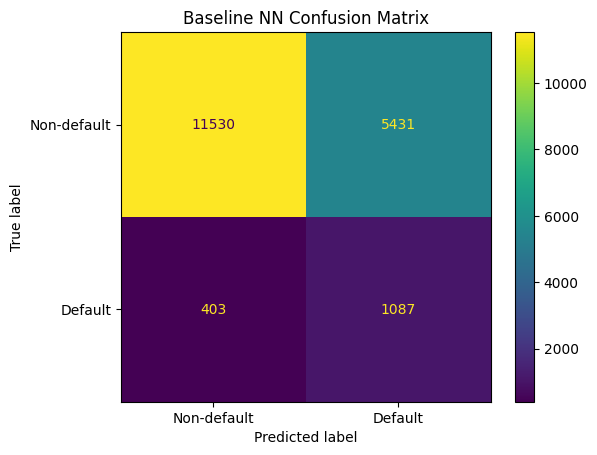

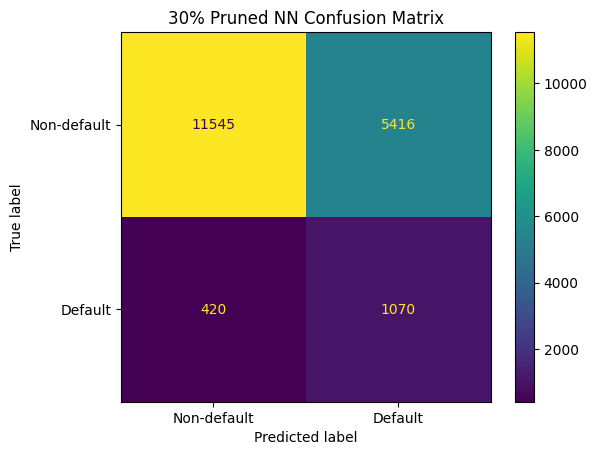

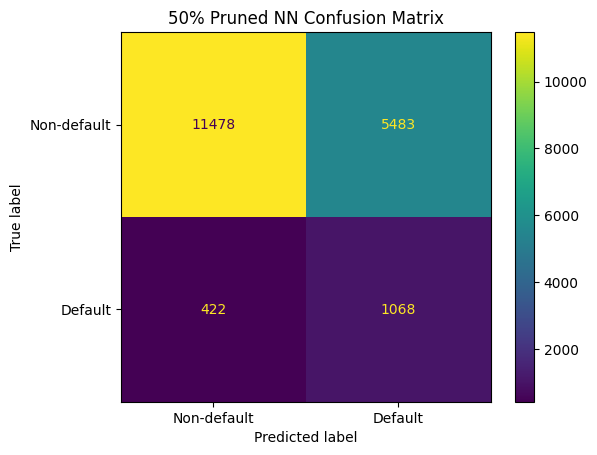

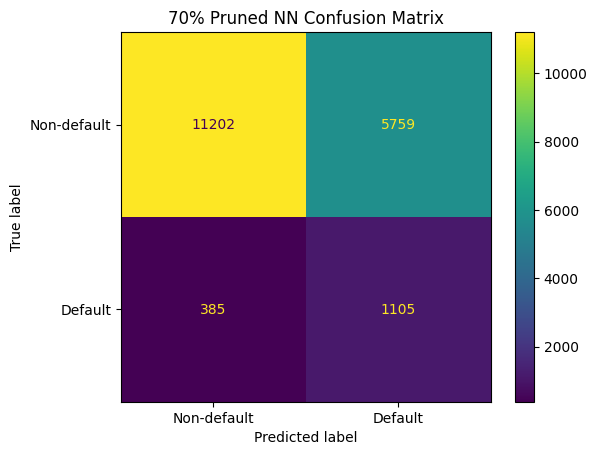

In [ ]:
plot_cm_from_results(multi_pruning_df, "Baseline NN")
plot_cm_from_results(multi_pruning_df, "30% Pruned NN")
plot_cm_from_results(multi_pruning_df, "50% Pruned NN")
plot_cm_from_results(multi_pruning_df, "70% Pruned NN")

The confusion matrices show that the 30%, 50%, and 70% pruned models behave differently at class level.

The baseline model correctly predicts 11,530 non-default cases and 1,087 default cases. It also has 5,431 false positives and 403 false negatives. This is the reference pattern used to judge how pruning changes the model’s decisions.

The 30% pruned model stays closest to the baseline pattern. True negatives increase slightly from 11,530 to 11,545, and false positives decrease from 5,431 to 5,416. This means it makes slightly fewer incorrect default predictions for non-default applicants. However, false negatives increase from 403 to 420, and true positives decrease from 1,087 to 1,070. This explains why the 30% model has slightly lower recall than the baseline. It is stable overall, but it misses a few more actual default cases.

The 50% pruned model gives a weaker class-level result. False negatives increase to 422, meaning it misses 19 more actual default cases than the baseline. False positives also increase to 5,483, and true negatives decrease to 11,478. This means the 50% model does not improve either side of the classification problem. It misses more default cases and also incorrectly flags more non-default cases. This supports the decision that 50% pruning is useful for compression, but not the best final model.

The 70% pruned model has a different behaviour. False negatives decrease from 403 to 385, and true positives increase from 1,087 to 1,105. This explains why the 70% model has the highest recall. It detects more actual default cases than the baseline. However, false positives increase sharply from 5,431 to 5,759, while true negatives decrease to 11,202. This means the model becomes more aggressive in predicting default.

In a credit-risk setting, this trade-off is important. The 70% model reduces missed default cases, which is useful from a risk-detection perspective. However, it also incorrectly labels more non-default applicants as default risk. This could lead to more applicants being treated as risky even when they are not. Therefore, the 70% model should not be selected only because it improves recall.

Overall, the confusion matrices support the final model choice. The 30% pruned model is the most balanced compressed option because it stays closest to the baseline decision pattern. The 50% model weakens both false-negative and false-positive outcomes, while the 70% model improves default detection but increases false positives too much.

## Training Curves for the Pruned Models

Training curves are plotted for the 30%, 50%, and 70% pruned models to check how the models behaved during pruning fine-tuning. These plots are not used alone to select the final model, but they help confirm whether the pruning process was stable.

The function plots training and validation loss, accuracy, AUC, and recall. These metrics were selected because the dataset is imbalanced, so accuracy alone is not enough. AUC shows whether the model’s ranking ability remains stable during pruning, while recall shows whether the model continues to detect default cases during fine-tuning.

In [ ]:
def plot_training_curves(history, model_name):
    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name}: Training and Validation Loss")
    plt.legend()
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name}: Training and Validation Accuracy")
    plt.legend()
    plt.show()

    # AUC curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["auc"], label="Training AUC")
    plt.plot(history.history["val_auc"], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{model_name}: Training and Validation AUC")
    plt.legend()
    plt.show()

    # Recall curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["recall"], label="Training Recall")
    plt.plot(history.history["val_recall"], label="Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title(f"{model_name}: Training and Validation Recall")
    plt.legend()
    plt.show()

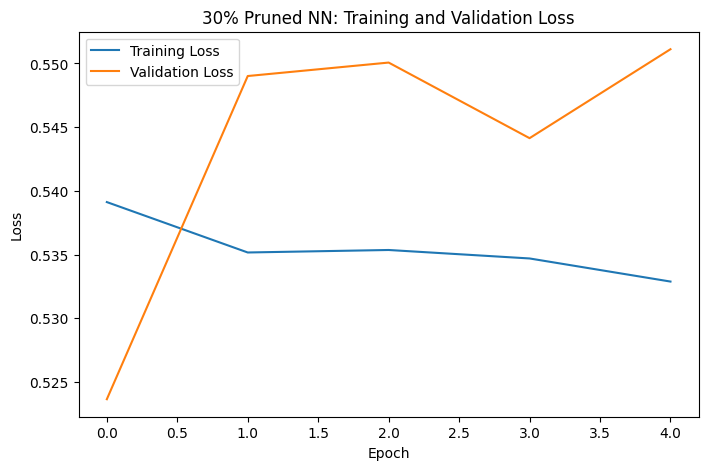

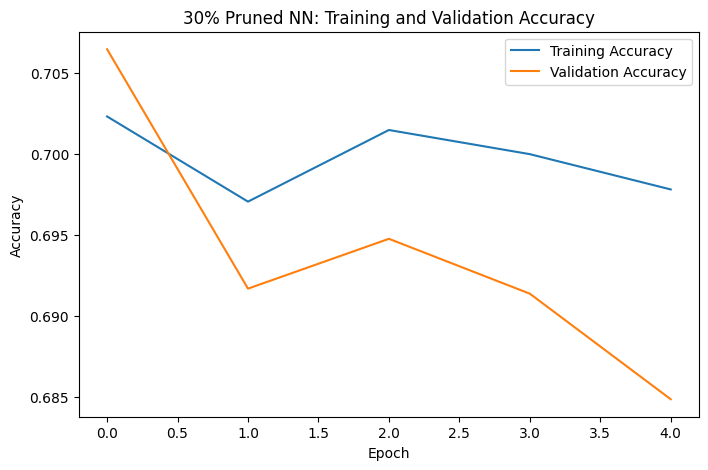

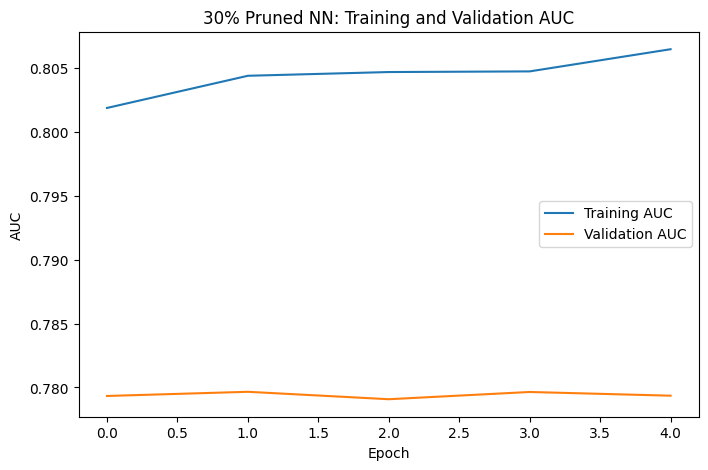

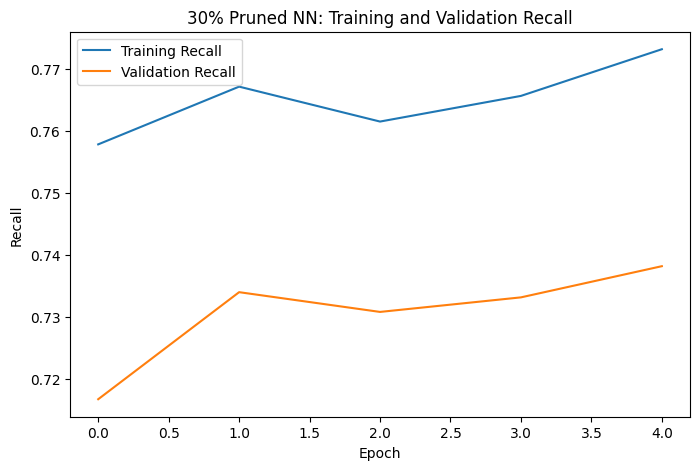

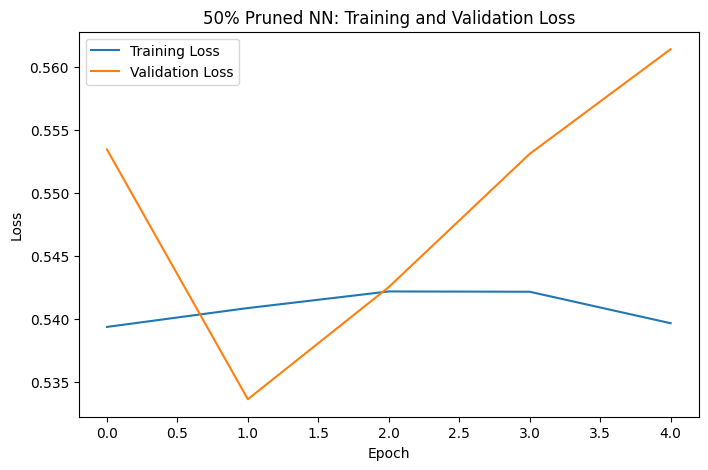

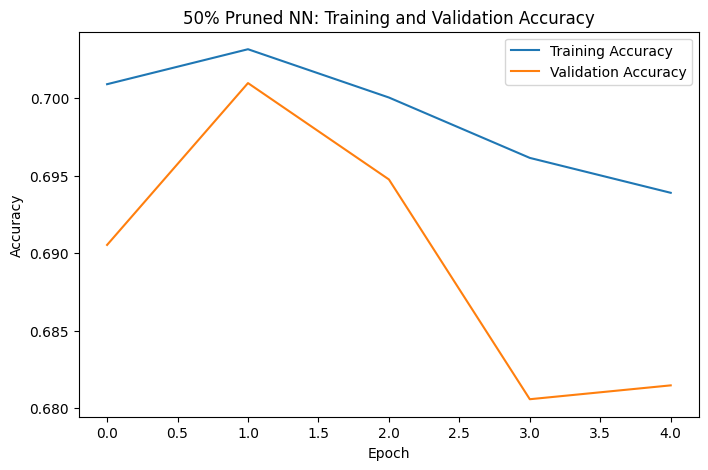

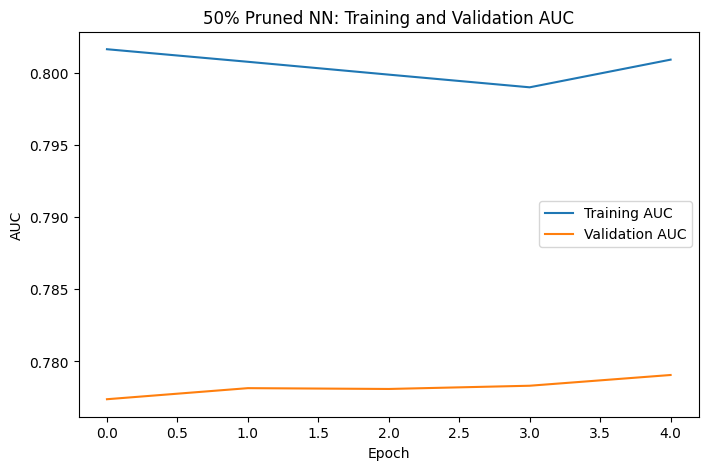

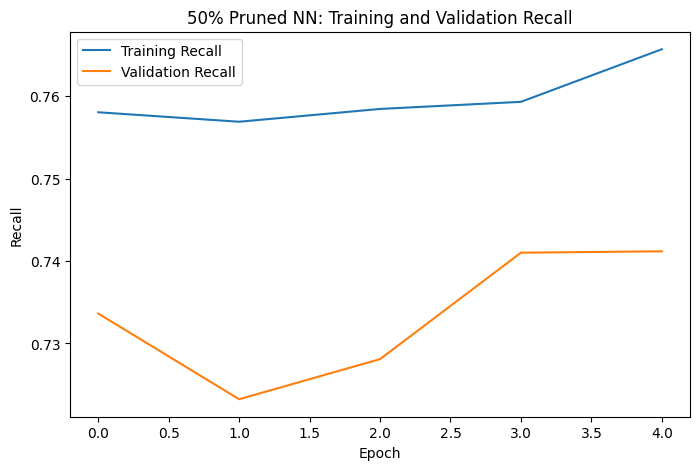

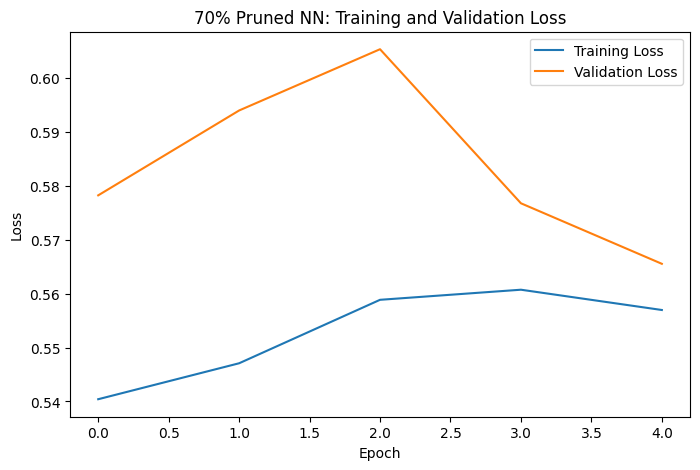

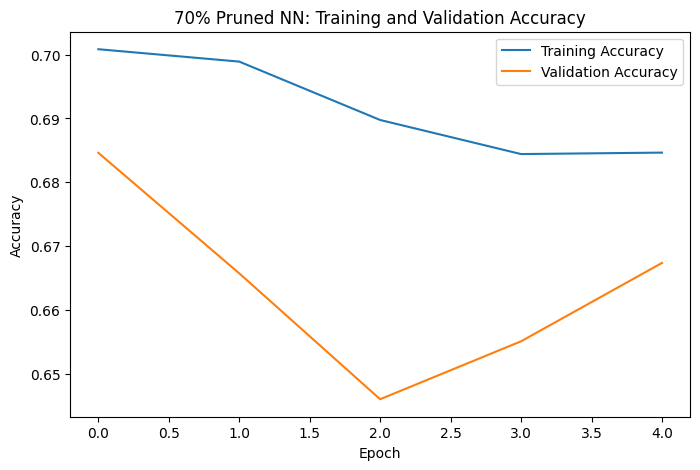

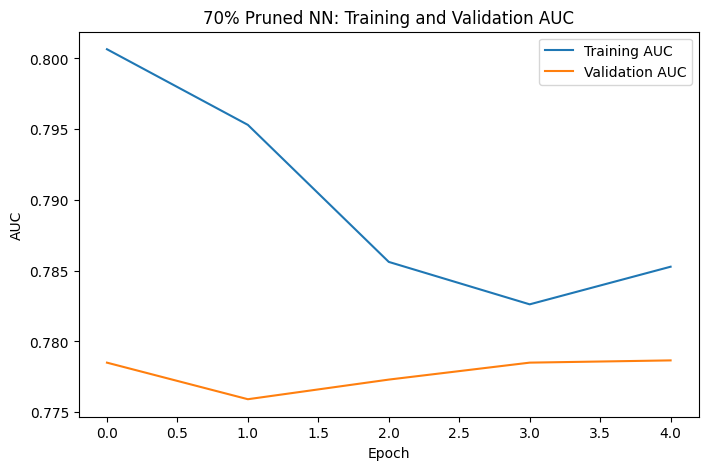

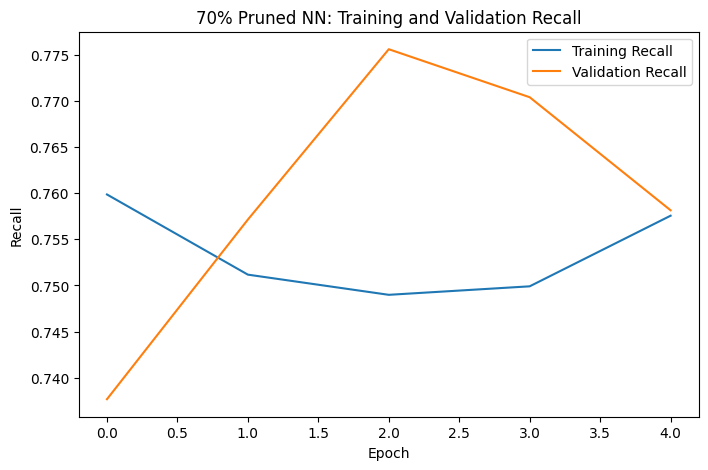

In [ ]:
plot_training_curves(history_30, "30% Pruned NN")
plot_training_curves(history_pruned, "50% Pruned NN")
plot_training_curves(history_70, "70% Pruned NN")

#Interpretation of 30% Pruning Training Curves

The 30% pruning curves show that the model remained stable during fine-tuning. Since 30% pruning is the conservative pruning level, the main expectation was that the model should adjust to weight removal without major instability or sudden performance collapse. Overall, the curves support this expectation.

The training loss gradually decreases across the five epochs, which shows that the model continues to fit the training data while pruning is being applied. The validation loss is more variable. It starts lower in the first epoch, increases in the middle epochs, drops slightly, and then increases again by the final epoch. This suggests that although the model is learning from the training data, validation performance is not improving consistently. This is expected during pruning because the model is not simply training normally, the pruning masks are also changing which weights remain active while the model is fine-tuned.

The accuracy curve shows a small gap between training and validation accuracy after the first epoch. Training accuracy stays around 0.70, while validation accuracy gradually decreases toward the final epoch. This indicates that the model is not gaining validation accuracy during the 30% pruning process. However, the decrease is not severe, so there is no sign that the model failed after pruning.

The AUC curve is especially important because AUC is more meaningful than accuracy for this imbalanced credit-risk dataset. Training AUC increases slightly across epochs, while validation AUC stays almost flat at around 0.779. This is a useful sign because it means the model’s ranking ability on validation data is mostly preserved during 30% pruning. The model does not strongly improve, but it also does not lose much ranking performance during fine-tuning.

The recall curve shows that validation recall improves from the first epoch to the final epoch. This means the model becomes slightly better at identifying default cases on the validation data during pruning. However, training recall remains higher than validation recall, which shows that there is still a generalisation gap. This is expected because the default class is the minority class and is harder to predict consistently.

Overall, the 30% pruning curves show a stable but limited fine-tuning effect. The model does not show clear validation improvement in loss or accuracy, but validation AUC remains stable and validation recall improves slightly. This supports the test-set result where the 30% pruned model keeps ROC-AUC very close to the baseline. Therefore, 30% pruning appears to be a safe compression level.

#Interpretation of 50% Pruning Training Curves

The 50% pruning curves show a less stable pattern than the 30% pruning run. This is expected because the model is being pushed to remove almost half of its weights, so the fine-tuning stage has a stronger compression constraint.

The training loss stays fairly stable across the five epochs, but the validation loss changes more noticeably. Validation loss decreases around the second epoch, then increases again toward the later epochs. This suggests that the model briefly improves on the validation set, but does not continue improving consistently as pruning progresses. This is a sign that 50% pruning is starting to affect the model’s ability to generalise.

The accuracy curve shows a similar pattern. Validation accuracy improves at the second epoch, but then drops sharply around the fourth epoch and only slightly recovers at the final epoch. Training accuracy also declines after the second epoch. This suggests that as the pruning schedule moves closer to the 50% sparsity target, the model loses some useful predictive capacity.

The AUC curve is more stable than the accuracy and loss curves. Training AUC stays around 0.80, while validation AUC slowly increases and remains close to 0.778–0.779. This means that the model’s ranking ability is not heavily damaged by 50% pruning. However, AUC alone does not show the full class-level impact, especially in this imbalanced credit-risk problem.

The recall curve shows that validation recall drops early, then improves in the later epochs. This means the model recovers some ability to detect default cases during fine-tuning. However, the final test results still show that recall is lower than the baseline and slightly lower than the 30% pruned model. Therefore, the validation recall improvement during training does not fully translate into a better final test-set result.

Overall, the 50% training curves show that the model can complete pruning fine-tuning without collapsing, but the validation loss and accuracy are less stable than in the 30% run. This supports the final result, 50% pruning gives stronger compression, but it is not the best predictive trade-off because recall and F1-score decrease more than in the 30% model.

#Interpretation of 70% Pruning Training Curves

The 70% pruning curves represent the most aggressive pruning setting, so stronger instability is expected. At this level, a large proportion of the network’s weights are being pushed to zero, which places much more pressure on the model during fine-tuning.

The loss curve reflects this clearly. Training loss increases from the beginning and remains higher than in the 30% and 50% runs, suggesting that the model finds it harder to fit the training data after such a large amount of pruning. Validation loss rises until around the third epoch, then drops in the final two epochs. This pattern suggests that the model initially struggles as pruning becomes stronger, but later starts to adjust to the reduced set of active weights. Even so, the validation loss remains relatively high, showing that 70% pruning is a much harsher constraint than the lower pruning levels.

The accuracy curve also shows more unstable behaviour. Training accuracy gradually declines across epochs, while validation accuracy drops sharply in the middle of training and then partially recovers at the end. This means the model loses some overall classification accuracy as more weights are removed, although it adapts slightly after the pruning process settles. Since the final validation accuracy still remains below the earlier epochs, the overall message is that heavy pruning weakens classification accuracy.

The AUC curve is especially useful here. Training AUC decreases noticeably from just above 0.80 to around 0.785, which suggests that the model’s ranking ability is affected more at 70% pruning than at 30% or 50%. However, validation AUC stays relatively stable, fluctuating only slightly around 0.776–0.779. This means that although the compressed model becomes weaker on the training set, its ability to rank default and non-default cases on unseen validation data does not collapse. In other words, the model still preserves some discrimination ability even under heavy pruning.

The recall curve is the most interesting. Validation recall improves strongly from the first epoch, peaks around the third epoch, and then declines slightly, but still ends above its starting point. This suggests that the 70% pruned model becomes more sensitive to the default class during training. This matches the final test-set results, where the 70% model produced the highest recall among all pruned models. However, this should not be treated as a complete performance improvement, because the higher recall comes with lower precision and lower specificity. The model detects more default cases, but it does so by predicting default more aggressively.

Overall, the 70% pruning curves show a model under much stronger compression pressure. Compared with the 30% and 50% pruning levels, the training process is less stable, training accuracy and AUC decline more, and loss values are generally higher. At the same time, recall improves, which explains why the final 70% model catches more default cases. Therefore, the curves support the same conclusion shown in the final results: 70% pruning creates the strongest compression and the highest default sensitivity, but it also makes the model less balanced overall.

#Predictive Performance Graph Across Pruning Levels

A grouped bar chart was created to visually compare the main predictive performance metrics across the baseline model and the 30%, 50%, and 70% pruned models.

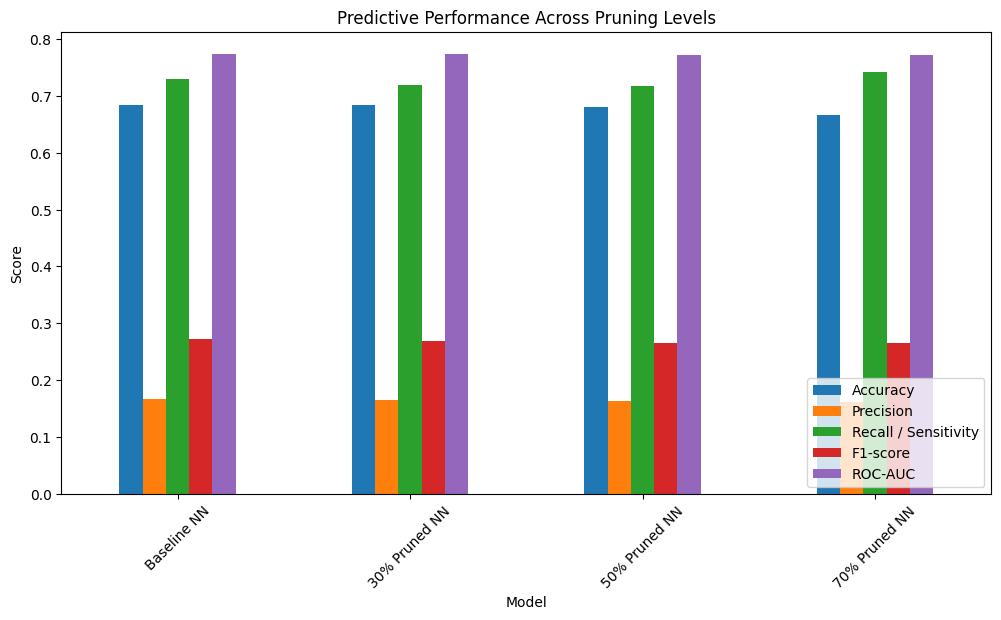

In [ ]:
performance_metrics = [
    "Accuracy",
    "Precision",
    "Recall / Sensitivity",
    "F1-score",
    "ROC-AUC"
]

performance_plot_df = multi_pruning_df.set_index("Model")[performance_metrics]

performance_plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Predictive Performance Across Pruning Levels")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

This graph provides a visual comparison of the main predictive performance metrics across the baseline and pruned models. It supports the table results by showing that ROC-AUC remains broadly stable across pruning levels, while recall, precision, and F1-score vary more between models. The graph is mainly used as a visual summary, the detailed interpretation is provided in the combined results and trade-off discussion above.

#Actual Sparsity Across Pruning Levels

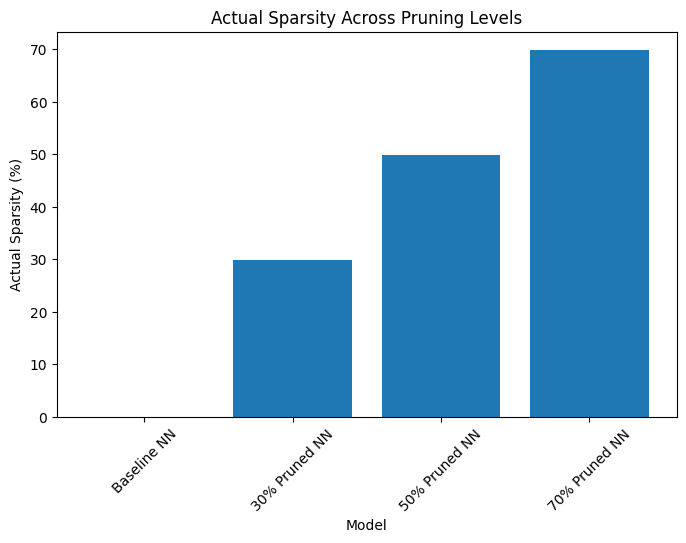

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(multi_pruning_df["Model"], multi_pruning_df["Actual sparsity (%)"])
plt.xlabel("Model")
plt.ylabel("Actual Sparsity (%)")
plt.title("Actual Sparsity Across Pruning Levels")
plt.xticks(rotation=45)
plt.show()

This graph visually confirms that the pruning schedule reached the intended sparsity levels. The baseline model has 0% sparsity, while the 30%, 50%, and 70% pruned models increase progressively in actual sparsity. This supports that each pruning level produced a different compression strength before comparing performance and efficiency.

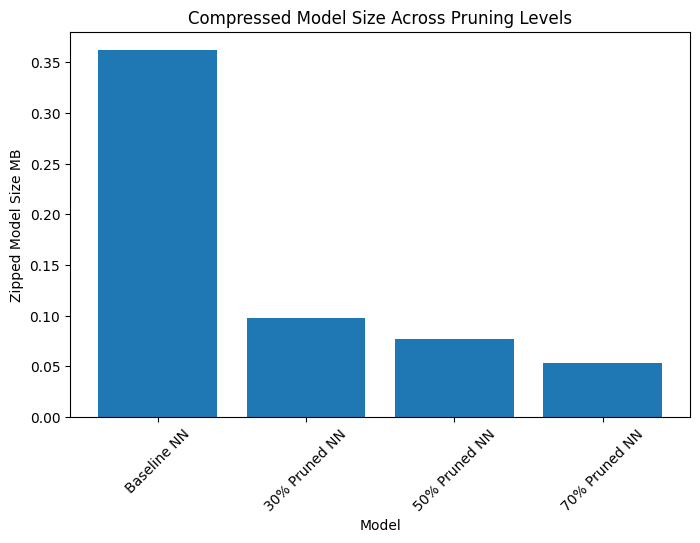

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(multi_pruning_df["Model"], multi_pruning_df["Zipped model size MB"])
plt.xlabel("Model")
plt.ylabel("Zipped Model Size MB")
plt.title("Compressed Model Size Across Pruning Levels")
plt.xticks(rotation=45)
plt.show()

This graph shows the main storage benefit of pruning. As sparsity increases, the zipped model size decreases from the baseline model to the 30%, 50%, and 70% pruned models. This confirms that the zero-valued weights created by pruning make the saved model easier to compress. Therefore, model-size reduction is the clearest efficiency improvement from pruning.

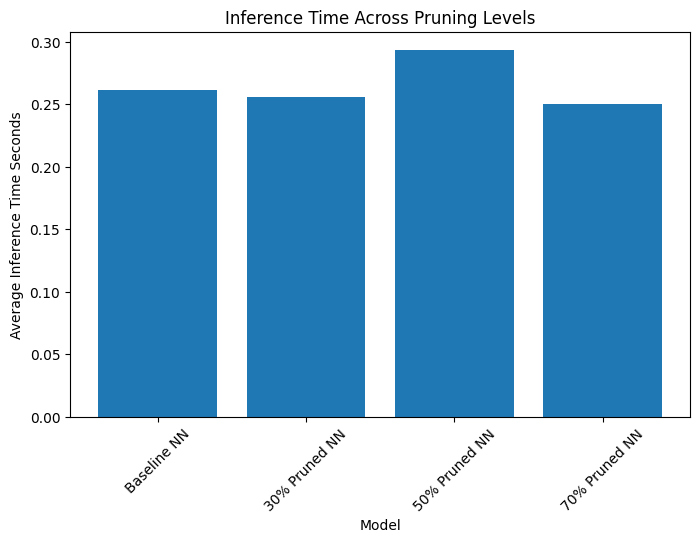

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(multi_pruning_df["Model"], multi_pruning_df["Average inference time seconds"])
plt.xlabel("Model")
plt.ylabel("Average Inference Time Seconds")
plt.title("Inference Time Across Pruning Levels")
plt.xticks(rotation=45)
plt.show()

This graph shows that pruning did not consistently reduce inference time. The 30% and 70% pruned models are slightly faster than the baseline, but the 50% pruned model is slower. This means pruning cannot be claimed as a reliable speed improvement in this experiment. The main efficiency benefit is therefore compressed model size rather than prediction speed.

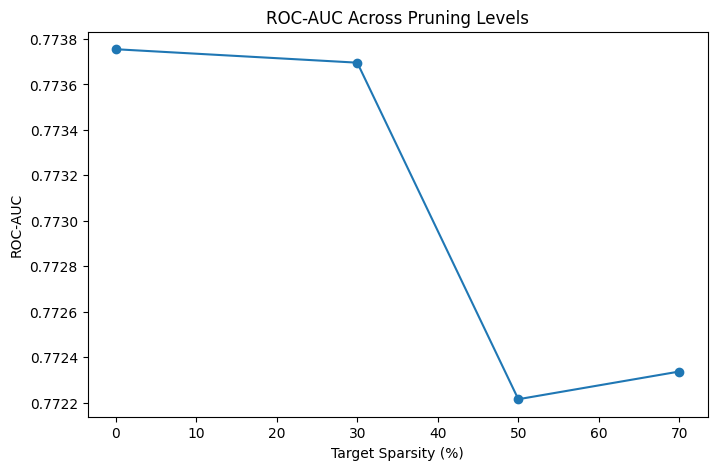

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(multi_pruning_df["Target sparsity (%)"], multi_pruning_df["ROC-AUC"], marker="o")
plt.xlabel("Target Sparsity (%)")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Pruning Levels")
plt.show()

This graph shows that ROC-AUC remains very close to the baseline across all pruning levels. The 30% pruned model almost overlaps with the baseline, while 50% and 70% pruning show a small drop. This suggests that pruning does not heavily damage the model’s overall ranking ability, but higher sparsity slightly reduces it.

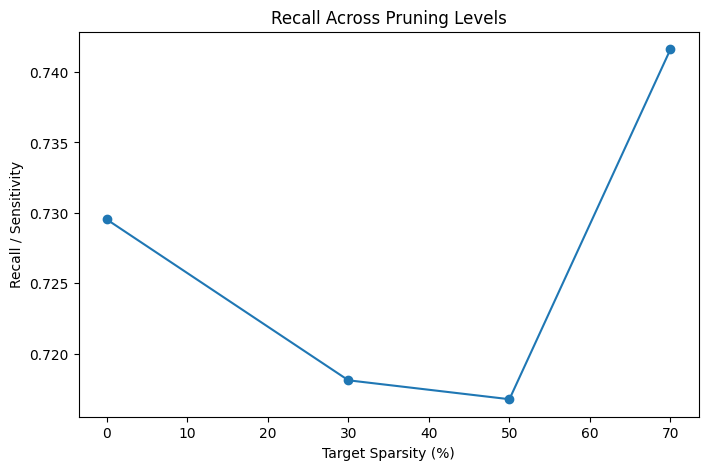

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(multi_pruning_df["Target sparsity (%)"], multi_pruning_df["Recall / Sensitivity"], marker="o")
plt.xlabel("Target Sparsity (%)")
plt.ylabel("Recall / Sensitivity")
plt.title("Recall Across Pruning Levels")
plt.show()

This graph shows that recall does not change linearly with pruning strength. Recall decreases for the 30% and 50% pruned models, meaning these models detect fewer actual default cases than the baseline. However, recall increases strongly at 70% pruning. This shows that the 70% model becomes more sensitive to the default class, but this needs to be interpreted together with precision and false positives because higher recall alone does not mean the model is better overall.

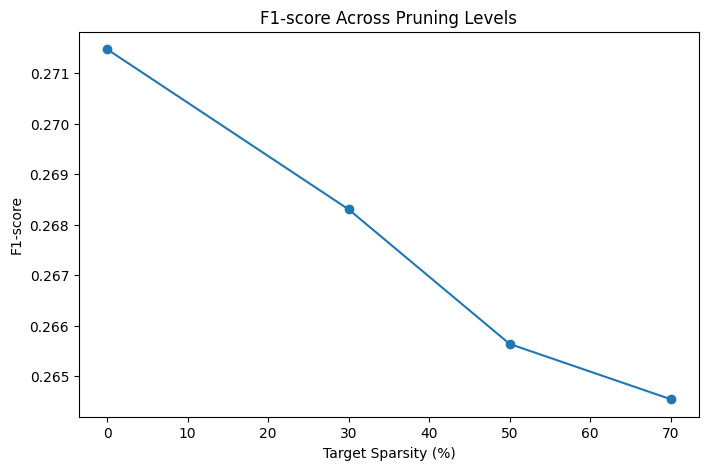

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(multi_pruning_df["Target sparsity (%)"], multi_pruning_df["F1-score"], marker="o")
plt.xlabel("Target Sparsity (%)")
plt.ylabel("F1-score")
plt.title("F1-score Across Pruning Levels")
plt.show()

This graph shows that F1-score decreases as pruning becomes stronger. Although the 70% pruned model has the highest recall, its F1-score is the lowest, which means the recall improvement is not balanced by precision. This supports the conclusion that higher sparsity improves compression but weakens the balance between correctly identifying default cases and avoiding incorrect default predictions.

#Saving the Final Selected Pruned Model

After comparing the pruning results, the 30% pruned neural network was selected as the final compressed model. This decision was based on the overall trade-off between predictive stability and compression benefit.

The 70% pruned model achieved the strongest compression and the highest recall, but it also reduced accuracy, precision, specificity, and F1-score. This means it became more sensitive to default cases, but less balanced overall. The 50% pruned model provided stronger compression than the 30% model, but it caused a larger drop in recall and F1-score, making it less suitable as the final option.

The 30% pruned model was selected because it preserved the baseline model’s behaviour most closely while still providing a large storage benefit. Its ROC-AUC and accuracy remained almost unchanged compared with the baseline, and the zipped model size was reduced by more than 70%. Although recall decreased slightly, this reduction was smaller and more acceptable than the performance trade-offs seen in the 50% and 70% models.

Therefore, the 30% pruned model is saved as the final selected compressed model. This model should be interpreted as a storage-efficient version of the baseline neural network, rather than as a model that improves predictive performance.

In [ ]:
final_model_30.save(f"{MULTI_DIR}/final_selected_30_percent_pruned_model.keras")

The selected 30% pruned model was saved successfully in the multi-level pruning output folder. This saved model can now be reused for reporting, comparison, or later deployment testing without rerunning the pruning process.

Overall, the project decisions focused on balancing predictive performance, explainability, fairness, and efficiency for credit default prediction. The Home Credit Default Risk dataset was selected and treated as a relational financial dataset, with application_train used as the main modelling file and supporting CSV files aggregated through applicant-level IDs. The target variable was highly imbalanced, with only 8.07% default cases, so the project decided not to rely on accuracy alone and instead used ROC-AUC, recall, precision, F1-score, specificity, confusion matrices, ROC curves, and precision-recall analysis. During data preparation, no duplicate rows were removed, very high-missing interest-rate columns were dropped, invalid placeholders such as 365243 were converted to missing values, contextual XNA values were handled carefully, and financial outliers were kept because they could represent genuine applicant behaviour. Bias exploration showed unequal representation and different observed default rates across groups such as gender, loan type, education, housing, and car ownership, so these were treated as fairness risk indicators. Feature engineering produced around 499–500 applicant-level features, including external score combinations, credit-to-income ratios, debt ratios, previous application features, and repayment behaviour indicators. For glass-box modelling, Logistic Regression and Decision Tree were tested, with Logistic Regression performing better than the Decision Tree, achieving ROC-AUC 0.7782, recall 0.7063, and F1-score 0.2850. The black-box neural network was then developed using several architectures, and the selected model was the small [64, 32] network with batch size 1024, which achieved validation ROC-AUC 0.7811 and final test ROC-AUC 0.7834, recall 0.7217, precision 0.1762, specificity 0.7036, and F1-score 0.2833. This made the neural network the strongest predictive model, although its improvement over Logistic Regression was small. SHAP was selected for XAI because it explained both global feature importance and individual predictions, with important features including EXT_SOURCE_2, CODE_GENDER_F, EXT_SOURCES_MEAN, INS_PAYMENT_DIFFERENCE_MAX, CREDIT_TO_GOODS_RATIO, and previous application/annuity-related features. Feature importance was also used as an emerging technique, where the reduced Decision Tree kept the same ROC-AUC of 0.7079 and F1-score of 0.2406 while reducing training time from 106.7 seconds to 80.2 seconds. For model compression, pruning levels of 30%, 50%, and 70% were tested, and the 30% pruned model was selected as the best trade-off because it reduced zipped model size from 0.3619 MB to 0.0972 MB while keeping ROC-AUC almost unchanged at 0.773696. Therefore, the final outcome shows that the neural network provided the best predictive performance, SHAP and feature importance improved transparency, and 30% pruning provided the most suitable efficiency improvement without major performance loss.